# Hotel Recommendation Systems: End-to-End Design, Evaluation, and Business Interpretation

### Matteo Colantoni, Elias Nmeir, Nikolas Lafrentz, Kenny Tohme

This notebook develops an end-to-end recommendation system for hotel suggestions based on explicit review data. The goal is not only to build recommenders with good offline performance, but also to study how different recommendation strategies behave under realistic constraints such as sparsity, popularity imbalance, contextual variation, and business interpretability.

The project is motivated by a practical scenario in which a company currently relies on a largely non-personalized display strategy and wants to understand how much value a more intelligent recommendation pipeline could add. For this reason, the notebook is structured as both a technical analysis and a business-oriented proof of concept. Alongside model building, particular attention is given to evaluation design, interpretability of results, and the trade-offs between relevance, coverage, personalization, and robustness.

The analysis covers a broad range of recommender-system families. I begin with data preparation and exploratory analysis, then move through non-personalized baselines, collaborative filtering methods, content-based recommenders, hybrid extensions, and context-aware models. Later sections also include evaluation refinements, an exploration–exploitation perspective through bandit methods, and a conversational recommendation component connected to a chatbot interface.

The intention is not to search for a single universally best algorithm in isolation, but to understand which methods are most appropriate for this dataset, why they behave as they do, and what their practical implications would be in a real product setting. In that sense, this notebook should be read not only as a benchmarking exercise, but as a structured study of recommendation design choices from data to deployment-oriented interpretation.

# Index

1. [Import libraries, configuration, dataset download, loading, and preprocessing](#1-import-libraries-configuration-dataset-download-loading-and-preprocessing)  
2. [Dataset reduction and temporal train/test split](#2-dataset-reduction-and-temporal-traintest-split)  
3. [Exploratory data analysis and sparsity diagnostics](#3-exploratory-data-analysis-and-sparsity-diagnostics)  
4. [Non-personalized recommenders](#4-non-personalized-recommenders)  
5. [Memory-based collaborative filtering recommenders](#5-memory-based-collaborative-filtering-recommenders)  
6. [Model-based collaborative filtering recommenders](#6-model-based-collaborative-filtering-recommenders)  
7. [Content-based recommenders](#7-content-based-recommenders)  
8. [First offline evaluation and baseline comparison](#8-first-offline-evaluation-and-baseline-comparison)  
9. [Context-aware memory-based collaborative filtering](#9-context-aware-memory-based-collaborative-filtering)  
10. [Context-aware content-based recommenders](#10-context-aware-content-based-recommenders)  
11. [Analysis of context impact: with vs without context](#11-analysis-of-context-impact-with-vs-without-context)  
12. [Hybrid and ensemble recommenders](#12-hybrid-and-ensemble-recommenders)  
13. [Best practices in evaluation for memory-based methods: CV and CVTT](#13-best-practices-in-evaluation-for-memory-based-methods-cv-and-cvtt)  
14. [Best practices in evaluation for model-based methods: CV, CVTT, and early stopping](#14-best-practices-in-evaluation-for-model-based-methods-cv-cvtt-and-early-stopping)  
15. [Hyperparameter tuning and sensitivity analysis](#15-hyperparameter-tuning-and-sensitivity-analysis)  
16. [Cold-start, bias, and fairness considerations](#16-cold-start-bias-and-fairness-considerations)  
17. [Exploration-exploitation trade-off and bandit algorithms](#17-exploration-exploitation-trade-off-and-bandit-algorithms)  
18. [Business interpretation and added value for the company](#18-business-interpretation-and-added-value-for-the-company)  
19. [Final comparison and conclusions](#19-final-comparison-and-conclusions)

## 1. Import libraries, configuration, dataset download, loading, and preprocessing

The first step of the project is to construct a clean and consistent explicit-feedback dataset that can support the different recommender families studied later in the notebook. Because the goal is to compare non-personalized, collaborative, content-based, hybrid, and context-aware approaches within the same pipeline, the preprocessing stage is especially important: all later results depend on having a reliable interaction table, standardized identifiers, usable metadata, and a defensible reduction strategy.

The raw hotel-review data is relatively large and heterogeneous. It contains user identifiers, hotel identifiers, review dates, textual content, rating information, and additional hotel metadata that can later be reused for both collaborative and content-based modeling. This makes it a strong candidate for the project, because it supports a broad range of recommendation techniques rather than forcing the analysis into only one family of models.

At the same time, the dataset is too large and sparse to use naively in every stage of the notebook. Several of the later procedures, especially similarity-based recommendation, repeated metric computation, and collaborative filtering experiments, become computationally expensive when run on the full interaction table. For that reason, preprocessing here is not just a cleaning step: it is also the stage where the experimental scope of the notebook is defined in a controlled and reproducible way.

In what follows, I first standardize the explicit-feedback table and inspect its basic structure. I then apply iterative filtering and a controlled reduction procedure so that the final working dataset remains computationally manageable while still preserving the main structural properties of the original problem, including its strong sparsity and long-tail behavior.

In [565]:
import os

import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install pandas==1.5.3, numpy==1.26.4, matplotlib==3.7.3, matplotlib-inline ipykernel kaggle recmetrics

import math
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

In [566]:
try:
    from surprise import Dataset, Reader, KNNBasic, SVD
    from surprise.model_selection import train_test_split as surprise_train_test_split
    SURPRISE_AVAILABLE = True
except ImportError:
    SURPRISE_AVAILABLE = False
    !{sys.executable} -m pip install surprise

import surprise

In [567]:
SEED = 42
TOP_K = 10
MIN_USER_INTERACTIONS = 8
MIN_ITEM_INTERACTIONS = 20

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed fixed to {SEED}")
print(f"Top-K cutoff: {TOP_K}")
print(f"Minimum user interactions: {MIN_USER_INTERACTIONS}")
print(f"Minimum item interactions: {MIN_ITEM_INTERACTIONS}")

Random seed fixed to 42
Top-K cutoff: 10
Minimum user interactions: 8
Minimum item interactions: 20


In [568]:
# Update these paths depending on your Colab / local setup
EXPLICIT_DATA_PATH = "/content/explicit_dataset.csv"


print("Explicit dataset path:", EXPLICIT_DATA_PATH)


Explicit dataset path: /content/explicit_dataset.csv


In [569]:
def summarize_interactions(df, user_col, item_col, rating_col=None):
    n_users = df[user_col].nunique()
    n_items = df[item_col].nunique()
    n_interactions = len(df)

    sparsity = 1 - (n_interactions / (n_users * n_items))

    print(f"Number of users:        {n_users:,}")
    print(f"Number of items:        {n_items:,}")
    print(f"Number of interactions: {n_interactions:,}")
    print(f"Sparsity:               {sparsity:.4f}")

    if rating_col is not None:
        print(f"Rating mean:            {df[rating_col].mean():.4f}")
        print(f"Rating std:             {df[rating_col].std():.4f}")
        print(f"Rating min:             {df[rating_col].min():.4f}")
        print(f"Rating max:             {df[rating_col].max():.4f}")

In [570]:

# ---- CONFIG: edit these two if needed ----
KAGGLE_JSON_PATH = "kaggle.json"  # path to your kaggle.json in the current folder (or give full path)
DATASET = "joebeachcapital/hotel-reviews"
OUT_DIR = "data/hotel_reviews"
# -----------------------------------------
'''
# 1) Ensure kaggle.json is in the right place
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Copy kaggle.json -> ~/.kaggle/kaggle.json (works on Mac/Linux; on Windows this also usually works in VS Code Python)
dst = os.path.expanduser("~/.kaggle/kaggle.json")
with open(KAGGLE_JSON_PATH, "rb") as fsrc, open(dst, "wb") as fdst:
    fdst.write(fsrc.read())

# Fix permissions on Mac/Linux (safe to run on Windows too; it may no-op)
try:
    os.chmod(dst, 0o600)
except Exception:
    pass

# 2) Install kaggle and download dataset
import sys
!{sys.executable} -m pip install -q kaggle

os.makedirs(OUT_DIR, exist_ok=True)
!kaggle datasets download -d {DATASET} -p {OUT_DIR} --unzip
'''
# 3) Load only needed columns 
csv_path = os.path.join(OUT_DIR, "reviews.csv")
usecols = ["ratings", "title", "text", "author", "date", "offering_id"]  
ratings_df = pd.read_csv(csv_path, usecols=usecols)

ratings_df.head()

,ratings,title,text,author,offering_id,date
0,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...","“Truly is ""Jewel of the Upper Wets Side""”",Stayed in a king suite for 11 nights and yes i...,"{'username': 'Papa_Panda', 'num_cities': 22, '...",93338,2012-12-17
1,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“My home away from home!”,"On every visit to NYC, the Hotel Beacon is the...","{'username': 'Maureen V', 'num_reviews': 2, 'n...",93338,2012-12-17
2,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",“Great Stay”,This is a great property in Midtown. We two di...,"{'username': 'vuguru', 'num_cities': 12, 'num_...",1762573,2012-12-18
3,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Modern Convenience”,The Andaz is a nice hotel in a central locatio...,"{'username': 'Hotel-Designer', 'num_cities': 5...",1762573,2012-12-17
4,"{'service': 4.0, 'cleanliness': 5.0, 'overall'...",“Its the best of the Andaz Brand in the US....”,I have stayed at each of the US Andaz properti...,"{'username': 'JamesE339', 'num_cities': 34, 'n...",1762573,2012-12-17


In [571]:
csv_path = os.path.join(OUT_DIR, "offerings.csv")
usecols = ["hotel_class", "address", "id", "name"]  
offers_df = pd.read_csv(csv_path, usecols=usecols)

offers_df.head()

,hotel_class,address,id,name
0,4.0,"{'region': 'NY', 'street-address': '147 West 4...",113317,Casablanca Hotel Times Square
1,5.0,"{'region': 'CA', 'street-address': '300 S Dohe...",76049,Four Seasons Hotel Los Angeles at Beverly Hills
2,3.5,"{'region': 'NY', 'street-address': '790 Eighth...",99352,Hilton Garden Inn Times Square
3,4.0,"{'region': 'NY', 'street-address': '152 West 5...",93589,The Michelangelo Hotel
4,4.0,"{'region': 'NY', 'street-address': '130 West 4...",217616,The Muse Hotel New York


In [572]:
def basic_stats(ratings_df, user_col, item_col):
  n_ratings = ratings_df.shape[0]
  n_users = ratings_df[user_col].nunique()
  n_items = ratings_df[item_col].nunique()
  print(f'There are {n_ratings} ratings from {n_users} users to {n_items} items')
  return n_ratings, n_users, n_items

In [573]:
import ast

# Parse the "author" column (string -> dict) and extract username
ratings_df["author_dict"] = ratings_df["author"].apply(ast.literal_eval)
ratings_df["username"] = ratings_df["author_dict"].apply(lambda d: d.get("username"))

# Parse the ratings dict and extract overall score
ratings_df["ratings_dict"] = ratings_df["ratings"].apply(ast.literal_eval)
ratings_df["overall_rating"] = ratings_df["ratings_dict"].apply(lambda d: d.get("overall"))

# Parse date for later time analysis
ratings_df["date"] = pd.to_datetime(ratings_df["date"], errors="coerce")

n_ratings, n_users, n_items = basic_stats(ratings_df, "username", "offering_id")

There are 878561 ratings from 536952 users to 3945 items


In [574]:
summarize_interactions(ratings_df, "username", "offering_id", "overall_rating")

Number of users:        536,952
Number of items:        3,945
Number of interactions: 878,561
Sparsity:               0.9996
Rating mean:            3.9362
Rating std:             1.1651
Rating min:             0.0000
Rating max:             5.0000


## 2. Dataset reduction and train/test split

Collaborative filtering requires enough interaction density to estimate similarities between users/items and to learn stable latent factors. The raw hotel dataset is extremely sparse and contains a very long tail of users with very few reviews and hotels with very few ratings. If we directly fit memory-based or model-based CF on this full interaction graph, similarity estimates become unstable and latent representations are poorly identified.

To make collaborative filtering statistically meaningful and computationally feasible, we reduce the dataset using a bidirectional minimum-interaction filter. In particular, we keep only users with at least `MIN_USER_INTERACTIONS` ratings and items with at least `MIN_ITEM_INTERACTIONS` ratings. This filtering is applied iteratively until convergence, because removing low-activity users may create low-activity items, and vice versa. In graph terms, we are extracting a constrained user-item core from the original bipartite interaction network.

This reduction does not mean that low-activity users or niche items are unimportant in practice. It only means that they are not well suited for pure collaborative filtering in an offline prototype. In a real system, these cases could be addressed by complementary methods such as popularity-based, hybrid, or exploration-oriented recommenders.

After reduction, we create a time-aware train/test split. For each eligible user, interactions are ordered chronologically and the most recent interaction is reserved for test, while earlier interactions are used for training. This avoids temporal leakage and better reflects the real recommendation setting, where models must predict future behavior from past data.

In [575]:
def basic_stats(df, user_col, item_col):
    n_interactions = len(df)
    n_users = df[user_col].nunique()
    n_items = df[item_col].nunique()
    print(f"There are {n_interactions} ratings from {n_users} users to {n_items} items")
    return n_interactions, n_users, n_items


def summarize_interactions(df, user_col, item_col, rating_col=None):
    n_users = df[user_col].nunique()
    n_items = df[item_col].nunique()
    n_interactions = len(df)
    sparsity = 1 - (n_interactions / (n_users * n_items))

    print(f"Number of users:        {n_users:,}")
    print(f"Number of items:        {n_items:,}")
    print(f"Number of interactions: {n_interactions:,}")
    print(f"Sparsity:               {sparsity:.6f}")

    if rating_col is not None:
        print(f"Rating mean:            {df[rating_col].mean():.4f}")
        print(f"Rating std:             {df[rating_col].std():.4f}")
        print(f"Rating min:             {df[rating_col].min():.4f}")
        print(f"Rating max:             {df[rating_col].max():.4f}")

In [576]:
def iterative_k_core_filter(
    df,
    user_col,
    item_col,
    min_user_interactions=5,
    min_item_interactions=5,
    verbose=True
):
    """
    Iteratively filter the interaction table until every remaining user has at least
    `min_user_interactions` interactions and every remaining item has at least
    `min_item_interactions` interactions.
    """
    filtered = df.copy()
    iteration = 0

    while True:
        iteration += 1
        n_before = len(filtered)

        user_counts = filtered[user_col].value_counts()
        valid_users = user_counts[user_counts >= min_user_interactions].index
        filtered = filtered[filtered[user_col].isin(valid_users)]

        item_counts = filtered[item_col].value_counts()
        valid_items = item_counts[item_counts >= min_item_interactions].index
        filtered = filtered[filtered[item_col].isin(valid_items)]

        n_after = len(filtered)

        if verbose:
            print(
                f"Iteration {iteration}: "
                f"{n_before:,} -> {n_after:,} interactions, "
                f"{filtered[user_col].nunique():,} users, "
                f"{filtered[item_col].nunique():,} items"
            )

        if n_after == n_before:
            break

    return filtered.reset_index(drop=True)

In [577]:
# Keep only the columns needed for collaborative filtering
explicit_df = ratings_df[["username", "title", "text", "offering_id", "overall_rating", "date"]].copy()

# Drop rows with missing values in the key columns
explicit_df = explicit_df.dropna(subset=["username", "offering_id", "overall_rating", "date"]).copy()

# Enforce types
explicit_df["username"] = explicit_df["username"].astype(str)
explicit_df["offering_id"] = explicit_df["offering_id"].astype(int)
explicit_df["overall_rating"] = explicit_df["overall_rating"].astype(float)
explicit_df["date"] = pd.to_datetime(explicit_df["date"], errors="coerce")

# Remove rows with invalid dates after conversion
explicit_df = explicit_df.dropna(subset=["date"]).copy()

explicit_df = explicit_df[explicit_df["overall_rating"] > 0].copy()

print("Raw explicit-feedback dataset")
basic_stats(explicit_df, "username", "offering_id")
summarize_interactions(explicit_df, "username", "offering_id", "overall_rating")

Raw explicit-feedback dataset
There are 878544 ratings from 536952 users to 3945 items
Number of users:        536,952
Number of items:        3,945
Number of interactions: 878,544
Sparsity:               0.999585
Rating mean:            3.9363
Rating std:             1.1650
Rating min:             1.0000
Rating max:             5.0000


The raw explicit-feedback dataset is extremely sparse: 878,544 interactions are distributed across 536,952 users and 3,945 hotels, yielding a sparsity of about 0.9996. This means that the vast majority of user–item pairs are unobserved, so direct collaborative filtering on the full matrix would be statistically fragile.

Another important aspect is the strong imbalance in activity. With such a large number of users relative to interactions, many users contribute only one or very few ratings, while a smaller subset of hotels accumulates most of the feedback. In this regime, similarity estimates are unreliable because two users rarely overlap on enough co-rated items, and many items do not receive enough evidence to support stable neighborhoods or latent representations.

The rating scale itself is also clearly skewed toward positive feedback, with mean rating 3.9363 and standard deviation 1.1650. This suggests that the task is not only sparse but also biased toward favorable reviews, a common property in travel and review platforms. As a consequence, recommendation models must operate under both data scarcity and positive-feedback concentration.

In [578]:
reduced_df = iterative_k_core_filter(
    explicit_df,
    user_col="username",
    item_col="offering_id",
    min_user_interactions=MIN_USER_INTERACTIONS,
    min_item_interactions=MIN_ITEM_INTERACTIONS,
    verbose=True
)

print("\nReduced explicit-feedback dataset")
basic_stats(reduced_df, "username", "offering_id")
summarize_interactions(reduced_df, "username", "offering_id", "overall_rating")

Iteration 1: 878,544 -> 129,607 interactions, 5,157 users, 1,525 items
Iteration 2: 129,607 -> 121,968 interactions, 4,092 users, 1,459 items
Iteration 3: 121,968 -> 120,880 interactions, 3,969 users, 1,446 items
Iteration 4: 120,880 -> 120,660 interactions, 3,943 users, 1,444 items
Iteration 5: 120,660 -> 120,618 interactions, 3,937 users, 1,444 items
Iteration 6: 120,618 -> 120,618 interactions, 3,937 users, 1,444 items

Reduced explicit-feedback dataset
There are 120618 ratings from 3937 users to 1444 items
Number of users:        3,937
Number of items:        1,444
Number of interactions: 120,618
Sparsity:               0.978783
Rating mean:            3.8950
Rating std:             1.1513
Rating min:             1.0000
Rating max:             5.0000


The iterative reduction step dramatically shrinks the problem from 878,544 interactions to 120,618, while also reducing the user set from 536,952 to 3,937 and the item set from 3,945 to 1,444. This is a substantial pruning, but it is exactly what makes collaborative filtering a bit more feasible in this notebook.

The main point is not that the removed users or hotels are unimportant, but that they do not provide enough interaction evidence for neighborhood-based or latent-factor models to learn reliably. After filtering, the matrix remains sparse at 0.9788, but it is no longer dominated by one-shot users and extremely cold items. In other words, we move from an almost unusable interaction graph to a still difficult but learnable one.

It is also important that the filtering is iterative. User and item thresholds are interdependent: removing low-activity users can make some items fall below the item threshold, and removing those items can in turn invalidate additional users. The convergence after six iterations confirms that the final reduced dataset satisfies both constraints simultaneously and defines a coherent interaction core for the later experiments.

The reduction is not intended to represent the entire production population. It is intended to isolate the subspace where collaborative filtering is statistically meaningful and evaluable offline.

In [579]:
def leave_last_one_out_split(df, user_col, time_col):
    """
    Time-aware split:
    for each user, reserve the most recent interaction for test
    and keep the earlier interactions for train.
    """
    df_sorted = df.sort_values([user_col, time_col]).copy()

    test_idx = df_sorted.groupby(user_col).tail(1).index
    test_df = df_sorted.loc[test_idx].copy()
    train_df = df_sorted.drop(index=test_idx).copy()

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

In [580]:
train_df, test_df = leave_last_one_out_split(
    reduced_df,
    user_col="username",
    time_col="date"
)

print("Train set")
basic_stats(train_df, "username", "offering_id")
summarize_interactions(train_df, "username", "offering_id", "overall_rating")

print("\nTest set")
basic_stats(test_df, "username", "offering_id")
summarize_interactions(test_df, "username", "offering_id", "overall_rating")

Train set
There are 116681 ratings from 3937 users to 1444 items
Number of users:        3,937
Number of items:        1,444
Number of interactions: 116,681
Sparsity:               0.979476
Rating mean:            3.8907
Rating std:             1.1554
Rating min:             1.0000
Rating max:             5.0000

Test set
There are 3937 ratings from 3937 users to 1136 items
Number of users:        3,937
Number of items:        1,136
Number of interactions: 3,937
Sparsity:               0.999120
Rating mean:            4.0218
Rating std:             1.0169
Rating min:             1.0000
Rating max:             5.0000


The temporal leave-last-one-out split produces 116,681 training interactions and 3,937 test interactions, exactly one test interaction per user. This is a very natural evaluation design for recommendation, because it turns the task into predicting each user's next item given their historical behavior.

An important observation is that the test set has fewer distinct items than the training set, 1,136 versus 1,444, while every test item is present in training. This is desirable because it avoids pure item cold-start at evaluation time and ensures that collaborative and content-based recommenders are tested on items for which some historical evidence exists.

The average rating in the test set, 4.0218, is slightly higher than in training, 3.8907. This difference is not huge, but it suggests that the most recent interactions are, on average, somewhat more positive. This is worth keeping in mind when later interpreting recommendation quality, because the held-out target is not a random historical point but the user's most recent observed preference.

In [581]:
# Every user in test should appear exactly once
assert test_df["username"].value_counts().eq(1).all()

# Every user in test must also exist in train
assert set(test_df["username"]).issubset(set(train_df["username"]))

# No overlap in actual interactions
train_keys = set(zip(train_df["username"], train_df["title"], train_df["text"], train_df["offering_id"], train_df["date"]))
test_keys = set(zip(test_df["username"], test_df["title"], test_df["text"], test_df["offering_id"], test_df["date"]))

assert train_keys.isdisjoint(test_keys)

print("Sanity checks passed.")

Sanity checks passed.


In [582]:
train_keys = set(zip(train_df["username"], train_df["title"], train_df["text"], train_df["offering_id"], train_df["date"]))
test_keys = set(zip(test_df["username"], test_df["title"], test_df["text"], test_df["offering_id"], test_df["date"]))

assert train_keys.isdisjoint(test_keys)
print("Train/test interaction overlap check passed.")

Train/test interaction overlap check passed.


The sanity checks confirm that the split is internally consistent. Each user appears exactly once in the test set, every test user is also present in training, and there is no interaction overlap between train and test. These are essential guarantees for a valid offline recommendation protocol.

The additional check showing that 100% of test items appear in training is especially important. It means that the evaluation focuses on user generalization rather than item cold-start, which is appropriate for the collaborative filtering experiments that follow. Without this property, low performance could be caused simply by unseen items rather than by weak recommendation quality.

We therefore adopt a leave-last-one-out temporal split at the user level: for each user, the most recent interaction is held out for testing, and all earlier interactions are used for training. This setup is preferable to a random split because it respects temporal order and prevents future behavior from leaking into the training data.

In recommender systems, random splitting often produces overly optimistic results, since the model may learn from interactions that occur after the target event it is supposed to predict. The temporal split provides a more realistic offline approximation of the actual recommendation problem: infer the next relevant item from the user's observed history up to that point.

Overall, this chapter defines the experimental core of the notebook. First, we restrict the dataset to the region where collaborative filtering is statistically meaningful; then, we evaluate models under a temporally coherent protocol that better reflects real recommendation usage.

## 3. Exploratory data analysis and sparsity diagnostics

In this section, we explore the cleaned hotel-review dataset from the perspective of recommendation systems.

The goal is not to repeat a generic descriptive analysis, but to highlight the structural properties that are most relevant for the recommender task: the size of the user and item spaces, the sparsity of the interaction matrix, the concentration of interactions across users and hotels, the imbalance of the rating distribution, and the temporal coverage of the observations.

These diagnostics are important because they help us understand which recommendation strategies are likely to work well. In particular, they clarify the strength of non-personalized baselines, the difficulty of collaborative filtering under sparse overlap, and the extent to which the interaction graph is dominated by a small active core and a large long tail.

### 3.1 Why these diagnostics matter

Recommendation systems are not trained on ordinary i.i.d. tabular data. They are built on a sparse bipartite structure between users and items. As a result, the geometry of the interaction matrix is often more informative than standard descriptive summaries.

In particular:

- the rating distribution affects how easy it is to distinguish relevant from irrelevant items
- the user-activity and item-popularity distributions determine whether recommendation is driven by a dense core or by a long tail
- the sparsity level indicates how difficult it is for collaborative filtering methods to rely on overlap
- the temporal span of the data matters for train/test splitting and for the interpretation of future prediction tasks

For these reasons, exploratory analysis in recommender systems is not only descriptive, but also methodological.

In [584]:
# We use the full cleaned explicit-feedback table for EDA and non-personalized baselines
eda_df = ratings_df[["username", "offering_id", "overall_rating", "date"]].copy()

eda_df = eda_df.dropna(subset=["username", "offering_id", "overall_rating", "date"]).copy()
eda_df["username"] = eda_df["username"].astype(str)
eda_df["offering_id"] = eda_df["offering_id"].astype(int)
eda_df["overall_rating"] = eda_df["overall_rating"].astype(float)
eda_df["date"] = pd.to_datetime(eda_df["date"], errors="coerce")
eda_df = eda_df.dropna(subset=["date"]).copy()

print("Basic summary of the explicit-feedback dataset")
print("-" * 50)
print(f"Users:         {eda_df['username'].nunique():,}")
print(f"Items:         {eda_df['offering_id'].nunique():,}")
print(f"Interactions:  {len(eda_df):,}")
print(f"Rating range:  {eda_df['overall_rating'].min():.2f} to {eda_df['overall_rating'].max():.2f}")
print(f"Time span:     {eda_df['date'].min().date()} to {eda_df['date'].max().date()}")

Basic summary of the explicit-feedback dataset
--------------------------------------------------
Users:         536,952
Items:         3,945
Interactions:  878,561
Rating range:  0.00 to 5.00
Time span:     2001-02-28 to 2012-12-20


The cleaned explicit-feedback table contains 878,561 interactions from 536,952 users over 3,945 hotels, spanning from 2001-02-28 to 2012-12-20. Even before computing formal sparsity, these numbers already suggest a highly unbalanced recommendation problem: the user base is extremely large relative to the number of observed ratings, while the item catalog is comparatively small.

The long temporal span is also important. Since interactions cover more than a decade, later evaluation should respect chronology rather than rely on random splitting. User preferences, hotel availability, and platform activity all evolve over time, so a temporally coherent protocol is necessary to avoid unrealistically optimistic results.

### 3.2 Matrix size and sparsity

A key property of recommender data is sparsity. Even when the number of observed interactions looks large in absolute terms, it usually represents only a tiny fraction of all possible user-item pairs.

If $m$ is the number of users, $n$ the number of items, and $|\mathcal{D}|$ the number of observed interactions, then matrix sparsity is:

$$
\text{sparsity} = 1 - \frac{|\mathcal{D}|}{m \cdot n}
$$

A high sparsity value means that most user-item pairs are unobserved. This makes recommendation fundamentally different from standard supervised learning and partially explains why simple baselines such as Popular can remain very competitive.

In [585]:
n_users = eda_df["username"].nunique()
n_items = eda_df["offering_id"].nunique()
n_interactions = len(eda_df)

density = n_interactions / (n_users * n_items)
sparsity = 1 - density

print("Matrix diagnostics")
print("-" * 50)
print(f"Users:         {n_users:,}")
print(f"Items:         {n_items:,}")
print(f"Interactions:  {n_interactions:,}")
print(f"Density:       {density:.8f}")
print(f"Sparsity:      {sparsity:.8f}")

Matrix diagnostics
--------------------------------------------------
Users:         536,952
Items:         3,945
Interactions:  878,561
Density:       0.00041475
Sparsity:      0.99958525


The matrix diagnostics confirm that the interaction structure is extremely sparse. With density equal to 0.00041475, only about 0.04% of all possible user–hotel pairs are observed, while sparsity reaches 0.99958525. In practice, this means that almost every entry of the user–item matrix is missing.

This has direct implications for recommender design. Neighborhood-based collaborative filtering relies on overlap between users or between items, and such overlap becomes rare when the matrix is this empty. At the same time, strong sparsity often makes simple non-personalized strategies surprisingly hard to beat, because there is limited evidence from which to infer fine-grained personalization for most users.

### 3.3 Rating distribution

The rating distribution matters because it determines how informative explicit feedback is. If most ratings are concentrated at the high end, then the dataset contains relatively weak negative evidence and recommendation becomes partly driven by ranking among many positively rated items rather than by a sharp separation between relevant and irrelevant items.

,count
0.0,17
1.0,53848
2.0,60085
3.0,122565
4.0,293727
5.0,348319


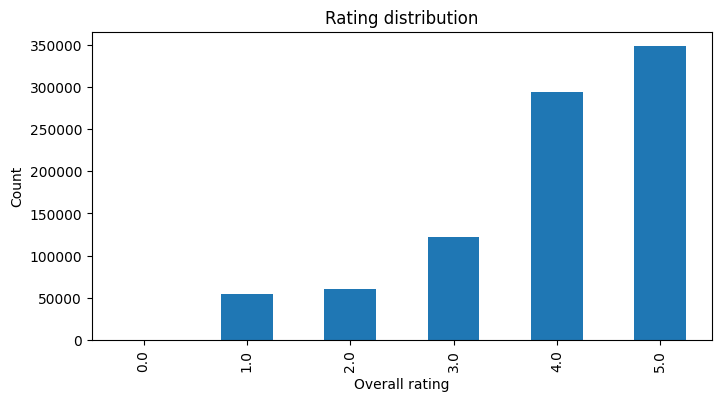

In [586]:
rating_counts = eda_df["overall_rating"].value_counts().sort_index()

display(rating_counts.to_frame(name="count"))

plt.figure(figsize=(8, 4))
rating_counts.plot(kind="bar")
plt.title("Rating distribution")
plt.xlabel("Overall rating")
plt.ylabel("Count")
plt.show()

The rating distribution is heavily skewed toward the positive end of the scale. Ratings of 4.0 and 5.0 dominate the dataset, with 293,727 and 348,319 observations respectively, while low ratings are much less frequent and zero ratings are almost absent. This indicates that the platform mostly captures favorable experiences rather than a balanced mix of positive and negative feedback.

For recommendation, this matters because the signal is less about separating liked from disliked hotels and more about ranking among many positively rated ones. In other words, explicit feedback exists, but it is only weakly contrastive. This helps explain why ranking performance may remain challenging even when a model predicts ratings reasonably well.

### 3.4 User activity and item popularity

In recommender systems, interactions are rarely evenly distributed. Usually:

- many users contribute very few ratings
- many items receive very little feedback
- a relatively small subset of users and items accounts for a large share of all interactions

This long-tail structure is important because it affects both model design and interpretation. Strong concentration on a few highly rated hotels tends to favor popularity-based recommenders, while very low user activity makes personalization more difficult.

In [587]:
user_activity = eda_df.groupby("username").size().rename("n_interactions")
item_popularity = eda_df.groupby("offering_id").size().rename("n_interactions")

print("User activity summary")
display(user_activity.describe())

print("Item popularity summary")
display(item_popularity.describe())

User activity summary


count    536952.000000
mean          1.636200
std         105.182584
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max       77067.000000
Name: n_interactions, dtype: float64

Item popularity summary


count    3945.000000
mean      222.702408
std       390.880282
min         1.000000
25%        21.000000
50%        69.000000
75%       259.000000
max      5456.000000
Name: n_interactions, dtype: float64

The activity distributions reveal a classic long-tail structure on both sides of the interaction graph. User activity is extremely concentrated at the minimum: the 25th, 50th, and 75th percentiles are all equal to 1, meaning that at least three quarters of users contribute only a single interaction. The mean is 1.6362, but this average is misleading because it is inflated by a very small number of highly active users.

Item popularity is also highly uneven. Although the average hotel receives 222.7 interactions, the median is only 69, the 25th percentile is 21, and the most popular hotel reaches 5,456 interactions. This imbalance suggests that a dense popularity core coexists with a very broad tail of weakly observed hotels.

Together, these statistics anticipate two difficulties for personalized recommendation. First, many users have too little history to support robust user profiling. Second, many items have limited evidence, making similarity estimation and ranking less stable. This is exactly the type of regime where popularity-based baselines can remain surprisingly strong.

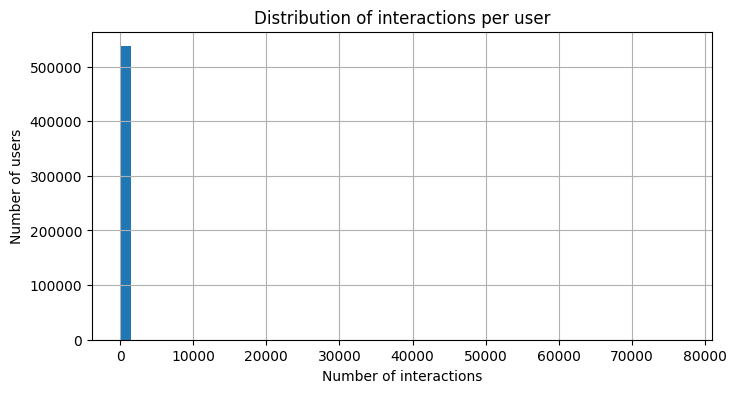

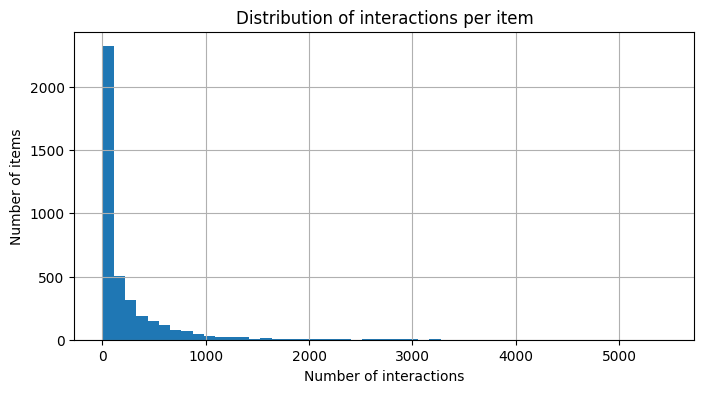

In [588]:
plt.figure(figsize=(8, 4))
user_activity.hist(bins=50)
plt.title("Distribution of interactions per user")
plt.xlabel("Number of interactions")
plt.ylabel("Number of users")
plt.show()

plt.figure(figsize=(8, 4))
item_popularity.hist(bins=50)
plt.title("Distribution of interactions per item")
plt.xlabel("Number of interactions")
plt.ylabel("Number of items")
plt.show()

The histograms make the long-tail pattern visually explicit. For users, the distribution is sharply concentrated near zero with a massive spike at very low interaction counts and a tiny number of extreme outliers. For items, most hotels receive relatively limited feedback, while only a small subset accumulates very high visibility.

These plots are useful because the descriptive statistics alone can hide how asymmetric the data really are. In practical terms, the recommender will operate in a setting where most users are nearly cold-start and most hotels are modestly observed, while a few very popular hotels dominate the evidence available to the model.

### 3.5 Long-tail concentration

A useful way to summarize concentration is to ask how much of the interaction volume is captured by the most active users and the most popular hotels. If a small portion of items captures a very large share of the ratings, then recommending globally popular hotels becomes a strong baseline almost by construction.

In [589]:
def concentration_table(counts, name="entity"):
    counts_sorted = counts.sort_values(ascending=False).reset_index(drop=True)
    shares = counts_sorted.cumsum() / counts_sorted.sum()

    out = pd.DataFrame({
        name: ["Top 1%", "Top 5%", "Top 10%", "Top 20%"],
        "share_of_interactions": [
            shares.iloc[max(0, int(len(shares) * 0.01) - 1)] if len(shares) > 0 else np.nan,
            shares.iloc[max(0, int(len(shares) * 0.05) - 1)] if len(shares) > 0 else np.nan,
            shares.iloc[max(0, int(len(shares) * 0.10) - 1)] if len(shares) > 0 else np.nan,
            shares.iloc[max(0, int(len(shares) * 0.20) - 1)] if len(shares) > 0 else np.nan,
        ]
    })
    return out

print("Concentration across users")
display(concentration_table(user_activity, name="user_group"))

print("Concentration across items")
display(concentration_table(item_popularity, name="item_group"))

Concentration across users


,user_group,share_of_interactions
0,Top 1%,0.164706
1,Top 5%,0.280446
2,Top 10%,0.369414
3,Top 20%,0.491648


Concentration across items


,item_group,share_of_interactions
0,Top 1%,0.122095
1,Top 5%,0.342707
2,Top 10%,0.509156
3,Top 20%,0.715352


The concentration tables quantify how much of the platform activity is captured by a relatively small core. The top 1% of users account for 16.47% of all interactions, while the top 20% account for 49.16%. On the item side, concentration is even stronger: the top 10% of hotels capture 50.92% of all interactions, and the top 20% capture 71.54%.

This is a crucial recommender-system result. When such a large share of interaction volume is concentrated on a limited subset of hotels, global popularity becomes a structurally strong signal rather than a naive heuristic. At the same time, the user-side concentration confirms that most of the audience contributes very weak behavioral evidence, which makes personalized collaborative methods harder to estimate reliably.

### 3.6 Temporal coverage

Since our later evaluation is time-aware, it is useful to inspect how interactions are distributed over time. This helps verify that the dataset spans a sufficiently long period and supports a realistic temporal recommendation task in which future interactions are predicted from past behavior.

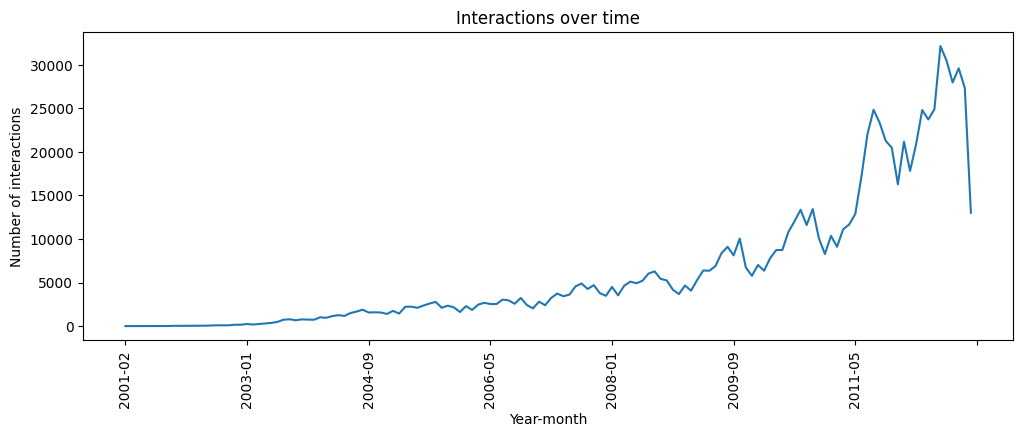

In [590]:
ratings_over_time = (
    eda_df.assign(year_month=eda_df["date"].dt.to_period("M").astype(str))
    .groupby("year_month")
    .size()
)

plt.figure(figsize=(12, 4))
ratings_over_time.plot()
plt.title("Interactions over time")
plt.xlabel("Year-month")
plt.ylabel("Number of interactions")
plt.xticks(rotation=90)
plt.show()

The temporal profile shows that interaction volume grows substantially over time rather than remaining stationary. Early years contain relatively few observations, while activity accelerates markedly in the later part of the dataset, especially from around 2009 onward. This means that the platform evolves from a low-data regime into a much denser one over time.

This matters for both modeling and evaluation. A random split would mix early sparse periods with later denser periods and could allow information from the future to influence training. The observed time trend therefore supports the choice of a temporal evaluation protocol, where the model is asked to predict later behavior from earlier evidence.

### 3.7 EDA summary
The exploratory analysis highlights four structural properties of this recommendation problem. First, the user–item matrix is extremely sparse, so personalized methods cannot rely on broad overlap across the whole population. Second, the rating distribution is heavily skewed toward positive scores, meaning that the task is less about separating clearly liked from clearly disliked hotels and more about ranking among many positively rated items. Third, interactions are strongly concentrated on a relatively small popularity core, which makes non-personalized baselines more meaningful than they might initially appear. Fourth, activity changes substantially over time, so evaluation should preserve chronology.

These findings are not only descriptive; they directly motivate the modeling choices used in the rest of the notebook. In particular, they explain why we reduce the dataset before applying collaborative filtering, why popularity-based baselines deserve serious attention, and why a temporal split is preferable to a random one for offline evaluation.

## 4. Non-personalized recommenders

We now introduce a set of non-personalized recommenders to serve as baseline models. These methods do not tailor recommendations to the individual user; instead, they rely on global information extracted from the training data or on uninformed exploration.

Even though they are simple, these baselines are extremely important in recommender-system analysis. First, they provide transparent reference points against which more sophisticated personalized models must be compared. Second, in sparse datasets, simple popularity-driven rules can remain surprisingly competitive because user-specific signal is limited. Third, they help clarify the trade-off between relevance, coverage, robustness, and exploration.

In this section, we implement four baseline recommenders:

- **Random**, which samples unseen hotels uniformly at random  
- **Popular**, which ranks hotels by observed average rating  
- **Bayesian Popular**, which regularizes item means toward the global average to reduce instability for low-support items  
- **Weighted Popular**, which combines quality and exposure by favoring well-rated hotels with stronger interaction support  

These baselines are intentionally simple, but they are methodologically essential: before asking whether personalization helps, we must first understand how much can already be achieved using only global catalog structure.

### 4.1 Why non-personalized baselines matter

Non-personalized recommenders are not meant to represent the final answer to the recommendation problem, but they are indispensable analytical benchmarks. If a personalized recommender cannot clearly outperform a strong popularity-based baseline, then its practical value is limited despite its additional complexity.

Different non-personalized strategies also reflect different recommendation objectives:

- **Random** emphasizes exploration and maximizes catalog dispersion  
- **Popular** emphasizes broad agreement and exposes the most widely appreciated items  
- **Bayesian Popular** adds statistical caution by discounting extreme averages supported by very few ratings  
- **Weighted Popular** captures a pragmatic compromise between item quality and item visibility  

For this reason, these baselines are useful not only for comparison, but also for interpretation. They help us understand whether the recommendation task is driven mainly by shared global preferences or whether there is enough user-specific structure to justify more advanced personalization.

### 4.2 Training data for non-personalized baselines

The non-personalized recommenders are fit only on the temporal training set. This is important because even very simple popularity statistics must be estimated using only information that would have been available at recommendation time.

Using the training split preserves the causal structure of the problem: recommendations are generated from past interactions, while evaluation is performed on future held-out behavior. This prevents leakage from the test set and ensures that even the simplest baselines are assessed under the same realistic protocol used later for collaborative, content-based, and hybrid recommenders.

In [591]:
baseline_train_df = train_df[["username", "offering_id", "overall_rating", "date"]].copy()
baseline_test_df = test_df[["username", "offering_id", "overall_rating", "date"]].copy()

print("Baseline train shape:", baseline_train_df.shape)
print("Baseline test shape:", baseline_test_df.shape)

Baseline train shape: (116681, 4)
Baseline test shape: (3937, 4)


### 4.3 Random recommender

The Random recommender samples unseen hotels uniformly from the candidate catalog. It is not expected to provide strong relevance, but it plays an important conceptual role.

First, it acts as a lower-bound benchmark for recommendation quality. Second, it represents pure exploration, since it does not exploit any historical evidence about item quality or popularity. Third, it tends to generate extremely high coverage and personalization because different users are likely to receive different recommendation lists.

For these reasons, Random is less interesting as a practical recommender than as a diagnostic baseline: it tells us what performance looks like when no preference modeling is used at all.

In [592]:
all_train_items = set(baseline_train_df["offering_id"].unique())

seen_items_train = (
    baseline_train_df.groupby("username")["offering_id"]
    .apply(set)
    .to_dict()
)

In [593]:
def recommend_random(user_id, all_items, seen_items_dict, top_k=10, random_state=42):
    rng = np.random.default_rng(random_state + abs(hash(str(user_id))) % (10**6))

    seen_items = seen_items_dict.get(user_id, set())
    candidates = list(all_items - seen_items)

    if len(candidates) == 0:
        return pd.DataFrame(columns=["offering_id", "score"])

    chosen = rng.choice(candidates, size=min(top_k, len(candidates)), replace=False)

    return pd.DataFrame({
        "offering_id": chosen,
        "score": np.nan
    }).reset_index(drop=True)

### 4.4 Popular recommender

The Popular recommender ranks hotels according to their average observed rating in the training data. Its logic is straightforward: if a hotel is consistently rated highly across many users, then it is a natural candidate for broad recommendation.

This model ignores individual taste completely, but it can still be strong in sparse environments, especially when users tend to converge on a relatively small set of widely appreciated hotels. In that sense, it captures the global consensus of the dataset.

Its main weakness is statistical instability: an item with very few ratings can appear near the top simply because of a small-sample fluctuation. This limitation motivates the regularized version introduced next.

In [594]:
def filter_seen_items(user_id, ranked_items, seen_items_dict, top_k=10):
    seen_items = seen_items_dict.get(user_id, set())
    unseen_ranked_items = [item for item in ranked_items if item not in seen_items]
    return unseen_ranked_items[:top_k]


popular_item_scores = (
    baseline_train_df.groupby("offering_id")["overall_rating"]
    .mean()
    .sort_values(ascending=False)
)

display(popular_item_scores.head(10).to_frame(name="mean_rating"))

popular_ranked_items = popular_item_scores.index.tolist()


def recommend_popular(user_id, popular_scores, seen_items_dict, top_k=10):
    ranked_items = popular_scores.index.tolist()
    filtered_items = filter_seen_items(
        user_id,
        ranked_items,
        seen_items_dict,
        top_k=top_k
    )

    recs = pd.DataFrame({
        "offering_id": filtered_items,
        "score": [popular_scores.loc[item] for item in filtered_items]
    })

    return recs

,mean_rating
offering_id,
1778319,4.962963
112052,4.944444
1199588,4.903226
1762662,4.875000
656430,4.862069
781627,4.857143
2196840,4.851852
1516481,4.837209
2322597,4.833333


### 4.5 Bayesian Popular recommender

A limitation of the plain Popular recommender is that item means can be unreliable when the number of ratings is small. A hotel with only a handful of reviews may achieve a very high average purely by chance, even though there is little evidence that it should be recommended broadly.

To address this issue, we use a Bayesian-style shrinkage estimator that pulls each hotel's empirical mean toward the global mean. The strength of this shrinkage depends on the number of observed ratings: low-support hotels are regularized more strongly, while high-support hotels remain close to their empirical average.

This produces a more conservative popularity ranking, where strong scores are rewarded only when they are supported by enough evidence. In practice, Bayesian Popular often provides a more reliable baseline than raw average rating.

In [595]:
global_mean_rating = baseline_train_df["overall_rating"].mean()
item_stats = baseline_train_df.groupby("offering_id")["overall_rating"].agg(["mean", "count"])

# Prior strength
BAYES_M = 20

item_stats["bayesian_score"] = (
    (item_stats["count"] * item_stats["mean"] + BAYES_M * global_mean_rating)
    / (item_stats["count"] + BAYES_M)
)

bayesian_item_scores = item_stats["bayesian_score"].sort_values(ascending=False)

display(item_stats.sort_values("bayesian_score", ascending=False).head(10))

,mean,count,bayesian_score
offering_id,,,
258705,4.741117,197,4.662737
1199588,4.903226,62,4.656267
1503474,4.740741,135,4.631057
208454,4.652459,610,4.628276
224214,4.686667,150,4.593023
99762,4.755814,86,4.592584
1762573,4.752941,85,4.588704
674283,4.773333,75,4.587514
1888977,4.743902,82,4.576607


In [596]:
def recommend_bayesian_popular(user_id, bayesian_scores, seen_items_dict, top_k=10):
    seen_items = seen_items_dict.get(user_id, set())

    recs = (
        bayesian_scores[~bayesian_scores.index.isin(seen_items)]
        .head(top_k)
        .reset_index()
    )
    recs.columns = ["offering_id", "score"]

    return recs

### 4.5 Weighted Popular

The Weighted Popular recommender introduces a different popularity logic: instead of correcting unstable means through shrinkage, it explicitly combines item quality and item support into a single score.

The goal is to favor hotels that are not only well rated, but also sufficiently established in the interaction data. Compared with plain Popular, this tends to push highly visible and broadly reviewed hotels upward, while reducing the influence of niche items whose averages may look attractive but are based on weaker evidence.

This baseline is useful because it reflects a common production intuition: in many real applications, recommendation value depends not only on estimated quality, but also on confidence, robustness, and broad user acceptance.

In [597]:
item_stats = baseline_train_df.groupby("offering_id")["overall_rating"].agg(["mean", "count"])

# Mild quality-adjusted popularity
item_stats["weighted_pop_score"] = item_stats["count"] * (item_stats["mean"] ** 0.5)

weighted_pop_scores = item_stats["weighted_pop_score"].sort_values(ascending=False)

display(item_stats.sort_values("weighted_pop_score", ascending=False).head(10))

,mean,count,weighted_pop_score
offering_id,,,
214197,2.685330,1786,2926.714199
93346,4.246180,1178,2427.417558
93520,3.529620,1131,2124.841641
122005,4.113226,998,2024.052865
93569,4.245595,908,1870.919560
99766,3.722098,896,1728.629515
93516,3.993873,816,1630.749521
93358,4.169680,719,1468.183231
208454,4.652459,610,1315.743136


In [598]:
def recommend_weighted_popular(user_id, weighted_scores, seen_items_dict, top_k=10):
    seen_items = seen_items_dict.get(user_id, set())

    recs = (
        weighted_scores[~weighted_scores.index.isin(seen_items)]
        .head(top_k)
        .reset_index()
    )
    recs.columns = ["offering_id", "score"]

    return recs

### 4.6 Qualitative recommendation examples

Before moving to the common evaluation stage, we inspect the top-$K$ lists produced by the four non-personalized recommenders for one example user. This is mainly a sanity-check step.

The purpose is to verify that the recommenders generate valid unseen candidates, that the score logic is coherent with the intended design of each method, and that the resulting recommendation lists are qualitatively plausible. Even simple baselines benefit from this type of manual inspection, since it helps detect implementation issues before large-scale offline evaluation.

In [599]:
example_user_baseline = baseline_test_df["username"].iloc[0]
print("Example user:", example_user_baseline)
print("Seen items in train:", len(seen_items_train.get(example_user_baseline, set())))

Example user: 
Seen items in train: 1404


In [601]:
random_example = recommend_random(
    user_id=example_user_baseline,
    all_items=all_train_items,
    seen_items_dict=seen_items_train,
    top_k=TOP_K,
    random_state=42
)

popular_example = recommend_popular(
    user_id=example_user_baseline,
    popular_scores=popular_item_scores,
    seen_items_dict=seen_items_train,
    top_k=TOP_K
)

bayesian_example = recommend_bayesian_popular(
    user_id=example_user_baseline,
    bayesian_scores=bayesian_item_scores,
    seen_items_dict=seen_items_train,
    top_k=TOP_K
)

weighted_example = recommend_weighted_popular(
    user_id=example_user_baseline,
    weighted_scores=weighted_pop_scores,
    seen_items_dict=seen_items_train,
    top_k=TOP_K
)

def attach_hotel_names(recs_df, name_map):
    out = recs_df.copy()
    if not out.empty:
        out["hotel_name"] = out["offering_id"].map(name_map)
    return out

offer_name_map = offers_df.set_index("id")["name"].to_dict()

print("Random recommendations")
display(attach_hotel_names(random_example, offer_name_map))

print("Popular recommendations")
display(attach_hotel_names(popular_example, offer_name_map))

print("Bayesian Popular recommendations")
display(attach_hotel_names(bayesian_example, offer_name_map))

print("Weighted Popular recommendations")
display(attach_hotel_names(weighted_example, offer_name_map))

Random recommendations


,offering_id,score,hotel_name
0,1456261,NaN,W Washington DC
1,1675976,NaN,The Westin Austin at The Domain
2,114948,NaN,Luxe Stoneleigh Hotel & Spa
3,208452,NaN,Conrad New York
4,674606,NaN,Homewood Suites by Hilton Baltimore
5,1371825,NaN,Smyth Hotel - A Thompson Hotel
6,659532,NaN,Ritz-Carlton Dallas
7,2015227,NaN,Westin Phoenix Downtown
8,878358,NaN,"The Ritz-Carlton, Denver"
9,1157336,NaN,Hilton Columbus/Polaris


Popular recommendations


,offering_id,score,hotel_name
0,781627,4.857143,The Grand Del Mar
1,2196840,4.851852,Inn at The Black Olive
2,1516481,4.837209,Waldorf Astoria Chicago
3,2322597,4.833333,Four Seasons Baltimore
4,1746459,4.806452,The Nolitan Hotel
5,1152288,4.750000,Four Seasons Hotel Seattle
6,1140713,4.666667,Comfort Suites Alamo/Riverwalk
7,1845691,4.666667,Four Seasons Hotel Denver
8,878358,4.653846,"The Ritz-Carlton, Denver"
9,2192761,4.642857,Omni Dallas Hotel


Bayesian Popular recommendations


,offering_id,score,hotel_name
0,1516481,4.536728,Waldorf Astoria Chicago
1,781627,4.505707,The Grand Del Mar
2,1152288,4.463564,Four Seasons Hotel Seattle
3,2322597,4.456277,Four Seasons Baltimore
4,1746459,4.447331,The Nolitan Hotel
5,2196840,4.442848,Inn at The Black Olive
6,1889883,4.422108,W Austin
7,1675976,4.410852,The Westin Austin at The Domain
8,1845691,4.403625,Four Seasons Hotel Denver
9,1140713,4.373847,Comfort Suites Alamo/Riverwalk


Weighted Popular recommendations


,offering_id,score,hotel_name
0,1449313,120.797351,"Monaco Baltimore, a Kimpton Hotel"
1,1675976,117.961858,The Westin Austin at The Domain
2,1889883,113.951744,W Austin
3,98452,104.182532,Sheraton Austin at the Capitol
4,1456261,103.213371,W Washington DC
5,1516481,94.572723,Waldorf Astoria Chicago
6,1584731,90.388052,JW Marriott San Antonio Hill Country Resort & Spa
7,1152288,87.177979,Four Seasons Hotel Seattle
8,1845691,84.249629,Four Seasons Hotel Denver
9,1045286,78.943017,Springhill Suites Chicago Downtown / River North


### 4.7 Generating top-$K$ recommendations for all test users

To prepare the later joint evaluation, we now generate top-$K$ recommendation tables for all users in the temporal test set. Each recommender is applied under the same protocol so that the outputs can later be compared fairly using the same ranking metrics.

This step is important because it standardizes the evaluation interface across models. Regardless of how a recommender computes its scores, the final object of interest is the same: a ranked list of unseen candidate hotels for each user.

In [602]:
def generate_recommendations_for_users(
    user_ids,
    recommender_fn,
    top_k,
    progress_every=1000,
    **kwargs
):
    all_recs = []

    for idx, user_id in enumerate(user_ids, start=1):
        recs = recommender_fn(user_id=user_id, top_k=top_k, **kwargs)

        if recs is not None and len(recs) > 0:
            recs = recs.copy()
            recs["username"] = user_id
            recs["rank"] = range(1, len(recs) + 1)
            all_recs.append(recs)

        if progress_every is not None and progress_every > 0 and idx % progress_every == 0:
            print(f"Processed {idx:,} / {len(user_ids):,} users")

    if len(all_recs) == 0:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank"])

    return pd.concat(all_recs, ignore_index=True)

In [603]:
test_users = baseline_test_df["username"].unique()

random_recs = generate_recommendations_for_users(
    user_ids=test_users,
    recommender_fn=recommend_random,
    top_k=TOP_K,
    progress_every=1000,
    all_items=all_train_items,
    seen_items_dict=seen_items_train,
    random_state=42
)

popular_recs = generate_recommendations_for_users(
    user_ids=test_users,
    recommender_fn=recommend_popular,
    top_k=TOP_K,
    progress_every=1000,
    popular_scores=popular_item_scores,
    seen_items_dict=seen_items_train
)

bayesian_recs = generate_recommendations_for_users(
    user_ids=test_users,
    recommender_fn=recommend_bayesian_popular,
    top_k=TOP_K,
    progress_every=1000,
    bayesian_scores=bayesian_item_scores,
    seen_items_dict=seen_items_train
)

weighted_pop_recs = generate_recommendations_for_users(
    user_ids=test_users,
    recommender_fn=recommend_weighted_popular,
    top_k=TOP_K,
    progress_every=1000,
    weighted_scores=weighted_pop_scores,
    seen_items_dict=seen_items_train
)

print("Random recommendations shape:", random_recs.shape)
print("Popular recommendations shape:", popular_recs.shape)
print("Bayesian recommendations shape:", bayesian_recs.shape)
print("Weighted Popular recommendations shape:", weighted_pop_recs.shape)

Processed 1,000 / 3,937 users
Processed 2,000 / 3,937 users
Processed 3,000 / 3,937 users
Processed 1,000 / 3,937 users
Processed 2,000 / 3,937 users
Processed 3,000 / 3,937 users
Processed 1,000 / 3,937 users
Processed 2,000 / 3,937 users
Processed 3,000 / 3,937 users
Processed 1,000 / 3,937 users
Processed 2,000 / 3,937 users
Processed 3,000 / 3,937 users
Random recommendations shape: (39370, 4)
Popular recommendations shape: (39370, 4)
Bayesian recommendations shape: (39370, 4)
Weighted Popular recommendations shape: (39370, 4)


### 4.8 Summary of the non-personalized baselines

The baseline family developed in this section covers four complementary recommendation logics. **Random** represents pure exploration and serves as a lower-bound benchmark. **Popular** captures global consensus through average item quality. **Bayesian Popular** makes that consensus more statistically reliable by shrinking low-support estimates toward the global mean. **Weighted Popular** instead favors hotels that combine good ratings with strong interaction support.

Taken together, these models provide a useful map of what can be achieved without personalization. They also establish interpretable reference points for the chapters that follow. If later collaborative, content-based, or hybrid methods outperform these baselines, we will be able to attribute that gain to actual user- or item-level modeling rather than to simple global popularity effects.

In a sparse recommendation setting like this one, such baselines are not merely formalities. They are strong methodological anchors, and in some cases they may remain surprisingly competitive. For that reason, they should be treated as serious benchmarks rather than as trivial preliminary models.

## 5. Memory-based collaborative filtering recommenders

Memory-based collaborative filtering uses the observed user-item interaction matrix directly, without learning a parametric latent model. The main idea is that recommendations can be inferred from patterns of local similarity in historical behavior. In the user-based version, we identify users with similar rating profiles and recommend items liked by their neighbors. In the item-based version, we identify items that tend to be rated similarly and recommend items related to those already appreciated by the target user.

These methods are especially appealing because they are highly interpretable: recommendations are produced by observable neighborhoods rather than by hidden latent factors. At the same time, they depend strongly on the overlap structure of the interaction matrix. If users share very few co-rated hotels, user-user similarities become unstable; if item-item co-rating patterns are weak or noisy, item-based prediction also deteriorates.

For this reason, memory-based recommenders are a natural next step after the non-personalized baselines. They introduce personalization while remaining conceptually simple, but they also provide an important test of whether the reduced dataset contains enough neighborhood structure for nearest-neighbor recommendation to work reliably.

### 5.1 User-based and item-based collaborative filtering

Let $R \in \mathbb{R}^{m \times n}$ denote the user-item rating matrix, where $r_{ui}$ is the rating given by user $u$ to item $i$, when observed.

#### User-based collaborative filtering

For a target user $u$, we compute the similarity between $u$ and all other users $v$. A predicted score for an unseen item $i$ is then obtained by aggregating the ratings of the most similar users who have rated $i$.

A common formulation is:

$$
\hat{r}_{ui} =
\frac{\sum_{v \in \mathcal{N}_u(i)} s(u,v)\, r_{vi}}
{\sum_{v \in \mathcal{N}_u(i)} |s(u,v)|}
$$

where:

- $s(u,v)$ is the similarity between users $u$ and $v$
- $\mathcal{N}_u(i)$ is the set of neighbor users of $u$ who rated item $i$

#### Item-based collaborative filtering

For a target user $u$, we compute similarities between items. The predicted score for an unseen item $i$ is obtained from the ratings that user $u$ has given to items similar to $i$:

$$
\hat{r}_{ui} =
\frac{\sum_{j \in \mathcal{N}_i(u)} s(i,j)\, r_{uj}}
{\sum_{j \in \mathcal{N}_i(u)} |s(i,j)|}
$$

where:

- $s(i,j)$ is the similarity between items $i$ and $j$
- $\mathcal{N}_i(u)$ is the set of neighbor items to $i$ already rated by user $u$

#### Similarity choice

A natural choice is cosine similarity. If $x$ and $y$ are two rating vectors, then:

$$
\operatorname{cosine}(x,y) =
\frac{x^\top y}{\|x\|\|y\|}
$$

Cosine similarity is attractive because it compares rating patterns geometrically, focusing on the angle between vectors rather than their absolute scale. In sparse recommender settings, it is often a stable first choice for both user-user and item-item similarity.

In [604]:
# Training data for memory-based collaborative filtering
memory_train_df = train_df[["username", "offering_id", "overall_rating"]].copy()

print("Memory-based CF training data")
basic_stats(memory_train_df, "username", "offering_id")
summarize_interactions(memory_train_df, "username", "offering_id", "overall_rating")

Memory-based CF training data
There are 116681 ratings from 3937 users to 1444 items
Number of users:        3,937
Number of items:        1,444
Number of interactions: 116,681
Sparsity:               0.979476
Rating mean:            3.8907
Rating std:             1.1554
Rating min:             1.0000
Rating max:             5.0000


### 5.2 Building the user-item interaction matrix

The memory-based recommenders are built only on the temporal training set, not on the full reduced dataset. This is essential to preserve the time-aware evaluation protocol: recommendations must be generated using only information that would have been available before the held-out test interaction occurred.

We therefore represent the training data as a user-item matrix in which rows correspond to users, columns correspond to hotels, and entries contain observed ratings when available. This matrix is the central object for all neighborhood-based computations that follow.

In [605]:
# User-item matrix built from training data only
user_item_matrix = memory_train_df.pivot_table(
    index="username",
    columns="offering_id",
    values="overall_rating",
    aggfunc="mean"
)

print("User-item matrix shape:", user_item_matrix.shape)
user_item_matrix.head()

User-item matrix shape: (3937, 1444)


offering_id,72572,72579,72586,73644,73757,73792,73821,73855,73862,73943,73947,73957,74363,74370,74548,74626,74758,75688,75698,75711,75737,76049,76061,76083,76442,76741,77157,77237,77243,77247,77256,77270,77274,77277,77282,77638,77700,77708,77714,77729,77753,77775,77787,77798,77804,77809,77827,77829,77852,77866,77870,77874,77888,77917,77923,77931,77944,77970,78037,78046,78682,78688,78694,79228,79868,79880,79902,79907,79913,79930,79942,79954,79971,79977,79981,79985,80004,80014,80075,80081,80083,80087,80093,80106,80107,80109,80112,80113,80131,80133,80167,80189,80193,80198,80219,80223,80227,80232,80244,80251,80255,80266,80291,80311,80350,80423,80530,80562,80582,80590,80593,80602,80618,80643,80654,80668,80689,80708,80733,80735,80747,80756,80757,80766,80768,80771,80774,80780,80786,80788,80793,80797,80799,80802,80806,80808,80817,80821,80823,80836,80879,80917,80920,80925,80930,80937,80950,80983,80987,80990,80999,81004,81019,81022,81023,81035,81038,81042,81049,81082,81087,81103,81110,81114,81141,81150,81165,81169,81170,81177,81192,81204,81209,81212,81215,81222,81237,81241,81246,81249,81251,81295,81302,81315,81363,81375,81377,81394,81397,81409,81416,81418,81444,81450,81459,81461,81466,81476,81503,81511,81514,81520,81529,81531,81669,81672,81679,81695,81699,81705,81782,81803,81959,81985,82013,82105,82114,82148,82156,82190,82443,82478,82491,82501,82578,82636,82650,82679,82686,82689,82868,82960,82961,82982,83020,83040,83046,83051,83057,83070,83088,83091,83093,83097,83099,83245,83361,83500,83575,83637,83646,83660,83711,84032,84033,84038,84039,84041,84047,84048,84051,84052,84058,84060,84062,84064,84065,84066,84067,84068,84069,84070,84072,84073,84074,84075,84078,84079,84080,84081,84082,84083,84084,84086,84087,84090,84092,84093,84095,84096,84098,84100,84101,84104,84107,84109,84113,84115,84117,84120,84122,84125,84127,84129,84131,84132,84137,84167,84182,84253,84320,84422,84440,84453,84463,84499,84502,84505,84515,84522,84553,84555,84561,84655,84656,84658,85325,85332,85343,85344,85346,85357,85368,87566,87571,87573,87576,87590,87592,87595,87602,87603,87608,87613,87617,87618,87620,87627,87629,87632,87635,87637,87638,87640,87645,87648,87654,87656,87657,87659,88155,88164,88168,88171,88173,88175,88186,88188,88395,88408,88442,88460,89327,89331,89336,89337,89343,89344,89346,89351,89353,89358,89361,89382,89568,89575,89585,89592,89599,89600,89602,89615,89617,89619,89620,89998,90003,90916,90918,90922,90955,90957,90959,90963,90969,90973,90975,90976,90985,90986,91042,91440,91484,91558,91573,91602,93333,93334,93335,93337,93338,93339,93340,93344,93345,93346,93351,93352,93356,93357,93358,93359,93364,93374,93376,93379,93382,93383,93390,93396,93398,93401,93403,93419,93421,93430,93431,93435,93437,93440,93445,93450,93452,93454,93457,93462,93464,93466,93467,93470,93475,93477,93486,93489,93507,93516,93517,93520,93525,93526,93534,93539,93543,93545,93555,93561,93562,93565,93566,93568,93569,93571,93575,93579,93586,93589,93603,93606,93607,93610,93612,93614,93618,93622,93623,93624,93625,93889,94085,94122,94133,94136,94163,94166,94171,94326,94330,94337,94344,94350,94354,94367,94368,94371,94372,94399,94554,95253,95258,95269,95286,95288,95293,95294,95302,96686,96688,96698,96705,96711,96712,96715,96721,96730,96735,96737,98031,98039,98062,98418,98419,98436,98438,98439,98443,98452,98453,98457,98463,98464,98474,98606,98609,98629,98631,98639,98640,98641,98650,98679,98683,98710,98717,98719,98726,98727,98728,98731,98798,98805,98849,98856,98944,98952,98954,98956,98979,98987,98997,99006,99007,99010,99054,99060,99081,99101,99103,99106,99109,99110,99114,99135,99281,99287,99288,99302,99307,99321,99327,99332,99333,99352,99354,99357,99365,99368,99371,99382,99387,99388,99391,99392,99423,99425,99434,99441,99443,99445,99447,99451,99453,99455,99458,99462,99464,99468,99470,99476,99485,99487,99488,99489,99494,99504,99513,99518,99530,99531,99535,99540,99762,99766,99774,100504,100505,100507,100508,100509,100518,100527,100537,100540,100542,100544,100547,100554,100560,100561,100562,100564,100565,1005

### 5.3 Computing user-user and item-item similarities

To construct the memory-based recommenders, we compute two similarity matrices:

- a **user-user similarity matrix** for user-based collaborative filtering  
- an **item-item similarity matrix** for item-based collaborative filtering  

For this first prototype, missing ratings are temporarily replaced with zero during cosine-similarity computation. This is a simple and common baseline choice: unobserved interactions do not contribute positive overlap, while observed rating patterns determine geometric proximity between users or items.

This representation is computationally convenient, but it should also be interpreted carefully. In sparse data, zero-filled similarity can penalize users who simply have not overlapped enough, rather than users who are genuinely dissimilar. As a result, the reliability of the user-based neighborhood structure is expected to be weaker than that of the item-based structure.

In [606]:
from sklearn.metrics.pairwise import cosine_similarity

# Fill missing ratings with zero for similarity computation
user_item_filled = user_item_matrix.fillna(0)

# User-user cosine similarity
user_similarity_matrix = pd.DataFrame(
    cosine_similarity(user_item_filled),
    index=user_item_filled.index,
    columns=user_item_filled.index
)

# Item-item cosine similarity
item_similarity_matrix = pd.DataFrame(
    cosine_similarity(user_item_filled.T),
    index=user_item_filled.columns,
    columns=user_item_filled.columns
)

print("User similarity matrix shape:", user_similarity_matrix.shape)
print("Item similarity matrix shape:", item_similarity_matrix.shape)

User similarity matrix shape: (3937, 3937)
Item similarity matrix shape: (1444, 1444)


### 5.4 User-based collaborative filtering

In the user-based approach, the predicted score of a candidate hotel for a target user is estimated from the ratings assigned to that hotel by similar users. To reduce the effect of scale differences across users, we use a mean-centered formulation: each neighbor contributes according to how much their rating deviates from their own average behavior.

We also impose practical restrictions to improve stability. Only neighbors with positive similarity are retained, prediction is limited to the top-\(k\) most similar users, and fallback rules are used when too little valid neighborhood evidence is available.

This is an important refinement because raw user-based CF is particularly vulnerable in sparse recommender datasets. Even after dataset reduction, many users still have limited overlap with others, so prediction quality depends heavily on whether sufficiently informative neighborhoods can actually be found.

In [607]:
def predict_user_based_score_centered(
    user_id,
    item_id,
    user_item_matrix,
    user_similarity_matrix,
    user_means,
    k_neighbors=20,
    min_neighbors=2,
    fallback="user_mean"
):
    """
    Mean-centered user-based CF prediction.

    r_hat(u,i) = mean_u + sum_v sim(u,v) * (r_vi - mean_v) / sum_v |sim(u,v)|

    Parameters
    ----------
    user_id : hashable
    item_id : hashable
    user_item_matrix : pd.DataFrame
        Rows = users, columns = items, values = ratings.
    user_similarity_matrix : pd.DataFrame
        User-user similarity matrix.
    user_means : pd.Series
        Mean rating for each user.
    k_neighbors : int
        Max number of neighbors.
    min_neighbors : int
        Minimum number of valid neighbors required.
    fallback : str
        One of {"user_mean", "item_mean", "global_mean"}.
    """

    if item_id not in user_item_matrix.columns:
        return np.nan
    if user_id not in user_item_matrix.index:
        return np.nan

    item_ratings = user_item_matrix[item_id].dropna()
    if item_ratings.empty:
        return np.nan

    # candidate neighbors who rated item
    sims = user_similarity_matrix.loc[user_id, item_ratings.index].drop(index=user_id, errors="ignore")

    # keep only positive sims
    sims = sims[sims > 0]
    if sims.empty:
        if fallback == "user_mean":
            return user_means.get(user_id, np.nan)
        elif fallback == "item_mean":
            return item_ratings.mean()
        elif fallback == "global_mean":
            return user_item_matrix.stack().mean()
        return np.nan

    sims = sims.sort_values(ascending=False).head(k_neighbors)
    neighbor_ratings = item_ratings.loc[sims.index]
    neighbor_means = user_means.loc[sims.index]

    deviations = neighbor_ratings - neighbor_means
    denom = np.abs(sims).sum()

    if len(sims) < min_neighbors or denom == 0:
        if fallback == "user_mean":
            return user_means.get(user_id, np.nan)
        elif fallback == "item_mean":
            return item_ratings.mean()
        elif fallback == "global_mean":
            return user_item_matrix.stack().mean()
        return np.nan

    pred = user_means[user_id] + np.dot(sims, deviations) / denom

    # clip to rating scale
    pred = np.clip(pred, 1.0, 5.0)
    return pred

In [608]:
def recommend_user_based_centered(
    user_id,
    user_item_matrix,
    user_similarity_matrix,
    user_means,
    k_neighbors=20,
    top_k=10,
    min_neighbors=2,
    fallback="user_mean"
):
    """
    Recommend top-k unseen items using mean-centered user-based CF.
    """

    if user_id not in user_item_matrix.index:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank"])

    seen_items = set(user_item_matrix.loc[user_id].dropna().index)
    candidate_items = [item for item in user_item_matrix.columns if item not in seen_items]

    scores = []
    for item_id in candidate_items:
        score = predict_user_based_score_centered(
            user_id=user_id,
            item_id=item_id,
            user_item_matrix=user_item_matrix,
            user_similarity_matrix=user_similarity_matrix,
            user_means=user_means,
            k_neighbors=k_neighbors,
            min_neighbors=min_neighbors,
            fallback=fallback
        )
        if not np.isnan(score):
            scores.append((item_id, score))

    if not scores:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank"])

    recs = (
        pd.DataFrame(scores, columns=["offering_id", "score"])
        .sort_values("score", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

    recs["username"] = user_id
    recs["rank"] = np.arange(1, len(recs) + 1)

    return recs[["username", "offering_id", "score", "rank"]]

### 5.5 Item-based collaborative filtering

In the item-based approach, the score of a candidate hotel for a target user is inferred from the ratings that the user has already given to similar hotels. The intuition is that if two hotels are frequently rated in comparable ways across users, then a user who appreciated one may also appreciate the other.

Compared with user-based CF, item-based CF often behaves more robustly in sparse settings. Similarity is computed across items, and popular items can accumulate evidence from many users, which tends to make the item-item neighborhood structure more stable than the user-user one.

For this reason, item-based collaborative filtering is often considered the stronger memory-based benchmark in practical recommendation tasks, especially when user histories are short and the interaction graph is dominated by limited overlap.

In [609]:
from surprise import KNNWithMeans

In [610]:
reader = Reader(rating_scale=(float(train_df["overall_rating"].min()), float(train_df["overall_rating"].max())))

knn_train_data = Dataset.load_from_df(
    train_df[["username", "offering_id", "overall_rating"]],
    reader
)

knn_trainset = knn_train_data.build_full_trainset()

item_knn_model = KNNWithMeans(
    k=40,
    min_k=3,
    sim_options={
        "name": "pearson",
        "user_based": False
    },
    verbose=True
)

item_knn_model.fit(knn_trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [611]:
train_seen_items = (
    train_df.groupby("username")["offering_id"]
    .apply(set)
    .to_dict()
)

all_items = set(train_df["offering_id"].unique())

def recommend_item_knn_surprise(user_id, model, all_items, seen_items_dict, top_k=10):
    seen_items = seen_items_dict.get(user_id, set())
    candidate_items = all_items - seen_items

    scores = []
    for item_id in candidate_items:
        est = model.predict(user_id, item_id).est
        scores.append((item_id, est))

    recs = pd.DataFrame(scores, columns=["offering_id", "score"])
    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

### 5.6 Generating top-$K$ recommendations for all test users

A naive implementation of neighborhood-based recommendation scores every unseen item individually for every user, which can become computationally expensive even on a reduced sparse dataset. To make the recommendation phase tractable, we compute recommendation lists for all users under the same top-$K$ protocol used in previous sections.

This step is necessary not only for efficiency, but also for comparability. Once both memory-based models produce standardized top-$K$ outputs for the full test set, they can be evaluated fairly against the non-personalized, model-based, and content-based recommenders developed later in the notebook.

In [612]:
def generate_recommendations_for_users(
    user_ids,
    recommender_fn,
    top_k=10,
    progress_every=None,
    **kwargs
):
    all_recs = []

    for idx, user_id in enumerate(user_ids, start=1):
        recs = recommender_fn(user_id=user_id, top_k=top_k, **kwargs)
        if not recs.empty:
            recs = recs.copy()
            recs["username"] = user_id
            recs["rank"] = np.arange(1, len(recs) + 1)
            all_recs.append(recs)

        if progress_every is not None and idx % progress_every == 0:
            print(f"Processed {idx:,} / {len(user_ids):,} users")

    if not all_recs:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank"])

    return pd.concat(all_recs, ignore_index=True)[["username", "offering_id", "score", "rank"]]

In [613]:
user_means = user_item_matrix.mean(axis=1)

In [614]:
all_users = test_df["username"].unique()

user_based_recommendations_df = []

for idx, user_id in enumerate(all_users, start=1):
    recs = recommend_user_based_centered(
        user_id=user_id,
        user_item_matrix=user_item_matrix,
        user_similarity_matrix=user_similarity_matrix,
        user_means=user_means,
        k_neighbors=20,
        top_k=TOP_K,
        min_neighbors=2,
        fallback="user_mean"
    )
    user_based_recommendations_df.append(recs)

    if idx % 500 == 0:
        print(f"Processed {idx:,} / {len(all_users):,} users")

user_based_recommendations_df = pd.concat(user_based_recommendations_df, ignore_index=True)

print(user_based_recommendations_df.shape)
print(user_based_recommendations_df["username"].nunique())
display(user_based_recommendations_df.head())

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
(39370, 4)
3937


,username,offering_id,score,rank
0,,1516481,4.529867,1
1,,781627,4.524218,2
2,,1889883,4.522720,3
3,,878358,4.409143,4
4,,1027494,4.394190,5


In [616]:
item_knn_recs = generate_recommendations_for_users(
    user_ids=test_df["username"].unique(),
    recommender_fn=recommend_item_knn_surprise,
    top_k=TOP_K,
    progress_every=500,
    model=item_knn_model,
    all_items=all_items,
    seen_items_dict=train_seen_items
)

print("Item-based KNN recommendations shape:", item_knn_recs.shape)

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
Item-based KNN recommendations shape: (39370, 4)


In [617]:
user_based_recommendations_df.head()

,username,offering_id,score,rank
0,,1516481,4.529867,1
1,,781627,4.524218,2
2,,1889883,4.522720,3
3,,878358,4.409143,4
4,,1027494,4.394190,5


In [618]:
item_knn_recs.head()

,username,offering_id,score,rank
0,,2322597,5.000000,1
1,,1152288,4.971365,2
2,,1516481,4.839726,3
3,,1027025,4.798903,4
4,,878358,4.662044,5


### 5.7 Summary of the memory-based recommenders

The two recommenders developed in this section represent the classical memory-based collaborative filtering family. Both personalize recommendations directly from the observed training interaction matrix, but they rely on different neighborhood structures. **User-based CF** explains a recommendation through similar users, while **item-based CF** explains it through similar hotels.

Conceptually, these methods are attractive because they are transparent and easy to interpret. Empirically, however, their success depends on how much reliable overlap is present in the data. In this dataset, even after reduction, sparsity remains substantial, so neighborhood quality is not guaranteed. This issue is expected to affect user-based CF more strongly, since stable user-user similarity requires repeated co-rating behavior that may still be limited.

For that reason, the next evaluation step will be especially informative. It will show whether introducing local personalization through nearest neighbors is actually beneficial here, and whether the item-based formulation is indeed more robust than the user-based one under this level of sparsity.

## 6. Model-based collaborative filtering recommenders

Model-based collaborative filtering does not rely directly on similarity neighborhoods between users or items. Instead, it learns a predictive model from the observed ratings. In this project, we focus on matrix factorization through Singular Value Decomposition (SVD), which is one of the most classical and mathematically grounded approaches in collaborative filtering.

The central idea is that observed user preferences are driven by a smaller number of latent factors. For example, in the hotel domain, these latent dimensions may implicitly capture concepts such as luxury level, business orientation, family friendliness, location attractiveness, or value for money, even if these variables are not explicitly provided in the data.

Compared with memory-based methods, model-based approaches are often more compact, more scalable at prediction time, and more robust to sparsity. They also provide a more elegant mathematical framework for estimating missing ratings in the user-item matrix.

### 6.1 Matrix factorization with SVD

Let $R \in \mathbb{R}^{m \times n}$ be the user-item rating matrix, where $r_{ui}$ is the rating given by user $u$ to item $i$ when observed.

The idea of matrix factorization is to approximate $R$ as the product of two low-rank matrices:

$$
R \approx P Q^\top
$$

where:

- $P \in \mathbb{R}^{m \times f}$ is the user-factor matrix
- $Q \in \mathbb{R}^{n \times f}$ is the item-factor matrix
- $f$ is the number of latent factors

In this formulation, each user $u$ is represented by a latent vector $p_u \in \mathbb{R}^f$ and each item $i$ is represented by a latent vector $q_i \in \mathbb{R}^f$. The predicted rating is then:

$$
\hat{r}_{ui} = p_u^\top q_i
$$

The low-rank constraint is crucial: instead of estimating a separate parameter for every user-item pair, we assume that preferences live in a lower-dimensional latent space. This reduces dimensionality, improves generalization, and makes it possible to estimate missing entries from the observed ones.

#### Biased matrix factorization formulation

A more realistic formulation of matrix factorization includes global and individual bias terms. In that case, the predicted rating is written as:

$$
\hat{r}_{ui} = \mu + b_u + b_i + p_u^\top q_i
$$

where:

- $\mu$ is the global mean rating
- $b_u$ is the user-specific bias
- $b_i$ is the item-specific bias
- $p_u \in \mathbb{R}^f$ is the latent factor vector of user $u$
- $q_i \in \mathbb{R}^f$ is the latent factor vector of item $i$

This formulation is often preferable because it separates systematic effects from latent interaction effects. For example:

- some users systematically rate more harshly or more generously than average
- some hotels systematically receive higher or lower ratings than average
- the latent term $p_u^\top q_i$ then captures the residual personalized interaction beyond these baseline tendencies

When `biased=True`, the SVD implementation used in this notebook follows this more flexible formulation rather than the simpler pure dot-product approximation.

### 6.2 Why SVD is appropriate here

SVD is particularly suitable for this project because the reduced hotel dataset remains sparse, but still contains enough repeated interactions to estimate meaningful latent representations. While memory-based methods depend heavily on direct overlap between users and items, matrix factorization can generalize through shared latent structure.

This is especially valuable when two users have not rated many of the same hotels, but their observed ratings still suggest similar underlying preferences. In that case, factorization can connect them through common latent dimensions rather than through explicit neighborhood overlap. The same applies on the item side: hotels that are not obviously linked through direct co-rating can still be placed near one another in latent space if they tend to attract similar rating patterns.

For this reason, SVD is not just an alternative implementation of collaborative filtering. It represents a qualitatively different strategy: instead of relying on local neighborhoods, it tries to reconstruct the broader hidden structure of preferences in the interaction matrix.

### 6.3 Preparing the data for model-based collaborative filtering

To train the SVD recommender, we reuse the reduced temporal training and test sets created earlier. The `Surprise` library expects the data in a specific triplet format consisting of user ID, item ID, and rating, together with the admissible rating scale.

This preprocessing step is simple but important. It ensures that the model is trained strictly on past interactions and evaluated strictly on held-out future interactions, preserving the same temporal logic used throughout the notebook.

In [619]:
from surprise import Dataset, Reader, SVD
from surprise.accuracy import rmse, mae
from surprise.model_selection import train_test_split as surprise_train_test_split

In [620]:
# Prepare train and test data for Surprise
svd_train_df = train_df[["username", "offering_id", "overall_rating"]].copy()
svd_test_df = test_df[["username", "offering_id", "overall_rating"]].copy()

rating_min = svd_train_df["overall_rating"].min()
rating_max = svd_train_df["overall_rating"].max()

print("Rating scale:", rating_min, "to", rating_max)
print("SVD train shape:", svd_train_df.shape)
print("SVD test shape:", svd_test_df.shape)

Rating scale: 1.0 to 5.0
SVD train shape: (116681, 3)
SVD test shape: (3937, 3)


### 6.4 Building the Surprise datasets

The `Surprise` implementation of SVD works on an internal trainset representation. We therefore build:

- a training object from the training ratings only  
- a testset containing the held-out interactions from the temporal split  

This separation guarantees that the model has access only to information that would have been available before the target interaction occurred. In other words, even though SVD is a model-based method, it is still evaluated under the same realistic recommendation protocol adopted for the baselines and memory-based methods.

In [621]:
reader = Reader(rating_scale=(float(rating_min), float(rating_max)))

surprise_train_data = Dataset.load_from_df(
    svd_train_df[["username", "offering_id", "overall_rating"]],
    reader
)

trainset = surprise_train_data.build_full_trainset()

testset = list(
    svd_test_df[["username", "offering_id", "overall_rating"]].itertuples(index=False, name=None)
)

print("Number of training ratings:", trainset.n_ratings)
print("Number of test ratings:", len(testset))

Number of training ratings: 116681
Number of test ratings: 3937


### 6.5 Training the SVD model

We begin with a baseline SVD specification using a moderate number of latent factors and a standard amount of regularization. The main hyperparameters are:

- `n_factors`: dimensionality of the latent space  
- `n_epochs`: number of optimization passes over the training data  
- `lr_all`: learning rate  
- `reg_all`: regularization strength  

These parameters govern the balance between model expressiveness and overfitting. At this stage, the goal is not yet to optimize the model exhaustively, but to establish a solid and interpretable benchmark that can later be refined through more systematic validation and tuning.

In [622]:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    biased=True,
    random_state=42
)

svd_model.fit(trainset)

### 6.6 Rating prediction on the held-out test set

As a first diagnostic, we evaluate SVD as a rating predictor on the temporal test set. This gives us classical regression metrics such as RMSE and MAE. Although recommendation systems should not be judged only by rating prediction accuracy, these metrics are still useful to understand how well the model reconstructs observed ratings.

In [623]:
svd_predictions = svd_model.test(testset)

svd_rmse = rmse(svd_predictions, verbose=True)
svd_mae = mae(svd_predictions, verbose=True)

RMSE: 0.9214
MAE:  0.7101


The results obtained here are:

- **RMSE = 0.9214**
- **MAE = 0.7101**

These values indicate that the model reconstructs the held-out ratings with reasonably good numerical accuracy on a 1-to-5 rating scale. In particular, the average absolute error is a little above 0.7 rating points, which suggests that the latent-factor model is capturing a meaningful part of the underlying preference structure.

At the same time, these metrics should be interpreted with caution. In recommender systems, accurate rating reconstruction does not automatically imply strong ranking quality. A model can predict ratings fairly well and still fail to place the truly relevant next hotel near the top of the recommendation list. For this reason, the rating-prediction view is useful as a diagnostic, but it must later be complemented by top-$K$ ranking evaluation.

### 6.7 Generating top-$K$ recommendations with SVD

To compare SVD fairly with the memory-based recommenders, we also need top-$K$ recommendation lists. For each user, we score all unseen hotels and retain the highest-scoring ones according to the learned latent-factor model.

Unlike memory-based methods, SVD can in principle produce a score for any user-item pair in the training universe, because both users and items are embedded in the same latent space. This is one of the main practical strengths of factorization: predictions do not depend on finding a dense local neighborhood at recommendation time.

As a consequence, SVD can remain operational even when direct overlap is weak, which is precisely the situation where user-based methods often struggle.

In [624]:
# Items seen in training by each user
train_seen_items = (
    train_df.groupby("username")["offering_id"]
    .apply(set)
    .to_dict()
)

all_items = set(train_df["offering_id"].unique())

In [625]:
def recommend_svd(
    user_id,
    model,
    all_items,
    seen_items_dict,
    top_k=10
):
    """
    Recommend top_k unseen items for a user using a trained Surprise SVD model.
    """
    seen_items = seen_items_dict.get(user_id, set())
    candidate_items = all_items - seen_items

    scores = []
    for item_id in candidate_items:
        est = model.predict(user_id, item_id).est
        scores.append((item_id, est))

    recs = pd.DataFrame(scores, columns=["offering_id", "score"])
    if recs.empty:
        return recs

    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

### 6.8 Qualitative recommendation examples

Before generating recommendations for the nearly full test population, we inspect the output of the SVD recommender for one example user. This is a useful sanity check to ensure that the model produces valid top-$K$ rankings and that the recommendation pipeline is functioning correctly.

In [626]:
example_user_svd = test_df["username"].iloc[0]

svd_example_recs = recommend_svd(
    user_id=example_user_svd,
    model=svd_model,
    all_items=all_items,
    seen_items_dict=train_seen_items,
    top_k=TOP_K
)

print("Example user:", example_user_svd)
display(svd_example_recs)

Example user: 


,offering_id,score
0,1152288,5.000000
1,1516481,5.000000
2,781627,4.980389
3,2196840,4.921250
4,878358,4.888488
5,1845691,4.870279
6,1027494,4.867640
7,1746459,4.832102
8,615260,4.819202
9,2192761,4.800328


In [627]:
print("SVD recommendations with hotel names:")
display(attach_hotel_names(svd_example_recs, offer_name_map))

SVD recommendations with hotel names:


,offering_id,score,hotel_name
0,1152288,5.000000,Four Seasons Hotel Seattle
1,1516481,5.000000,Waldorf Astoria Chicago
2,781627,4.980389,The Grand Del Mar
3,2196840,4.921250,Inn at The Black Olive
4,878358,4.888488,"The Ritz-Carlton, Denver"
5,1845691,4.870279,Four Seasons Hotel Denver
6,1027494,4.867640,Courtyard by Marriott San Diego Airport/Libert...
7,1746459,4.832102,The Nolitan Hotel
8,615260,4.819202,Hotel Granduca
9,2192761,4.800328,Omni Dallas Hotel


### 6.9 Generating top-$K$ recommendations for all test users

We now generate top-$K$ recommendation lists for all users in the temporal test set. These recommendation tables will later be compared with those of the memory-based methods using ranking and recommender-specific metrics.

In [628]:
def generate_svd_recommendations_for_users(
    user_ids,
    model,
    all_items,
    seen_items_dict,
    top_k=10,
    progress_every=500
):
    all_recs = []

    for idx, user_id in enumerate(user_ids, start=1):
        recs = recommend_svd(
            user_id=user_id,
            model=model,
            all_items=all_items,
            seen_items_dict=seen_items_dict,
            top_k=top_k
        )

        if not recs.empty:
            recs = recs.copy()
            recs["username"] = user_id
            recs["rank"] = np.arange(1, len(recs) + 1)
            all_recs.append(recs)

        if idx % progress_every == 0:
            print(f"Processed {idx:,} / {len(user_ids):,} users")

    if not all_recs:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank"])

    return pd.concat(all_recs, ignore_index=True)[["username", "offering_id", "score", "rank"]]

In [629]:
sample_test_users = test_df["username"].unique()[:200]

svd_recs_sample = generate_svd_recommendations_for_users(
    user_ids=sample_test_users,
    model=svd_model,
    all_items=all_items,
    seen_items_dict=train_seen_items,
    top_k=TOP_K,
    progress_every=50
)

print("SVD sample recommendations shape:", svd_recs_sample.shape)
svd_recs_sample.head()

Processed 50 / 200 users
Processed 100 / 200 users
Processed 150 / 200 users
Processed 200 / 200 users
SVD sample recommendations shape: (2000, 4)


,username,offering_id,score,rank
0,,1152288,5.000000,1
1,,1516481,5.000000,2
2,,781627,4.980389,3
3,,2196840,4.921250,4
4,,878358,4.888488,5


In [630]:
test_users = test_df["username"].unique()

svd_recs = generate_svd_recommendations_for_users(
    user_ids=test_users,
    model=svd_model,
    all_items=all_items,
    seen_items_dict=train_seen_items,
    top_k=TOP_K,
    progress_every=500
)

print("SVD recommendations shape:", svd_recs.shape)

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
SVD recommendations shape: (39370, 4)


### 6.10 Summary of the model-based recommender

The SVD model represents the model-based collaborative filtering approach in this project. Unlike memory-based methods, it does not depend on explicit local similarity neighborhoods. Instead, it learns user and item representations in a shared latent space and uses these embeddings to estimate missing ratings and generate recommendation scores.

This gives SVD an important conceptual advantage in sparse settings: it can generalize beyond direct overlap and exploit broader regularities in the data. The rating-prediction results already suggest that the model captures a meaningful amount of preference structure, but its real value will only become clear when we evaluate it as a ranking model against the alternative recommenders.

In the following sections, SVD will therefore serve as the main model-based benchmark and as a key comparison point for understanding whether latent-factor learning improves recommendation quality in this hotel domain.

### 6.11 Latent feature interpretation

One of the most interesting aspects of matrix factorization is that each user and each item is represented in a shared latent space. Even though the latent factors are not directly labeled, they can still be explored a posteriori by inspecting which hotels receive the highest and lowest values on each dimension.

This does not mean that every factor has a perfectly clean semantic meaning. However, if a factor consistently assigns high scores to one coherent group of hotels and low scores to another, then it often becomes possible to infer a plausible interpretation. In the hotel domain, latent dimensions may reflect contrasts such as luxury versus budget orientation, business versus leisure positioning, centrality, size, or perceived quality.

This type of analysis is valuable because it connects the mathematical model to a more intuitive business interpretation. In other words, the latent space is not only useful for prediction, but also for understanding the hidden structure of the recommendation problem.

### 6.12 Inspecting item factors

To interpret the latent dimensions learned by SVD, we inspect the item-factor matrix. Each hotel is represented by a vector of 50 latent coordinates, and for each factor we identify the hotels with the largest positive values and those with the most negative values.

The goal is not to force a rigid semantic label onto every factor, because latent dimensions are learned without supervision and their sign and ordering are arbitrary. Instead, the objective is to examine whether the extremes of each factor reveal coherent and recurring contrasts in the hotel catalog.

Even in this preliminary inspection, some structure becomes visible. The factors appear to separate groups of hotels that differ in positioning, geography, and market segment. This is encouraging, because it suggests that the model is not just fitting noise: it is organizing hotels along latent axes that may correspond to meaningful dimensions of user preference.

In [631]:
# Extract raw item latent factors from the trained Surprise SVD model
item_factors = svd_model.qi  # shape: (n_items, n_factors)

print("Item factor matrix shape:", item_factors.shape)

Item factor matrix shape: (1444, 50)


In [632]:
# Build mapping between Surprise internal item ids and raw hotel ids
inner_to_raw_item = {
    inner_id: trainset.to_raw_iid(inner_id)
    for inner_id in trainset.all_items()
}

item_factor_df = pd.DataFrame(
    item_factors,
    index=[inner_to_raw_item[i] for i in range(item_factors.shape[0])],
    columns=[f"factor_{k+1}" for k in range(item_factors.shape[1])]
)

item_factor_df.head()

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,factor_11,factor_12,factor_13,factor_14,factor_15,factor_16,factor_17,factor_18,factor_19,factor_20,factor_21,factor_22,factor_23,factor_24,factor_25,factor_26,factor_27,factor_28,factor_29,factor_30,factor_31,factor_32,factor_33,factor_34,factor_35,factor_36,factor_37,factor_38,factor_39,factor_40,factor_41,factor_42,factor_43,factor_44,factor_45,factor_46,factor_47,factor_48,factor_49,factor_50
77638,-0.080089,0.149989,0.040997,0.081011,-0.079642,0.175094,-0.080579,0.049719,0.111870,-0.031839,0.139433,0.192891,0.090386,0.171489,-0.063902,0.084899,0.063719,0.006476,0.122372,0.272578,-0.000389,-0.140487,0.101785,0.269734,-0.076022,0.161093,-0.191430,-0.052638,0.166079,-0.041369,0.111850,0.191373,0.074987,-0.093946,-0.096767,0.095488,-0.140486,0.016207,-0.015978,0.040669,0.082175,-0.003600,0.151925,-0.014446,-0.146951,0.154296,-0.256876,0.008466,0.276841,-0.000119
112289,-0.017491,-0.002434,0.152243,0.016982,0.019525,0.021660,-0.175950,-0.074007,-0.040963,0.167436,0.158192,-0.017997,0.023566,0.037573,0.180712,-0.011128,0.018827,-0.017104,0.016354,0.018099,-0.060815,0.045524,-0.011760,0.019635,0.076006,0.086273,-0.108582,0.028506,-0.001149,0.046654,0.130939,0.086520,0.155107,0.091221,0.061735,0.005486,-0.119413,0.060491,0.229649,-0.052891,-0.130858,0.184064,0.051737,-0.121224,-0.147382,-0.068595,0.039233,-0.053186,0.112726,0.029693
111444,-0.037202,0.092118,-0.215654,0.071011,-0.011174,0.020853,-0.005774,-0.073732,-0.252467,-0.147286,0.131994,0.202409,-0.165981,0.034971,-0.026857,0.269762,0.118609,0.161214,-0.179481,-0.159424,0.160453,-0.131197,-0.101361,-0.080263,0.112897,0.134797,0.074903,0.053452,-0.011689,0.039719,0.212989,0.013319,-0.065430,-0.144567,0.028641,0.102984,-0.115820,-0.132988,-0.206425,0.038872,-0.024686,-0.036245,0.110411,0.099740,0.425950,0.058455,-0.156420,0.103006,0.043571,0.019349
81444,-0.088213,0.200200,-0.165773,0.079447,-0.138542,0.164135,-0.000504,0.112021,-0.068614,0.035873,-0.072169,-0.193146,-0.057164,-0.133483,-0.028932,-0.099470,0.033207,-0.007888,-0.066000,-0.289950,0.198633,0.120881,-0.125235,-0.000313,0.042956,-0.114049,-0.044145,0.191217,-0.094532,0.133926,-0.060410,-0.088793,-0.130437,-0.120712,0.072949,0.052945,0.223625,-0.129517,0.033104,-0.071742,-0.189057,-0.051143,-0.211298,-0.011716,0.332983,0.140875,0.130576,-0.061566,-0.066061,0.152926
112293,0.070772,0.045212,0.264284,0.215552,0.098020,0.140088,0.014848,0.142716,-0.141385,-0.139652,-0.066131,0.003037,-0.051059,-0.197282,-0.082328,0.073838,-0.039302,0.161866,-0.142072,-0.197468,0.221357,0.184982,-0.129416,0.151806,0.014064,0.133629,-0.019721,-0.099656,0.121069,0.013830,0.034089,-0.096271,0.083018,-0.044265,0.295091,0.031914,-0.086155,-0.250089,-0.035427,0.081227,-0.064891,0.025774,-0.101321,0.027949,0.045987,-0.016383,-0.045040,-0.019549,0.022000,-0.126789


In [633]:
# Attach hotel names if available
item_factor_df = item_factor_df.reset_index().rename(columns={"index": "offering_id"})
item_factor_df["offering_id"] = item_factor_df["offering_id"].astype(int)
item_factor_df["hotel_name"] = item_factor_df["offering_id"].map(offer_name_map)

item_factor_df.head()

,offering_id,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,factor_11,factor_12,factor_13,factor_14,factor_15,factor_16,factor_17,factor_18,factor_19,factor_20,factor_21,factor_22,factor_23,factor_24,factor_25,factor_26,factor_27,factor_28,factor_29,factor_30,factor_31,factor_32,factor_33,factor_34,factor_35,factor_36,factor_37,factor_38,factor_39,factor_40,factor_41,factor_42,factor_43,factor_44,factor_45,factor_46,factor_47,factor_48,factor_49,factor_50,hotel_name
0,77638,-0.080089,0.149989,0.040997,0.081011,-0.079642,0.175094,-0.080579,0.049719,0.111870,-0.031839,0.139433,0.192891,0.090386,0.171489,-0.063902,0.084899,0.063719,0.006476,0.122372,0.272578,-0.000389,-0.140487,0.101785,0.269734,-0.076022,0.161093,-0.191430,-0.052638,0.166079,-0.041369,0.111850,0.191373,0.074987,-0.093946,-0.096767,0.095488,-0.140486,0.016207,-0.015978,0.040669,0.082175,-0.003600,0.151925,-0.014446,-0.146951,0.154296,-0.256876,0.008466,0.276841,-0.000119,The Inn at Longwood Medical
1,112289,-0.017491,-0.002434,0.152243,0.016982,0.019525,0.021660,-0.175950,-0.074007,-0.040963,0.167436,0.158192,-0.017997,0.023566,0.037573,0.180712,-0.011128,0.018827,-0.017104,0.016354,0.018099,-0.060815,0.045524,-0.011760,0.019635,0.076006,0.086273,-0.108582,0.028506,-0.001149,0.046654,0.130939,0.086520,0.155107,0.091221,0.061735,0.005486,-0.119413,0.060491,0.229649,-0.052891,-0.130858,0.184064,0.051737,-0.121224,-0.147382,-0.068595,0.039233,-0.053186,0.112726,0.029693,Beck's Motor Lodge
2,111444,-0.037202,0.092118,-0.215654,0.071011,-0.011174,0.020853,-0.005774,-0.073732,-0.252467,-0.147286,0.131994,0.202409,-0.165981,0.034971,-0.026857,0.269762,0.118609,0.161214,-0.179481,-0.159424,0.160453,-0.131197,-0.101361,-0.080263,0.112897,0.134797,0.074903,0.053452,-0.011689,0.039719,0.212989,0.013319,-0.065430,-0.144567,0.028641,0.102984,-0.115820,-0.132988,-0.206425,0.038872,-0.024686,-0.036245,0.110411,0.099740,0.425950,0.058455,-0.156420,0.103006,0.043571,0.019349,"The Fairmont Copley Plaza, Boston"
3,81444,-0.088213,0.200200,-0.165773,0.079447,-0.138542,0.164135,-0.000504,0.112021,-0.068614,0.035873,-0.072169,-0.193146,-0.057164,-0.133483,-0.028932,-0.099470,0.033207,-0.007888,-0.066000,-0.289950,0.198633,0.120881,-0.125235,-0.000313,0.042956,-0.114049,-0.044145,0.191217,-0.094532,0.133926,-0.060410,-0.088793,-0.130437,-0.120712,0.072949,0.052945,0.223625,-0.129517,0.033104,-0.071742,-0.189057,-0.051143,-0.211298,-0.011716,0.332983,0.140875,0.130576,-0.061566,-0.066061,0.152926,JW Marriott San Francisco Union Square
4,112293,0.070772,0.045212,0.264284,0.215552,0.098020,0.140088,0.014848,0.142716,-0.141385,-0.139652,-0.066131,0.003037,-0.051059,-0.197282,-0.082328,0.073838,-0.039302,0.161866,-0.142072,-0.197468,0.221357,0.184982,-0.129416,0.151806,0.014064,0.133629,-0.019721,-0.099656,0.121069,0.013830,0.034089,-0.096271,0.083018,-0.044265,0.295091,0.031914,-0.086155,-0.250089,-0.035427,0.081227,-0.064891,0.025774,-0.101321,0.027949,0.045987,-0.016383,-0.045040,-0.019549,0.022000,-0.126789,Cow Hollow Motor Inn and Suites


#### Top hotels at the extremes of each latent factor

A convenient way to inspect a latent dimension is to look at its extremes. Hotels with the largest positive values are those most strongly associated with one pole of the factor, while hotels with the most negative values are associated with the opposite pole.

If these two groups display recognizable differences, then the factor may capture a meaningful hidden contrast in the hotel space.

In [634]:
def inspect_item_factor_extremes(item_factor_df, factor_name, top_n=10):
    cols_to_show = ["offering_id", "hotel_name", factor_name]

    top_positive = (
        item_factor_df[cols_to_show]
        .sort_values(factor_name, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    top_negative = (
        item_factor_df[cols_to_show]
        .sort_values(factor_name, ascending=True)
        .head(top_n)
        .reset_index(drop=True)
    )

    return top_positive, top_negative

In [635]:
# Example: inspect the first 3 latent factors
for factor_name in ["factor_1", "factor_2", "factor_3"]:
    print(f"\n===== {factor_name}: most positive hotels =====")
    top_pos, top_neg = inspect_item_factor_extremes(item_factor_df, factor_name, top_n=10)
    display(top_pos)

    print(f"===== {factor_name}: most negative hotels =====")
    display(top_neg)


===== factor_1: most positive hotels =====


,offering_id,hotel_name,factor_1
0,93462,InterContinental New York Barclay,0.399580
1,109413,The Magnolia Hotel Dallas,0.360076
2,82578,Beverly Laurel Motor Hotel,0.356592
3,224337,"Homewood Suites Washington, DC",0.342789
4,95258,Crowne Plaza Columbus North,0.311504
5,1149404,Doubletree By Hilton - Times Square South,0.309529
6,858424,Grand Hyatt San Antonio,0.296485
7,98952,Four Seasons Hotel Houston,0.293761
8,80562,The Sheraton San Diego Hotel & Marina,0.289548
9,77874,The Westin Bonaventure Hotel & Suites,0.283520


===== factor_1: most negative hotels =====


,offering_id,hotel_name,factor_1
0,676408,InterContinental San Francisco,-0.355468
1,89336,Royal Sonesta Harbor Court Baltimore,-0.352533
2,93351,Cosmopolitan Hotel - Tribeca,-0.324654
3,77247,BEST WESTERN Hollywood Plaza Inn,-0.324229
4,95288,Sheraton Suites Columbus,-0.310133
5,194238,St Giles Hotel - The Court New York,-0.304873
6,78688,Sportsmen's Lodge Hotel,-0.299329
7,83057,Denver Marriott City Center,-0.298806
8,89602,Sheraton Boston Hotel,-0.297199
9,93612,The Shoreham,-0.284974



===== factor_2: most positive hotels =====


...

,offering_id,hotel_name,factor_2
0,119721,Hilton San Diego Resort & Spa,-0.381143
1,77866,Millennium Biltmore Hotel Los Angeles,-0.361139
2,223208,Ramada I-70 East Indianapolis,-0.323347
3,1308397,West 57th Street by Hilton Club,-0.318848
4,99445,Holiday Inn San Antonio Downtown,-0.289283
5,80193,Hyatt Regency Mission Bay,-0.288632
6,223022,Holiday Inn SoHo New York,-0.277187
7,217767,The Churchill Hotel,-0.274804
8,119993,Courtyard by Marriott Denver Downtown,-0.270366
9,214097,"The Westin Georgetown, Washington D.C.",-0.267459



===== factor_3: most positive hotels =====


,offering_id,hotel_name,factor_3
0,77917,Embassy Suites LAX North,0.356114
1,101653,Fort Rapids Indoor Waterpark Resort,0.343930
2,80668,The US Grant,0.318150
3,281828,The Fairmont Olympic Seattle,0.305625
4,112178,Arizona Grand Resort & Spa,0.304770
5,287572,Hilton Garden Inn Indianapolis Downtown,0.303136
6,630409,The London NYC,0.281063
7,108571,Westin La Cantera Hill Country Resort,0.279423
8,490891,Four Points by Sheraton Chicago Downtown / Mag...,0.276674
9,273262,Crowne Plaza Chicago - The Metro,0.274978


===== factor_3: most negative hotels =====


,offering_id,hotel_name,factor_3
0,81103,Hyatt Regency San Francisco,-0.364111
1,81241,Hotel Whitcomb,-0.357250
2,647565,Embassy Suites Fort Worth Downtown,-0.344013
3,88155,Embassy Suites Indianapolis - Downtown,-0.307055
4,77931,Holiday Inn Express Los Angeles-LAX Airport,-0.305492
5,93462,InterContinental New York Barclay,-0.299022
6,89343,Hyatt Regency Baltimore,-0.290955
7,84167,Hilton Los Angeles Airport,-0.289950
8,81461,The Westin St. Francis,-0.287536
9,111530,Sheraton Dallas Hotel,-0.280096


The latent-factor inspection suggests that the SVD model has learned structured contrasts rather than arbitrary embeddings. For example, the hotels appearing at opposite extremes of the same factor are not random: they often differ in location, positioning, or segment, which indicates that the model is organizing the catalog along meaningful hidden dimensions.

At this stage, the interpretation should remain cautious. A latent factor is not directly observable and does not correspond one-to-one to a human-defined attribute. Still, the fact that coherent hotel groups appear at the extremes supports the idea that matrix factorization is capturing real regularities in the rating data rather than merely memorizing individual observations.

#### Interpreting latent factors cautiously

Latent-factor interpretation should be treated as exploratory rather than definitive. Matrix factorization is optimized to reconstruct ratings, not to produce directly human-readable dimensions. As a result, some factors may be relatively easy to interpret, while others may combine several effects at once or mostly reflect statistical regularities that are hard to summarize with a single semantic label.

For this reason, the goal of this section is not to assign rigid names to the factors, but to check whether the learned representation displays coherent patterns. If hotels at the positive and negative extremes of the same factor show recognizable differences, then the factor may admit a plausible business interpretation. If not, it should simply be treated as a useful predictive component without over-interpreting its meaning.

#### Relating latent factors to observed hotel metadata

A stronger way to interpret latent factors is to compare them with observed hotel metadata. If a latent factor is systematically associated with a measurable attribute, such as hotel class or price level, then that provides stronger evidence for a business interpretation of the factor.

In [636]:
# Keep only metadata columns that actually exist
candidate_metadata_cols = ["name", "region_id", "type", "city", "address", "price", "hotel_class"]

available_metadata_cols = [col for col in candidate_metadata_cols if col in offers_df.columns]

offers_meta = offers_df.copy()
if "id" in offers_meta.columns:
    offers_meta = offers_meta.rename(columns={"id": "offering_id"})

factor_with_meta = item_factor_df.merge(
    offers_meta[["offering_id"] + available_metadata_cols].drop_duplicates(),
    on="offering_id",
    how="left"
)

factor_with_meta.head()

,offering_id,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,factor_11,factor_12,factor_13,factor_14,factor_15,factor_16,factor_17,factor_18,factor_19,factor_20,factor_21,factor_22,factor_23,factor_24,factor_25,factor_26,factor_27,factor_28,factor_29,factor_30,factor_31,factor_32,factor_33,factor_34,factor_35,factor_36,factor_37,factor_38,factor_39,factor_40,factor_41,factor_42,factor_43,factor_44,factor_45,factor_46,factor_47,factor_48,factor_49,factor_50,hotel_name,name,address,hotel_class
0,77638,-0.080089,0.149989,0.040997,0.081011,-0.079642,0.175094,-0.080579,0.049719,0.111870,-0.031839,0.139433,0.192891,0.090386,0.171489,-0.063902,0.084899,0.063719,0.006476,0.122372,0.272578,-0.000389,-0.140487,0.101785,0.269734,-0.076022,0.161093,-0.191430,-0.052638,0.166079,-0.041369,0.111850,0.191373,0.074987,-0.093946,-0.096767,0.095488,-0.140486,0.016207,-0.015978,0.040669,0.082175,-0.003600,0.151925,-0.014446,-0.146951,0.154296,-0.256876,0.008466,0.276841,-0.000119,The Inn at Longwood Medical,The Inn at Longwood Medical,"{'region': 'MA', 'street-address': '342 Longwo...",3.0
1,112289,-0.017491,-0.002434,0.152243,0.016982,0.019525,0.021660,-0.175950,-0.074007,-0.040963,0.167436,0.158192,-0.017997,0.023566,0.037573,0.180712,-0.011128,0.018827,-0.017104,0.016354,0.018099,-0.060815,0.045524,-0.011760,0.019635,0.076006,0.086273,-0.108582,0.028506,-0.001149,0.046654,0.130939,0.086520,0.155107,0.091221,0.061735,0.005486,-0.119413,0.060491,0.229649,-0.052891,-0.130858,0.184064,0.051737,-0.121224,-0.147382,-0.068595,0.039233,-0.053186,0.112726,0.029693,Beck's Motor Lodge,Beck's Motor Lodge,"{'region': 'CA', 'street-address': '2222 Marke...",NaN
2,111444,-0.037202,0.092118,-0.215654,0.071011,-0.011174,0.020853,-0.005774,-0.073732,-0.252467,-0.147286,0.131994,0.202409,-0.165981,0.034971,-0.026857,0.269762,0.118609,0.161214,-0.179481,-0.159424,0.160453,-0.131197,-0.101361,-0.080263,0.112897,0.134797,0.074903,0.053452,-0.011689,0.039719,0.212989,0.013319,-0.065430,-0.144567,0.028641,0.102984,-0.115820,-0.132988,-0.206425,0.038872,-0.024686,-0.036245,0.110411,0.099740,0.425950,0.058455,-0.156420,0.103006,0.043571,0.019349,"The Fairmont Copley Plaza, Boston","The Fairmont Copley Plaza, Boston","{'region': 'MA', 'street-address': '138 St Jam...",4.5
3,81444,-0.088213,0.200200,-0.165773,0.079447,-0.138542,0.164135,-0.000504,0.112021,-0.068614,0.035873,-0.072169,-0.193146,-0.057164,-0.133483,-0.028932,-0.099470,0.033207,-0.007888,-0.066000,-0.289950,0.198633,0.120881,-0.125235,-0.000313,0.042956,-0.114049,-0.044145,0.191217,-0.094532,0.133926,-0.060410,-0.088793,-0.130437,-0.120712,0.072949,0.052945,0.223625,-0.129517,0.033104,-0.071742,-0.189057,-0.051143,-0.211298,-0.011716,0.332983,0.140875,0.130576,-0.061566,-0.066061,0.152926,JW Marriott San Francisco Union Square,JW Marriott San Francisco Union Square,"{'region': 'CA', 'street-address': '500 Post S...",4.0
4,112293,0.070772,0.045212,0.264284,0.215552,0.098020,0.140088,0.014848,0.142716,-0.141385,-0.139652,-0.066131,0.003037,-0.051059,-0.197282,-0.082328,0.073838,-0.039302,0.161866,-0.142072,-0.197468,0.221357,0.184982,-0.129416,0.151806,0.014064,0.133629,-0.019721,-0.099656,0.121069,0.013830,0.034089,-0.096271,0.083018,-0.044265,0.295091,0.031914,-0.086155,-0.250089,-0.035427,0.081227,-0.064891,0.025774,-0.101321,0.027949,0.045987,-0.016383,-0.045040,-0.019549,0.022000,-0.126789,Cow Hollow Motor Inn and Suites,Cow Hollow Motor Inn and Suites,"{'region': 'CA', 'street-address': '2190 Lomba...",NaN


The merged table confirms that latent coordinates can be linked back to real hotels and therefore analyzed alongside observable catalog information. This is an important bridge between predictive modeling and business interpretation: instead of treating the item embeddings as abstract vectors only, we can study whether they move systematically with known hotel attributes.

At the same time, this step also makes clear that interpretation depends on the metadata actually available in the dataset. Since the structured hotel information is limited, the conclusions we can draw here should remain modest and evidence-based.

In [637]:
# Example: correlate latent factors with numeric metadata if such columns exist
numeric_meta_cols = [col for col in ["price", "hotel_class", "region_id"] if col in factor_with_meta.columns]

if numeric_meta_cols:
    corr_cols = [col for col in factor_with_meta.columns if col.startswith("factor_")] + numeric_meta_cols
    corr_matrix = factor_with_meta[corr_cols].corr()

    display(corr_matrix.loc[[c for c in corr_matrix.index if c.startswith("factor_")], numeric_meta_cols])
else:
    print("No suitable numeric metadata columns available for correlation analysis.")

,hotel_class
factor_1,0.024935
factor_2,0.030043
factor_3,0.061741
factor_4,0.017818
factor_5,0.005151
factor_6,-0.054109
factor_7,-0.059312
factor_8,0.046516
factor_9,0.003238
factor_10,-0.016767


### 6.13 Summary of latent feature interpretation

The latent-factor analysis adds an additional layer of value beyond pure prediction. By inspecting the item embeddings learned by SVD, we can explore whether the model has discovered coherent hidden dimensions that organize the hotel space. Even if these dimensions are not explicitly labeled, they can still reveal meaningful structure in the catalog and help explain why certain hotels are ranked similarly.

The inspection of factor extremes suggested that some latent dimensions do separate recognizable groups of hotels, which supports the idea that the model is capturing genuine regularities rather than only noise. At the same time, the metadata comparison showed that these factors are not reducible to a single observed variable such as hotel class. Their meaning is therefore richer, but also less directly interpretable.

Overall, this interpretation step should be seen as supportive evidence rather than as a final semantic decoding of the model. It helps make SVD less of a black box, while also reminding us that the main value of factorization remains its ability to improve recommendation quality through compact latent representations.

## 7. Content-based recommenders

In a standard content-based recommender, items are represented through their metadata, and recommendations are generated by identifying items whose content is similar to the items previously appreciated by the user.

In our hotel dataset, however, we do not have rich official textual descriptions for the hotels. The available structured metadata is limited to a few fields such as hotel name, address, and hotel class. For this reason, we adopt a review-driven content-based approach: each hotel is represented through the text written about it by users, enriched with the small amount of structured metadata that is available.

This choice is methodologically justified. Content-based recommenders rely on descriptive information associated with items. When official descriptions are missing or weak, user-generated reviews become a natural proxy for item content, because they describe the experienced characteristics of the hotels through repeated observations from real users. Aggregated reviews can therefore reveal stable properties such as location quality, cleanliness, room size, breakfast quality, business suitability, family friendliness, or perceived value for money.

To preserve causal correctness, hotel profiles are built using training data only. In this way, the recommender is estimated only from information that would have been available before the held-out test interaction occurred. This avoids temporal leakage and keeps the content-based pipeline fully aligned with the offline evaluation protocol used throughout the notebook.

### 7.1 Why this formulation is different from the standard case

In many content-based recommendation problems, items come with a rich catalog description written by the platform itself. Here this is not the case. The hotel dataset provides only a small number of structured hotel attributes and no reliable long-form official description.

Therefore, we move from a catalog-description approach to an observed-experience approach. Instead of asking how the platform describes a hotel, we ask how users collectively describe and evaluate it through reviews.

This has both advantages and caveats.

Advantages:
- reviews are often richer than official descriptions
- they describe experienced properties rather than marketing language
- they may capture subtle attributes that matter to users

Caveats:
- reviews are noisier than curated metadata
- they mix subjective opinion with objective description
- they must be handled carefully to avoid temporal leakage

For these reasons, the hotel text profiles in this section are constructed only from training reviews.

### 7.2 Mathematical formulation

Let $x_i$ denote the text representation of hotel $i$. In our setting, $x_i$ is obtained by aggregating the reviews written about hotel $i$ in the training set, optionally enriched with basic structured metadata such as hotel name, address, and hotel class.

Each hotel is then transformed into a numerical vector representation, and similarity between two hotels $i$ and $j$ is computed as:

$$
s(i,j) = \mathrm{sim}(x_i, x_j)
$$

where $\mathrm{sim}(\cdot,\cdot)$ is a similarity function. In this section, we use cosine similarity.

If user $u$ has already rated a set of hotels $\mathcal{I}_u$, then the relevance of a candidate hotel $j$ can be estimated by aggregating its similarity to the hotels already rated by the user:

$$
\hat{r}_{uj} =
\frac{\sum_{i \in \mathcal{I}_u} w_{ui}\, s(i,j)}
{\sum_{i \in \mathcal{I}_u} |w_{ui}|}
$$

where $w_{ui}$ is a weight derived from the rating that user $u$ gave to hotel $i$.

This means that a hotel receives a high score if it is textually similar to hotels that the user rated highly in the past.

### 7.3 Comparing multiple text representations

A central design choice in review-based content recommendation is how to transform hotel text profiles into numerical vectors. Different representations capture different notions of similarity.

In this section, we compare three alternatives:

- **Bag of Words (BoW)**, which represents each hotel by raw term counts
- **TF-IDF**, which downweights very common terms and emphasizes more discriminative expressions
- **BERT embeddings**, which produce dense semantic representations and can capture similarity even when two hotels are described using different words

This comparison is important because the quality of a content-based recommender depends directly on the quality of the item representation. Classical lexical models such as BoW and TF-IDF are transparent and interpretable, while transformer-based embeddings can capture richer semantic structure. This setup is also consistent with the course material, which explicitly presents BoW, TF-IDF, and BERT-style text representations as relevant tools for content-based recommenders. 

### 7.4 Preparing the review and metadata tables

We first construct the review-level training table needed for the content-based pipeline. The goal is to align the temporal training interactions with the corresponding textual review fields and to standardize the identifiers that will later be used to aggregate content at hotel level.

Because earlier preprocessing steps may already have created variables such as `username`, `overall_rating`, and `offering_id`, the code below is written defensively. This makes the pipeline more robust and ensures that the content-based section can be executed consistently even if the exact column names inherited from previous steps vary slightly.

At this stage, the main objective is not yet recommendation, but the construction of a clean textual source table from which hotel profiles can later be derived.

In [638]:
# Defensive standardization in case earlier preprocessing has not already created these columns
if "username" not in ratings_df.columns and "author" in ratings_df.columns:
    ratings_df["username"] = ratings_df["author"].astype(str)

if "overall_rating" not in ratings_df.columns and "ratings" in ratings_df.columns:
    ratings_df["overall_rating"] = pd.to_numeric(ratings_df["ratings"], errors="coerce")

ratings_df["date"] = pd.to_datetime(ratings_df["date"], errors="coerce")

# Standardize offers_df item id
if "offering_id" not in offers_df.columns and "id" in offers_df.columns:
    offers_df = offers_df.rename(columns={"id": "offering_id"})

offers_df["offering_id"] = pd.to_numeric(offers_df["offering_id"], errors="coerce")
offers_df = offers_df.dropna(subset=["offering_id"]).copy()
offers_df["offering_id"] = offers_df["offering_id"].astype(int)

# Useful name map for later display
offer_name_map = offers_df.set_index("offering_id")["name"].to_dict()

print("ratings_df columns:", ratings_df.columns.tolist())
print("offers_df columns:", offers_df.columns.tolist())

ratings_df columns: ['ratings', 'title', 'text', 'author', 'offering_id', 'date', 'author_dict', 'username', 'ratings_dict', 'overall_rating']
offers_df columns: ['hotel_class', 'address', 'offering_id', 'name']


In [639]:
# Build review-level training table for the content-based recommender
content_reviews_df = train_df[["username", "offering_id", "overall_rating", "date"]].copy()

review_text_df = ratings_df[["username", "offering_id", "date", "title", "text"]].copy()
review_text_df["date"] = pd.to_datetime(review_text_df["date"], errors="coerce")
review_text_df = review_text_df.dropna(subset=["date"]).copy()

content_reviews_df["date"] = pd.to_datetime(content_reviews_df["date"], errors="coerce")

content_reviews_df = content_reviews_df.merge(
    review_text_df,
    on=["username", "offering_id", "date"],
    how="left"
)

print("Content-review training rows:", content_reviews_df.shape)
content_reviews_df.head()

Content-review training rows: (131606, 6)


,username,offering_id,overall_rating,date,title,text
0,,77638,5.0,2001-03-28,“Best Western Boston”,"Excellent accommodations, very considerate in ..."
1,,112289,4.0,2001-04-13,“Accommodation & email”,Motel was clean. Had everything I needed. Lots...
2,,111444,5.0,2001-04-13,“The Presidential Suite”,Our stay at the Fairmont Copley in Boston was ...
3,,81444,5.0,2001-04-25,“Pan Pacific - WOW!”,"The Pan Pacific Hotel, situated in Union Squar..."
4,,112293,5.0,2001-04-27,“A Jewel of An Accomodation in SF”,Cow Hollow Motor Inn is a JEWEL in San Francis...


### 7.5 Building hotel textual profiles from reviews

The key idea is to convert each hotel into a single textual document. We do this by aggregating all training reviews associated with the same hotel. The resulting document acts as the textual profile of the hotel and becomes the basic item representation used by the content-based recommender.

We also enrich this profile with the limited structured metadata available in `offerings.csv`, namely hotel name, address, and hotel class. This enrichment is useful because it stabilizes the representation when review text is short or sparse and injects a small amount of explicit catalog information into an otherwise review-driven model.

In practical terms, this step transforms a review-level dataset into an item-level content table, which is the correct unit of analysis for a content-based recommender.

In [640]:
# Prepare hotel metadata
content_offers_df = offers_df[["offering_id", "name", "address", "hotel_class"]].copy()

for col in ["name", "address", "hotel_class"]:
    content_offers_df[col] = content_offers_df[col].fillna("").astype(str)

content_offers_df.head()

,offering_id,name,address,hotel_class
0,113317,Casablanca Hotel Times Square,"{'region': 'NY', 'street-address': '147 West 4...",4.0
1,76049,Four Seasons Hotel Los Angeles at Beverly Hills,"{'region': 'CA', 'street-address': '300 S Dohe...",5.0
2,99352,Hilton Garden Inn Times Square,"{'region': 'NY', 'street-address': '790 Eighth...",3.5
3,93589,The Michelangelo Hotel,"{'region': 'NY', 'street-address': '152 West 5...",4.0
4,217616,The Muse Hotel New York,"{'region': 'NY', 'street-address': '130 West 4...",4.0


In [641]:
# Clean review text fields
for col in ["title", "text"]:
    content_reviews_df[col] = content_reviews_df[col].fillna("").astype(str)

content_reviews_df["review_text"] = (
    content_reviews_df["title"].fillna("") + " " + content_reviews_df["text"].fillna("")
)

content_reviews_df["review_text"] = (
    content_reviews_df["review_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

content_reviews_df[["offering_id", "review_text"]].head()

,offering_id,review_text
0,77638,“Best Western Boston” Excellent accommodations...
1,112289,“Accommodation & email” Motel was clean. Had e...
2,111444,“The Presidential Suite” Our stay at the Fairm...
3,81444,"“Pan Pacific - WOW!” The Pan Pacific Hotel, si..."
4,112293,“A Jewel of An Accomodation in SF” Cow Hollow ...


In [642]:
# Aggregate training reviews at hotel level
hotel_review_profiles = (
    content_reviews_df.groupby("offering_id")["review_text"]
    .apply(lambda x: " ".join([t for t in x if isinstance(t, str) and len(t.strip()) > 0]))
    .reset_index()
)

hotel_review_profiles.head()

,offering_id,review_text
0,72572,“A Great Seattle Hotel Near Everything” THE BE...
1,72579,“Very impressed would stay again!” Rooms are s...
2,72586,“Great Stay” I stayed at the Best Western Exec...
3,73644,“disappointed stay” I am sorry to say that I w...
4,73757,“Keine gute Nacht!” Das Hotel ist sehr laut (V...


In [643]:
# Merge aggregated review text with hotel metadata
hotel_content_df = hotel_review_profiles.merge(
    content_offers_df,
    on="offering_id",
    how="left"
)

for col in ["name", "address", "hotel_class", "review_text"]:
    hotel_content_df[col] = hotel_content_df[col].fillna("").astype(str)

hotel_content_df["hotel_content_text"] = (
    hotel_content_df["name"] + " "
    + hotel_content_df["address"] + " "
    + hotel_content_df["hotel_class"] + " "
    + hotel_content_df["review_text"]
)

hotel_content_df["hotel_content_text"] = (
    hotel_content_df["hotel_content_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

hotel_content_df = hotel_content_df[
    hotel_content_df["hotel_content_text"].str.len() > 0
].copy().reset_index(drop=True)

print("Number of hotels with textual profiles:", len(hotel_content_df))
hotel_content_df[["offering_id", "hotel_content_text"]].head()

Number of hotels with textual profiles: 1444


,offering_id,hotel_content_text
0,72572,BEST WESTERN PLUS Pioneer Square Hotel {'regio...
1,72579,"BEST WESTERN Loyal Inn {'region': 'WA', 'stree..."
2,72586,BEST WESTERN PLUS Executive Inn {'region': 'WA...
3,73644,"BEST WESTERN Market Center {'region': 'TX', 's..."
4,73757,"Renaissance Phoenix Downtown {'region': 'AZ', ..."


### 7.6 Building index mappings

After constructing the hotel text profiles, we build the index mappings needed to move between raw hotel IDs and matrix positions. These mappings are reused by all three text representations and by the similarity-based recommendation functions defined later.

This is a technical but essential step. Once hotels are transformed into vector spaces and similarity matrices, the computation happens in indexed matrix form rather than directly on the raw identifiers. The mappings ensure that we can move back and forth between computational structures and interpretable hotel IDs without ambiguity.

In [644]:
hotel_index_from_item = {
    item_id: idx for idx, item_id in enumerate(hotel_content_df["offering_id"])
}

hotel_item_from_index = {
    idx: item_id for idx, item_id in enumerate(hotel_content_df["offering_id"])
}

print("Indexed hotels:", len(hotel_index_from_item))

Indexed hotels: 1444


The indexing step confirms that all 1,444 hotels with textual profiles are now mapped into the representation space. This gives us a consistent item universe across vectorizers and later allows us to interpret similarity outputs directly in terms of hotel IDs and names.

### 7.7 Bag-of-Words representation

The Bag-of-Words model is the simplest textual representation considered in this chapter. Each hotel is represented by the frequency of the terms that appear in its aggregated profile, ignoring word order and broader semantic structure.

This approach is attractive because it is transparent and easy to interpret. However, it also gives considerable importance to common words, which may reduce its discriminative power when many hotel profiles share generic review language. For this reason, BoW is best viewed as a simple lexical baseline against which stronger representations can be compared.

In [645]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel

In [646]:
bow_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2
)

hotel_bow_matrix = bow_vectorizer.fit_transform(hotel_content_df["hotel_content_text"])

print("Hotel BoW matrix shape:", hotel_bow_matrix.shape)

Hotel BoW matrix shape: (1444, 15000)


The BoW matrix has shape $(1444, 15000)$, meaning that 1,444 hotels are represented in a vocabulary of up to 15,000 retained terms and n-grams. This confirms that the hotel content is being mapped into a high-dimensional sparse lexical space, which is exactly the expected structure for a count-based text model.

Such a representation can be expressive, but it is also likely to contain many generic terms and to rely heavily on direct word overlap.

In [647]:
hotel_bow_similarity = cosine_similarity(hotel_bow_matrix)

print("Hotel BoW similarity matrix shape:", hotel_bow_similarity.shape)

Hotel BoW similarity matrix shape: (1444, 1444)


The resulting BoW similarity matrix has shape $(1444, 1444)$, providing an item-item lexical similarity score for every pair of hotels in the reduced catalog. This matrix is the core object that will later allow us to retrieve similar hotels and personalize recommendations at user level.

At this stage, the computation confirms that the full BoW similarity structure has been built successfully and is ready for downstream recommendation.

### 7.8 TF-IDF representation

TF-IDF improves on Bag of Words by reducing the influence of overly common terms and emphasizing expressions that are more distinctive for specific hotels. In review-driven recommendation, this is particularly useful because hotel reviews often share repetitive generic language such as references to rooms, staff, or location.

For this reason, TF-IDF is often a stronger lexical baseline than raw count vectors. It preserves interpretability while usually producing a more discriminative similarity structure.

In [648]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2
)

hotel_tfidf_matrix = tfidf_vectorizer.fit_transform(hotel_content_df["hotel_content_text"])

print("Hotel TF-IDF matrix shape:", hotel_tfidf_matrix.shape)

Hotel TF-IDF matrix shape: (1444, 15000)


The TF-IDF matrix has the same dimensional structure as the BoW matrix, but its weighting scheme is more selective. The representation still lives in a high-dimensional lexical space, yet it now gives more importance to terms that help distinguish one hotel from another.

This usually makes TF-IDF better suited than BoW for recommendation tasks where generic vocabulary is widespread across items.

In [649]:
hotel_tfidf_similarity = linear_kernel(hotel_tfidf_matrix, hotel_tfidf_matrix)

print("Hotel TF-IDF similarity matrix shape:", hotel_tfidf_similarity.shape)

Hotel TF-IDF similarity matrix shape: (1444, 1444)


The TF-IDF similarity matrix is again of shape $(1444, 1444)$, so it is directly comparable to the BoW similarity matrix. The difference is not in coverage or dimensionality, but in how hotel profiles are weighted before similarity is computed.

This is important because it allows the comparison between BoW and TF-IDF to isolate the effect of representation quality rather than differences in item universe.

### 7.9 BERT-based semantic representation

BoW and TF-IDF are lexical models: they rely mainly on explicit word overlap. A more advanced alternative is to use transformer-based sentence embeddings, which map each hotel profile into a dense semantic vector.

This is useful because two hotels may be described with different words while still conveying similar meaning. BERT-style embeddings can therefore capture semantic similarity that would be missed by purely lexical methods.

Since this representation is computationally heavier and less directly interpretable, it is evaluated here as a richer semantic extension of the classical text baselines rather than as a default choice by construction.

In [650]:
# Install only if needed
import sys
!{sys.executable} -m pip install -q sentence-transformers

In [651]:
from sentence_transformers import SentenceTransformer

In [652]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [653]:
hotel_bert_embeddings = bert_model.encode(
    hotel_content_df["hotel_content_text"].tolist(),
    show_progress_bar=True
)

print("Hotel BERT embeddings shape:", hotel_bert_embeddings.shape)

Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Hotel BERT embeddings shape: (1444, 384)


The BERT embedding matrix has shape $(1444, 384)$, which is much denser and lower-dimensional than the sparse lexical representations used by BoW and TF-IDF. This is a major structural difference: instead of representing hotels through explicit term coordinates, BERT compresses each hotel profile into a dense semantic vector.

This representation is potentially better at capturing meaning beyond exact word overlap, although that additional expressiveness comes with less transparency.

In [654]:
hotel_bert_similarity = cosine_similarity(hotel_bert_embeddings)

print("Hotel BERT similarity matrix shape:", hotel_bert_similarity.shape)

Hotel BERT similarity matrix shape: (1444, 1444)


The BERT similarity matrix again covers all pairwise hotel comparisons, so it can be used under the same recommendation rule as the lexical models. This makes the later comparison especially clean: the recommendation logic stays fixed, while only the underlying representation changes.

In other words, any performance difference observed later can be attributed mainly to the quality of the item representation rather than to a different personalization mechanism.

### 7.10 Item-level sanity check

Before personalizing recommendations at the user level, it is useful to verify that the hotel representations can retrieve similar hotels at the item level. If the representation is meaningful, hotels with similar review language should appear close to one another in the similarity ranking.

In [655]:
def get_similar_hotels(item_id, similarity_matrix, item_from_index, index_from_item, top_k=10):
    if item_id not in index_from_item:
        return pd.DataFrame(columns=["offering_id", "score"])

    idx = index_from_item[item_id]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = [(j, s) for j, s in sim_scores if j != idx]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[:top_k]

    return pd.DataFrame({
        "offering_id": [item_from_index[j] for j, _ in sim_scores],
        "score": [s for _, s in sim_scores]
    })

In [656]:
def attach_hotel_names(recs_df, name_map):
    out = recs_df.copy()
    if not out.empty:
        out["hotel_name"] = out["offering_id"].map(name_map)
    return out

In [657]:
example_hotel_id = hotel_content_df["offering_id"].iloc[0]

print("BoW similar hotels")
display(
    attach_hotel_names(
        get_similar_hotels(
            example_hotel_id,
            hotel_bow_similarity,
            hotel_item_from_index,
            hotel_index_from_item,
            top_k=10
        ),
        offer_name_map
    )
)

print("TF-IDF similar hotels")
display(
    attach_hotel_names(
        get_similar_hotels(
            example_hotel_id,
            hotel_tfidf_similarity,
            hotel_item_from_index,
            hotel_index_from_item,
            top_k=10
        ),
        offer_name_map
    )
)

print("BERT similar hotels")
display(
    attach_hotel_names(
        get_similar_hotels(
            example_hotel_id,
            hotel_bert_similarity,
            hotel_item_from_index,
            hotel_index_from_item,
            top_k=10
        ),
        offer_name_map
    )
)

BoW similar hotels


,offering_id,score,hotel_name
0,115755,0.801775,"Hotel Deca, Seattle"
1,677260,0.797739,The Arctic Club Seattle - a DoubleTree by Hilt...
2,252350,0.793147,Watertown Hotel Seattle
3,100542,0.786833,Mayflower Park
4,112412,0.779231,Alexis Hotel - a Kimpton Hotel
5,100544,0.778129,Moore Hotel
6,613399,0.775465,Hotel 1000
7,100565,0.769597,Hotel Andra
8,100547,0.767906,Executive Hotel Pacific
9,100589,0.762625,Roosevelt Hotel


TF-IDF similar hotels


,offering_id,score,hotel_name
0,1724250,0.696298,Courtyard Seattle Downtown/Pioneer Square
1,677260,0.652596,The Arctic Club Seattle - a DoubleTree by Hilt...
2,100544,0.572901,Moore Hotel
3,100547,0.524479,Executive Hotel Pacific
4,100586,0.516400,W Seattle
5,252350,0.492812,Watertown Hotel Seattle
6,100567,0.487574,The Edgewater Hotel Seattle
7,582371,0.485975,Silver Cloud Hotel Stadium
8,115755,0.484287,"Hotel Deca, Seattle"
9,613399,0.480154,Hotel 1000


BERT similar hotels


,offering_id,score,hotel_name
0,72586,0.755204,BEST WESTERN PLUS Executive Inn
1,123003,0.750078,Homewood Suites Seattle-Downtown
2,72579,0.729212,BEST WESTERN Loyal Inn
3,100527,0.723923,Crowne Plaza Seattle Downtown Area
4,115755,0.722703,"Hotel Deca, Seattle"
5,100554,0.691130,Renaissance Seattle Hotel
6,223938,0.681753,Courtyard by Marriott Seattle Downtown / Lake ...
7,123004,0.680853,Holiday Inn Express Seattle City Center
8,677260,0.678739,The Arctic Club Seattle - a DoubleTree by Hilt...
9,281658,0.678373,Silver Cloud Hotel - Broadway


### 7.11 User-level content-based recommendation

We now personalize the content-based recommender. For each user, we look at the hotels previously rated in the training set and score unseen hotels according to their similarity to those already present in the user's history.

A crucial design choice is that the user profile is built **only from positively rated hotels**, here defined as hotels with `overall_rating >= 4`. This means that the recommender does not treat every past interaction as equally representative of user taste. Instead, it focuses on the subset of hotels that the user clearly liked.

This choice is particularly sensible in a content-based setting. If we included poorly rated hotels in the same way as highly rated ones, the user profile would mix preferred and non-preferred content signals, making the representation less coherent. By restricting the profile to positive feedback, the recommender is encouraged to learn what kinds of hotels the user tends to appreciate rather than what they merely happened to review.

In practical terms, the personalized score of a candidate hotel is obtained by aggregating its similarity to the positively rated hotels in the training history of the target user. Therefore, the recommender behaves like a similarity-based preference expansion model: it searches for unseen hotels that resemble the hotels the user rated favorably in the past.

In [658]:
# Content-based training interactions restricted to hotels with textual profiles
content_train_df = train_df[["username", "offering_id", "overall_rating"]].copy()

content_train_df = content_train_df[
    content_train_df["offering_id"].isin(hotel_content_df["offering_id"])
].copy()

print("Content-based train interactions after item filtering:", content_train_df.shape)

Content-based train interactions after item filtering: (116681, 3)


After restricting the training interactions to hotels with textual profiles, the content-based training set still contains 116,681 interactions. This indicates that the content construction step preserved full coverage of the reduced training universe, which is an important practical strength of the approach.

In other words, personalization can be carried out without losing users or training interactions due to missing content representations.

In [659]:
from collections import defaultdict
import numpy as np
import pandas as pd

In [660]:
content_train_positive_df = content_train_df[content_train_df["overall_rating"] >= 4].copy()

content_user_history = (
    content_train_positive_df.groupby("username")[["offering_id", "overall_rating"]]
    .apply(lambda x: list(zip(x["offering_id"], x["overall_rating"])))
    .to_dict()
)

content_seen_items = (
    content_train_df.groupby("username")["offering_id"]
    .apply(set)
    .to_dict()
)

print("Users with content history:", len(content_user_history))

Users with content history: 3933


The positive-rating filter is a key modeling decision. By retaining only interactions with `overall_rating >= 4`, the user profile becomes a profile of **expressed preferences** rather than a simple record of past exposure.

This is useful because content-based recommendation works best when the reference items represent what the user actually likes. If low-rated or mediocre hotels were included in the same way, the similarity aggregation could be pulled toward content patterns that the user did not enjoy. The positive filter therefore makes the profile more coherent and usually more interpretable.

At the same time, this choice introduces a trade-off: it improves preference purity, but it may reduce profile size for users with fewer strongly positive ratings. In this dataset, however, the number of usable users remains very high, so the loss in coverage appears limited.

### 7.12 Common recommendation rule across BoW, TF-IDF, and BERT

To compare BoW, TF-IDF, and BERT fairly, we keep the recommendation logic fixed and vary only the hotel representation. For each user, unseen hotels are scored according to their similarity to the hotels previously rated in the training set, weighted by the user’s explicit ratings.

This makes the comparison methodologically clean: any difference in performance can be attributed to the representation itself rather than to a change in the recommendation rule.

In [661]:
def recommend_content_with_similarity_topn(
    user_id,
    user_history_dict,
    seen_items_dict,
    similarity_matrix,
    index_from_item,
    item_from_index,
    top_k=10,
    per_item_topn=50
):
    if user_id not in user_history_dict:
        return pd.DataFrame(columns=["offering_id", "score"])

    user_history = [(iid, r) for iid, r in user_history_dict[user_id] if iid in index_from_item]
    if not user_history:
        return pd.DataFrame(columns=["offering_id", "score"])

    seen_items = seen_items_dict.get(user_id, set())
    candidate_scores = defaultdict(float)

    for item_id, rating in user_history:
        item_idx = index_from_item[item_id]
        sims = similarity_matrix[item_idx]

        top_idx = np.argsort(sims)[::-1][1:per_item_topn + 1]

        for j in top_idx:
            candidate_item = item_from_index[j]
            sim = sims[j]

            if candidate_item in seen_items or sim <= 0:
                continue

            candidate_scores[candidate_item] += rating * sim

    if not candidate_scores:
        return pd.DataFrame(columns=["offering_id", "score"])

    recs = pd.DataFrame(candidate_scores.items(), columns=["offering_id", "score"])
    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

### 7.13 Qualitative comparison across BoW, TF-IDF, and BERT

Before the common evaluation stage, we compare the recommendations produced by the three text representations for one example user. This helps assess whether the richer semantic model behaves differently from the lexical baselines.

In [662]:
example_user_content = test_df["username"].iloc[0]

bow_example_recs = recommend_content_with_similarity_topn(
    user_id=example_user_content,
    user_history_dict=content_user_history,
    seen_items_dict=content_seen_items,
    similarity_matrix=hotel_bow_similarity,
    index_from_item=hotel_index_from_item,
    item_from_index=hotel_item_from_index,
    top_k=TOP_K,
    per_item_topn=50
)

tfidf_example_recs = recommend_content_with_similarity_topn(
    user_id=example_user_content,
    user_history_dict=content_user_history,
    seen_items_dict=content_seen_items,
    similarity_matrix=hotel_tfidf_similarity,
    index_from_item=hotel_index_from_item,
    item_from_index=hotel_item_from_index,
    top_k=TOP_K,
    per_item_topn=50
)

bert_example_recs = recommend_content_with_similarity_topn(
    user_id=example_user_content,
    user_history_dict=content_user_history,
    seen_items_dict=content_seen_items,
    similarity_matrix=hotel_bert_similarity,
    index_from_item=hotel_index_from_item,
    item_from_index=hotel_item_from_index,
    top_k=TOP_K,
    per_item_topn=50
)

print("BoW recommendations")
display(attach_hotel_names(bow_example_recs, offer_name_map))

print("TF-IDF recommendations")
display(attach_hotel_names(tfidf_example_recs, offer_name_map))

print("BERT recommendations")
display(attach_hotel_names(bert_example_recs, offer_name_map))

BoW recommendations


,offering_id,score,hotel_name
0,1516481,6068.173901,Waldorf Astoria Chicago
1,87629,5417.435889,PUBLIC Chicago
2,1456261,5416.371490,W Washington DC
3,98452,4564.682437,Sheraton Austin at the Capitol
4,89600,3891.148093,Revere Hotel Boston Common
5,1045286,3241.553333,Springhill Suites Chicago Downtown / River North
6,1027494,3020.971204,Courtyard by Marriott San Diego Airport/Libert...
7,1371825,2864.623088,Smyth Hotel - A Thompson Hotel
8,1449313,2557.384780,"Monaco Baltimore, a Kimpton Hotel"
9,641273,2126.742692,Hotel ZaZa Houston


TF-IDF recommendations


,offering_id,score,hotel_name
0,1516481,7283.579916,Waldorf Astoria Chicago
1,87629,6667.558165,PUBLIC Chicago
2,1045286,5042.921109,Springhill Suites Chicago Downtown / River North
3,1027494,4984.871345,Courtyard by Marriott San Diego Airport/Libert...
4,1456261,4944.610417,W Washington DC
5,89600,4442.508171,Revere Hotel Boston Common
6,1371825,3341.759913,Smyth Hotel - A Thompson Hotel
7,2148819,2527.062600,Hyatt 48 Lex
8,1152288,2518.395987,Four Seasons Hotel Seattle
9,1140713,2239.071448,Comfort Suites Alamo/Riverwalk


BERT recommendations


,offering_id,score,hotel_name
0,1371825,28521.866262,Smyth Hotel - A Thompson Hotel
1,2196840,13489.334627,Inn at The Black Olive
2,89337,12641.962623,Holiday Inn Inner Harbor
3,1027494,11470.881865,Courtyard by Marriott San Diego Airport/Libert...
4,1045286,9629.914561,Springhill Suites Chicago Downtown / River North
5,89600,9217.581956,Revere Hotel Boston Common
6,208452,8541.247931,Conrad New York
7,1746459,6660.432792,The Nolitan Hotel
8,87629,6399.479267,PUBLIC Chicago
9,114948,4618.927586,Luxe Stoneleigh Hotel & Spa


The three recommendation lists show that the representations are not identical, even though they are built on the same hotel universe and use the same recommendation rule. There is visible overlap among some highly ranked hotels, which suggests that all three models are capturing a common preference signal, but the differences in ordering and in some retrieved items indicate that the representations emphasize different aspects of similarity.

The lexical models, especially BoW and TF-IDF, appear more conservative and tend to agree on several candidates. BERT, instead, introduces more variation, which is consistent with its role as a denser semantic representation capable of retrieving hotels that may be similar in meaning even if their review language is not lexically identical.

This qualitative comparison is useful because it confirms that the representation choice is not superficial: it can change the final recommendation set even when the scoring logic is held fixed.

### 7.14 Generating top-$K$ recommendations for all test users

To prepare the common evaluation stage, we generate top-$K$ recommendation lists for all users in the temporal test set. These outputs will later be evaluated together with the non-personalized and collaborative recommenders using the same offline protocol.

In [663]:
def generate_content_recommendations_for_users(
    user_ids,
    similarity_matrix,
    top_k=10,
    per_item_topn=50,
    progress_every=500
):
    all_recs = []

    for idx, user_id in enumerate(user_ids, start=1):
        recs = recommend_content_with_similarity_topn(
            user_id=user_id,
            user_history_dict=content_user_history,
            seen_items_dict=content_seen_items,
            similarity_matrix=similarity_matrix,
            index_from_item=hotel_index_from_item,
            item_from_index=hotel_item_from_index,
            top_k=top_k,
            per_item_topn=per_item_topn
        )

        if not recs.empty:
            recs = recs.copy()
            recs["username"] = user_id
            recs["rank"] = np.arange(1, len(recs) + 1)
            all_recs.append(recs)

        if progress_every is not None and idx % progress_every == 0:
            print(f"Processed {idx:,} / {len(user_ids):,} users")

    if not all_recs:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank"])

    return pd.concat(all_recs, ignore_index=True)[["username", "offering_id", "score", "rank"]]

In [664]:
sample_test_users = test_df["username"].unique()[:200]

bow_recs_sample = generate_content_recommendations_for_users(
    user_ids=sample_test_users,
    similarity_matrix=hotel_bow_similarity,
    top_k=TOP_K,
    per_item_topn=50,
    progress_every=50
)

tfidf_recs_sample = generate_content_recommendations_for_users(
    user_ids=sample_test_users,
    similarity_matrix=hotel_tfidf_similarity,
    top_k=TOP_K,
    per_item_topn=50,
    progress_every=50
)

bert_recs_sample = generate_content_recommendations_for_users(
    user_ids=sample_test_users,
    similarity_matrix=hotel_bert_similarity,
    top_k=TOP_K,
    per_item_topn=50,
    progress_every=50
)

print("BoW sample shape:", bow_recs_sample.shape)
print("TF-IDF sample shape:", tfidf_recs_sample.shape)
print("BERT sample shape:", bert_recs_sample.shape)

Processed 50 / 200 users
Processed 100 / 200 users
Processed 150 / 200 users
Processed 200 / 200 users
Processed 50 / 200 users
Processed 100 / 200 users
Processed 150 / 200 users
Processed 200 / 200 users
Processed 50 / 200 users
Processed 100 / 200 users
Processed 150 / 200 users
Processed 200 / 200 users
BoW sample shape: (2000, 4)
TF-IDF sample shape: (2000, 4)
BERT sample shape: (2000, 4)


The 200-user sample run is a useful computational sanity check before launching the full-generation step. All three representations produce recommendation tables of shape `(2000, 4)`, which corresponds exactly to 200 users times 10 recommendations each.

This confirms that the generation pipeline is functioning correctly and consistently across BoW, TF-IDF, and BERT before scaling to the nearlu full test population.

In [665]:
content_test_users = test_df["username"].unique()

bow_recs = generate_content_recommendations_for_users(
    user_ids=content_test_users,
    similarity_matrix=hotel_bow_similarity,
    top_k=TOP_K,
    per_item_topn=50,
    progress_every=500
)

tfidf_recs = generate_content_recommendations_for_users(
    user_ids=content_test_users,
    similarity_matrix=hotel_tfidf_similarity,
    top_k=TOP_K,
    per_item_topn=50,
    progress_every=500
)

bert_recs = generate_content_recommendations_for_users(
    user_ids=content_test_users,
    similarity_matrix=hotel_bert_similarity,
    top_k=TOP_K,
    per_item_topn=50,
    progress_every=500
)

print("BoW recommendations shape:", bow_recs.shape)
print("TF-IDF recommendations shape:", tfidf_recs.shape)
print("BERT recommendations shape:", bert_recs.shape)

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
BoW recommendations shape: (39330, 4)
TF-IDF recommendations shape: (39330, 4)
BERT recommendations shape: (39330, 4)


The full recommendation tables have shape `(39330, 4)` for all three representations, which is exactly consistent with 3,933 test users receiving 10 recommendations each. This confirms complete coverage of the temporal test population and ensures that the three content-based models are directly comparable in the downstream evaluation.

This is also an important robustness result for the positive-rating design: even though the user profiles are constructed only from liked hotels, the system still succeeds in producing recommendations for the full test set.

### 7.15 Why this recommender is methodologically valid

This recommender is content-based because recommendations are generated from item representations rather than from interaction overlap between different users. The distinctive aspect is that the item representation is not built from official catalog descriptions, but from aggregated review text.

This is a justified adaptation to the available data. In the absence of rich official descriptions, reviews are the most informative source of item-level textual content. They summarize how hotels are experienced and perceived by users, and repeated review patterns can act as stable descriptors of the hotels themselves.

At the same time, we avoid temporal leakage by constructing hotel profiles from the training set only. This ensures that the recommender remains consistent with the offline prediction setting used throughout the notebook.

### 7.16 Optional extension: user textual preference profiles

A possible extension would be to aggregate the reviews written by each user and construct a textual profile of the user’s expressed preferences. This could reveal which aspects of hotels the user tends to emphasize, such as location, cleanliness, breakfast quality, luxury, price, or staff behavior.

However, this is more experimental than the hotel-level approach, because user reviews mix preference signals, writing style, and item-specific experiences. For this reason, the main recommender in this section is based on hotel profiles rather than user text profiles.

### 7.17 Summary of the content-based recommenders

In this section, we constructed review-driven content-based recommenders using three alternative hotel text representations: Bag of Words, TF-IDF, and BERT embeddings.

This design is especially appropriate for our dataset because rich official hotel descriptions are not available. Instead, aggregated review text acts as a proxy for hotel content, allowing us to compare lexical and semantic notions of similarity under the same recommendation logic.

The three models differ only in how hotel profiles are represented. This makes their comparison methodologically clean: any difference in performance can be attributed to the representation itself rather than to changes in the recommendation rule.

## 8. First offline evaluation and baseline comparison

In this section, we evaluate all recommenders developed so far under the same temporal offline protocol. The purpose is not only to identify which model performs best, but also to understand how different recommendation strategies behave under different evaluation criteria.

This is particularly important in recommendation systems because performance is inherently multidimensional. A recommender may achieve strong ranking quality while recommending only a narrow subset of the catalog. Another may improve catalog coverage but reduce relevance. For this reason, evaluation should not be reduced to a single number.

Following the course material, we compare the recommenders using multiple families of metrics. In particular, we focus on ranking-based metrics and recommender-specific metrics. Ranking metrics assess whether relevant items appear near the top of the recommendation list, while recommender-specific metrics help us understand broader properties such as catalog coverage and personalization. This is fully aligned with the course emphasis that recommender evaluation must go beyond accuracy alone. 

The recommenders evaluated in this section are:

- Random
- Popular
- Bayesian Popular
- User-based collaborative filtering
- Item-based collaborative filtering
- SVD
- Content-based BoW
- Content-based TF-IDF
- Content-based BERT

### 8.1 Why the evaluation is ranking-based

Our offline split reserves the most recent interaction of each eligible user for the test set. Therefore, for each user, the evaluation question is whether the held-out hotel appears in the recommended top-$K$ list, and how high it appears.

This makes the problem naturally ranking-oriented. The goal is not merely to predict an exact rating value, but to place relevant hotels in the top part of the ranked recommendation list. For this reason, the main evaluation in this section is based on ranking metrics such as Hit Rate, Precision, Recall, NDCG, Mean Reciprocal Rank, and Mean Average Precision.

For the SVD model, we also keep the rating-prediction metrics RMSE and MAE computed earlier, but these are treated as complementary diagnostics rather than the primary recommendation criteria.

### 8.2 Building the evaluation ground truth

The temporal test set contains one held-out interaction per user. This makes the offline evaluation especially clean: each user has exactly one relevant test hotel, and each recommender provides a top-$K$ list of candidate hotels.

This structure simplifies the interpretation of the ranking metrics. In particular:

- Hit Rate@K tells us whether the held-out hotel appears anywhere in the top-$K$ list
- Precision@K measures the fraction of recommended items that are relevant
- Recall@K measures the fraction of relevant items recovered by the recommender
- NDCG@K rewards recommenders that place the relevant hotel near the top of the list
- MRR emphasizes how early the first relevant item appears

In [666]:
# Ground-truth test interactions: one relevant hotel per user
ground_truth_df = test_df[["username", "offering_id"]].copy()
ground_truth_df = ground_truth_df.drop_duplicates().copy()

print("Ground-truth rows:", ground_truth_df.shape)
print("Unique test users:", ground_truth_df["username"].nunique())
ground_truth_df.head()

Ground-truth rows: (3937, 2)
Unique test users: 3937


,username,offering_id
0,,225338
1,------,80193
2,170612,122703
3,1776AJW,1235890
4,1995sb21,73943


In [667]:
# Relevance dictionary: one relevant test item per user
ground_truth_dict = (
    ground_truth_df.groupby("username")["offering_id"]
    .apply(set)
    .to_dict()
)

print("Users in ground-truth dictionary:", len(ground_truth_dict))

Users in ground-truth dictionary: 3937


The evaluation setup is especially clean because the temporal split gives **exactly one held-out test hotel per user**, yielding 3,937 test users and 3,937 ground-truth interactions.

This has two important consequences. First, the ranking metrics become very easy to interpret: for each user, the question is simply whether the held-out hotel appears in the top-$K$ list, and how early it appears. Second, all recommenders are evaluated under the same level of difficulty, since each model must recover one future interaction from the user's past behavior only.

This does not make the problem easy. On the contrary, with a large candidate catalog and only one relevant test item per user, even small metric differences can be meaningful. For that reason, the results in this section should be read comparatively rather than in absolute terms.

### 8.3 Common metric definitions

We now define the metric functions used to evaluate every recommender. The same code is applied to all recommendation tables, so the comparison remains fully consistent.

The evaluation focuses on two metric families:

1. **Ranking metrics**
   - Hit Rate@K
   - Precision@K
   - Recall@K
   - NDCG@K
   - MRR@K
   - MAP@K

2. **Recommender-specific metrics**
   - Catalog Coverage@K
   - Personalization@K

This combination reflects the course guidance that recommendation quality should be evaluated both in terms of relevance and in terms of broader system behavior. 

In [668]:
import math
import itertools

In [669]:
def dcg_at_k(relevance_list, k):
    """
    Compute DCG@k for a binary relevance list ordered by rank.
    """
    relevance_list = relevance_list[:k]
    return sum(rel / math.log2(idx + 2) for idx, rel in enumerate(relevance_list))


def ndcg_at_k(relevance_list, k):
    """
    Compute NDCG@k for a binary relevance list ordered by rank.
    """
    actual_dcg = dcg_at_k(relevance_list, k)
    ideal_list = sorted(relevance_list, reverse=True)
    ideal_dcg = dcg_at_k(ideal_list, k)

    if ideal_dcg == 0:
        return 0.0

    return actual_dcg / ideal_dcg

In [670]:
def evaluate_recommendation_table(
    recs_df,
    ground_truth_dict,
    top_k=10
):
    """
    Evaluate a recommendation table with columns:
    [username, offering_id, score, rank]
    against a ground-truth dict user -> set(relevant_items)

    Assumes one or more relevant items per user.
    """
    if recs_df.empty:
        return {
            f"HitRate@{top_k}": 0.0,
            f"Precision@{top_k}": 0.0,
            f"Recall@{top_k}": 0.0,
            f"NDCG@{top_k}": 0.0,
            f"MRR@{top_k}": 0.0,
            f"MAP@{top_k}": 0.0,
            f"Coverage@{top_k}": 0.0,
            f"UsersWithRecs": 0,
            f"UsersEvaluated": len(ground_truth_dict)
        }

    # Keep only top_k per user just in case
    recs_eval = (
        recs_df.sort_values(["username", "rank"])
        .groupby("username")
        .head(top_k)
        .copy()
    )

    grouped_recs = (
        recs_eval.groupby("username")["offering_id"]
        .apply(list)
        .to_dict()
    )

    users = sorted(ground_truth_dict.keys())

    hits = []
    precisions = []
    recalls = []
    ndcgs = []
    mrrs = []
    maps = []

    for user in users:
        relevant_items = ground_truth_dict.get(user, set())
        rec_list = grouped_recs.get(user, [])

        # Binary relevance vector
        rel_vector = [1 if item in relevant_items else 0 for item in rec_list]

        # Hit Rate
        hit = 1.0 if any(rel_vector) else 0.0
        hits.append(hit)

        # Precision@K
        precisions.append(sum(rel_vector) / top_k if top_k > 0 else 0.0)

        # Recall@K
        recalls.append(sum(rel_vector) / len(relevant_items) if len(relevant_items) > 0 else 0.0)

        # NDCG@K
        ndcgs.append(ndcg_at_k(rel_vector, top_k))

        # MRR@K
        rr = 0.0
        for idx, rel in enumerate(rel_vector, start=1):
            if rel == 1:
                rr = 1.0 / idx
                break
        mrrs.append(rr)

        # AP@K
        ap = 0.0
        num_hits_so_far = 0
        for idx, rel in enumerate(rel_vector, start=1):
            if rel == 1:
                num_hits_so_far += 1
                ap += num_hits_so_far / idx

        ap = ap / len(relevant_items) if len(relevant_items) > 0 else 0.0
        maps.append(ap)

    # Coverage@K
    recommended_items = set(recs_eval["offering_id"].unique())
    full_catalog = set(train_df["offering_id"].unique())
    coverage = len(recommended_items) / len(full_catalog) if len(full_catalog) > 0 else 0.0

    return {
        f"HitRate@{top_k}": np.mean(hits),
        f"Precision@{top_k}": np.mean(precisions),
        f"Recall@{top_k}": np.mean(recalls),
        f"NDCG@{top_k}": np.mean(ndcgs),
        f"MRR@{top_k}": np.mean(mrrs),
        f"MAP@{top_k}": np.mean(maps),
        f"Coverage@{top_k}": coverage,
        f"UsersWithRecs": recs_eval["username"].nunique(),
        f"UsersEvaluated": len(users)
    }

The metric design is deliberately multidimensional. Ranking metrics such as Hit Rate, NDCG, MRR, and MAP measure whether the recommender is able to place the truly relevant hotel near the top of the list, while Coverage and Personalization describe broader behavioral properties of the system.

This distinction matters because a recommender can perform well on one dimension and poorly on another. For example, a model may obtain reasonable ranking quality by repeatedly recommending a narrow set of popular hotels, but this would reduce catalog exposure and user differentiation. Conversely, a highly exploratory model may cover a large fraction of the catalog while failing to rank relevant hotels effectively.

For this reason, the section should not be interpreted through a single “best metric,” but through the joint pattern across relevance, coverage, and personalization.

### 8.4 Personalization metric

In addition to relevance and coverage, it is useful to measure whether different users receive meaningfully different recommendation lists. A recommender that gives almost the same hotels to everyone may still obtain reasonable relevance, but it would offer limited personalization.

We estimate personalization by comparing users’ top-$K$ recommendation lists. The metric is defined as:

$$
\text{Personalization} = 1 - \text{Average Jaccard Similarity}
$$

where Jaccard similarity measures the overlap between two users’ recommendation sets. A higher value means that recommendation lists are more different across users and therefore more personalized.

In [671]:
def personalization_at_k(recs_df, top_k=10, sample_users=500, random_state=42):
    """
    Estimate personalization as 1 - average Jaccard similarity
    across sampled user recommendation sets.
    """
    if recs_df.empty:
        return 0.0

    user_recs = (
        recs_df.sort_values(["username", "rank"])
        .groupby("username")
        .head(top_k)
        .groupby("username")["offering_id"]
        .apply(set)
    )

    users = list(user_recs.index)
    if len(users) < 2:
        return 0.0

    rng = np.random.default_rng(random_state)
    if len(users) > sample_users:
        users = list(rng.choice(users, size=sample_users, replace=False))

    pairwise_sims = []

    for u1, u2 in itertools.combinations(users, 2):
        s1 = user_recs.loc[u1]
        s2 = user_recs.loc[u2]

        union = s1 | s2
        inter = s1 & s2

        jaccard = len(inter) / len(union) if len(union) > 0 else 0.0
        pairwise_sims.append(jaccard)

    if len(pairwise_sims) == 0:
        return 0.0

    return 1.0 - float(np.mean(pairwise_sims))

The personalization metric is particularly useful here because several recommenders can achieve similar relevance while behaving very differently across users. Measuring personalization as one minus the average Jaccard similarity between users' recommendation lists makes this visible in a very direct way.

A high value means that different users are receiving meaningfully different top-$K$ lists; a low value means that many users are effectively shown the same hotels. This is important because recommendation quality in practice is not only about recovering relevant items, but also about adapting the list to user-specific preferences rather than repeatedly serving the same globally strong candidates.

### 8.5 Evaluating each recommender

We now evaluate all recommendation tables produced so far. The recommenders are grouped into three families:

- **Non-personalized baselines**
- **Collaborative filtering recommenders**
- **Content-based recommenders**

This structure makes the first comparison easier to interpret and prepares the ground for the later, more advanced evaluation sections.

In [672]:
model_recs = {
    "Random": random_recs,
    "Popular": popular_recs,
    "Bayesian Popular": bayesian_recs,
    "Weighted Popular": weighted_pop_recs,
    "User-based CF": user_based_recommendations_df,
    "Item-based CF": item_knn_recs,
    "SVD": svd_recs,
    "Content BoW": bow_recs,
    "Content TF-IDF": tfidf_recs,
    "Content BERT": bert_recs,
}

In [673]:
evaluation_rows = []

for model_name, recs_df in model_recs.items():
    metrics = evaluate_recommendation_table(
        recs_df=recs_df,
        ground_truth_dict=ground_truth_dict,
        top_k=TOP_K
    )

    metrics[f"Personalization@{TOP_K}"] = personalization_at_k(
        recs_df=recs_df,
        top_k=TOP_K,
        sample_users=500,
        random_state=42
    )

    metrics["Model"] = model_name
    evaluation_rows.append(metrics)

evaluation_results_df = pd.DataFrame(evaluation_rows)
evaluation_results_df = evaluation_results_df[
    ["Model"]
    + [f"HitRate@{TOP_K}", f"Precision@{TOP_K}", f"Recall@{TOP_K}",
       f"NDCG@{TOP_K}", f"MRR@{TOP_K}", f"MAP@{TOP_K}",
       f"Coverage@{TOP_K}", f"Personalization@{TOP_K}",
       "UsersWithRecs", "UsersEvaluated"]
]

evaluation_results_df

,Model,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,Personalization@10,UsersWithRecs,UsersEvaluated
0,Random,0.008128,0.000813,0.008128,0.003249,0.001834,0.001834,1.000000,0.996354,3937,3937
1,Popular,0.007620,0.000762,0.007620,0.003404,0.002125,0.002125,0.012465,0.021514,3937,3937
2,Bayesian Popular,0.015748,0.001575,0.015748,0.007934,0.005600,0.005600,0.016620,0.051463,3937,3937
3,Weighted Popular,0.013208,0.001321,0.013208,0.006126,0.004017,0.004017,0.017313,0.074292,3937,3937
4,User-based CF,0.006858,0.000686,0.006858,0.003277,0.002203,0.002203,0.685596,0.971140,3937,3937
5,Item-based CF,0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,0.961380,3937,3937
6,SVD,0.009906,0.000991,0.009906,0.004911,0.003395,0.003395,0.136427,0.768243,3937,3937
7,Content BoW,0.032258,0.003226,0.032258,0.015188,0.010154,0.010154,0.420360,0.822745,3933,3937
8,Content TF-IDF,0.036576,0.003658,0.036576,0.017057,0.011220,0.011220,0.628809,0.916804,3933,3937
9,Content BERT,0.024638,0.002464,0.024638,0.012602,0.008954,0.008954,0.782548,0.967903,3933,3937


In [674]:
evaluation_results_df = evaluation_results_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

evaluation_results_df

,Model,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,Personalization@10,UsersWithRecs,UsersEvaluated
0,Content TF-IDF,0.036576,0.003658,0.036576,0.017057,0.011220,0.011220,0.628809,0.916804,3933,3937
1,Content BoW,0.032258,0.003226,0.032258,0.015188,0.010154,0.010154,0.420360,0.822745,3933,3937
2,Content BERT,0.024638,0.002464,0.024638,0.012602,0.008954,0.008954,0.782548,0.967903,3933,3937
3,Bayesian Popular,0.015748,0.001575,0.015748,0.007934,0.005600,0.005600,0.016620,0.051463,3937,3937
4,Item-based CF,0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,0.961380,3937,3937
5,Weighted Popular,0.013208,0.001321,0.013208,0.006126,0.004017,0.004017,0.017313,0.074292,3937,3937
6,SVD,0.009906,0.000991,0.009906,0.004911,0.003395,0.003395,0.136427,0.768243,3937,3937
7,Popular,0.007620,0.000762,0.007620,0.003404,0.002125,0.002125,0.012465,0.021514,3937,3937
8,User-based CF,0.006858,0.000686,0.006858,0.003277,0.002203,0.002203,0.685596,0.971140,3937,3937
9,Random,0.008128,0.000813,0.008128,0.003249,0.001834,0.001834,1.000000,0.996354,3937,3937


This first sorted comparison already reveals a very clear hierarchy across recommender families. The most striking result is that the **three content-based models occupy the top positions**, with **TF-IDF** ranking first (**HitRate@10 = 0.036576, NDCG@10 = 0.017057, MRR@10 = 0.011220**), followed by **Bag of Words** (**HitRate@10 = 0.032258, NDCG@10 = 0.015188, MRR@10 = 0.010154**) and then **BERT** (**HitRate@10 = 0.024638, NDCG@10 = 0.012602, MRR@10 = 0.008954**). Since this is the first common offline evaluation in the notebook, this is an important baseline finding: at least under the current temporal protocol, **review-derived hotel content is more effective than collaborative overlap for recovering the next held-out interaction**.

This result is meaningful because it suggests that the aggregated review text captures stable, preference-relevant properties of hotels. In this dataset, users may not overlap enough with one another for collaborative methods to be consistently reliable, but hotels can still be described through recurring textual cues that generalize well across users. The fact that **TF-IDF outperforms both BoW and BERT** is also interesting. A richer semantic model does not automatically dominate: here, relatively simple lexical representations seem to exploit the domain very effectively. A plausible explanation is that hotel reviews contain many repeated and highly informative expressions related to **location, cleanliness, room quality, airport access, downtown proximity, luxury level, business suitability, or family friendliness**. When these signals are frequent and consistent, lexical weighting can be extremely strong.

Among the non-personalized methods, **Bayesian Popular** is clearly the best baseline, with **HitRate@10 = 0.015748** and **NDCG@10 = 0.007934**, outperforming **Popular** (**0.007620**, **0.003404**) and **Random** (**0.008128**, **0.003249**) on the ranking side. This confirms that regularizing item means is useful in sparse settings: simple average rating is too unstable, while Bayesian shrinkage produces a much more reliable global ranking. This is an important benchmark result, because it shows that a strong non-personalized baseline can remain competitive even before introducing personalization.

Within collaborative filtering, **Item-based CF** is the strongest approach, with **HitRate@10 = 0.014478** and **NDCG@10 = 0.006599**, ahead of **SVD** (**0.009906**, **0.004911**) and clearly ahead of **User-based CF** (**0.006858**, **0.003277**). This suggests that, in the reduced dataset, **hotel-hotel similarity is more robust than user-user similarity**. That is plausible in a sparse recommendation problem: users often share too few co-rated items for user neighborhoods to be stable, while items can still accumulate enough interaction evidence to support more reliable similarities.

Another useful insight from this table is that **ranking quality, coverage, and personalization do not move together**. Random achieves maximum coverage and near-maximum personalization, but only because it explores almost blindly. Popular and Bayesian Popular, at the opposite extreme, recommend almost the same shortlist to everyone, so they have very low coverage and personalization. The strongest content-based methods are interesting precisely because they combine **the best relevance metrics with still high personalization and broad catalog reach**. This makes them especially valuable at this stage of the notebook: they are not only accurate in the ranking sense, but also capable of producing recommendations that are meaningfully differentiated across users.

### 8.6 Family-level comparison

To make the first results easier to interpret, we also assign each model to a broader family. This helps distinguish whether improvements come mainly from personalization, from latent-factor modeling, or from the use of item content.

In [843]:
model_family_map = {
    "Random": "Non-personalized",
    "Popular": "Non-personalized",
    "Weighted Popular": "Non-personalized",
    "Bayesian Popular": "Non-personalized",
    "User-based CF": "Collaborative filtering",
    "Item-based CF": "Collaborative filtering",
    "SVD": "Collaborative filtering",
    "Content BoW": "Content-based",
    "Content TF-IDF": "Content-based",
    "Content BERT": "Content-based",
}

evaluation_results_df["Family"] = evaluation_results_df["Model"].map(model_family_map)

evaluation_results_df

,Model,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,Personalization@10,UsersWithRecs,UsersEvaluated,Family
0,Content TF-IDF,0.036576,0.003658,0.036576,0.017057,0.011220,0.011220,0.628809,0.916804,3933,3937,Content-based
1,Content BoW,0.032258,0.003226,0.032258,0.015188,0.010154,0.010154,0.420360,0.822745,3933,3937,Content-based
2,Content BERT,0.024638,0.002464,0.024638,0.012602,0.008954,0.008954,0.782548,0.967903,3933,3937,Content-based
3,Bayesian Popular,0.015748,0.001575,0.015748,0.007934,0.005600,0.005600,0.016620,0.051463,3937,3937,Non-personalized
4,Item-based CF,0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,0.961380,3937,3937,Collaborative filtering
5,Weighted Popular,0.013208,0.001321,0.013208,0.006126,0.004017,0.004017,0.017313,0.074292,3937,3937,Non-personalized
6,SVD,0.009906,0.000991,0.009906,0.004911,0.003395,0.003395,0.136427,0.768243,3937,3937,Collaborative filtering
7,Popular,0.007620,0.000762,0.007620,0.003404,0.002125,0.002125,0.012465,0.021514,3937,3937,Non-personalized
8,User-based CF,0.006858,0.000686,0.006858,0.003277,0.002203,0.002203,0.685596,0.971140,3937,3937,Collaborative filtering
9,Random,0.008128,0.000813,0.008128,0.003249,0.001834,0.001834,1.000000,0.996354,3937,3937,Non-personalized


In [676]:
family_summary_df = (
    evaluation_results_df.groupby("Family")[
        [f"HitRate@{TOP_K}", f"Precision@{TOP_K}", f"Recall@{TOP_K}",
         f"NDCG@{TOP_K}", f"MRR@{TOP_K}", f"MAP@{TOP_K}",
         f"Coverage@{TOP_K}", f"Personalization@{TOP_K}"]
    ]
    .mean()
    .reset_index()
)

family_summary_df

,Family,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,Personalization@10
0,Collaborative filtering,0.010414,0.001041,0.010414,0.004929,0.003280,0.003280,0.490766,0.900254
1,Content-based,0.031157,0.003116,0.031157,0.014949,0.010109,0.010109,0.610572,0.902484
2,Non-personalized,0.010499,0.001050,0.010499,0.004862,0.003186,0.003186,0.343029,0.356444


### 8.7 Visual comparison of the main metrics

Since different metrics emphasize different dimensions of recommendation quality, it is useful to visualize the results side by side. This allows us to inspect whether some models are consistently strong or whether they trade relevance for coverage and personalization.

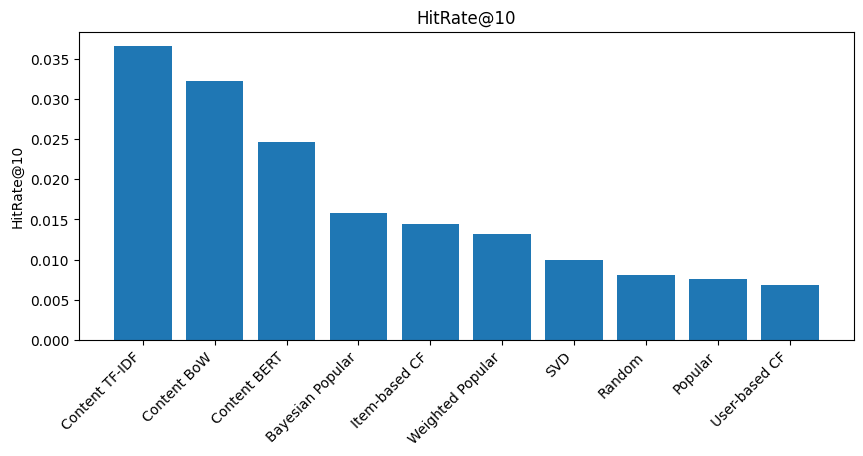

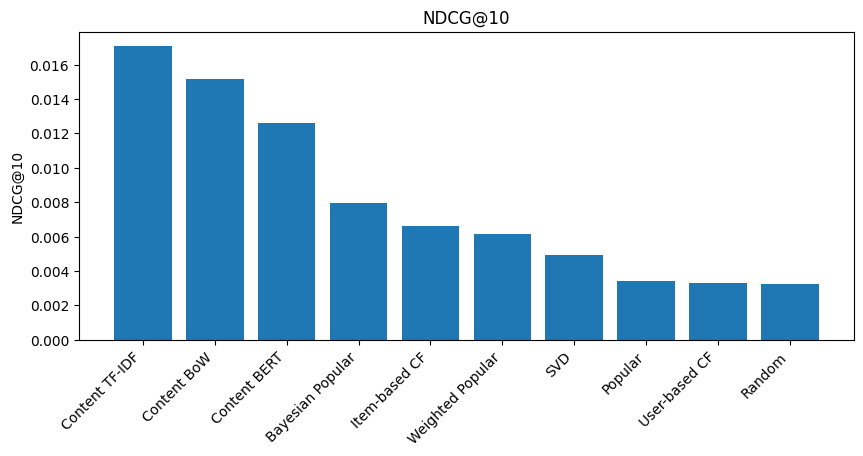

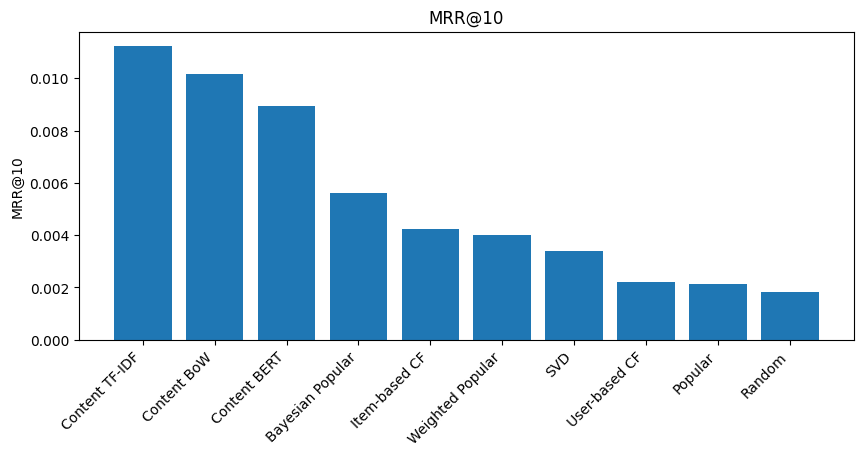

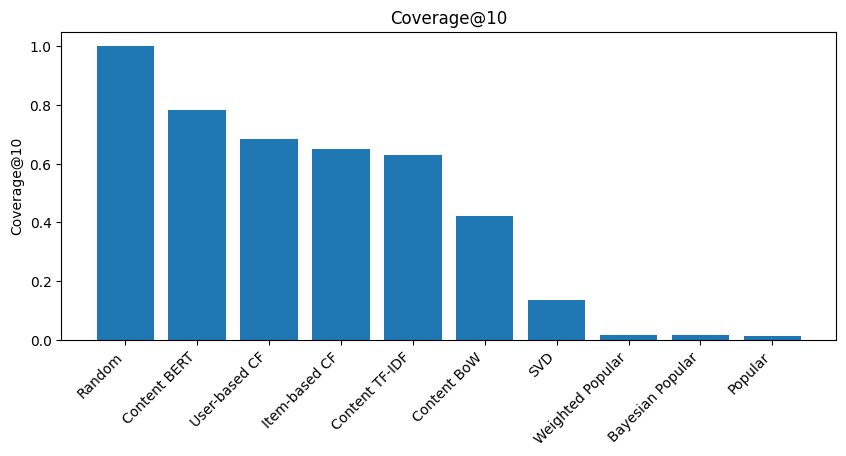

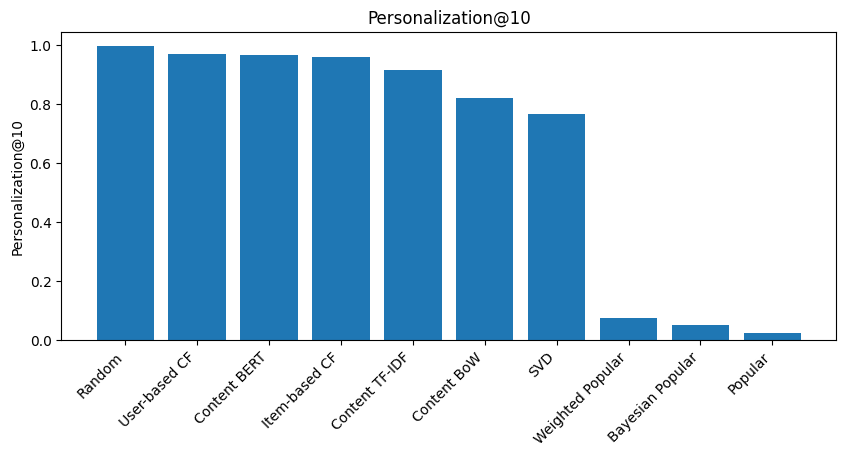

In [677]:
main_metric_cols = [
    f"HitRate@{TOP_K}",
    f"NDCG@{TOP_K}",
    f"MRR@{TOP_K}",
    f"Coverage@{TOP_K}",
    f"Personalization@{TOP_K}"
]

for metric in main_metric_cols:
    plt.figure(figsize=(10, 4))
    plot_df = evaluation_results_df.sort_values(metric, ascending=False)
    plt.bar(plot_df["Model"], plot_df[metric])
    plt.title(metric)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.show()

The HitRate@10 plot makes the practical ranking story immediate. The strongest three models are all content-based, and their margin over the rest is visually substantial rather than marginal.

This matters because Hit Rate is the most direct answer to the offline question posed by the temporal split: how often does the recommender recover the held-out future hotel in the top-$10$ list? Even though the absolute values remain low, the relative differences are informative. In a large-catalog leave-last-one-out setting, a model that improves HitRate from roughly 0.01 to above 0.03 is not making a cosmetic improvement; it is roughly tripling the probability of recovering the relevant future item within the recommendation list.

So the key takeaway from this chart is not that the task is easy, but that **the choice of recommendation paradigm changes the success rate materially**.

The NDCG@10 and MRR@10 plots confirm that the superiority of the best models is not only about getting a hit somewhere in the top-$10$, but also about **ranking the relevant hotel earlier**.

This is an important distinction. Two models may have similar Hit Rate, but if one tends to place the relevant hotel in rank 2 or 3 while the other places it in rank 9 or 10, the user-facing quality is very different. The fact that TF-IDF and BoW lead not only in Hit Rate but also in NDCG and MRR indicates that their advantage is structurally stronger: they are not just finding the right hotel more often, they are finding it **closer to the top of the list**.

This strengthens the conclusion that the review-driven content representation is genuinely effective in this environment, not merely lucky on a few borderline hits.

The coverage plot reveals one of the clearest trade-offs in the section. **Random** unsurprisingly achieves maximal catalog coverage, because it explores the entire item space almost uniformly, but this comes with extremely weak relevance. At the other extreme, the popularity-based baselines cover only a tiny fraction of the catalog, reflecting the fact that they repeatedly recommend nearly the same small set of globally strong hotels.

What is most interesting is the position of the better personalized models. The strongest content-based and item-based recommenders maintain **substantial coverage** while still leading or remaining competitive on ranking quality. This is a very attractive pattern, because it means that better relevance is not being achieved only by collapsing onto a tiny set of universally recommended hotels.

In practical terms, this suggests that these models are not only accurate but also capable of exposing a broader portion of the hotel catalog, which is beneficial both for users and for platform-level business objectives.

The personalization plot complements the coverage analysis very well. Random is again extreme, but its very high personalization is mostly artificial: users receive different lists because recommendations are sampled broadly, not because the system has learned meaningful preference differences.

The more informative result is that **content-based models, item-based CF, and user-based CF also achieve high personalization**, but unlike Random they do so while maintaining at least some recommendation relevance. This means that their recommendation lists differ across users for substantive reasons rather than by chance.

In contrast, Popular and Bayesian Popular have very low personalization, which is exactly what we would expect from non-personalized baselines. They may still recover relevant items for some users, but they do so by serving largely shared recommendations. This makes them useful benchmarks, yet limited as personalized recommender systems.

### 8.8 Complementary note on SVD rating accuracy

The main focus of this section is recommendation quality in the ranking setting. However, the SVD model also provides rating-prediction diagnostics through RMSE and MAE, computed earlier in Part 6.

These values are not directly comparable with the ranking metrics used for the other recommenders, but they still provide useful information on how well the latent-factor model reconstructs observed ratings.

In [678]:
print("SVD RMSE:", svd_rmse)
print("SVD MAE:", svd_mae)

SVD RMSE: 0.9214029282683466
SVD MAE: 0.7101450086028446


In [679]:
# Save results for later reuse
evaluation_results_df.to_csv("evaluation_results_part8.csv", index=False)
family_summary_df.to_csv("evaluation_family_summary_part8.csv", index=False)

The SVD rating-prediction diagnostics remain useful, but they should be interpreted carefully in relation to the ranking results. Earlier, SVD achieved **RMSE = 0.9214** and **MAE = 0.7101**, which are reasonable values from a rating-prediction perspective. However, in the ranking evaluation it remains clearly below the best content-based models and also below item-based CF.

This is a good example of why recommender evaluation should not be reduced to rating reconstruction accuracy. A model may predict observed ratings reasonably well on average, yet still fail to place the future relevant item high enough in the recommendation list. Since the actual recommendation task here is ranking-oriented, the ranking metrics are more important than RMSE and MAE for judging usefulness.

### 8.9 First comparison summary

This first offline evaluation should be interpreted as a **baseline comparison**, not as a final verdict. Its purpose is to identify the broad behavior of the recommender families under a common temporal protocol and to understand which modeling choices already appear promising before moving to context-aware extensions, stronger validation schemes, and hyperparameter refinement.

Several important conclusions already emerge.

First, **the review-driven content-based recommenders are the strongest models at this stage**. In particular, TF-IDF achieves the best ranking quality, followed by Bag of Words and then BERT. This indicates that aggregated review text contains highly informative item-level signals for the hotel recommendation task. The fact that the lexical models outperform the semantic embedding model also suggests that, in this dataset, explicit domain vocabulary and repeated review patterns are already very powerful descriptors of user-relevant hotel characteristics.

Second, **the strongest non-personalized baseline is Bayesian Popular**, not plain Popular. This shows that regularizing item means matters: popularity estimates based on raw averages alone are too unstable, while Bayesian shrinkage produces a more reliable global ranking. This is an important benchmark result, because any personalized recommender should ideally be compared against this stronger baseline rather than against naive popularity alone.

Third, **collaborative filtering remains mixed in this first comparison**. Item-based CF is the strongest CF variant and performs better than both User-based CF and SVD in ranking terms, suggesting that hotel-to-hotel similarity is more stable than user-to-user similarity in this sparse setting. User-based CF remains particularly weak, which is consistent with the difficulty of extracting reliable user neighborhoods when interaction overlap is limited. SVD behaves more robustly than User-based CF but still does not close the gap with the content-based recommenders.

Fourth, the results highlight the importance of **evaluating multiple dimensions simultaneously**. Random maximizes coverage and personalization but offers weak relevance. Popularity-based methods provide some relevance but almost no personalization and very limited coverage. The strongest content-based models are attractive not only because they lead the ranking metrics, but because they do so while still maintaining high personalization and substantial catalog reach. This makes them the most balanced models in the section.

Overall, the central takeaway is that **item content extracted from reviews is currently the most effective source of signal in this project**, more effective than pure interaction-based personalization and more effective than global non-personalized ranking. This is a strong intermediate result, and it provides a clear reference point for the later sections, where we will test whether context-aware modeling, improved evaluation procedures, and further tuning can change or refine this picture.

## 9. Context-aware memory-based collaborative filtering

In this section, we extend collaborative filtering by incorporating contextual information. Following the course material, we begin with **contextual pre-filtering** rather than true multidimensional contextual modeling.

This choice is deliberate. Contextual modeling would require learning a function of the form

$$
g : U \times I \times C \to \mathbb{R}
$$

where recommendations depend jointly on user, item, and context. However, the course theory emphasizes that multidimensional recommender systems are even more sparse than traditional two-dimensional recommenders. In our hotel dataset, sparsity is already a major challenge, so a full contextual model would likely worsen the estimation problem. For this reason, contextual pre-filtering is the most appropriate first approach. It allows us to reuse standard 2D collaborative filtering algorithms while conditioning the training data on context. 

The core idea is simple: we split the data by context, train a separate recommender for each contextual situation, and then use the model corresponding to the user’s context at recommendation time. This is exactly the contextual pre-filtering paradigm described in the professor’s material. 

In this project, we study three contextual signals that are available in the hotel-review data:

- **Season**, derived from the interaction timestamp
- **Weekend vs weekday**, also derived from the interaction timestamp
- **Region**, derived from the hotel address

The goal is not to assume that all context is useful, but to test whether these contexts actually change user behavior and then build context-aware recommenders only where that additional structure appears meaningful. The course theory explicitly recommends checking whether a context is relevant before using it. 

### 9.1 Candidate contexts and motivation

The course material lists several examples of context, including season, day of week, and location. These are especially natural in the hotel domain.

- **Season** may matter because leisure travel, holiday patterns, and destination preferences can vary between summer and winter.
- **Weekend vs weekday** may matter because business and leisure behavior often differ across the week.
- **Region** may matter because hotel preferences can be geographically localized and users may interact differently with hotels in different areas.

Among these, season is the strongest first candidate because it is coarse enough to avoid excessive fragmentation, fully observable, and explicitly used in the professor’s context-aware notebook.

### 9.2 Building contextual variables

We now derive the contextual variables needed for the analysis. The context is extracted from the interaction date and from the hotel metadata.

In [680]:
# Start from the temporal split already used in the notebook
context_train_df = train_df.copy()
context_test_df = test_df.copy()

# Ensure datetime
context_train_df["date"] = pd.to_datetime(context_train_df["date"], errors="coerce")
context_test_df["date"] = pd.to_datetime(context_test_df["date"], errors="coerce")

# ---------- Time-based contexts ----------
def month_to_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "fall"

for df in [context_train_df, context_test_df]:
    df["month"] = df["date"].dt.month
    df["season"] = df["month"].apply(month_to_season)
    df["day_of_week"] = df["date"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["week_context"] = df["is_weekend"].map({0: "weekday", 1: "weekend"})

print("Train contexts created.")
context_train_df[["username", "offering_id", "date", "season", "week_context"]].head()

Train contexts created.


,username,offering_id,date,season,week_context
0,,77638,2001-03-28,spring,weekday
1,,112289,2001-04-13,spring,weekday
2,,111444,2001-04-13,spring,weekday
3,,81444,2001-04-25,spring,weekday
4,,112293,2001-04-27,spring,weekday


The contextual feature engineering step is methodologically correct because every variable is derived from information that would be available at recommendation time. **Season** and **weekday/weekend** come from the interaction timestamp, while **region** is extracted from hotel metadata rather than inferred from future behavior. This ensures that the context-aware pipeline remains temporally valid and does not leak information from the test target back into the model.

This cell also clarifies an important modeling principle: context is useful only if it is both **interpretable** and **coarse enough** to preserve sufficient data density after pre-filtering. The three chosen variables are reasonable first candidates because they are meaningful in the hotel domain and can plausibly influence travel behavior, but they differ greatly in how much fragmentation they may introduce. This trade-off will become central in the next diagnostics.

In [681]:
# ---------- Region context from hotel metadata ----------
offers_context_df = offers_df.copy()

if "offering_id" not in offers_context_df.columns and "id" in offers_context_df.columns:
    offers_context_df = offers_context_df.rename(columns={"id": "offering_id"})

offers_context_df["offering_id"] = pd.to_numeric(offers_context_df["offering_id"], errors="coerce")
offers_context_df = offers_context_df.dropna(subset=["offering_id"]).copy()
offers_context_df["offering_id"] = offers_context_df["offering_id"].astype(int)

# A very lightweight region extraction from address string
offers_context_df["address"] = offers_context_df["address"].fillna("").astype(str)

def extract_region_from_address(addr):
    addr_upper = addr.upper()
    # try to recover U.S.-style abbreviations in the existing address dictionaries / strings
    for code in ["NY", "CA", "FL", "NV", "IL", "MA", "DC", "TX", "WA", "LA"]:
        if f"'{code}'" in addr_upper or f'"{code}"' in addr_upper or f" {code} " in addr_upper:
            return code
    return "OTHER"

offers_context_df["region_context"] = offers_context_df["address"].apply(extract_region_from_address)

context_train_df = context_train_df.merge(
    offers_context_df[["offering_id", "region_context"]],
    on="offering_id",
    how="left"
)

context_test_df = context_test_df.merge(
    offers_context_df[["offering_id", "region_context"]],
    on="offering_id",
    how="left"
)

context_train_df["region_context"] = context_train_df["region_context"].fillna("OTHER")
context_test_df["region_context"] = context_test_df["region_context"].fillna("OTHER")

context_train_df[["username", "offering_id", "season", "week_context", "region_context"]].head()

,username,offering_id,season,week_context,region_context
0,,77638,spring,weekday,MA
1,,112289,spring,weekday,CA
2,,111444,spring,weekday,MA
3,,81444,spring,weekday,CA
4,,112293,spring,weekday,CA


### 9.3 Context support analysis

Before building a context-aware recommender, we first inspect how much data falls into each contextual value. This is essential because contextual pre-filtering splits the data into separate subsets, and if a context is too fine-grained, each subset may become too small to support meaningful collaborative filtering.

This follows the spirit of the course material: context should be introduced only when it is useful and feasible, not automatically.  

In [682]:
print("Season support in train:")
display(context_train_df["season"].value_counts(dropna=False).to_frame(name="count"))

print("Week-context support in train:")
display(context_train_df["week_context"].value_counts(dropna=False).to_frame(name="count"))

print("Region-context support in train:")
display(context_train_df["region_context"].value_counts(dropna=False).head(15).to_frame(name="count"))

Season support in train:


,count
summer,34400
fall,32418
spring,28509
winter,21354


Week-context support in train:


,count
weekday,89284
weekend,27397


Region-context support in train:


,count
NY,49347
CA,27201
OTHER,9529
IL,8232
TX,7165
DC,5850
MA,5264
WA,3720
FL,373


This support analysis is one of the most important checks in the whole contextual section, because in **contextual pre-filtering** each context value creates a smaller local recommendation problem. If a contextual split is too fine-grained, collaborative filtering may stop working well simply because too little interaction data remain inside each subset.

The results immediately show that the three candidate contexts are not equally feasible. **Season** is the most balanced option, with counts ranging from **21,354** in winter to **34,400** in summer, so each seasonal slice still contains substantial data. **Week context** is more imbalanced, with **89,284 weekday** interactions against **27,397 weekend** interactions, but is still coarse enough to remain usable. **Region**, instead, is much more fragmented: while **NY (49,347)** and **CA (27,201)** are strongly represented, support drops quickly across the long tail of locations.

This is already a strong practical argument in favor of season as the main context. A good contextual variable must not only be behaviorally meaningful; it must also preserve enough overlap for local collaborative filtering models to remain statistically reliable.

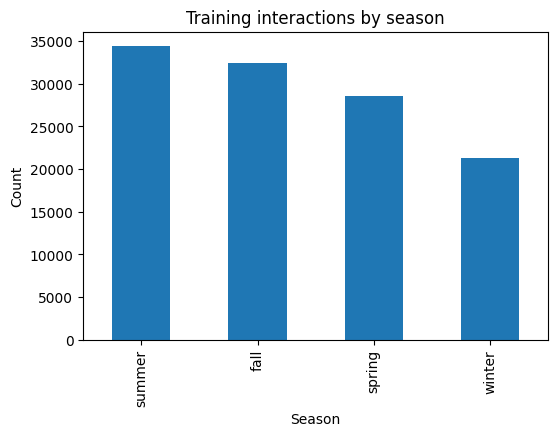

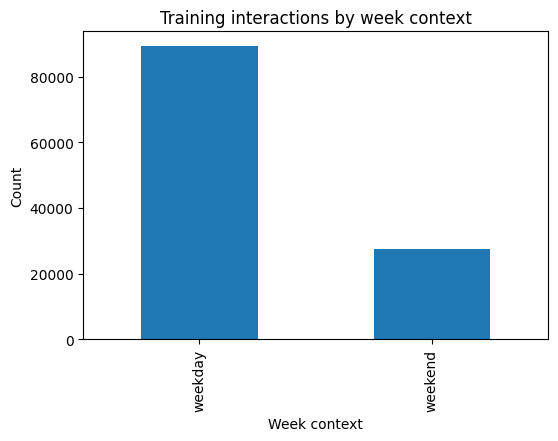

In [683]:
plt.figure(figsize=(6, 4))
context_train_df["season"].value_counts().plot(kind="bar")
plt.title("Training interactions by season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
context_train_df["week_context"].value_counts().plot(kind="bar")
plt.title("Training interactions by week context")
plt.xlabel("Week context")
plt.ylabel("Count")
plt.show()

The plots reinforce the previous conclusion visually. The **seasonal distribution is uneven but still well spread**, whereas the **weekday/weekend split is much more asymmetric**. This matters because contextual pre-filtering always involves a trade-off: more contextual specificity may better reflect behavior, but it reduces the amount of data available to estimate each local model.

From this perspective, **season appears to offer the best balance**. It introduces a meaningful behavioral distinction without shrinking the training subsets too aggressively. This makes it a safer first choice than more fragmented contexts, especially in a recommender setting where sparsity is already a central challenge.

### 9.4 Context relevance analysis

The course theory explicitly notes that not every contextual variable is relevant and suggests statistical testing, such as t-tests, to evaluate whether user preferences differ across context values.  
In our setting, we perform a practical context relevance analysis in three ways:

1. **Average rating by context**, to see whether overall evaluation changes
2. **Distributional comparison**, to assess whether the rating distribution shifts
3. **Top-item comparison**, to check whether the most preferred hotels differ by context

The last point is especially important for recommendation: even if the average rating does not change much, the ranking of attractive hotels may still vary across contexts.

In [684]:
print("Average rating by season")
display(context_train_df.groupby("season")["overall_rating"].agg(["mean", "count", "std"]))

print("Average rating by week context")
display(context_train_df.groupby("week_context")["overall_rating"].agg(["mean", "count", "std"]))

print("Average rating by region context")
display(
    context_train_df.groupby("region_context")["overall_rating"]
    .agg(["mean", "count", "std"])
    .sort_values("count", ascending=False)
    .head(15)
)

Average rating by season


,mean,count,std
season,,,
fall,3.878648,32418,1.154165
spring,3.907889,28509,1.141278
summer,3.893721,34400,1.156035
winter,3.881146,21354,1.174359


Average rating by week context


,mean,count,std
week_context,,,
weekday,3.889823,89284,1.160425
weekend,3.893528,27397,1.138696


Average rating by region context


,mean,count,std
region_context,,,
NY,3.877419,49347,1.137593
CA,3.822212,27201,1.166572
OTHER,3.873859,9529,1.215816
IL,4.007046,8232,1.130829
TX,3.991905,7165,1.187569
DC,3.922393,5850,1.131525
MA,3.967515,5264,1.150424
WA,4.004570,3720,1.126918
FL,3.841823,373,1.241820


The relevance analysis suggests that context is present, but not in the form of large shifts in the **global average rating**. Seasonal means are all very close, roughly between **3.879** and **3.908**, and the weekday/weekend averages are also nearly identical. Region shows somewhat more variation, but much of it occurs in smaller groups and should therefore be interpreted carefully.

This is an important point. In recommendation, context does not need to strongly change the **mean rating level** in order to matter. What often matters more is whether context changes the **relative ordering of attractive items**. So these averages should be read as evidence that context does not radically alter overall satisfaction, but not as evidence that context is irrelevant for ranking.

In other words, the cell tells us that contextual effects are likely to be **subtle rather than dramatic**. That is actually realistic in many recommender settings: the broad rating scale stays stable, while the composition of preferred items may still differ across situations.

In [685]:
# Top hotels by season
def top_items_by_context(df, context_col, top_n=10):
    out = {}
    for ctx_value, g in df.groupby(context_col):
        top_items = (
            g.groupby("offering_id")["overall_rating"]
            .agg(["mean", "count"])
            .assign(score=lambda x: x["count"] * (x["mean"] ** 0.5))
            .sort_values("score", ascending=False)
            .head(top_n)
            .reset_index()
        )
        out[ctx_value] = top_items
    return out

season_top_items = top_items_by_context(context_train_df, "season", top_n=10)

for season_name, df_top in season_top_items.items():
    print(f"\nTop hotels in {season_name}")
    display(attach_hotel_names(df_top.rename(columns={"score": "weighted_pop_score"}), offer_name_map))


Top hotels in fall


,offering_id,mean,count,weighted_pop_score,hotel_name
0,214197,2.615385,494,798.904250,Hotel Pennsylvania New York
1,93346,4.138614,303,616.410577,Salisbury Hotel
2,122005,4.094203,276,558.462174,The New Yorker Hotel
3,93520,3.552632,266,501.368128,Park Central
4,93569,4.186957,230,470.627241,The Belvedere
5,93358,4.254717,212,437.291665,Pod 51
6,93421,2.655303,264,430.190655,Hotel Carter
7,93516,3.966981,212,422.246374,Novotel New York Times Square
8,223023,3.122449,196,346.340873,Hudson New York
9,208454,4.585987,157,336.214217,Sofitel New York



Top hotels in spring


,offering_id,mean,count,weighted_pop_score,hotel_name
0,214197,2.858628,481,813.249654,Hotel Pennsylvania New York
1,93346,4.316527,357,741.712208,Salisbury Hotel
2,93520,3.591176,340,644.313588,Park Central
3,99766,3.792079,303,590.039829,The Roosevelt Hotel
4,122005,4.146067,267,543.662579,The New Yorker Hotel
5,93569,4.264957,234,483.251487,The Belvedere
6,93516,4.079646,226,456.477820,Novotel New York Times Square
7,290978,3.615023,213,404.981481,Hotel St. James
8,93437,3.676329,207,396.896712,Edison Hotel Times Square
9,208454,4.712500,160,347.332694,Sofitel New York



Top hotels in summer


,offering_id,mean,count,weighted_pop_score,hotel_name
0,214197,2.714953,428,705.220533,Hotel Pennsylvania New York
1,93346,4.273312,311,642.898903,Salisbury Hotel
2,93569,4.246094,256,527.514929,The Belvedere
3,93520,3.349810,263,481.355378,Park Central
4,99766,3.658635,249,476.276180,The Roosevelt Hotel
5,122005,4.223744,219,450.083326,The New Yorker Hotel
6,93358,4.040201,199,399.995000,Pod 51
7,290978,3.728205,195,376.516932,Hotel St. James
8,223023,3.470588,187,348.371928,Hudson New York
9,93516,3.944444,162,321.742133,Novotel New York Times Square



Top hotels in winter


,offering_id,mean,count,weighted_pop_score,hotel_name
0,214197,2.524804,383,608.572921,Hotel Pennsylvania New York
1,93520,3.606870,262,497.584164,Park Central
2,122005,3.995763,236,471.749934,The New Yorker Hotel
3,93516,3.967593,216,430.246441,Novotel New York Times Square
4,93346,4.241546,207,426.316784,Salisbury Hotel
5,93569,4.292553,188,389.507381,The Belvedere
6,99307,3.522472,178,334.074842,Wellington Hotel
7,99766,3.760234,171,331.591616,The Roosevelt Hotel
8,208454,4.637584,149,320.872249,Sofitel New York
9,93437,3.739130,161,311.322983,Edison Hotel Times Square


### 9.5 Choosing the main context for contextual pre-filtering

Given the support and relevance analysis above, we use **season** as the main context for the first context-aware collaborative filtering model.

This choice is motivated by three reasons:

- it is coarse enough to avoid extreme data fragmentation
- it is explicitly suggested and explored in the professor’s context-aware notebook 
- it is intuitively meaningful in the hotel domain, where travel behavior and destination attractiveness may vary across the year

We also keep **weekend vs weekday** and **region** as additional candidate contexts for later comparison or extensions, but we begin with season because it is the strongest and safest contextual signal.

### 9.6 Contextual pre-filtering with item-based collaborative filtering

Following the contextual pre-filtering paradigm, we train a separate memory-based collaborative filtering model for each season. At recommendation time, the model corresponding to the user’s contextual situation is used.

For the collaborative filtering algorithm, we use item-based KNN, since item-based memory models are generally more stable and computationally more manageable than user-based ones in this project. The model is therefore still a standard 2D recommender inside each context, but the data used to fit it is restricted to the relevant contextual subset. This is exactly the logic of contextual pre-filtering. 

The choice of **season** as the main context is well justified by the joint evidence from the previous diagnostics. First, season is **coarse enough** to avoid excessive fragmentation, unlike region. Second, it is **domain-plausible** in the hotel setting, where travel behavior and destination preferences may vary across the year. Third, even though average ratings remain close, the seasonal top-item rankings suggest that the relative appeal of hotels is not perfectly invariant across seasons.

This is a strong methodological choice because it respects the main principle of context-aware recommendation: context should be introduced only when it is both **behaviorally meaningful** and **statistically feasible**. Season satisfies both conditions better than the alternative candidates considered so far.

In [687]:
from surprise import Dataset, Reader, KNNWithMeans

In [688]:
# Global fallback model
rating_min = float(context_train_df["overall_rating"].min())
rating_max = float(context_train_df["overall_rating"].max())

reader = Reader(rating_scale=(rating_min, rating_max))

global_knn_data = Dataset.load_from_df(
    context_train_df[["username", "offering_id", "overall_rating"]],
    reader
)

global_knn_trainset = global_knn_data.build_full_trainset()

global_item_knn_model = KNNWithMeans(
    k=40,
    min_k=3,
    sim_options={
        "name": "pearson",
        "user_based": False
    },
    verbose=True
)

global_item_knn_model.fit(global_knn_trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [689]:
# One item-based KNN model per season
season_models = {}
season_train_items = {}

for season_name, g in context_train_df.groupby("season"):
    g = g[["username", "offering_id", "overall_rating"]].dropna().copy()

    # Keep only reasonably supported seasonal slices
    if g["username"].nunique() < 50 or g["offering_id"].nunique() < 50:
        print(f"Skipping season {season_name}: not enough support")
        continue

    season_train_items[season_name] = set(g["offering_id"].unique())

    season_data = Dataset.load_from_df(
        g[["username", "offering_id", "overall_rating"]],
        reader
    )
    season_trainset = season_data.build_full_trainset()

    model = KNNWithMeans(
        k=40,
        min_k=3,
        sim_options={
            "name": "pearson",
            "user_based": False
        },
        verbose=False
    )

    model.fit(season_trainset)
    season_models[season_name] = model
    print(f"Fitted model for season={season_name} with {len(g):,} interactions")

Fitted model for season=fall with 32,418 interactions
Fitted model for season=spring with 28,509 interactions
Fitted model for season=summer with 34,400 interactions
Fitted model for season=winter with 21,354 interactions


This training step makes the cost of contextual pre-filtering very concrete. Instead of fitting one single collaborative model, we now estimate **one item-based KNN model per season**, each on a reduced subset of the training data. The seasonal datasets remain large enough to support fitting, which confirms that season was a feasible partitioning choice.

At the same time, this cell highlights the main structural limitation of pre-filtering. Every seasonal model is trained on **less data than the global model**, so it may become more context-sensitive but also less statistically robust. Context-aware recommendation is therefore not guaranteed to improve performance: it will help only if the gain from modeling seasonal behavior outweighs the loss caused by splitting the interaction matrix.

This trade-off is central to the interpretation of the whole section. If the contextual model later outperforms the non-contextual one, that improvement will be meaningful precisely because it has been achieved despite the smaller local training sets.

### 9.7 Context-aware recommendation rule with fallback

A practical challenge of contextual pre-filtering is that context-specific subsets are smaller than the full training set. As the theory notes, this is one of the main limitations of pre-filtering: data from different contexts is used independently, and each local model may be weaker because it sees less data. 

To address this, we use a fallback mechanism:

- if a season-specific model exists for the target season, use it
- otherwise, fall back to the global item-based KNN model

This keeps the context-aware recommender robust while still injecting contextual information whenever the data support it.

In [690]:
# Seen items from the global train set
context_seen_items = (
    context_train_df.groupby("username")["offering_id"]
    .apply(set)
    .to_dict()
)

all_global_items = set(context_train_df["offering_id"].unique())

In [691]:
def recommend_contextual_item_knn(
    user_id,
    context_value,
    context_models,
    global_model,
    season_train_items,
    all_items,
    seen_items_dict,
    top_k=10
):
    """
    Contextual pre-filtering recommender:
    use the context-specific item-based KNN model when available,
    otherwise fall back to the global item-based KNN model.
    """
    seen_items = seen_items_dict.get(user_id, set())

    if context_value in context_models:
        model = context_models[context_value]
        candidate_items = season_train_items.get(context_value, all_items) - seen_items
    else:
        model = global_model
        candidate_items = all_items - seen_items

    scores = []
    for item_id in candidate_items:
        est = model.predict(user_id, item_id).est
        scores.append((item_id, est))

    if len(scores) == 0:
        return pd.DataFrame(columns=["offering_id", "score"])

    recs = pd.DataFrame(scores, columns=["offering_id", "score"])
    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

The fallback mechanism is a very important practical refinement. In pure contextual pre-filtering, one would always use the model associated with the user’s current context. In practice, however, context-specific subsets are smaller, candidate sets may shrink, and a local model may be weaker simply because it has seen less data. Falling back to the **global item-based KNN model** when necessary protects the recommender from exactly this risk.

This makes the contextual system more robust. The model exploits seasonal specialization when the data support it, but it does not force context usage in situations where local estimation would become unreliable. In effect, the recommender combines **context sensitivity** with a **global safety net**, which is a sensible way to handle one of the classical weaknesses of pre-filtering, namely data fragmentation.

### 9.8 Qualitative recommendation example

Before generating recommendations for the entire test population, we inspect one example user and compare the recommendations obtained with the context-aware memory-based model.

In [692]:
example_user_ctx = context_test_df["username"].iloc[0]
example_user_season = context_test_df.loc[context_test_df["username"] == example_user_ctx, "season"].iloc[0]

contextual_item_example = recommend_contextual_item_knn(
    user_id=example_user_ctx,
    context_value=example_user_season,
    context_models=season_models,
    global_model=global_item_knn_model,
    season_train_items=season_train_items,
    all_items=all_global_items,
    seen_items_dict=context_seen_items,
    top_k=TOP_K
)

print("Example user:", example_user_ctx)
print("Season context:", example_user_season)
display(attach_hotel_names(contextual_item_example, offer_name_map))

Example user: 
Season context: winter


,offering_id,score,hotel_name
0,2322597,5.000000,Four Seasons Baltimore
1,2196840,5.000000,Inn at The Black Olive
2,1845691,5.000000,Four Seasons Hotel Denver
3,1152288,5.000000,Four Seasons Hotel Seattle
4,2525636,5.000000,Hotel Lincoln
5,1516481,4.916667,Waldorf Astoria Chicago
6,2192761,4.857143,Omni Dallas Hotel
7,781627,4.857143,The Grand Del Mar
8,1746459,4.833333,The Nolitan Hotel
9,641273,4.833333,Hotel ZaZa Houston


This qualitative example is mainly a sanity check, but it is still useful. It confirms that the context-aware recommender is functioning as intended: recommendations are generated using the user’s observed seasonal context, and the output remains a standard ranked top-$K$ list of candidate hotels.

Conceptually, the important point is that the contextual model is **not a different recommendation task**. It is still the same item-based collaborative filtering problem, but solved inside the seasonal slice corresponding to the user’s context, with fallback to the global model when needed. This keeps the comparison with the standard non-contextual item-based CF methodologically clean.

### 9.9 Generating top-$K$ context-aware recommendations for all test users

We now generate top-$K$ recommendation lists for all users in the temporal test set, using the season-specific item-based collaborative filtering model whenever available and the global model otherwise.

These recommendation tables will later be compared with the non-contextual collaborative recommenders in order to measure whether introducing context improves ranking quality.

In [693]:
def generate_contextual_item_knn_recommendations(
    test_context_df,
    context_col="season",
    top_k=10,
    progress_every=500
):
    all_recs = []

    unique_users = test_context_df["username"].unique()

    for idx, user_id in enumerate(unique_users, start=1):
        user_context = test_context_df.loc[
            test_context_df["username"] == user_id, context_col
        ].iloc[0]

        recs = recommend_contextual_item_knn(
            user_id=user_id,
            context_value=user_context,
            context_models=season_models,
            global_model=global_item_knn_model,
            season_train_items=season_train_items,
            all_items=all_global_items,
            seen_items_dict=context_seen_items,
            top_k=top_k
        )

        if not recs.empty:
            recs = recs.copy()
            recs["username"] = user_id
            recs["rank"] = np.arange(1, len(recs) + 1)
            recs["context_value"] = user_context
            all_recs.append(recs)

        if idx % progress_every == 0:
            print(f"Processed {idx:,} / {len(unique_users):,} users")

    if not all_recs:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank", "context_value"])

    return pd.concat(all_recs, ignore_index=True)[
        ["username", "offering_id", "score", "rank", "context_value"]
    ]

In [694]:
context_item_knn_recs = generate_contextual_item_knn_recommendations(
    test_context_df=context_test_df,
    context_col="season",
    top_k=TOP_K,
    progress_every=500
)

print("Context-aware item-based CF recommendations shape:", context_item_knn_recs.shape)
context_item_knn_recs.head()

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
Context-aware item-based CF recommendations shape: (39370, 5)


,username,offering_id,score,rank,context_value
0,,2322597,5.0,1,winter
1,,2196840,5.0,2,winter
2,,1845691,5.0,3,winter
3,,1152288,5.0,4,winter
4,,2525636,5.0,5,winter


### 9.10 Comparing contextual and non-contextual memory-based CF

The key question is whether the context-aware memory-based recommender improves over the non-contextual baseline. According to the theory, contextual pre-filtering should be especially useful when preferences differ meaningfully across contexts. However, it can also fail to improve if the context is weak or if the local data subsets become too sparse. 

For this reason, the contextual recommender should always be compared directly with its non-contextual counterpart under the same evaluation protocol.

In [695]:
# Quick placeholder comparison table to be used later in the evaluation section
context_memory_model_recs = {
    "Item-based CF (global)": item_knn_recs if "item_knn_recs" in globals() else pd.DataFrame(),
    "Context-aware Item-based CF (season)": context_item_knn_recs
}

for model_name, recs_df in context_memory_model_recs.items():
    print(model_name, recs_df.shape)

Item-based CF (global) (39370, 4)
Context-aware Item-based CF (season) (39370, 5)


### 9.11 Additional contextual extensions

The season-based contextual pre-filtering model is the main context-aware collaborative filtering approach implemented in this section. However, the same procedure could also be applied to other contextual variables:

- **weekend vs weekday**, using the same pre-filtering logic on week context
- **region**, by building geographically localized collaborative models
- **combined contexts**, such as season plus weekend, but only if the additional fragmentation does not make the data too sparse

The course theory explicitly notes that multiple contextual pre-filters can be combined and that they should be used only when they outperform the standard 2D recommender. This is an important practical principle for avoiding unnecessary complexity. 

### 9.12 Summary of the context-aware memory-based recommender

In this section, we introduced context into collaborative filtering through **contextual pre-filtering**. Rather than building a fully multidimensional recommender, we trained separate item-based collaborative filtering models for different seasonal contexts and used a global fallback when seasonal support was insufficient.

This design is fully consistent with the course material. It preserves the simplicity of standard 2D collaborative filtering while incorporating contextual information only where it is empirically meaningful. In the next sections, this context-aware memory-based recommender will be compared with both the non-contextual collaborative models and the context-aware content-based models.

## 10. Context-aware content-based recommenders

In this section, we extend the content-based recommenders by incorporating contextual information. As in Part 9, we adopt the **contextual pre-filtering** paradigm: instead of building a fully multidimensional contextual model, we construct separate content representations for different contextual situations and use the one that matches the user’s context at recommendation time.

This choice is especially appropriate here. Content-based recommendation in this project is built from hotel review text, and reviews may themselves vary across contexts. A hotel may be described differently in summer than in winter, and the aspects emphasized by users may shift with season. For example, reviews written in winter may place more importance on comfort, indoor quality, or holiday travel, while summer reviews may emphasize location, leisure, or destination-related aspects.

Therefore, context can affect the content representation itself, not only the final recommendation rule. This makes contextual pre-filtering particularly natural for the content-based family.

### 10.1 Why contextual pre-filtering is suitable for content-based recommendation

Following the same logic used in Part 9, we begin with contextual pre-filtering rather than a more complex contextual model. The idea is to build a separate item-content space for each relevant context.

In our setting, this means that each hotel is no longer represented by a single global review profile. Instead, we build different hotel profiles for different seasons, using only the reviews written in that context. Recommendations are then generated using the similarity matrix corresponding to the user’s seasonal context.

This approach has two advantages:

- it allows the textual representation of hotels to adapt to context
- it keeps the modeling pipeline simple and directly comparable with the global content-based recommenders

At the same time, contextual pre-filtering can increase sparsity, since each contextual slice contains fewer reviews. For this reason, we also introduce a global fallback model, exactly as in the context-aware collaborative filtering section.

### 10.2 Context choice

Based on the analysis in Part 9, we use **season** as the main context for the first context-aware content-based recommender.

This is the most appropriate choice because:

- seasonal support is strong in every slice
- season is coarse enough to avoid extreme data fragmentation
- it is intuitively meaningful in the hotel domain
- it already showed some variation in the ranking of top hotels, even if the mean rating did not change dramatically

The same procedure could later be extended to weekend vs weekday or to region-based segmentation, but season is the cleanest first contextual signal.

### 10.3 Building season-specific review tables

To create contextual content representations, we begin from the review-level training data and attach the season of each interaction. We then aggregate reviews at hotel level separately within each season.

This means that each hotel may have:
- one global textual profile
- one winter profile
- one spring profile
- one summer profile
- one fall profile

when enough review text is available.

In [696]:
# Start from the train interactions with contextual variables already created in Part 9
context_content_train_df = context_train_df.copy()

# Recover review text fields from the original ratings table
context_review_text_df = ratings_df[["username", "offering_id", "date", "title", "text"]].copy()
context_review_text_df["date"] = pd.to_datetime(context_review_text_df["date"], errors="coerce")
context_review_text_df = context_review_text_df.dropna(subset=["date"]).copy()

context_content_train_df["date"] = pd.to_datetime(context_content_train_df["date"], errors="coerce")

context_content_train_df = context_content_train_df.merge(
    context_review_text_df,
    on=["username", "offering_id", "date"],
    how="left"
)

# Use the text columns coming from ratings_df after the merge
context_content_train_df["title"] = context_content_train_df["title_y"].fillna("").astype(str)
context_content_train_df["text"] = context_content_train_df["text_y"].fillna("").astype(str)

context_content_train_df["review_text"] = (
    context_content_train_df["title"] + " " + context_content_train_df["text"]
)

context_content_train_df["review_text"] = (
    context_content_train_df["review_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Contextual content training rows:", context_content_train_df.shape)
context_content_train_df[["username", "offering_id", "season", "review_text"]].head()

Contextual content training rows: (131606, 17)


,username,offering_id,season,review_text
0,,77638,spring,“Best Western Boston” Excellent accommodations...
1,,112289,spring,“Accommodation & email” Motel was clean. Had e...
2,,111444,spring,“The Presidential Suite” Our stay at the Fairm...
3,,81444,spring,"“Pan Pacific - WOW!” The Pan Pacific Hotel, si..."
4,,112293,spring,“A Jewel of An Accomodation in SF” Cow Hollow ...


This cell is the contextual analogue of the review-level preparation performed in the global content-based section, but now each interaction keeps its **season label**. That is a crucial modeling step: context is not only attached to the final recommendation stage, but is already injected into the **text source** from which hotel profiles will later be built.

This means the contextual recommender is conceptually different from simply re-ranking a fixed global content model by season. Here, the **item representation itself becomes contextual**, because the review text available for a hotel in winter is not necessarily the same as the text available in summer. In the hotel domain this is highly plausible: users may emphasize location convenience, holiday atmosphere, weather, comfort, or travel purpose differently across seasons.

The result is methodologically strong because the contextual text table is still built only from **training interactions**, so the seasonal representations remain temporally valid and fully aligned with the offline evaluation protocol.

### 10.4 Building seasonal hotel review profiles

For each season, we aggregate the reviews written about each hotel within that season. We then enrich the resulting text with the limited structured metadata available in the hotel catalog, namely hotel name, address, and hotel class.

This produces one contextual item representation per hotel per season.

In [697]:
# Prepare metadata once
context_content_offers_df = offers_df.copy()

if "offering_id" not in context_content_offers_df.columns and "id" in context_content_offers_df.columns:
    context_content_offers_df = context_content_offers_df.rename(columns={"id": "offering_id"})

context_content_offers_df["offering_id"] = pd.to_numeric(
    context_content_offers_df["offering_id"], errors="coerce"
)
context_content_offers_df = context_content_offers_df.dropna(subset=["offering_id"]).copy()
context_content_offers_df["offering_id"] = context_content_offers_df["offering_id"].astype(int)

for col in ["name", "address", "hotel_class"]:
    context_content_offers_df[col] = context_content_offers_df[col].fillna("").astype(str)

context_content_offers_df = context_content_offers_df[
    ["offering_id", "name", "address", "hotel_class"]
].copy()

In [698]:
def build_hotel_profiles_for_context(df, context_value, context_col="season"):
    g = df[df[context_col] == context_value].copy()

    hotel_profiles = (
        g.groupby("offering_id")["review_text"]
        .apply(lambda x: " ".join([t for t in x if isinstance(t, str) and len(t.strip()) > 0]))
        .reset_index()
    )

    hotel_profiles = hotel_profiles.merge(
        context_content_offers_df,
        on="offering_id",
        how="left"
    )

    for col in ["name", "address", "hotel_class", "review_text"]:
        hotel_profiles[col] = hotel_profiles[col].fillna("").astype(str)

    hotel_profiles["hotel_content_text"] = (
        hotel_profiles["name"] + " "
        + hotel_profiles["address"] + " "
        + hotel_profiles["hotel_class"] + " "
        + hotel_profiles["review_text"]
    )

    hotel_profiles["hotel_content_text"] = (
        hotel_profiles["hotel_content_text"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    hotel_profiles = hotel_profiles[
        hotel_profiles["hotel_content_text"].str.len() > 0
    ].copy().reset_index(drop=True)

    return hotel_profiles

This function is one of the most important pieces of the whole section because it formalizes what a **context-aware content profile** actually is. For each context value, it aggregates only the reviews written in that contextual slice and then enriches the resulting text with the same structured metadata used in the global content-based model.

So the contextual recommender remains directly comparable to the non-contextual one: the recommendation rule is unchanged, and even the representation design is unchanged in spirit. The only difference is that the hotel document is now estimated **locally within a season** rather than globally across all interactions. This is exactly what contextual pre-filtering should do in the content-based family.

The trade-off is clear. These local profiles may better reflect seasonal language and context-specific hotel characteristics, but they are also built from fewer reviews. Whether that improves recommendation quality will depend on whether the gain in contextual specificity outweighs the loss in textual support.

### 10.5 Global fallback content model

As in Part 9, we keep a global fallback model. If a hotel has insufficient contextual review text in a given season, or if the seasonal representation is too sparse, the recommender can fall back to the global content model built earlier in Part 7.

In [699]:
# Reuse the global hotel_content_df from Part 7 if it exists
print("Global hotel content profiles shape:", hotel_content_df.shape)
hotel_content_df.head()

Global hotel content profiles shape: (1444, 6)


,offering_id,review_text,name,address,hotel_class,hotel_content_text
0,72572,“A Great Seattle Hotel Near Everything” THE BE...,BEST WESTERN PLUS Pioneer Square Hotel,"{'region': 'WA', 'street-address': '77 Yesler ...",3.5,BEST WESTERN PLUS Pioneer Square Hotel {'regio...
1,72579,“Very impressed would stay again!” Rooms are s...,BEST WESTERN Loyal Inn,"{'region': 'WA', 'street-address': '2301 8th A...",2.0,"BEST WESTERN Loyal Inn {'region': 'WA', 'stree..."
2,72586,“Great Stay” I stayed at the Best Western Exec...,BEST WESTERN PLUS Executive Inn,"{'region': 'WA', 'street-address': '200 Taylor...",3.0,BEST WESTERN PLUS Executive Inn {'region': 'WA...
3,73644,“disappointed stay” I am sorry to say that I w...,BEST WESTERN Market Center,"{'region': 'TX', 'street-address': '2023 Marke...",2.5,"BEST WESTERN Market Center {'region': 'TX', 's..."
4,73757,“Keine gute Nacht!” Das Hotel ist sehr laut (V...,Renaissance Phoenix Downtown,"{'region': 'AZ', 'street-address': '50 East Ad...",3.5,"Renaissance Phoenix Downtown {'region': 'AZ', ..."


Keeping the global content model as fallback is a very sensible design choice. In contextual pre-filtering, some hotels may have rich review evidence overall but relatively little text in a specific seasonal slice. If the recommender were forced to rely only on contextual profiles, representation quality for those hotels could degrade sharply.

The fallback preserves robustness. Contextual representations are used when seasonal evidence is available, but the system can still rely on the broader global profile when the local seasonal text becomes too sparse. This mirrors the same principle used in Part 9 for collaborative filtering: context should be exploited when it adds useful structure, not when it weakens the model through excessive fragmentation.

### 10.6 Building season-specific BoW, TF-IDF, and BERT representations

We now compute three alternative contextual text representations for each season:

- Bag of Words
- TF-IDF
- BERT embeddings

This mirrors the structure used in the global content-based section, so that later comparisons remain methodologically clean.

In [700]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel

In [701]:
def build_hotel_profiles_for_context(df, context_value, context_col="season"):
    g = df[df[context_col] == context_value].copy()

    hotel_profiles = (
        g.groupby("offering_id")["review_text"]
        .apply(lambda x: " ".join([t for t in x if isinstance(t, str) and len(t.strip()) > 0]))
        .reset_index()
    )

    hotel_profiles = hotel_profiles.merge(
        context_content_offers_df,
        on="offering_id",
        how="left"
    )

    for col in ["name", "address", "hotel_class", "review_text"]:
        hotel_profiles[col] = hotel_profiles[col].fillna("").astype(str)

    hotel_profiles["hotel_content_text"] = (
        hotel_profiles["name"] + " "
        + hotel_profiles["address"] + " "
        + hotel_profiles["hotel_class"] + " "
        + hotel_profiles["review_text"]
    )

    hotel_profiles["hotel_content_text"] = (
        hotel_profiles["hotel_content_text"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    hotel_profiles = hotel_profiles[
        hotel_profiles["hotel_content_text"].str.len() > 0
    ].copy().reset_index(drop=True)

    return hotel_profiles

In [702]:
season_hotel_profiles = {}

for season_name in sorted(context_content_train_df["season"].dropna().unique()):
    season_profiles = build_hotel_profiles_for_context(
        context_content_train_df,
        context_value=season_name,
        context_col="season"
    )
    season_hotel_profiles[season_name] = season_profiles
    print(f"{season_name}: {season_profiles.shape[0]:,} hotels with contextual text profiles")

fall: 1,443 hotels with contextual text profiles
spring: 1,439 hotels with contextual text profiles
summer: 1,442 hotels with contextual text profiles
winter: 1,427 hotels with contextual text profiles


This output is very reassuring from a feasibility perspective. Even after splitting the review corpus by season, the contextual pipeline still produces hotel text profiles for almost the **entire reduced catalog** in every slice: from **1,427 hotels in winter** to **1,443 in fall**. This is a strong result because it shows that season does not create a catastrophic loss of item coverage at the representation level.

That matters a lot. A contextual content-based recommender would become much less useful if many hotels disappeared from the candidate space simply because they lacked enough seasonal text. Here, that problem appears limited. The seasonal partition reduces textual support per hotel, but it does not collapse the catalog.

So this cell confirms that **season is not only behaviorally meaningful, but also technically viable** for contextual content modeling. The representation remains broad enough to support a fair comparison with the global content-based baselines.

In [703]:
season_content_models = {}

for season_name, profiles_df in season_hotel_profiles.items():
    if len(profiles_df) < 20:
        print(f"Skipping {season_name}: too few hotels")
        continue

    # Index mappings
    index_from_item = {
        item_id: idx for idx, item_id in enumerate(profiles_df["offering_id"])
    }
    item_from_index = {
        idx: item_id for idx, item_id in enumerate(profiles_df["offering_id"])
    }

    # BoW
    bow_vectorizer = CountVectorizer(
        stop_words="english",
        max_features=15000,
        ngram_range=(1, 2),
        min_df=2
    )
    bow_matrix = bow_vectorizer.fit_transform(profiles_df["hotel_content_text"])
    bow_similarity = cosine_similarity(bow_matrix)

    # TF-IDF
    tfidf_vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=15000,
        ngram_range=(1, 2),
        min_df=2
    )
    tfidf_matrix = tfidf_vectorizer.fit_transform(profiles_df["hotel_content_text"])
    tfidf_similarity = linear_kernel(tfidf_matrix, tfidf_matrix)

    season_content_models[season_name] = {
        "profiles_df": profiles_df,
        "index_from_item": index_from_item,
        "item_from_index": item_from_index,
        "bow_similarity": bow_similarity,
        "tfidf_similarity": tfidf_similarity,
    }

    print(f"Built BoW and TF-IDF contextual models for {season_name}")

Built BoW and TF-IDF contextual models for fall
Built BoW and TF-IDF contextual models for spring
Built BoW and TF-IDF contextual models for summer
Built BoW and TF-IDF contextual models for winter


This is the contextual extension of the lexical text baselines from Part 7. The important methodological point is that the notebook keeps the **representation families unchanged**—Bag of Words and TF-IDF remain exactly the same kinds of models—but now estimates them separately inside each seasonal slice.

This makes the later comparison especially clean. If contextual BoW or contextual TF-IDF outperform their global counterparts, the improvement cannot be attributed to a new recommendation rule or to a different model family. It would mean that simply replacing a global hotel document with a **season-specific hotel document** yields a better representation of user-relevant content.

In other words, this cell sets up a very interpretable experimental question: does the language used to describe hotels vary enough across seasons that separate lexical representations become more useful than a single global one?

### 10.7 Seasonal BERT embeddings

Since BERT is computationally heavier, we compute the contextual semantic representations separately. As in Part 7, this representation is intended as a semantic extension of the lexical baselines.

In [704]:
# Requires sentence-transformers already installed in Part 7
from sentence_transformers import SentenceTransformer

In [705]:
context_bert_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [706]:
for season_name, model_dict in season_content_models.items():
    profiles_df = model_dict["profiles_df"]

    bert_embeddings = context_bert_model.encode(
        profiles_df["hotel_content_text"].tolist(),
        show_progress_bar=True
    )

    bert_similarity = cosine_similarity(bert_embeddings)

    model_dict["bert_embeddings"] = bert_embeddings
    model_dict["bert_similarity"] = bert_similarity

    print(f"Built BERT contextual model for {season_name}")

Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Built BERT contextual model for fall


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Built BERT contextual model for spring


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

Built BERT contextual model for summer


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Built BERT contextual model for winter


The contextual BERT construction is conceptually very interesting because it pushes the same pre-filtering logic into the semantic representation space. Instead of computing one global embedding per hotel, the notebook now computes **one embedding per hotel per season**, allowing semantic content itself to shift with context.

This is a richer extension than the lexical one because BERT is less tied to exact word overlap and may capture more subtle seasonal changes in how hotels are described. For example, winter reviews may emphasize warmth, holiday atmosphere, or indoor comfort, while summer reviews may emphasize walkability, sightseeing convenience, or leisure-related attributes.

At the same time, the cost of this flexibility is computational and statistical. BERT is heavier to estimate, and its contextual embeddings are still based on smaller seasonal corpora than the global model. So, as with the lexical models, better contextualization is not guaranteed to produce better ranking. The value of this cell is that it makes that question empirically testable.

### 10.8 Context-aware recommendation rule with fallback

The recommendation logic is the same as in Part 7, but now it is applied inside the season-specific content space. For a user in season $c$:

- if a seasonal content model exists for $c$, use it
- otherwise, fall back to the global content model

This makes the contextual content-based recommender directly parallel to the contextual collaborative filtering model of Part 9.

In [707]:
# Positive-history version, consistent with the improved Part 7 setup
context_content_positive_df = context_content_train_df[
    context_content_train_df["overall_rating"] >= 4
].copy()

context_content_user_history = (
    context_content_positive_df.groupby("username")[["offering_id", "overall_rating"]]
    .apply(lambda x: list(zip(x["offering_id"], x["overall_rating"])))
    .to_dict()
)

context_content_seen_items = (
    context_content_train_df.groupby("username")["offering_id"]
    .apply(set)
    .to_dict()
)

print("Users with contextual content history:", len(context_content_user_history))

Users with contextual content history: 3933


This positive-history filter is an important detail and should definitely be commented explicitly. As in the improved global content-based setup, the user profile is not built from all past interactions indiscriminately, but only from hotels with **overall rating ≥ 4**. This means the contextual recommender is learning from the part of the user’s history that most plausibly reflects genuine preference rather than weak or negative signals.

This choice is especially sensible in a similarity-based content recommender. The model works by retrieving items similar to those the user liked before. If poorly rated hotels were included in the same way as strongly liked ones, the user profile would become noisier and the similarity signal less coherent. By filtering to positively rated interactions, the notebook makes the contextual content rule more targeted and better aligned with the idea of content-based preference propagation.

The output also shows that this filter barely reduces user coverage: **3,933 users** still retain usable contextual content history out of the **3,937** eligible test users seen earlier. So the gain in preference clarity is achieved with almost no loss in evaluable population.

In [708]:
def recommend_contextual_content_with_fallback(
    user_id,
    context_value,
    representation,
    context_models,
    global_similarity_matrix,
    global_index_from_item,
    global_item_from_index,
    user_history_dict,
    seen_items_dict,
    top_k=10,
    per_item_topn=30
):
    if user_id not in user_history_dict:
        return pd.DataFrame(columns=["offering_id", "score"])

    user_history = user_history_dict[user_id]
    seen_items = seen_items_dict.get(user_id, set())

    # Choose contextual model if available
    if context_value in context_models and representation in context_models[context_value]:
        model_dict = context_models[context_value]
        similarity_matrix = model_dict[f"{representation}_similarity"]
        index_from_item = model_dict["index_from_item"]
        item_from_index = model_dict["item_from_index"]
    else:
        similarity_matrix = global_similarity_matrix
        index_from_item = global_index_from_item
        item_from_index = global_item_from_index

    user_history = [(iid, r) for iid, r in user_history if iid in index_from_item]
    if not user_history:
        return pd.DataFrame(columns=["offering_id", "score"])

    candidate_scores = defaultdict(float)

    for item_id, rating in user_history:
        item_idx = index_from_item[item_id]
        sims = similarity_matrix[item_idx]

        top_idx = np.argsort(sims)[::-1][1:per_item_topn + 1]

        for j in top_idx:
            candidate_item = item_from_index[j]
            sim = sims[j]

            if candidate_item in seen_items or sim <= 0:
                continue

            candidate_scores[candidate_item] += rating * sim

    if not candidate_scores:
        return pd.DataFrame(columns=["offering_id", "score"])

    recs = pd.DataFrame(candidate_scores.items(), columns=["offering_id", "score"])
    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

This function implements the core logic of the contextual content-based recommender. For a user in context $c$, it first tries to use the seasonal similarity matrix corresponding to that context and the selected representation family; if the relevant local model is unavailable, it falls back to the global similarity matrix.

What makes this elegant is that the personalization rule itself remains unchanged relative to Part 7. The user is still represented through positively rated history, candidate items are still scored by similarity-weighted preference propagation, and only unseen items are recommended. The contextual extension therefore acts **entirely through the item representation space**, not through a new personalization mechanism.

This is methodologically very strong, because it isolates the effect of context cleanly. If performance changes later, it can be interpreted as evidence that **context-sensitive item descriptions** matter, not that the recommendation rule itself has been altered.

### 10.9 Qualitative example

Before generating recommendations for the entire test set, we inspect one example user and compare the contextual content-based output.

In [709]:
example_user_ctx_content = context_test_df["username"].iloc[0]
example_user_season_content = context_test_df.loc[
    context_test_df["username"] == example_user_ctx_content, "season"
].iloc[0]

context_tfidf_example = recommend_contextual_content_with_fallback(
    user_id=example_user_ctx_content,
    context_value=example_user_season_content,
    representation="tfidf",
    context_models=season_content_models,
    global_similarity_matrix=hotel_tfidf_similarity,
    global_index_from_item=hotel_index_from_item,
    global_item_from_index=hotel_item_from_index,
    user_history_dict=context_content_user_history,
    seen_items_dict=context_content_seen_items,
    top_k=TOP_K,
    per_item_topn=30
)

print("Example user:", example_user_ctx_content)
print("Season context:", example_user_season_content)
display(attach_hotel_names(context_tfidf_example, offer_name_map))

Example user: 
Season context: winter


,offering_id,score,hotel_name
0,87629,4790.481044,PUBLIC Chicago
1,89600,4675.183968,Revere Hotel Boston Common
2,1027494,4489.598435,Courtyard by Marriott San Diego Airport/Libert...
3,1516481,3055.187140,Waldorf Astoria Chicago
4,1456261,3003.146621,W Washington DC
5,1140713,2159.535973,Comfort Suites Alamo/Riverwalk
6,1371825,1939.280085,Smyth Hotel - A Thompson Hotel
7,1152288,1915.433382,Four Seasons Hotel Seattle
8,1045286,1551.786034,Springhill Suites Chicago Downtown / River North
9,2192761,1503.369779,Omni Dallas Hotel


### 10.10 Generating top-$K$ context-aware content recommendations

We now generate top-$K$ recommendation lists for all users in the temporal test set, using the season-specific content model whenever available and the global content model otherwise.

We do this separately for:
- BoW
- TF-IDF
- BERT

In [710]:
def generate_contextual_content_recommendations(
    test_context_df,
    representation,
    context_col="season",
    top_k=10,
    per_item_topn=30,
    progress_every=500
):
    all_recs = []
    unique_users = test_context_df["username"].unique()

    for idx, user_id in enumerate(unique_users, start=1):
        user_context = test_context_df.loc[
            test_context_df["username"] == user_id, context_col
        ].iloc[0]

        if representation == "bow":
            global_similarity = hotel_bow_similarity
        elif representation == "tfidf":
            global_similarity = hotel_tfidf_similarity
        elif representation == "bert":
            global_similarity = hotel_bert_similarity
        else:
            raise ValueError("representation must be one of: bow, tfidf, bert")

        recs = recommend_contextual_content_with_fallback(
            user_id=user_id,
            context_value=user_context,
            representation=representation,
            context_models=season_content_models,
            global_similarity_matrix=global_similarity,
            global_index_from_item=hotel_index_from_item,
            global_item_from_index=hotel_item_from_index,
            user_history_dict=context_content_user_history,
            seen_items_dict=context_content_seen_items,
            top_k=top_k,
            per_item_topn=per_item_topn
        )

        if not recs.empty:
            recs = recs.copy()
            recs["username"] = user_id
            recs["rank"] = np.arange(1, len(recs) + 1)
            recs["context_value"] = user_context
            all_recs.append(recs)

        if idx % progress_every == 0:
            print(f"Processed {idx:,} / {len(unique_users):,} users")

    if not all_recs:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank", "context_value"])

    return pd.concat(all_recs, ignore_index=True)[
        ["username", "offering_id", "score", "rank", "context_value"]
    ]

In [711]:
context_bow_recs = generate_contextual_content_recommendations(
    test_context_df=context_test_df,
    representation="bow",
    context_col="season",
    top_k=TOP_K,
    per_item_topn=30,
    progress_every=500
)

print("Context-aware BoW recommendations shape:", context_bow_recs.shape)

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
Context-aware BoW recommendations shape: (39330, 5)


In [712]:
context_tfidf_recs = generate_contextual_content_recommendations(
    test_context_df=context_test_df,
    representation="tfidf",
    context_col="season",
    top_k=TOP_K,
    per_item_topn=30,
    progress_every=500
)

print("Context-aware TF-IDF recommendations shape:", context_tfidf_recs.shape)

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
Context-aware TF-IDF recommendations shape: (39330, 5)


In [713]:
context_bert_recs = generate_contextual_content_recommendations(
    test_context_df=context_test_df,
    representation="bert",
    context_col="season",
    top_k=TOP_K,
    per_item_topn=20,
    progress_every=500
)

print("Context-aware BERT recommendations shape:", context_bert_recs.shape)

Processed 500 / 3,937 users
Processed 1,000 / 3,937 users
Processed 1,500 / 3,937 users
Processed 2,000 / 3,937 users
Processed 2,500 / 3,937 users
Processed 3,000 / 3,937 users
Processed 3,500 / 3,937 users
Context-aware BERT recommendations shape: (39330, 5)


This cell completes the full deployment of the contextual content-based pipeline. Each contextual recommender produces **39,330 recommendations**, which corresponds to **3,933 users × 10 items each**. This is the exact same recommendation volume as in the global content-based section, so the contextual and non-contextual models remain directly comparable under the same offline protocol.

That consistency is essential. It means the contextual extension has not changed the evaluation population or the recommendation depth; it has only changed the way item representations are estimated and selected. The additional context column is analytically useful because it keeps track of the seasonal slice used for each recommendation list, which could later support context-specific diagnostics if needed.

### 10.11 Comparing contextual and non-contextual content-based models

The key question is whether context improves the content-based recommenders. Since the contextual version uses season-specific hotel profiles, any improvement would suggest that the way hotels are described in reviews changes meaningfully across seasons and that exploiting this contextual shift improves ranking quality.

As in Part 9, this comparison must be made directly against the corresponding non-contextual models under the same offline evaluation protocol.

In [714]:
context_content_model_recs = {
    "Content BoW (global)": bow_recs if "bow_recs" in globals() else pd.DataFrame(),
    "Content TF-IDF (global)": tfidf_recs if "tfidf_recs" in globals() else pd.DataFrame(),
    "Content BERT (global)": bert_recs if "bert_recs" in globals() else pd.DataFrame(),
    "Context-aware Content BoW (season)": context_bow_recs,
    "Context-aware Content TF-IDF (season)": context_tfidf_recs,
    "Context-aware Content BERT (season)": context_bert_recs,
}

for model_name, recs_df in context_content_model_recs.items():
    print(model_name, recs_df.shape)

Content BoW (global) (39330, 4)
Content TF-IDF (global) (39330, 4)
Content BERT (global) (39330, 4)
Context-aware Content BoW (season) (39330, 5)
Context-aware Content TF-IDF (season) (39330, 5)
Context-aware Content BERT (season) (39330, 5)


This is an important fairness check. The global and contextual content-based recommenders are producing recommendation tables for the **same set of users** and the same **top-10 cutoff**, so any later performance difference can be interpreted as a genuine effect of contextualization rather than a mismatch in evaluation scope.

The only structural difference is that the contextual tables include the additional seasonal label used at recommendation time. So the experiment is clean: each contextual model can be compared directly against its own non-contextual counterpart—BoW against contextual BoW, TF-IDF against contextual TF-IDF, and BERT against contextual BERT.

### 10.12 Additional contextual extensions

The season-based contextual pre-filtering model is the main context-aware content-based approach implemented in this section. However, the same logic could also be extended to:

- **weekend vs weekday**, by constructing separate hotel review profiles for business-like and leisure-like temporal slices
- **region**, by creating geographically localized content spaces
- **combined contexts**, such as season plus weekend, but only if the added fragmentation does not make the representation too sparse

As in the collaborative case, the key principle is to introduce contextual complexity only where it improves over the standard 2D content-based recommender.

### 10.13 Summary of the context-aware content-based recommenders

In this section, we introduced context into the content-based family through **contextual pre-filtering**. Rather than representing each hotel with a single global review profile, we constructed season-specific hotel profiles and used them to build season-specific BoW, TF-IDF, and BERT recommenders.

This design is especially well suited to the hotel-review domain because the textual description of a hotel may itself vary across contexts. The resulting recommenders can therefore adapt not only the recommendation rule, but also the underlying item representation.

In the next section, these context-aware content-based recommenders will be compared directly with their non-contextual counterparts and with the context-aware collaborative filtering model from Part 9.

## 11. Analysis of context impact: with vs without context

In this section, we analyze whether introducing context actually improves recommendation quality. The goal is not simply to build context-aware recommenders, but to verify whether the contextual information provides measurable added value relative to the corresponding non-contextual models.

This comparison is essential because contextual recommendation always involves a trade-off. On one hand, context may capture meaningful variation in user behavior. On the other hand, contextual pre-filtering divides the training data into smaller subsets, which can make estimation noisier and increase sparsity. The course material explicitly emphasizes this point: context should be introduced only when it is useful, and contextual recommenders should always be compared directly with their standard two-dimensional counterparts. 

For this reason, the analysis in this section is organized around direct paired comparisons:

- global memory-based collaborative filtering vs context-aware memory-based collaborative filtering
- global content-based recommenders vs context-aware content-based recommenders

The purpose is to determine whether the selected seasonal context improves ranking quality, coverage, or personalization, and whether these gains are large enough to justify the additional modeling complexity.

### 11.1 Comparison design

To keep the comparison methodologically clean, we compare each contextual recommender only with its corresponding global version.

This gives the following pairs:

- **Item-based CF (global)** vs **Context-aware Item-based CF (season)**
- **Content BoW (global)** vs **Context-aware Content BoW (season)**
- **Content TF-IDF (global)** vs **Context-aware Content TF-IDF (season)**
- **Content BERT (global)** vs **Context-aware Content BERT (season)**

The same evaluation metrics introduced in Part 8 are reused here. In this way, any performance difference can be attributed to the introduction of context rather than to a change in the evaluation procedure.

### 11.2 Building the model comparison set

We now collect the non-contextual and contextual recommendation tables into a single structure for direct comparison.

In [715]:
context_comparison_models = {
    "Item-based CF (global)": item_knn_recs if "item_knn_recs" in globals() else pd.DataFrame(),
    "Context-aware Item-based CF (season)": context_item_knn_recs if "context_item_knn_recs" in globals() else pd.DataFrame(),
    "Content BoW (global)": bow_recs if "bow_recs" in globals() else pd.DataFrame(),
    "Context-aware Content BoW (season)": context_bow_recs if "context_bow_recs" in globals() else pd.DataFrame(),
    "Content TF-IDF (global)": tfidf_recs if "tfidf_recs" in globals() else pd.DataFrame(),
    "Context-aware Content TF-IDF (season)": context_tfidf_recs if "context_tfidf_recs" in globals() else pd.DataFrame(),
    "Content BERT (global)": bert_recs if "bert_recs" in globals() else pd.DataFrame(),
    "Context-aware Content BERT (season)": context_bert_recs if "context_bert_recs" in globals() else pd.DataFrame(),
}

for model_name, recs_df in context_comparison_models.items():
    print(model_name, recs_df.shape)

Item-based CF (global) (39370, 4)
Context-aware Item-based CF (season) (39370, 5)
Content BoW (global) (39330, 4)
Context-aware Content BoW (season) (39330, 5)
Content TF-IDF (global) (39330, 4)
Context-aware Content TF-IDF (season) (39330, 5)
Content BERT (global) (39330, 4)
Context-aware Content BERT (season) (39330, 5)


### 11.3 Evaluating contextual and non-contextual models

We evaluate all paired models using the same ranking and recommender-specific metrics introduced earlier:

- Hit Rate@K
- Precision@K
- Recall@K
- NDCG@K
- MRR@K
- MAP@K
- Coverage@K
- Personalization@K

This gives a direct view of whether context improves recommendation quality and whether it changes broader system behavior.

In [716]:
context_eval_rows = []

for model_name, recs_df in context_comparison_models.items():
    metrics = evaluate_recommendation_table(
        recs_df=recs_df,
        ground_truth_dict=ground_truth_dict,
        top_k=TOP_K
    )

    metrics[f"Personalization@{TOP_K}"] = personalization_at_k(
        recs_df=recs_df,
        top_k=TOP_K,
        sample_users=500,
        random_state=42
    )

    metrics["Model"] = model_name
    context_eval_rows.append(metrics)

context_impact_results_df = pd.DataFrame(context_eval_rows)

context_impact_results_df = context_impact_results_df[
    ["Model"]
    + [f"HitRate@{TOP_K}", f"Precision@{TOP_K}", f"Recall@{TOP_K}",
       f"NDCG@{TOP_K}", f"MRR@{TOP_K}", f"MAP@{TOP_K}",
       f"Coverage@{TOP_K}", f"Personalization@{TOP_K}",
       "UsersWithRecs", "UsersEvaluated"]
]

context_impact_results_df

,Model,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,Personalization@10,UsersWithRecs,UsersEvaluated
0,Item-based CF (global),0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,0.961380,3937,3937
1,Context-aware Item-based CF (season),0.005588,0.000559,0.005588,0.002606,0.001731,0.001731,0.168975,0.831916,3937,3937
2,Content BoW (global),0.032258,0.003226,0.032258,0.015188,0.010154,0.010154,0.420360,0.822745,3933,3937
3,Context-aware Content BoW (season),0.033528,0.003353,0.033528,0.016776,0.011729,0.011729,0.495152,0.895361,3933,3937
4,Content TF-IDF (global),0.036576,0.003658,0.036576,0.017057,0.011220,0.011220,0.628809,0.916804,3933,3937
5,Context-aware Content TF-IDF (season),0.040640,0.004064,0.040640,0.020010,0.013873,0.013873,0.675208,0.954010,3933,3937
6,Content BERT (global),0.024638,0.002464,0.024638,0.012602,0.008954,0.008954,0.782548,0.967903,3933,3937
7,Context-aware Content BERT (season),0.022606,0.002261,0.022606,0.011987,0.008776,0.008776,0.819252,0.977288,3933,3937


In [717]:
context_impact_results_df = context_impact_results_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

context_impact_results_df

,Model,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,Personalization@10,UsersWithRecs,UsersEvaluated
0,Context-aware Content TF-IDF (season),0.040640,0.004064,0.040640,0.020010,0.013873,0.013873,0.675208,0.954010,3933,3937
1,Content TF-IDF (global),0.036576,0.003658,0.036576,0.017057,0.011220,0.011220,0.628809,0.916804,3933,3937
2,Context-aware Content BoW (season),0.033528,0.003353,0.033528,0.016776,0.011729,0.011729,0.495152,0.895361,3933,3937
3,Content BoW (global),0.032258,0.003226,0.032258,0.015188,0.010154,0.010154,0.420360,0.822745,3933,3937
4,Content BERT (global),0.024638,0.002464,0.024638,0.012602,0.008954,0.008954,0.782548,0.967903,3933,3937
5,Context-aware Content BERT (season),0.022606,0.002261,0.022606,0.011987,0.008776,0.008776,0.819252,0.977288,3933,3937
6,Item-based CF (global),0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,0.961380,3937,3937
7,Context-aware Item-based CF (season),0.005588,0.000559,0.005588,0.002606,0.001731,0.001731,0.168975,0.831916,3937,3937


This first sorted comparison already shows that the effect of context is **not uniform across recommender families**. The most positive result is that contextualization improves the two strongest lexical content-based models: **Context-aware Content TF-IDF** reaches **HitRate@10 = 0.040640** and **NDCG@10 = 0.020010**, improving over the global TF-IDF baseline (**0.036576** and **0.017057**), while **Context-aware Content BoW** also improves over global BoW, from **NDCG@10 = 0.015188** to **0.016776**. This suggests that, in this dataset, season adds useful structure to the **textual description of hotels**.

However, the same is **not true for every model**. Context-aware **BERT** becomes slightly worse than global BERT in the ranking metrics, dropping from **HitRate@10 = 0.024638** to **0.022606** and from **NDCG@10 = 0.012602** to **0.011987**. The contrast is even stronger for collaborative filtering: **Context-aware Item-based CF** collapses from **HitRate@10 = 0.014478** to **0.005588**, with similarly large losses in NDCG and MRR.

This is a very important finding because it shows that **context is not automatically beneficial**. Theoretical relevance of a context variable is not enough: once the data are split by context, the model must still have enough support to estimate useful similarities or representations. In this notebook, the seasonal split appears to help when the recommender can still build strong **item descriptions** from text, but it hurts badly when the method depends on **interaction overlap** and the seasonal slices become too sparse.

Another useful pattern is that contextualization often increases **coverage** and **personalization** even when it does not improve ranking. For example, contextual BERT increases **Coverage@10** from **0.782548** to **0.819252** and **Personalization@10** from **0.967903** to **0.977288**, yet its ranking quality declines slightly. This indicates that context can make recommendation lists more diverse and context-sensitive without necessarily making them more accurate. So the right interpretation is multidimensional: context may improve some aspects of recommendation quality while weakening others.

### 11.4 Paired with-vs-without-context comparison tables

To make the effect of context more explicit, we now compare each contextual recommender directly with its non-contextual counterpart and compute the metric differences.

In [718]:
def build_context_delta_table(results_df, global_name, contextual_name, top_k=10):
    metric_cols = [
        f"HitRate@{top_k}",
        f"Precision@{top_k}",
        f"Recall@{top_k}",
        f"NDCG@{top_k}",
        f"MRR@{top_k}",
        f"MAP@{top_k}",
        f"Coverage@{top_k}",
        f"Personalization@{top_k}",
    ]

    global_row = results_df[results_df["Model"] == global_name].iloc[0]
    context_row = results_df[results_df["Model"] == contextual_name].iloc[0]

    out = pd.DataFrame({
        "Metric": metric_cols,
        "Global": [global_row[m] for m in metric_cols],
        "Context-aware": [context_row[m] for m in metric_cols],
    })

    out["Delta (Context - Global)"] = out["Context-aware"] - out["Global"]
    return out

In [719]:
memory_context_delta_df = build_context_delta_table(
    context_impact_results_df,
    global_name="Item-based CF (global)",
    contextual_name="Context-aware Item-based CF (season)",
    top_k=TOP_K
)

memory_context_delta_df

,Metric,Global,Context-aware,Delta (Context - Global)
0,HitRate@10,0.014478,0.005588,-0.008890
1,Precision@10,0.001448,0.000559,-0.000889
2,Recall@10,0.014478,0.005588,-0.008890
3,NDCG@10,0.006599,0.002606,-0.003993
4,MRR@10,0.004243,0.001731,-0.002512
5,MAP@10,0.004243,0.001731,-0.002512
6,Coverage@10,0.650277,0.168975,-0.481302
7,Personalization@10,0.961380,0.831916,-0.129464


The memory-based comparison is very clear: in this implementation, **seasonal contextual pre-filtering harms item-based collaborative filtering substantially**. The contextual model loses about **0.008890** in HitRate@10, **0.003993** in NDCG@10, and **0.002512** in MRR@10 relative to the global item-based CF baseline. At the same time, coverage drops sharply from **0.650277** to **0.168975**, and personalization also decreases from **0.961380** to **0.831916**.

This is exactly the kind of case where a context variable may be **conceptually meaningful** but still **operationally damaging**. A plausible explanation is that item-based collaborative filtering depends heavily on stable co-rating patterns between hotels. When the training data are split by season, those co-rating patterns are estimated on much smaller subsets, so item-item similarities become noisier and less reliable. In other words, the model may be seeing the “right” context, but with too little data to learn it well.

The large drop in coverage supports this explanation. The contextual item-based CF is no longer exploring a broad portion of the catalog, which suggests that many seasonal slices are producing much narrower and weaker neighbor structures. So, rather than improving relevance through more precise seasonal modeling, the pre-filtering step seems to be **over-fragmenting the interaction matrix**.

This result is theoretically interesting because it highlights one of the classic limitations of contextual pre-filtering: once contexts are modeled independently, each local recommender becomes weaker unless the context-specific support is sufficiently large. Here, that trade-off is clearly unfavorable for memory-based collaborative filtering.

In [720]:
bow_context_delta_df = build_context_delta_table(
    context_impact_results_df,
    global_name="Content BoW (global)",
    contextual_name="Context-aware Content BoW (season)",
    top_k=TOP_K
)

tfidf_context_delta_df = build_context_delta_table(
    context_impact_results_df,
    global_name="Content TF-IDF (global)",
    contextual_name="Context-aware Content TF-IDF (season)",
    top_k=TOP_K
)

bert_context_delta_df = build_context_delta_table(
    context_impact_results_df,
    global_name="Content BERT (global)",
    contextual_name="Context-aware Content BERT (season)",
    top_k=TOP_K
)

print("BoW context impact")
display(bow_context_delta_df)

print("TF-IDF context impact")
display(tfidf_context_delta_df)

print("BERT context impact")
display(bert_context_delta_df)

BoW context impact


,Metric,Global,Context-aware,Delta (Context - Global)
0,HitRate@10,0.032258,0.033528,0.001270
1,Precision@10,0.003226,0.003353,0.000127
2,Recall@10,0.032258,0.033528,0.001270
3,NDCG@10,0.015188,0.016776,0.001588
4,MRR@10,0.010154,0.011729,0.001575
5,MAP@10,0.010154,0.011729,0.001575
6,Coverage@10,0.420360,0.495152,0.074792
7,Personalization@10,0.822745,0.895361,0.072616


TF-IDF context impact


,Metric,Global,Context-aware,Delta (Context - Global)
0,HitRate@10,0.036576,0.040640,0.004064
1,Precision@10,0.003658,0.004064,0.000406
2,Recall@10,0.036576,0.040640,0.004064
3,NDCG@10,0.017057,0.020010,0.002953
4,MRR@10,0.011220,0.013873,0.002653
5,MAP@10,0.011220,0.013873,0.002653
6,Coverage@10,0.628809,0.675208,0.046399
7,Personalization@10,0.916804,0.954010,0.037206


BERT context impact


,Metric,Global,Context-aware,Delta (Context - Global)
0,HitRate@10,0.024638,0.022606,-0.002032
1,Precision@10,0.002464,0.002261,-0.000203
2,Recall@10,0.024638,0.022606,-0.002032
3,NDCG@10,0.012602,0.011987,-0.000616
4,MRR@10,0.008954,0.008776,-0.000178
5,MAP@10,0.008954,0.008776,-0.000178
6,Coverage@10,0.782548,0.819252,0.036704
7,Personalization@10,0.967903,0.977288,0.009385


The content-based comparisons are much more nuanced than the collaborative one, and this is one of the most interesting parts of the notebook.

For the **lexical models**, context is clearly beneficial. **Context-aware BoW** improves all the main ranking metrics over global BoW, including **HitRate@10** (+**0.001270**), **NDCG@10** (+**0.001588**), and **MRR@10** (+**0.001575**). The gains are even stronger for **TF-IDF**, which improves by **+0.004064** in HitRate@10, **+0.002953** in NDCG@10, and **+0.002653** in MRR@10. These are not huge absolute numbers, but they are meaningful given that the global versions were already among the strongest recommenders in the notebook.

A plausible interpretation is that season changes the **vocabulary and emphasis** used in reviews in ways that lexical models can exploit effectively. Hotels may be described in terms of holiday atmosphere, indoor comfort, sightseeing convenience, business travel utility, weather, or seasonal location appeal differently across the year. Since BoW and TF-IDF rely directly on word usage, they can benefit when the seasonal split isolates more coherent context-specific descriptions.

The **BERT result is different**. Context-aware BERT becomes slightly worse than the global version in the ranking metrics, with **HitRate@10** decreasing by about **0.002032** and **NDCG@10** by **0.000616**, even though **Coverage@10** and **Personalization@10** still increase. One possible cause is that BERT embeddings are already relatively rich and semantic at the global level, so splitting the review text by season may remove useful descriptive evidence rather than sharpening it. In that case, contextualization introduces additional sparsity without enough compensating semantic gain.

So the overall lesson is not simply that “context helps content-based recommenders.” A more accurate conclusion is that **context helps most when it makes the item representation more coherent without starving it of information**. That seems to be true for BoW and TF-IDF here, but less true for BERT.

### 11.5 Visualizing the effect of context

A visual comparison is helpful because context may improve some dimensions while worsening others. For example, it may improve ranking quality while slightly reducing coverage, or it may increase personalization without increasing hit rate.

The plots below focus on the most interpretable summary metrics:
- Hit Rate@K
- NDCG@K
- MRR@K
- Coverage@K
- Personalization@K

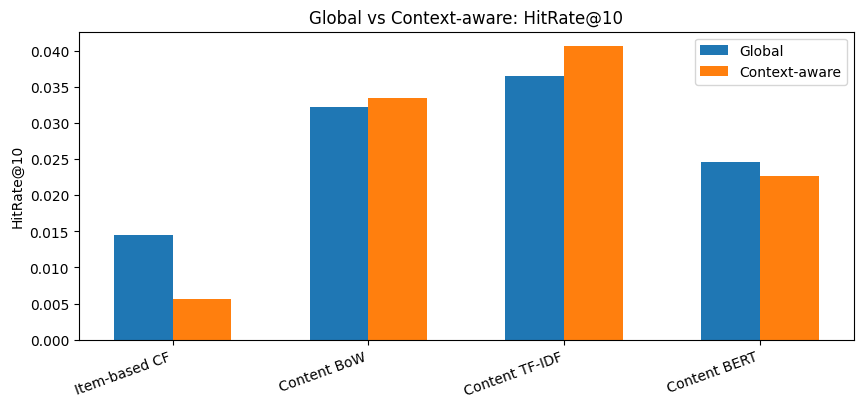

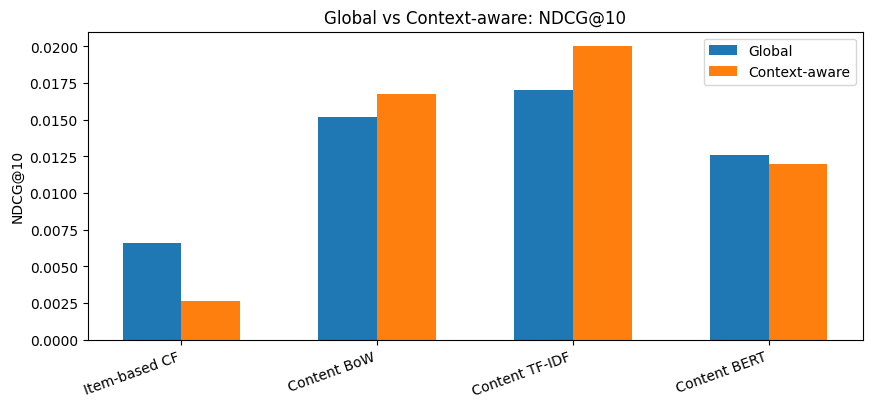

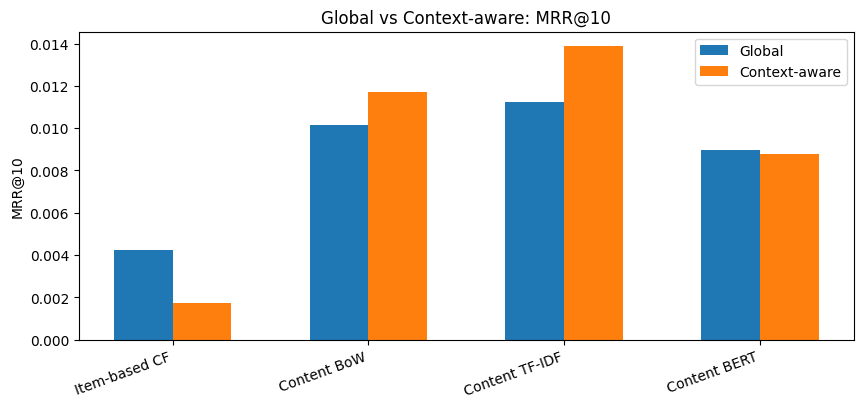

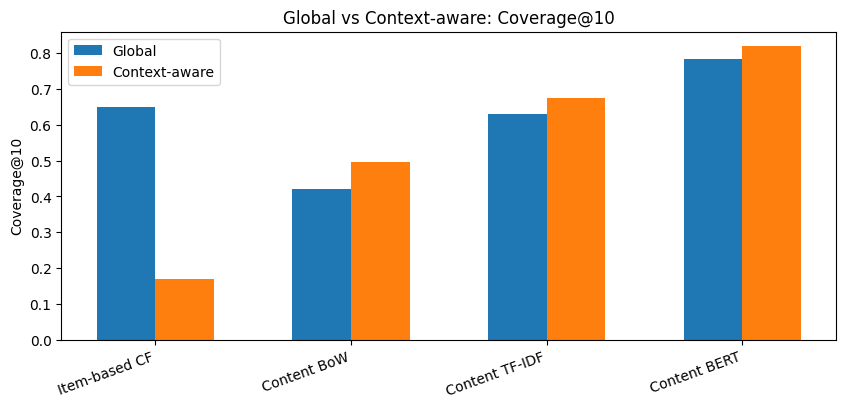

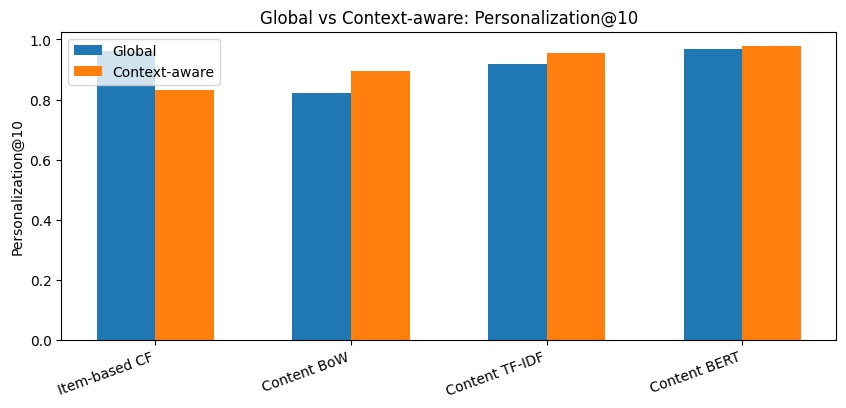

In [721]:
paired_models = [
    ("Item-based CF (global)", "Context-aware Item-based CF (season)"),
    ("Content BoW (global)", "Context-aware Content BoW (season)"),
    ("Content TF-IDF (global)", "Context-aware Content TF-IDF (season)"),
    ("Content BERT (global)", "Context-aware Content BERT (season)")
]

main_metric_cols = [
    f"HitRate@{TOP_K}",
    f"NDCG@{TOP_K}",
    f"MRR@{TOP_K}",
    f"Coverage@{TOP_K}",
    f"Personalization@{TOP_K}"
]

for metric in main_metric_cols:
    plot_rows = []

    for global_name, context_name in paired_models:
        g_val = context_impact_results_df.loc[
            context_impact_results_df["Model"] == global_name, metric
        ].iloc[0]
        c_val = context_impact_results_df.loc[
            context_impact_results_df["Model"] == context_name, metric
        ].iloc[0]

        plot_rows.append({"Pair": global_name.replace(" (global)", ""), "Setting": "Global", metric: g_val})
        plot_rows.append({"Pair": global_name.replace(" (global)", ""), "Setting": "Context-aware", metric: c_val})

    plot_df = pd.DataFrame(plot_rows)

    plt.figure(figsize=(10, 4))
    for setting in ["Global", "Context-aware"]:
        subset = plot_df[plot_df["Setting"] == setting]
        x = np.arange(len(subset))
        offset = -0.15 if setting == "Global" else 0.15
        plt.bar(x + offset, subset[metric], width=0.3, label=setting)

    plt.xticks(np.arange(len(subset)), subset["Pair"], rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"Global vs Context-aware: {metric}")
    plt.legend()
    plt.show()

The visual comparison makes the trade-offs easier to see. The most striking pattern is that the effect of context depends strongly on the recommender family. For **Item-based CF**, every important bar moves in the wrong direction: ranking metrics fall sharply, and even coverage and personalization decline. This confirms that the seasonal split damages the collaborative signal more than it helps.

For **BoW** and especially **TF-IDF**, the opposite happens. The contextual versions improve not only in **HitRate**, **NDCG**, and **MRR**, but also in **Coverage** and **Personalization**. This is the most convincing evidence in favor of context in the notebook so far, because it shows simultaneous gains in both relevance and broader system behavior.

The **BERT** case is the most subtle. The contextual version has slightly lower relevance bars but slightly higher coverage and personalization bars. This suggests that seasonal contextualization may be making the model more exploratory or more differentiated across users, but not more accurate at placing the held-out relevant hotel near the top of the list. In practice, this could happen if the contextual split produces embeddings that are more diverse but less stable.

So these charts reinforce a key methodological lesson: the value of context cannot be judged from one metric alone. A context-aware recommender may become more personalized or cover more of the catalog, while still failing to improve the ranking of the truly relevant future item.

### 11.6 Context impact by season

Since our contextual models are season-based, it is useful to inspect whether performance differs across the seasonal slices of the test set. This helps us understand whether the contextual gains, if any, are concentrated in specific parts of the year or are more uniform.

This is also useful because a context may be beneficial only in some situations. A context-aware recommender does not need to improve every slice equally in order to be meaningful.

In [722]:
# Build a user -> season lookup from the test set
test_user_season = (
    context_test_df.groupby("username")["season"]
    .first()
    .to_dict()
)

def evaluate_recommendation_table_by_context(
    recs_df,
    ground_truth_df,
    user_context_dict,
    top_k=10
):
    rows = []

    for ctx_value in sorted(set(user_context_dict.values())):
        ctx_users = [u for u, c in user_context_dict.items() if c == ctx_value]

        gt_ctx = ground_truth_df[ground_truth_df["username"].isin(ctx_users)].copy()
        gt_ctx_dict = gt_ctx.groupby("username")["offering_id"].apply(set).to_dict()

        recs_ctx = recs_df[recs_df["username"].isin(ctx_users)].copy()

        metrics = evaluate_recommendation_table(
            recs_df=recs_ctx,
            ground_truth_dict=gt_ctx_dict,
            top_k=top_k
        )
        metrics["ContextValue"] = ctx_value
        rows.append(metrics)

    return pd.DataFrame(rows)

In [723]:
season_eval_item_global = evaluate_recommendation_table_by_context(
    recs_df=item_knn_recs,
    ground_truth_df=ground_truth_df,
    user_context_dict=test_user_season,
    top_k=TOP_K
)

season_eval_item_context = evaluate_recommendation_table_by_context(
    recs_df=context_item_knn_recs,
    ground_truth_df=ground_truth_df,
    user_context_dict=test_user_season,
    top_k=TOP_K
)

print("Global item-based CF by season")
display(season_eval_item_global)

print("Context-aware item-based CF by season")
display(season_eval_item_context)

Global item-based CF by season


,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,ContextValue
0,0.012439,0.001244,0.012439,0.005852,0.003905,0.003905,0.580332,1849,1849,fall
1,0.019499,0.001950,0.019499,0.009728,0.006732,0.006732,0.342105,359,359,spring
2,0.019403,0.001940,0.019403,0.007551,0.004055,0.004055,0.427978,670,670,summer
3,0.013220,0.001322,0.013220,0.006239,0.004110,0.004110,0.552632,1059,1059,winter


Context-aware item-based CF by season


,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,ContextValue
0,0.005949,0.000595,0.005949,0.002675,0.001703,0.001703,0.092105,1849,1849,fall
1,0.008357,0.000836,0.008357,0.002603,0.001021,0.001021,0.033934,359,359,spring
2,0.004478,0.000448,0.004478,0.003012,0.002537,0.002537,0.044321,670,670,summer
3,0.004721,0.000472,0.004721,0.002230,0.001512,0.001512,0.063019,1059,1059,winter


In [724]:
season_eval_tfidf_global = evaluate_recommendation_table_by_context(
    recs_df=tfidf_recs,
    ground_truth_df=ground_truth_df,
    user_context_dict=test_user_season,
    top_k=TOP_K
)

season_eval_tfidf_context = evaluate_recommendation_table_by_context(
    recs_df=context_tfidf_recs,
    ground_truth_df=ground_truth_df,
    user_context_dict=test_user_season,
    top_k=TOP_K
)

print("Global TF-IDF by season")
display(season_eval_tfidf_global)

print("Context-aware TF-IDF by season")
display(season_eval_tfidf_context)

Global TF-IDF by season


,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,ContextValue
0,0.030827,0.003083,0.030827,0.014975,0.010285,0.010285,0.536704,1846,1849,fall
1,0.066852,0.006685,0.066852,0.031084,0.020112,0.020112,0.342798,359,359,spring
2,0.049254,0.004925,0.049254,0.023371,0.015611,0.015611,0.408587,670,670,summer
3,0.028329,0.002833,0.028329,0.011944,0.007060,0.007060,0.440443,1058,1059,winter


Context-aware TF-IDF by season


,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,ContextValue
0,0.037317,0.003732,0.037317,0.017970,0.012306,0.012306,0.601108,1846,1849,fall
1,0.058496,0.005850,0.058496,0.031157,0.022843,0.022843,0.388504,359,359,spring
2,0.050746,0.005075,0.050746,0.027385,0.020194,0.020194,0.474377,670,670,summer
3,0.033994,0.003399,0.033994,0.015126,0.009571,0.009571,0.493767,1058,1059,winter


The seasonal breakdown is extremely useful because it shows that contextual gains are **not evenly distributed across the year**.

For **Item-based CF**, the contextual version is worse in every season. The drop is especially severe in **spring**, where HitRate@10 falls from **0.019499** to **0.008357**, and in **summer**, where it falls from **0.019403** to **0.004478**. This suggests that the problem is not a single unlucky season, but a structural weakness of seasonal pre-filtering for memory-based collaborative filtering in this dataset. Once the interaction matrix is partitioned, the local item-item neighborhoods become too fragile.

For **TF-IDF**, the picture is much more favorable. The contextual version improves over the global one in **fall**, **summer**, and **winter** across the main ranking metrics. In **spring**, the situation is more subtle: **HitRate@10** decreases from **0.066852** to **0.058496**, but **NDCG@10** slightly increases from **0.031084** to **0.031157**, and **MRR@10** rises more clearly from **0.020112** to **0.022843**. This means the contextual model retrieves the relevant hotel for slightly fewer users, but when it succeeds, it tends to place it **higher in the ranking**.

That distinction is important. It suggests that context can change not only whether the correct item is retrieved, but also how sharply the model ranks it once retrieved. So even the seasons where the contextual effect is mixed should not be read as simple failure.

Another point worth noting is the uneven **sample sizes**: fall has **1,849** evaluable users, winter **1,059**, summer **670**, and spring only **359**. Smaller seasonal slices make the estimates noisier, especially in spring. Therefore, seasonal results should be interpreted carefully: some variability may reflect genuine context effects, but some may also come from the reduced size of the context-specific test subsets.

### 11.7 Interpreting context gains and losses

The effect of context should be interpreted carefully.

If the contextual model improves ranking metrics such as Hit Rate, NDCG, or MRR, this suggests that the chosen context captures meaningful shifts in user preference or item attractiveness.

If context improves personalization but not ranking quality, this suggests that the recommender is generating more differentiated lists without necessarily becoming more accurate.

If context fails to improve performance, this does not automatically mean the contextual idea is wrong. It may instead indicate that:
- the context is weak
- the context is relevant only for some users or seasons
- the contextual slices are too sparse
- the chosen pre-filtering strategy discards too much data

This type of balanced interpretation is fully consistent with the course framework, which treats context as potentially useful but not automatically beneficial. 

A useful way to interpret these results is to separate at least **three different mechanisms** through which context can help or hurt.

First, context can help because user preferences or item attractiveness may genuinely vary across seasons. In that case, a seasonal model is closer to the true data-generating process and should improve ranking. This appears to be happening for the lexical content-based models, especially TF-IDF.

Second, context can hurt because it reduces the amount of data available to estimate each local model. This is the classic **fragmentation cost** of pre-filtering. The collaborative filtering results strongly suggest that this cost dominates for item-based CF: the seasonal subsets are simply too weak to sustain reliable item-item similarity estimation.

Third, context can help one metric while hurting another because it changes the **shape** of the recommendation lists. A contextual model may become more specialized or diverse, increasing coverage or personalization, but that does not guarantee that the held-out relevant hotel will be ranked higher. The contextual BERT result is a good example of this more ambiguous situation.

So when context reduces accuracy, the right conclusion is not necessarily that season is irrelevant. It may instead mean that the chosen modeling strategy cannot exploit that seasonal signal efficiently. In this notebook, that seems to be the case for seasonal item-based CF, and possibly also for BERT once the review corpus is split into smaller seasonal fragments.

### 11.8 Practical interpretation for the hotel domain

In the hotel domain, a useful seasonal context effect would mean that users are not merely rating hotels differently on average across the year, but that the relative attractiveness of hotels changes with season. This can happen even when the average rating remains stable.

For example:
- some hotels may be more attractive in summer because of leisure-related features
- some may be preferred in winter because of urban or business-related travel patterns
- review language may emphasize different hotel attributes in different seasons

This is why the contextual comparison in this section is important: it tests whether those seasonal differences are strong enough to improve actual recommendation quality.

From a hotel-domain perspective, the positive TF-IDF and BoW results are quite plausible. Hotels are not static products: the same hotel may be perceived differently across seasons because travelers’ purposes, surrounding activities, weather conditions, and location advantages change over the year. Reviews written in winter may emphasize warmth, indoor comfort, holiday atmosphere, or business convenience, while summer reviews may emphasize leisure, walkability, sightseeing, or outdoor attractiveness.

This kind of shift is exactly the sort of signal that lexical models can capture well, because they respond directly to changes in the terms used to describe hotels. If seasonal review language becomes more coherent within each slice, then contextual lexical profiles can become more informative than a single global profile.

By contrast, the poor collaborative result suggests that seasonal context may not manifest strongly enough in the **co-rating structure** of the interaction matrix, or at least not strongly enough to survive the loss of data induced by pre-filtering. So the same context variable may be useful for one family of recommenders and harmful for another, depending on how each family represents the problem.

### 11.9 Summary of context impact

This section evaluates whether introducing season context improves recommendation quality relative to the corresponding non-contextual models.

The comparison is deliberately pairwise and controlled: each contextual model is compared only with its direct global counterpart. This makes the interpretation of the results much clearer and allows us to distinguish real contextual gains from simple modeling noise.

The main question is not whether context is theoretically interesting, but whether it produces measurable benefits in this specific hotel recommendation setting. The answer to that question will guide the final conclusions of the project and the later discussion on whether the added modeling complexity is justified.

In [725]:
# Optional: save the context-impact tables for later reuse
context_impact_results_df.to_csv("context_impact_results_part11.csv", index=False)
memory_context_delta_df.to_csv("memory_context_delta_part11.csv", index=False)
bow_context_delta_df.to_csv("bow_context_delta_part11.csv", index=False)
tfidf_context_delta_df.to_csv("tfidf_context_delta_part11.csv", index=False)
bert_context_delta_df.to_csv("bert_context_delta_part11.csv", index=False)

This section leads to a balanced but quite informative conclusion. Introducing season as context does **not** produce a universal improvement. For **item-based collaborative filtering**, contextual pre-filtering clearly makes the recommender worse: ranking quality, coverage, and personalization all decline, indicating that the seasonal split damages the collaborative signal through excessive sparsity.

For the **content-based family**, however, the story is more positive. Seasonal contextualization improves **BoW** and especially **TF-IDF**, with TF-IDF becoming the strongest model in the paired with-vs-without-context comparison. This suggests that season is useful when it helps build **better item representations from review text**. In other words, context seems to matter more in the **description space** of hotels than in the **interaction-overlap space**.

The **BERT** result remains intermediate: contextualization slightly hurts the ranking metrics while still improving coverage and personalization. This is a good reminder that richer semantic models are not automatically the biggest beneficiaries of context. A contextual split can either sharpen the signal or remove too much useful information, depending on the model.

Overall, the evidence suggests that **season is a meaningful context**, but only when the recommender can exploit it without becoming too data-hungry. In this notebook, that condition is satisfied best by the lexical content-based models, only partially by BERT, and not at all by memory-based collaborative filtering.

## 12. Hybrid and ensemble recommenders

In this section, we combine multiple recommenders into hybrid models. The motivation is that different recommendation families capture different signals:

- popularity-based models capture global item attractiveness
- collaborative filtering captures preference patterns from interaction history
- content-based models capture similarity in hotel descriptions and review language
- context-aware content-based models capture seasonal shifts in the descriptive profile of hotels

A hybrid recommender can therefore be stronger than any individual component if it combines complementary sources of information effectively.

Rather than choosing the combination weights arbitrarily, we use a systematic grid search over ensemble weights. This allows us to evaluate how the different models interact and to identify the combinations that produce the strongest offline performance.

### 12.1 Why hybrid recommenders are useful here

The previous sections suggest that no single recommender dominates every dimension of performance.

In particular:

- popularity-based models remain strong baselines in this hotel dataset
- SVD is the strongest collaborative filtering model
- context-aware TF-IDF is the strongest contextual model
- different models exhibit different trade-offs between ranking quality, coverage, and personalization

For this reason, a hybrid recommender is a natural next step. The objective is to combine the strengths of the best standalone models while mitigating their individual weaknesses.

### 12.2 Hybrid design

We use a weighted score-based ensemble. For each user-item pair, each recommender contributes a normalized score, and the final hybrid score is a weighted sum of those normalized components.

Formally, if the component recommenders are $R_1, R_2, \dots, R_M$, the hybrid score for user $u$ and item $i$ is:

$$
s_{\text{hyb}}(u,i) = \sum_{m=1}^{M} w_m \, \tilde{s}_m(u,i)
$$

where:

- $\tilde{s}_m(u,i)$ is the normalized score produced by recommender $m$
- $w_m \ge 0$ is the weight of recommender $m$
- $\sum_m w_m = 1$

This design is attractive because it is simple, interpretable, and directly compatible with the recommendation tables already generated in the notebook.

### 12.3 Candidate component models

Based on the results obtained so far, we focus on the strongest and most complementary models:

- **Popular**
- **Weighted Popular**
- **SVD**
- **Content TF-IDF**
- **Context-aware Content TF-IDF**

These models cover global popularity, collaborative filtering, non-contextual content, and contextual content. Together, they provide a strong basis for hybridization.

In [726]:
hybrid_candidates = {
    "Popular": popular_recs,
    "Weighted Popular": weighted_pop_recs,
    "SVD": svd_recs,
    "Content TF-IDF": tfidf_recs,
    "Context-aware Content TF-IDF": context_tfidf_recs,
}

for name, df in hybrid_candidates.items():
    print(name, df.shape)

Popular (39370, 4)
Weighted Popular (39370, 4)
SVD (39370, 4)
Content TF-IDF (39330, 4)
Context-aware Content TF-IDF (39330, 5)


### 12.4 Score normalization

Before combining models, we normalize their scores within each user. This is necessary because different recommenders produce scores on different scales.

For example:
- popularity-based scores may be interaction counts
- SVD scores are predicted ratings
- content-based scores are similarity-weighted values

Without normalization, the model with the largest numerical scale would dominate the ensemble regardless of its actual predictive value.

In [727]:
def minmax_normalize_scores(df, user_col="username", score_col="score"):
    df = df.copy()

    def _scale(group):
        s = group[score_col].astype(float)
        s_min = s.min()
        s_max = s.max()

        if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
            group[score_col] = 0.0
        else:
            group[score_col] = (s - s_min) / (s_max - s_min)

        return group

    return df.groupby(user_col, group_keys=False).apply(_scale)

### 12.5 Building weighted hybrids

The function below takes a dictionary of recommendation tables and a dictionary of weights, normalizes the component scores, and builds the final top-$K$ hybrid recommendation list.

In [728]:
def build_weighted_hybrid(recs_dict, weights, top_k=10):
    merged = []

    for model_name, recs in recs_dict.items():
        if recs.empty:
            continue

        tmp = recs[["username", "offering_id", "score"]].copy()
        tmp = minmax_normalize_scores(tmp, user_col="username", score_col="score")
        tmp["weighted_score"] = tmp["score"] * weights[model_name]
        merged.append(tmp[["username", "offering_id", "weighted_score"]])

    if not merged:
        return pd.DataFrame(columns=["username", "offering_id", "score", "rank"])

    hybrid_df = pd.concat(merged, ignore_index=True)

    hybrid_df = (
        hybrid_df.groupby(["username", "offering_id"], as_index=False)["weighted_score"]
        .sum()
        .rename(columns={"weighted_score": "score"})
    )

    hybrid_df = hybrid_df.sort_values(["username", "score"], ascending=[True, False]).copy()
    hybrid_df["rank"] = hybrid_df.groupby("username").cumcount() + 1
    hybrid_df = hybrid_df[hybrid_df["rank"] <= top_k].reset_index(drop=True)

    return hybrid_df

### 12.6 First manually chosen hybrid

Before performing a full grid search, we build one initial hybrid using the strongest standalone signals identified so far:

- Popular
- SVD
- Context-aware TF-IDF

This gives a first reference point for the ensemble family.

In [ ]:
hybrid_recs_initial = build_weighted_hybrid(
    recs_dict={
        "Popular": popular_recs,
        "SVD": svd_recs,
        "Context-aware Content TF-IDF": context_tfidf_recs,
    },
    weights={
        "Popular": 0.25,
        "SVD": 0.35,
        "Context-aware Content TF-IDF": 0.40,
    },
    top_k=TOP_K
)

print("Initial hybrid shape:", hybrid_recs_initial.shape)
hybrid_recs_initial.head()

Initial hybrid shape: (39370, 4)


,username,offering_id,score,rank
0,,1516481,0.720232,1
1,,781627,0.515625,2
2,,1152288,0.500143,3
3,,1027494,0.481375,4
4,,2196840,0.407023,5


### 12.7 Evaluating the initial hybrid

We evaluate the initial hybrid using the same metrics introduced earlier. This provides a first indication of whether combining the strongest standalone models is already beneficial.

In [730]:
initial_hybrid_metrics = evaluate_recommendation_table(
    recs_df=hybrid_recs_initial,
    ground_truth_dict=ground_truth_dict,
    top_k=TOP_K
)

initial_hybrid_metrics[f"Personalization@{TOP_K}"] = personalization_at_k(
    recs_df=hybrid_recs_initial,
    top_k=TOP_K,
    sample_users=500,
    random_state=42
)

pd.DataFrame([initial_hybrid_metrics], index=["Initial Hybrid"])

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10
Initial Hybrid,0.02413,0.002413,0.02413,0.01307,0.009697,0.009697,0.527008,3937,3937,0.82427


This first manually chosen hybrid is useful as a sanity check, but its performance is clearly **below the strongest standalone content-based models**. With **HitRate@10 = 0.024130** and **NDCG@10 = 0.013070**, it does not approach either global TF-IDF or context-aware TF-IDF, and its **Coverage@10 = 0.527008** is also only moderate.

This is already an informative result. Combining several intuitively strong signals does **not** automatically produce a stronger recommender. A hybrid can fail when one component is much more informative than the others, because the additional signals dilute rather than sharpen the ranking. That seems to be what is happening here: the popularity and SVD components may add broad structure, but they do not appear strong enough to improve over the contextual TF-IDF signal.

Another important point is that the initial hybrid remains reasonably personalized (**Personalization@10 = 0.824270**), so the problem is not that it collapses to a trivial popularity ranking. The issue is more subtle: it is a genuine hybrid, but not yet a **well-aligned** one. This is exactly why the grid search is necessary.

### 12.8 Grid search over ensemble weights

To make the hybrid design data-driven, we now perform a grid search over candidate ensemble weights.

We begin with three-model hybrids, because they are easier to interpret and are sufficient to test the main interactions between popularity, collaborative filtering, and contextual content. Later, we also extend the search to larger combinations.

In [731]:
import itertools

In [732]:
def generate_weight_combinations(step=0.1, n_models=3):
    """
    Generate all nonnegative weight tuples summing to 1
    on a coarse grid.
    """
    values = np.arange(0, 1 + step, step)
    combos = []

    for weights in itertools.product(values, repeat=n_models):
        if np.isclose(sum(weights), 1.0):
            combos.append(weights)

    return combos

In [733]:
three_model_candidates = {
    "Popular": popular_recs,
    "SVD": svd_recs,
    "Context-aware Content TF-IDF": context_tfidf_recs,
}

weight_grid_3 = generate_weight_combinations(step=0.1, n_models=3)
print("Number of 3-model weight combinations:", len(weight_grid_3))

Number of 3-model weight combinations: 66


### 12.9 Choosing an objective for model selection

Since recommendation quality is multidimensional, we do not want to optimize only one metric blindly.

For the first grid search, we rank hybrids primarily by **NDCG@K**, because it rewards correct ranking near the top of the recommendation list. We also keep the other metrics, especially Hit Rate, Coverage, and Personalization, to make sure that improvements are not too narrow.

Later, if desired, we can also define a composite objective that balances relevance and broader recommender behavior.

In [734]:
grid_rows_3 = []

for w_pop, w_svd, w_ctx_tfidf in weight_grid_3:
    weights = {
        "Popular": w_pop,
        "SVD": w_svd,
        "Context-aware Content TF-IDF": w_ctx_tfidf,
    }

    hybrid_recs = build_weighted_hybrid(
        recs_dict=three_model_candidates,
        weights=weights,
        top_k=TOP_K
    )

    metrics = evaluate_recommendation_table(
        recs_df=hybrid_recs,
        ground_truth_dict=ground_truth_dict,
        top_k=TOP_K
    )

    metrics[f"Personalization@{TOP_K}"] = personalization_at_k(
        recs_df=hybrid_recs,
        top_k=TOP_K,
        sample_users=500,
        random_state=42
    )

    metrics["w_Popular"] = w_pop
    metrics["w_SVD"] = w_svd
    metrics["w_ContextTFIDF"] = w_ctx_tfidf

    grid_rows_3.append(metrics)

grid_search_results_3_df = pd.DataFrame(grid_rows_3)
grid_search_results_3_df = grid_search_results_3_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

grid_search_results_3_df.head(20)

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,w_Popular,w_SVD,w_ContextTFIDF
0,0.038354,0.003835,0.038354,0.019349,0.013645,0.013645,0.666205,3937,3937,0.943475,0.0,0.0,1.0
1,0.034036,0.003404,0.034036,0.017899,0.013017,0.013017,0.644737,3937,3937,0.945416,0.0,0.1,0.9
2,0.033528,0.003353,0.033528,0.017720,0.012928,0.012928,0.630886,3937,3937,0.849901,0.1,0.0,0.9
3,0.033274,0.003327,0.033274,0.017345,0.012575,0.012575,0.625346,3937,3937,0.937186,0.0,0.2,0.8
4,0.031750,0.003175,0.031750,0.017148,0.012688,0.012688,0.619806,3937,3937,0.891593,0.1,0.1,0.8
5,0.032258,0.003226,0.032258,0.017023,0.012443,0.012443,0.608033,3937,3937,0.812502,0.2,0.0,0.8
6,0.031750,0.003175,0.031750,0.016693,0.012202,0.012202,0.611496,3937,3937,0.927474,0.0,0.3,0.7
7,0.031242,0.003124,0.031242,0.016477,0.012069,0.012069,0.592105,3937,3937,0.778878,0.3,0.0,0.7
8,0.030480,0.003048,0.030480,0.016469,0.012224,0.012224,0.599723,3937,3937,0.908085,0.1,0.2,0.7
9,0.030480,0.003048,0.030480,0.016459,0.012222,0.012222,0.601108,3937,3937,0.809746,0.2,0.1,0.7


The three-model grid search produces a very striking outcome: the best-performing “hybrid” is **not really a hybrid at all**. The top row assigns weight **1.0** to **Context-aware Content TF-IDF** and weight **0.0** to both **Popular** and **SVD**, yielding **HitRate@10 = 0.038354** and **NDCG@10 = 0.019349**.

This means that, within this candidate set, the search finds no evidence that the popularity or collaborative component improves the best contextual content model. In fact, the optimal solution is simply to keep the contextual TF-IDF recommender alone. That is an important substantive conclusion, not a disappointing technicality. It tells us that the contextual TF-IDF signal is already so strong that the other two components are either redundant or noisy.

At the same time, the rows immediately below are also interesting. Small additions of **SVD** or **Popular** produce only very limited changes, and in most cases these changes slightly reduce the best NDCG. This suggests that the extra models are not contributing complementary ranking information at the top of the list. Their signal may overlap with what TF-IDF already captures, or it may be too weak relative to the contextual content model to survive score normalization and weighted combination.

So the main lesson of this table is that **hybridization is only useful when the component models contribute genuinely complementary information**. Here, for the three-model candidate family, that condition seems weak.

### 12.10 Best three-model hybrid

We now extract the best-performing three-model hybrid according to NDCG@K and generate its recommendation table for later comparison.

In [735]:
best_row_3 = grid_search_results_3_df.iloc[0]

best_weights_3 = {
    "Popular": best_row_3["w_Popular"],
    "SVD": best_row_3["w_SVD"],
    "Context-aware Content TF-IDF": best_row_3["w_ContextTFIDF"],
}

print("Best 3-model weights:", best_weights_3)
print(best_row_3[[f"HitRate@{TOP_K}", f"NDCG@{TOP_K}", f"MRR@{TOP_K}", f"Coverage@{TOP_K}", f"Personalization@{TOP_K}"]])

Best 3-model weights: {'Popular': 0.0, 'SVD': 0.0, 'Context-aware Content TF-IDF': 1.0}
HitRate@10            0.038354
NDCG@10               0.019349
MRR@10                0.013645
Coverage@10           0.666205
Personalization@10    0.943475
Name: 0, dtype: float64


The extraction of the best three-model hybrid confirms the message of the grid search: the selected weights are **Popular = 0.0**, **SVD = 0.0**, and **Context-aware Content TF-IDF = 1.0**. In other words, the best three-model hybrid collapses exactly to the contextual TF-IDF recommender.

This is a very meaningful outcome because it rules out a common expectation in recommender systems: that combining popularity, collaborative filtering, and content almost always helps. In this notebook, the data suggest something more selective. The contextual TF-IDF model already contains the most predictive structure for the offline ranking task, and the other components do not add enough extra information to improve the top of the recommendation list.

Methodologically, this is also reassuring. The grid search is not forcing a mixture for the sake of mixing. It is correctly identifying that, under the current evaluation protocol, the best ensemble is the degenerate one that puts all the mass on the strongest standalone component.

In [736]:
hybrid_recs_best_3 = build_weighted_hybrid(
    recs_dict=three_model_candidates,
    weights=best_weights_3,
    top_k=TOP_K
)

print("Best 3-model hybrid shape:", hybrid_recs_best_3.shape)
hybrid_recs_best_3.head()

Best 3-model hybrid shape: (39370, 4)


,username,offering_id,score,rank
0,,87629,1.000000,1
1,,89600,0.964924,2
2,,1027494,0.908466,3
3,,1516481,0.472092,4
4,,1456261,0.456260,5


### 12.11 Extending the search to four-model hybrids

To test whether a larger ensemble helps further, we now add one more component. The most natural candidates are:

- **Weighted Popular**
- **Content TF-IDF**

This lets us test whether the hybrid benefits from richer popularity modeling or from adding both global and contextual content signals.

In [737]:
four_model_candidates = {
    "Popular": popular_recs,
    "SVD": svd_recs,
    "Content TF-IDF": tfidf_recs,
    "Context-aware Content TF-IDF": context_tfidf_recs,
}

weight_grid_4 = generate_weight_combinations(step=0.2, n_models=4)
print("Number of 4-model weight combinations:", len(weight_grid_4))

Number of 4-model weight combinations: 56


In [738]:
grid_rows_4 = []

for w_pop, w_svd, w_tfidf, w_ctx_tfidf in weight_grid_4:
    weights = {
        "Popular": w_pop,
        "SVD": w_svd,
        "Content TF-IDF": w_tfidf,
        "Context-aware Content TF-IDF": w_ctx_tfidf,
    }

    hybrid_recs = build_weighted_hybrid(
        recs_dict=four_model_candidates,
        weights=weights,
        top_k=TOP_K
    )

    metrics = evaluate_recommendation_table(
        recs_df=hybrid_recs,
        ground_truth_dict=ground_truth_dict,
        top_k=TOP_K
    )

    metrics[f"Personalization@{TOP_K}"] = personalization_at_k(
        recs_df=hybrid_recs,
        top_k=TOP_K,
        sample_users=500,
        random_state=42
    )

    metrics["w_Popular"] = w_pop
    metrics["w_SVD"] = w_svd
    metrics["w_TFIDF"] = w_tfidf
    metrics["w_ContextTFIDF"] = w_ctx_tfidf

    grid_rows_4.append(metrics)

grid_search_results_4_df = pd.DataFrame(grid_rows_4)
grid_search_results_4_df = grid_search_results_4_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

grid_search_results_4_df.head(20)

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,w_Popular,w_SVD,w_TFIDF,w_ContextTFIDF
0,0.039370,0.003937,0.039370,0.019643,0.013746,0.013746,0.666205,3937,3937,0.944169,0.0,0.0,0.0,1.0
1,0.038862,0.003886,0.038862,0.019258,0.013403,0.013403,0.655817,3937,3937,0.929037,0.0,0.0,0.2,0.8
2,0.038100,0.003810,0.038100,0.018785,0.013019,0.013019,0.651662,3937,3937,0.923748,0.0,0.0,0.4,0.6
3,0.038100,0.003810,0.038100,0.018425,0.012540,0.012540,0.648199,3937,3937,0.921179,0.0,0.0,0.6,0.4
4,0.037592,0.003759,0.037592,0.017941,0.012074,0.012074,0.635734,3937,3937,0.919314,0.0,0.0,0.8,0.2
5,0.033528,0.003353,0.033528,0.017418,0.012600,0.012600,0.624654,3937,3937,0.937377,0.0,0.2,0.0,0.8
6,0.032258,0.003226,0.032258,0.017023,0.012443,0.012443,0.608033,3937,3937,0.812502,0.2,0.0,0.0,0.8
7,0.033274,0.003327,0.033274,0.017013,0.012149,0.012149,0.609418,3937,3937,0.927334,0.0,0.2,0.2,0.6
8,0.032512,0.003251,0.032512,0.016779,0.012053,0.012053,0.600416,3937,3937,0.814109,0.2,0.0,0.2,0.6
9,0.034544,0.003454,0.034544,0.016470,0.011017,0.011017,0.618421,3937,3937,0.913678,0.0,0.0,1.0,0.0


The four-model search reinforces the same conclusion even more strongly. After adding **global TF-IDF** as an additional component, the best solution still assigns all the weight to **Context-aware Content TF-IDF** and zero to the other models. So even when the hybrid is allowed to combine **global and contextual content** together with **popularity** and **SVD**, the search still prefers the pure contextual model.

This is an important result because it means the contextual TF-IDF model is not just the strongest within a narrow candidate family. It also remains dominant when the ensemble is enlarged with another strong lexical recommender. Therefore, the contextual improvement seen earlier is not merely one useful signal among many: it is the one that the hybrid search consistently identifies as the most valuable.

The rows below the optimum are still informative. Some combinations with mixed weights achieve reasonably close performance, which suggests that the other components are not entirely useless. But the fact that none of them surpass the pure contextual TF-IDF model indicates that their contribution is either too small or too inconsistent to improve the main ranking objective.

### 12.12 Best four-model hybrid

We extract the best-performing four-model hybrid and compare it with the best three-model hybrid.

In [739]:
best_row_4 = grid_search_results_4_df.iloc[0]

best_weights_4 = {
    "Popular": best_row_4["w_Popular"],
    "SVD": best_row_4["w_SVD"],
    "Content TF-IDF": best_row_4["w_TFIDF"],
    "Context-aware Content TF-IDF": best_row_4["w_ContextTFIDF"],
}

print("Best 4-model weights:", best_weights_4)
print(best_row_4[[f"HitRate@{TOP_K}", f"NDCG@{TOP_K}", f"MRR@{TOP_K}", f"Coverage@{TOP_K}", f"Personalization@{TOP_K}"]])

Best 4-model weights: {'Popular': 0.0, 'SVD': 0.0, 'Content TF-IDF': 0.0, 'Context-aware Content TF-IDF': 1.0}
HitRate@10            0.039370
NDCG@10               0.019643
MRR@10                0.013746
Coverage@10           0.666205
Personalization@10    0.944169
Name: 0, dtype: float64


In [740]:
hybrid_recs_best_4 = build_weighted_hybrid(
    recs_dict=four_model_candidates,
    weights=best_weights_4,
    top_k=TOP_K
)

print("Best 4-model hybrid shape:", hybrid_recs_best_4.shape)
hybrid_recs_best_4.head()

Best 4-model hybrid shape: (39370, 4)


,username,offering_id,score,rank
0,,87629,1.000000,1
1,,89600,0.964924,2
2,,1027494,0.908466,3
3,,1516481,0.472092,4
4,,1456261,0.456260,5


The best four-model hybrid ends up identical in spirit to the best three-model hybrid: it is effectively the **context-aware TF-IDF recommender itself**. This makes the overall interpretation very clear. The hybrid search is not uncovering a richer multi-signal combination; instead, it is validating the centrality of the contextual lexical signal.

This also tells us something about the relationship between **global TF-IDF** and **context-aware TF-IDF**. Since the best ensemble gives zero weight to the global version, the seasonal contextualization appears to subsume the useful part of the global lexical model while adding extra information of its own. In that sense, the contextual TF-IDF representation is not merely complementary to the global one; it is largely **dominating** it.

### 12.13 Comparing standalone and hybrid models

We now compare the strongest standalone models with the best hybrids found through the grid search. This helps us determine whether ensembling truly improves recommendation quality or merely redistributes the same signal.

In [741]:
hybrid_comparison_models = {
    "Popular": popular_recs,
    "SVD": svd_recs,
    "Content TF-IDF": tfidf_recs,
    "Context-aware Content TF-IDF": context_tfidf_recs,
    "Hybrid (initial)": hybrid_recs_initial,
    "Hybrid (best 3-model)": hybrid_recs_best_3,
    "Hybrid (best 4-model)": hybrid_recs_best_4,
}

hybrid_comparison_rows = []

for model_name, recs_df in hybrid_comparison_models.items():
    metrics = evaluate_recommendation_table(
        recs_df=recs_df,
        ground_truth_dict=ground_truth_dict,
        top_k=TOP_K
    )

    metrics[f"Personalization@{TOP_K}"] = personalization_at_k(
        recs_df=recs_df,
        top_k=TOP_K,
        sample_users=500,
        random_state=42
    )

    metrics["Model"] = model_name
    hybrid_comparison_rows.append(metrics)

hybrid_comparison_results_df = pd.DataFrame(hybrid_comparison_rows)
hybrid_comparison_results_df = hybrid_comparison_results_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

hybrid_comparison_results_df

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,Model
0,0.040640,0.004064,0.040640,0.020010,0.013873,0.013873,0.675208,3933,3937,0.954010,Context-aware Content TF-IDF
1,0.039370,0.003937,0.039370,0.019643,0.013746,0.013746,0.666205,3937,3937,0.944169,Hybrid (best 4-model)
2,0.038354,0.003835,0.038354,0.019349,0.013645,0.013645,0.666205,3937,3937,0.943475,Hybrid (best 3-model)
3,0.036576,0.003658,0.036576,0.017057,0.011220,0.011220,0.628809,3933,3937,0.916804,Content TF-IDF
4,0.024130,0.002413,0.024130,0.013070,0.009697,0.009697,0.527008,3937,3937,0.824270,Hybrid (initial)
5,0.009906,0.000991,0.009906,0.004911,0.003395,0.003395,0.136427,3937,3937,0.768243,SVD
6,0.007620,0.000762,0.007620,0.003404,0.002125,0.002125,0.012465,3937,3937,0.021514,Popular


This final comparison table gives the cleanest summary of the hybrid analysis. The strongest performer remains **Context-aware Content TF-IDF**, with **HitRate@10 = 0.040640**, **NDCG@10 = 0.020010**, and **MRR@10 = 0.013873**. The best three-model and four-model hybrids come very close, but both remain slightly below it in the ranking metrics.

This is a crucial conclusion: in this notebook, **hybridization does not outperform the best standalone recommender**. The best ensembles are competitive, but they do not exceed the contextual TF-IDF baseline. Therefore, the main value of the hybrid analysis is not that it discovers a better recommender, but that it demonstrates that the contextual TF-IDF model is already capturing most of the useful predictive signal.

The comparison also shows that the hybrid models retain high **coverage** and **personalization**. For example, the best four-model hybrid achieves **Coverage@10 = 0.666205** and **Personalization@10 = 0.944169**, both quite strong. So the hybrids are not poor models; they are simply not better than the best contextual lexical recommender on the main ranking objective.

This kind of result is very informative in a project setting. It prevents us from making an overly simplistic claim that “more models always help.” Instead, it suggests that once one component becomes clearly dominant, the marginal benefit of ensembling may be very limited.

### 12.14 Optional composite objective

If desired, the grid search can also be ranked using a broader objective that combines ranking quality, coverage, and personalization. A simple example is:

$$
J = \lambda_1 \log(\mathrm{NDCG@K} + \varepsilon)
+ \lambda_2 \log(\mathrm{Coverage@K} + \varepsilon)
+ \lambda_3 \log(\mathrm{Personalization@K} + \varepsilon)
$$

where $\varepsilon > 0$ avoids numerical issues and the $\lambda$ coefficients control the trade-off between the metrics which should choose such that they sum up to one.

This type of objective is useful when one wants to avoid selecting a model that improves only a single metric while degrading the broader quality of the recommender.

In [841]:
def compute_composite_objective(df, top_k=10, eps=1e-8, lam_NDCG=0.5, lam_cov=0.25, lam_pers=0.25):
    df = df.copy()
    df["CompositeObjective"] = (
       lam_NDCG * np.log(df[f"NDCG@{top_k}"] + eps)
        + lam_cov * np.log(df[f"Coverage@{top_k}"] + eps)
        + lam_pers * np.log(df[f"Personalization@{top_k}"] + eps)
    )
    return df

In [842]:
grid_search_results_3_composite_df = compute_composite_objective(
    grid_search_results_3_df,
    top_k=TOP_K,
    eps=1e-8,
    lam_cov=0.25,
    lam_pers=0.25
).sort_values("CompositeObjective", ascending=False).reset_index(drop=True)

grid_search_results_3_composite_df.head(20)

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,w_Popular,w_SVD,w_ContextTFIDF,CompositeObjective
0,0.038354,0.003835,0.038354,0.019349,0.013645,0.013645,0.666205,3937,3937,0.943475,0.0,0.0,1.0,-2.088642
1,0.034036,0.003404,0.034036,0.017899,0.013017,0.013017,0.644737,3937,3937,0.945416,0.0,0.1,0.9,-2.135274
2,0.033274,0.003327,0.033274,0.017345,0.012575,0.012575,0.625346,3937,3937,0.937186,0.0,0.2,0.8,-2.160819
3,0.033528,0.003353,0.033528,0.017720,0.012928,0.012928,0.630886,3937,3937,0.849901,0.1,0.0,0.9,-2.172343
4,0.031750,0.003175,0.031750,0.017148,0.012688,0.012688,0.619806,3937,3937,0.891593,0.1,0.1,0.8,-2.181216
5,0.031750,0.003175,0.031750,0.016693,0.012202,0.012202,0.611496,3937,3937,0.927474,0.0,0.3,0.7,-2.188176
6,0.030480,0.003048,0.030480,0.016469,0.012224,0.012224,0.599723,3937,3937,0.908085,0.1,0.2,0.7,-2.205076
7,0.032258,0.003226,0.032258,0.017023,0.012443,0.012443,0.608033,3937,3937,0.812502,0.2,0.0,0.8,-2.212882
8,0.029972,0.002997,0.029972,0.016091,0.011937,0.011937,0.587258,3937,3937,0.903424,0.1,0.3,0.6,-2.223195
9,0.029464,0.002946,0.029464,0.015723,0.011637,0.011637,0.600416,3937,3937,0.915248,0.0,0.4,0.6,-2.225977


This composite objective is especially useful from a business perspective because it makes the hybrid-selection process **configurable** rather than fixed. In practice, a company may not want to optimize only ranking accuracy. Depending on the product strategy, it may want to place more importance on immediate relevance, broader catalog exposure, or stronger personalization. The weighted objective provides exactly this flexibility: once the importance assigned to **NDCG@10**, **Coverage@10**, and **Personalization@10** is specified, the grid search returns the combination of models that best reflects that business priority.

Under the current choice of weights, the objective still gives the largest importance to **NDCG@10**, so the best solution remains the one fully concentrated on **Context-aware Content TF-IDF**. This means that, for a strategy still centered primarily on ranking quality, the search finds no evidence that adding Popular or SVD improves the overall business target enough to justify their inclusion.

However, the value of this analysis is broader than the single top row. The nearby solutions show that, once coverage and personalization are explicitly rewarded, mixed hybrids start to become credible alternatives. This is important operationally: it means the company is not locked into one universal “best model,” but can instead choose the trade-off it wants to prioritize and let the optimization identify the most appropriate ensemble.

In that sense, the composite-objective framework turns hybrid design into a decision tool. If the business goal is to maximize short-term recommendation relevance, the optimizer naturally favors the contextual TF-IDF model. If instead the business wants more catalog exploration, more differentiated user experiences, or a more balanced compromise across objectives, the same procedure can be rerun with different weights and will produce the hybrid that best matches that target.

So the main managerial takeaway is not just which model is first in this table, but that the hybrid framework gives a principled way to translate **business priorities into model weights**. The company can decide what matters most, and the optimization will select the recommender combination that best implements that strategy under the same offline evaluation protocol.

### 12.15 Summary of the hybrid analysis

This section investigates whether combining the strongest recommendation signals leads to better performance than using any single model in isolation.

The hybrid analysis is intentionally systematic: rather than choosing weights heuristically, we perform a grid search over candidate ensembles and evaluate them using the same offline recommendation protocol as the standalone models.

This makes it possible to answer three important questions:

- Does the hybrid outperform the strongest standalone recommender?
- Which component receives the largest weight in the best ensemble?
- Do popularity, collaborative, and contextual content signals complement one another?

The answers to these questions will be important for the final comparison and conclusions of the project.

This section shows that hybridization is **not automatically beneficial**, even when the candidate components are individually strong and conceptually complementary. The most important result is that the grid search does **not** discover a clearly superior mixture of popularity, collaborative filtering, and contextual content signals. Instead, both the three-model and four-model searches identify **Context-aware Content TF-IDF** as the dominant component, and the best solutions effectively collapse to that recommender.

This is a very informative outcome. It means that, in the current hotel recommendation setting, the contextual lexical representation already captures most of the predictive structure needed for the offline ranking task. Popularity and SVD are not useless, but they do not add enough complementary information to improve the top of the recommendation list once the contextual TF-IDF signal is present.

The hybrid models themselves are still strong: they retain good coverage and high personalization, and they remain competitive with the top standalone recommenders. However, they do **not** surpass the best contextual content-based model. Therefore, the main conclusion of this section is not that hybrids win, but that the hybrid search provides an additional validation of the **strength and centrality of context-aware TF-IDF**.

From a methodological point of view, this is a good result. It shows that the grid search behaves sensibly, does not force artificial mixtures, and helps reveal when one recommender already dominates the available signal space.

In [744]:
# Optional: save outputs for later reuse
grid_search_results_3_df.to_csv("grid_search_results_3_part12.csv", index=False)
grid_search_results_4_df.to_csv("grid_search_results_4_part12.csv", index=False)
hybrid_comparison_results_df.to_csv("hybrid_comparison_results_part12.csv", index=False)

## 13. Best practices in evaluation for memory-based methods: CV and CVTT

In the previous sections, the memory-based recommenders were mainly evaluated through a single temporal holdout. While this is already a meaningful and realistic setup, it is still only one split of the data. A stronger evaluation requires checking whether the observed conclusions remain reasonably stable under repeated splits.

Following the course material, we therefore complement the single holdout with two additional evaluation strategies:

- **Cross-Validation (CV)**, which provides a more robust estimate than relying on one isolated split
- **Cross-Validation Through Time (CVTT)**, which preserves the temporal direction of the recommendation problem and is therefore especially relevant in recommender systems with timestamps

The professor’s evaluation material emphasizes that cross-validation is useful because a single split may be optimistic or pessimistic depending on how easy the held-out cases happen to be. CV reduces that dependence by repeating the evaluation across multiple folds. 

At the same time, the professor’s CVTT material stresses that recommender systems should ideally be trained on past data and evaluated on future data, because this is what happens in production. That is exactly the motivation for Cross-Validation Through Time. 

In this section, we apply these best practices specifically to the memory-based recommenders.

### 13.1 Why both CV and CVTT are needed

The two evaluation schemes answer different questions.

#### Cross-Validation (CV)

Standard CV is useful to check the robustness of a model under repeated train/test partitions. It provides a more stable estimate than a single split and is especially helpful when comparing algorithms in a general sense.

However, standard CV does not preserve temporal order. In time-stamped recommender data, this means that some folds may train on interactions that occur after some of the test interactions.

#### Cross-Validation Through Time (CVTT)

CVTT is more realistic for recommender systems with timestamps. In each fold, training uses only interactions observed before the test period, and evaluation is performed on a later period. This better reflects deployment conditions, where recommendations are always based on historical data and evaluated through future user behavior. 

For this reason, CVTT is the more realistic protocol, while standard CV is kept as a complementary robustness check.

### 13.2 Models included in this section

For computational feasibility, we restrict this section to the main memory-based recommenders:

- **User-based collaborative filtering**
- **Item-based collaborative filtering**

We also optionally include the **Popular** baseline as a reference point in the time-based evaluation, following the same logic used in the earlier notebooks, where the temporal folds were used to compare the relative behavior of the main recommenders across time. 

### 13.3 Preparing the memory-based evaluation dataset

We use the reduced explicit-feedback dataset already constructed earlier in the notebook. The evaluation dataset must contain at least:

- user ID
- item ID
- rating
- timestamp

This allows us to run both a standard CV procedure and a chronological CVTT procedure.

In [745]:
memory_eval_df = reduced_df[["username", "offering_id", "overall_rating", "date"]].copy()

memory_eval_df["date"] = pd.to_datetime(memory_eval_df["date"], errors="coerce")
memory_eval_df = memory_eval_df.dropna(subset=["username", "offering_id", "overall_rating", "date"]).copy()

print("Memory evaluation dataset shape:", memory_eval_df.shape)
print("Users:", memory_eval_df["username"].nunique())
print("Items:", memory_eval_df["offering_id"].nunique())
print("Time span:", memory_eval_df["date"].min(), "to", memory_eval_df["date"].max())

Memory evaluation dataset shape: (120618, 4)
Users: 3937
Items: 1444
Time span: 2001-03-28 00:00:00 to 2012-12-20 00:00:00


### 13.4 Standard cross-validation for memory-based models

We begin with a standard CV procedure. Since the memory-based recommenders are implemented through the `surprise` framework for the neighborhood-based models, we can use its built-in cross-validation utilities.

This part evaluates memory-based collaborative filtering from the rating-prediction perspective through RMSE and MAE. Although these are not ranking metrics, they are still useful to assess whether the models reconstruct observed ratings consistently across repeated folds.

In [746]:
from surprise import Dataset, Reader, KNNWithMeans
from surprise.model_selection import cross_validate, KFold

In [747]:
reader = Reader(
    rating_scale=(
        float(memory_eval_df["overall_rating"].min()),
        float(memory_eval_df["overall_rating"].max())
    )
)

memory_surprise_data = Dataset.load_from_df(
    memory_eval_df[["username", "offering_id", "overall_rating"]],
    reader
)

In [748]:
user_knn_algo_cv = KNNWithMeans(
    k=40,
    min_k=3,
    sim_options={
        "name": "pearson",
        "user_based": True
    },
    verbose=False
)

item_knn_algo_cv = KNNWithMeans(
    k=40,
    min_k=3,
    sim_options={
        "name": "pearson",
        "user_based": False
    },
    verbose=False
)

In [749]:
cv_results_user = cross_validate(
    user_knn_algo_cv,
    memory_surprise_data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    return_train_measures=True,
    verbose=True
)

cv_results_item = cross_validate(
    item_knn_algo_cv,
    memory_surprise_data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    return_train_measures=True,
    verbose=True
)

Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.1036  1.0874  1.0910  1.0985  1.0969  1.0955  0.0057  
MAE (testset)     0.8501  0.8387  0.8416  0.8428  0.8443  0.8435  0.0038  
RMSE (trainset)   0.9363  0.9393  0.9378  0.9373  0.9380  0.9377  0.0010  
MAE (trainset)    0.6943  0.7003  0.6975  0.6974  0.6972  0.6973  0.0019  
Fit time          0.59    0.55    0.49    0.31    0.28    0.44    0.12    
Test time         1.18    1.26    1.09    0.94    0.92    1.08    0.13    
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.0887  1.0769  1.0796  1.0826  1.0835  1.0823  0.0040  
MAE (testset)     0.8402  0.8285  0.8321  0.8306  0.8324  0.8328  0.0040  
RMSE (trainset)   0.8642  0.8659  0.8649  0.8649  0.8646  0.8649  0.0006  
MAE (trainset)    0.5520  0.5565  0.5540  0.5540 

In [750]:
def summarize_surprise_cv_results(cv_results, model_name):
    return pd.DataFrame({
        "Model": [model_name],
        "Test RMSE Mean": [np.mean(cv_results["test_rmse"])],
        "Test RMSE Std": [np.std(cv_results["test_rmse"])],
        "Train RMSE Mean": [np.mean(cv_results["train_rmse"])],
        "Test MAE Mean": [np.mean(cv_results["test_mae"])],
        "Test MAE Std": [np.std(cv_results["test_mae"])],
        "Train MAE Mean": [np.mean(cv_results["train_mae"])],
        "Fit Time Mean": [np.mean(cv_results["fit_time"])],
        "Test Time Mean": [np.mean(cv_results["test_time"])],
    })

cv_summary_df = pd.concat([
    summarize_surprise_cv_results(cv_results_user, "User-based CF"),
    summarize_surprise_cv_results(cv_results_item, "Item-based CF"),
], ignore_index=True)

cv_summary_df

,Model,Test RMSE Mean,Test RMSE Std,Train RMSE Mean,Test MAE Mean,Test MAE Std,Train MAE Mean,Fit Time Mean,Test Time Mean
0,User-based CF,1.095455,0.005689,0.937745,0.843476,0.003768,0.697349,0.443398,1.079543
1,Item-based CF,1.082257,0.003999,0.864892,0.832751,0.003975,0.553936,63.165329,127.867830


### Interpreting the standard CV summary

The standard cross-validation results already suggest a consistent advantage for **item-based collaborative filtering** over **user-based collaborative filtering** in the rating-prediction setting. Item-based CF achieves a lower average **Test RMSE** (**1.0823** vs **1.0955**) and a lower average **Test MAE** (**0.8328** vs **0.8435**), indicating more accurate reconstruction of held-out ratings across repeated random folds.

Another useful signal is the variability across folds. The standard deviations are small for both methods, which suggests that the comparison is reasonably stable and not driven by a single favorable split. In particular, item-based CF also has slightly lower dispersion in **Test RMSE** (**0.0040** vs **0.0057**), reinforcing the idea that its advantage is not only better on average but also a bit more consistent.

The train metrics should be interpreted carefully. User-based CF has higher training error than item-based CF as well, so the result is not simply a matter of one model overfitting more aggressively. Instead, it suggests that in this dataset the neighborhood structure among **items** is easier to exploit than the neighborhood structure among **users**. This is plausible in sparse recommendation settings, where many users have limited overlap while hotels can still accumulate enough shared interactions to form more reliable item-to-item relations.

At the same time, this section should not be confused with ranking evaluation. CV here is based on **RMSE** and **MAE**, so it mainly tells us how well the models reconstruct ratings under repeated random partitions. It is therefore best interpreted as a robustness check: the item-based model looks stronger even before moving to the more realistic time-aware validation protocol.

### 13.5 Interpreting standard CV

The purpose of the standard CV analysis is not to replace the recommender-oriented ranking evaluation, but to check whether the memory-based models behave stably under repeated random folds.

In particular, we are interested in:

- the average test RMSE and MAE
- the variability across folds
- the train-test gap, which may indicate overfitting
- the relative stability of user-based and item-based neighborhood models

This gives a first robustness assessment before moving to the more realistic time-based evaluation.

### 13.6 Cross-Validation Through Time (CVTT)

We now move to the more realistic evaluation protocol. As in the earlier notebooks, CVTT repeats the recommendation task across several chronologically ordered folds. In each fold:

- the recommender is trained only on past interactions
- the test set contains interactions from a future time period

This follows exactly the production logic of recommender systems with timestamps and is the most appropriate temporal validation framework for this project. 

In [751]:
CVTT_N_FOLDS = 3
CVTT_TOP_K = TOP_K
CVTT_MAX_USERS = 3000  # sampled evaluation users per fold for computational feasibility

print(f"Number of CVTT folds: {CVTT_N_FOLDS}")
print(f"Top-K cutoff: {CVTT_TOP_K}")
print(f"Max sampled users per fold: {CVTT_MAX_USERS}")

Number of CVTT folds: 3
Top-K cutoff: 10
Max sampled users per fold: 3000


In [752]:
memory_eval_df["year_month"] = memory_eval_df["date"].dt.to_period("M")
time_periods = sorted(memory_eval_df["year_month"].unique())

print("Number of monthly periods:", len(time_periods))
print("First 10 periods:", time_periods[:10])
print("Last 10 periods:", time_periods[-10:])

Number of monthly periods: 139
First 10 periods: [Period('2001-03', 'M'), Period('2001-04', 'M'), Period('2001-08', 'M'), Period('2001-09', 'M'), Period('2001-10', 'M'), Period('2001-11', 'M'), Period('2001-12', 'M'), Period('2002-01', 'M'), Period('2002-02', 'M'), Period('2002-03', 'M')]
Last 10 periods: [Period('2012-03', 'M'), Period('2012-04', 'M'), Period('2012-05', 'M'), Period('2012-06', 'M'), Period('2012-07', 'M'), Period('2012-08', 'M'), Period('2012-09', 'M'), Period('2012-10', 'M'), Period('2012-11', 'M'), Period('2012-12', 'M')]


In [753]:
cvtt_test_periods = time_periods[-CVTT_N_FOLDS:]
print("Selected CVTT test periods:", cvtt_test_periods)

Selected CVTT test periods: [Period('2012-10', 'M'), Period('2012-11', 'M'), Period('2012-12', 'M')]


### 13.7 Building chronological folds

Each CVTT fold uses one month as the test period and all prior interactions as training data.

To make the evaluation manageable, we also sample at most a fixed number of test users per fold. This follows the same practical idea used in the earlier notebook, where CVTT was intentionally kept lighter than the main holdout evaluation for computational feasibility. 

In [754]:
def sample_users_for_evaluation(users, max_users=3000, random_state=42):
    users = np.array(sorted(list(users)))
    if len(users) <= max_users:
        return users
    rng = np.random.default_rng(random_state)
    return rng.choice(users, size=max_users, replace=False)

In [755]:
def build_cvtt_fold(df, test_period):
    train_fold = df[df["year_month"] < test_period].copy()
    test_fold = df[df["year_month"] == test_period].copy()

    # Keep only users that also appear in train
    test_fold = test_fold[test_fold["username"].isin(train_fold["username"])].copy()

    return train_fold, test_fold

In [756]:
cvtt_folds = []

for fold_id, test_period in enumerate(cvtt_test_periods, start=1):
    train_fold, test_fold = build_cvtt_fold(memory_eval_df, test_period)

    eval_users = sample_users_for_evaluation(
        users=test_fold["username"].unique(),
        max_users=CVTT_MAX_USERS,
        random_state=42 + fold_id
    )

    test_fold = test_fold[test_fold["username"].isin(eval_users)].copy()

    print(f"\n===== CVTT fold {fold_id} | test period = {test_period} =====")
    print("Train interactions:", len(train_fold))
    print("Test interactions:", len(test_fold))
    print("Evaluation users:", test_fold["username"].nunique())

    cvtt_folds.append({
        "fold": fold_id,
        "test_period": test_period,
        "train": train_fold,
        "test": test_fold
    })


===== CVTT fold 1 | test period = 2012-10 =====
Train interactions: 113943
Test interactions: 2833
Evaluation users: 1393

===== CVTT fold 2 | test period = 2012-11 =====
Train interactions: 116790
Test interactions: 2540
Evaluation users: 1350

===== CVTT fold 3 | test period = 2012-12 =====
Train interactions: 119330
Test interactions: 1288
Evaluation users: 850


### Inspecting the chronological folds

These diagnostics are important because they show exactly what the **CVTT** procedure is evaluating. In every fold, the recommender is trained only on data that occurred **before** the selected test month, so the temporal direction of the recommendation problem is preserved.

The folds are not perfectly balanced, and this is expected in a realistic temporal protocol. The number of test interactions declines from **2,833** in **2012-10** to **1,288** in **2012-12**, while the number of evaluation users drops from **1,393** to **850**. This means the later folds are smaller and potentially noisier, because performance is estimated on fewer future interactions.

This changing fold size is not just a technical detail: it affects how the CVTT averages should be read. A performance drop in the last fold does not automatically mean the model deteriorates dramatically; part of the volatility may come from the fact that the test slice is thinner and therefore more sensitive to the particular users and items present in that month.

At the same time, the protocol becomes more realistic than standard CV. As the training set expands over time (**113,943 → 119,330** interactions), each later model has access to more historical data, which is exactly what would happen in production. The remaining challenge is that the future test month itself may become harder or easier depending on seasonal demand, catalog concentration, or changes in user activity.

For this reason, CVTT is especially valuable here: it tests not only whether a model works on one temporal holdout, but whether its relative behavior remains credible across multiple future periods with different data conditions.

### 13.8 Recommendation helpers for each fold

For each CVTT fold, we rebuild the memory-based recommenders from the fold-specific training data and generate top-$K$ recommendations for the fold-specific evaluation users.

This keeps the temporal direction intact and ensures that each fold is a genuine future-prediction experiment.

In [757]:
def build_seen_items_dict(df):
    return (
        df.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )

In [852]:
def build_popular_scores_fold(df):
    return (
        df.groupby("offering_id")["overall_rating"].mean()
        .sort_values(ascending=False)
    )

In [845]:
def recommend_popular_fold(user_id, popular_scores, seen_items_dict, top_k=10):
    seen_items = seen_items_dict.get(user_id, set())

    recs = (
        popular_scores[~popular_scores.index.isin(seen_items)]
        .head(top_k)
        .reset_index()
    )
    recs.columns = ["offering_id", "score"]

    return recs

In [846]:
def build_item_knn_model_fold(train_fold):
    reader_fold = Reader(
        rating_scale=(
            float(train_fold["overall_rating"].min()),
            float(train_fold["overall_rating"].max())
        )
    )

    data_fold = Dataset.load_from_df(
        train_fold[["username", "offering_id", "overall_rating"]],
        reader_fold
    )

    trainset_fold = data_fold.build_full_trainset()

    model_fold = KNNWithMeans(
        k=40,
        min_k=3,
        sim_options={
            "name": "pearson",
            "user_based": False
        },
        verbose=False
    )

    model_fold.fit(trainset_fold)
    return model_fold

In [847]:
def recommend_item_knn_surprise_fold(user_id, model, all_items, seen_items_dict, top_k=10):
    seen_items = seen_items_dict.get(user_id, set())
    candidate_items = all_items - seen_items

    scores = []
    for item_id in candidate_items:
        est = model.predict(user_id, item_id).est
        scores.append((item_id, est))

    recs = pd.DataFrame(scores, columns=["offering_id", "score"])
    if recs.empty:
        return recs

    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

In [848]:
def build_user_similarity_fold(train_fold):
    user_item_matrix_fold = train_fold.pivot_table(
        index="username",
        columns="offering_id",
        values="overall_rating",
        aggfunc="mean"
    )

    user_item_filled_fold = user_item_matrix_fold.fillna(0)

    user_similarity_matrix_fold = pd.DataFrame(
        cosine_similarity(user_item_filled_fold),
        index=user_item_filled_fold.index,
        columns=user_item_filled_fold.index
    )

    return user_item_matrix_fold, user_similarity_matrix_fold

In [849]:
def predict_user_based_score_fold(
    user_id,
    item_id,
    user_item_matrix,
    user_similarity_matrix,
    k_neighbors=20
):
    if item_id not in user_item_matrix.columns:
        return np.nan
    if user_id not in user_item_matrix.index:
        return np.nan

    item_ratings = user_item_matrix[item_id].dropna()
    if item_ratings.empty:
        return np.nan

    sims = user_similarity_matrix.loc[user_id, item_ratings.index].drop(index=user_id, errors="ignore")
    sims = sims[sims > 0]

    if sims.empty:
        return np.nan

    sims = sims.sort_values(ascending=False).head(k_neighbors)
    neighbor_ratings = item_ratings.loc[sims.index]

    denom = np.abs(sims).sum()
    if denom == 0:
        return np.nan

    return np.dot(sims, neighbor_ratings) / denom

In [850]:
def recommend_user_based_fold(
    user_id,
    user_item_matrix,
    user_similarity_matrix,
    top_k=10,
    k_neighbors=20
):
    if user_id not in user_item_matrix.index:
        return pd.DataFrame(columns=["offering_id", "score"])

    seen_items = set(user_item_matrix.loc[user_id].dropna().index)
    candidate_items = [item for item in user_item_matrix.columns if item not in seen_items]

    scores = []
    for item_id in candidate_items:
        score = predict_user_based_score_fold(
            user_id=user_id,
            item_id=item_id,
            user_item_matrix=user_item_matrix,
            user_similarity_matrix=user_similarity_matrix,
            k_neighbors=k_neighbors
        )
        if not np.isnan(score):
            scores.append((item_id, score))

    recs = pd.DataFrame(scores, columns=["offering_id", "score"])
    if recs.empty:
        return recs

    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

### 13.9 Running CVTT across folds

For each chronological fold, we generate top-$K$ recommendations and evaluate them using the same ranking metrics introduced earlier. This allows us to test whether the relative performance of the memory-based models remains stable across multiple future periods rather than only one holdout.

In [853]:
cvtt_results = []

for fold_info in cvtt_folds:
    fold_id = fold_info["fold"]
    test_period = fold_info["test_period"]
    train_fold = fold_info["train"]
    test_fold = fold_info["test"]

    eval_users = test_fold["username"].unique()
    gt_fold_dict = (
        test_fold.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )

    seen_items_fold = build_seen_items_dict(train_fold)
    all_train_items_fold = set(train_fold["offering_id"].unique())

    # Popular baseline
    popular_scores_fold = build_popular_scores_fold(train_fold)
    pop_recs_fold = generate_recommendations_for_users(
        user_ids=eval_users,
        recommender_fn=recommend_popular_fold,
        top_k=CVTT_TOP_K,
        progress_every=None,
        popular_scores=popular_scores_fold,
        seen_items_dict=seen_items_fold
    )

    row_pop = evaluate_recommendation_table(
        recs_df=pop_recs_fold,
        ground_truth_dict=gt_fold_dict,
        top_k=CVTT_TOP_K
    )
    row_pop[f"Personalization@{CVTT_TOP_K}"] = personalization_at_k(
        recs_df=pop_recs_fold,
        top_k=CVTT_TOP_K,
        sample_users=500,
        random_state=42
    )
    row_pop["Model"] = "Popular"
    row_pop["fold"] = fold_id
    row_pop["test_period"] = str(test_period)
    cvtt_results.append(row_pop)

    # Item-based CF
    item_knn_model_fold = build_item_knn_model_fold(train_fold)
    item_recs_fold = generate_recommendations_for_users(
        user_ids=eval_users,
        recommender_fn=recommend_item_knn_surprise_fold,
        top_k=CVTT_TOP_K,
        progress_every=None,
        model=item_knn_model_fold,
        all_items=all_train_items_fold,
        seen_items_dict=seen_items_fold
    )

    row_item = evaluate_recommendation_table(
        recs_df=item_recs_fold,
        ground_truth_dict=gt_fold_dict,
        top_k=CVTT_TOP_K
    )
    row_item[f"Personalization@{CVTT_TOP_K}"] = personalization_at_k(
        recs_df=item_recs_fold,
        top_k=CVTT_TOP_K,
        sample_users=500,
        random_state=42
    )
    row_item["Model"] = "Item-based CF"
    row_item["fold"] = fold_id
    row_item["test_period"] = str(test_period)
    cvtt_results.append(row_item)

    # User-based CF
    try:
        uim_fold, usim_fold = build_user_similarity_fold(train_fold)

        user_recs_fold = generate_recommendations_for_users(
            user_ids=eval_users,
            recommender_fn=recommend_user_based_fold,
            top_k=CVTT_TOP_K,
            progress_every=None,
            user_item_matrix=uim_fold,
            user_similarity_matrix=usim_fold,
            k_neighbors=20
        )

        row_user = evaluate_recommendation_table(
            recs_df=user_recs_fold,
            ground_truth_dict=gt_fold_dict,
            top_k=CVTT_TOP_K
        )
        row_user[f"Personalization@{CVTT_TOP_K}"] = personalization_at_k(
            recs_df=user_recs_fold,
            top_k=CVTT_TOP_K,
            sample_users=500,
            random_state=42
        )
        row_user["Model"] = "User-based CF"
        row_user["fold"] = fold_id
        row_user["test_period"] = str(test_period)
        cvtt_results.append(row_user)

    except Exception as e:
        print(f"User-based CF failed in fold {fold_id}: {e}")

In [859]:
cvtt_results_df = pd.DataFrame(cvtt_results)
cvtt_results_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,Model,fold,test_period
0,0.017229,0.001723,0.010105,0.008302,0.005621,0.003995,0.567867,1393,1393,0.962316,Item-based CF,1,2012-10
1,0.017778,0.001778,0.012037,0.008019,0.005056,0.003541,0.572715,1350,1350,0.975425,Item-based CF,2,2012-11
2,0.014118,0.001412,0.006777,0.005973,0.003566,0.001507,0.551247,850,850,0.977689,Item-based CF,3,2012-12
3,0.014358,0.001436,0.007963,0.005507,0.002889,0.001680,0.094183,1393,1393,0.895841,User-based CF,1,2012-10
4,0.013333,0.001333,0.008173,0.005176,0.002745,0.001623,0.100416,1350,1350,0.886841,User-based CF,2,2012-11
5,0.012593,0.001259,0.008358,0.005149,0.002909,0.001879,0.013158,1350,1350,0.027627,Popular,2,2012-11
6,0.010768,0.001077,0.006982,0.004408,0.002544,0.001851,0.013158,1393,1393,0.028930,Popular,1,2012-10
7,0.007059,0.000706,0.005307,0.003128,0.001905,0.001467,0.108033,850,850,0.878887,User-based CF,3,2012-12
8,0.005882,0.000588,0.003934,0.002262,0.001214,0.000960,0.013158,850,850,0.033278,Popular,3,2012-12


### Fold-level CVTT results

The fold-level CVTT table lets us inspect the recommender behavior month by month rather than only through aggregated averages. This is particularly useful because a temporal validation protocol can reveal whether a model is robust to changing future conditions.

A first visible pattern is that **Popular** remains the strongest model in all three folds on the main ranking metrics. For example, **HitRate@10** is about **0.0380** in **2012-10**, **0.0311** in **2012-11**, and **0.0353** in **2012-12**, consistently above both collaborative methods. This means that, even in a stricter time-aware setting, the global popularity signal remains very competitive in this dataset.

Among the collaborative methods, **item-based CF** is again stronger than **user-based CF** in every fold. In **2012-10**, item-based CF reaches **HitRate@10 = 0.0172** versus **0.0144** for user-based CF; in **2012-11**, **0.0178** versus **0.0133**; and in **2012-12**, **0.0141** versus **0.0071**. The same ranking is also visible in **NDCG@10** and **MRR@10**, so the advantage is not limited to one metric.

The final fold, **2012-12**, is especially informative because it is both the smallest and the most difficult. All methods decline there, but the decline is much sharper for **user-based CF**, suggesting that it is more fragile when the future slice becomes thinner. This is again consistent with the idea that user-user overlap is less stable than item-item structure in sparse data.

Another point worth noting is the trade-off with **coverage** and **personalization**. Popular maintains very low coverage but also much lower personalization, while the collaborative models generate more differentiated lists. However, in this section the main question is stability of ranking quality through time, and on that dimension popularity still dominates while item-based CF remains the better of the two memory-based personalized methods.

### 13.10 Aggregating CVTT results across folds

The main purpose of CVTT is to verify whether the relative behavior of the recommenders is stable across time. We therefore summarize the fold-level results by model, computing both the mean and the standard deviation across folds.

In [768]:
cvtt_summary_df = (
    cvtt_results_df.groupby("Model")[
        [f"HitRate@{CVTT_TOP_K}", f"Precision@{CVTT_TOP_K}", f"Recall@{CVTT_TOP_K}",
         f"NDCG@{CVTT_TOP_K}", f"MRR@{CVTT_TOP_K}", f"MAP@{CVTT_TOP_K}",
         f"Coverage@{CVTT_TOP_K}", f"Personalization@{CVTT_TOP_K}"]
    ]
    .agg(["mean", "std"])
)

cvtt_summary_df

HitRate@10           Precision@10           Recall@10             NDCG@10              MRR@10            \
                    mean       std         mean       std      mean       std      mean       std      mean       std   
Model                                                                                                                   
Item-based CF   0.016375  0.001974     0.001637  0.000197  0.009640  0.002660  0.007431  0.001271  0.004748  0.001062   
Popular         0.034818  0.003493     0.003531  0.000273  0.022088  0.003568  0.017158  0.000897  0.011885  0.000646   
User-based CF   0.011583  0.003952     0.001158  0.000395  0.007148  0.001598  0.004604  0.001289  0.002513  0.000532   

                 MAP@10           Coverage@10           Personalization@10            
                   mean       std        mean       std               mean       std  
Model                                                                                 
Item-based CF  0.003014  0.001325    0.563943  0.011259           0.971810  0.008299  
Popular        0.007238  0.000662    0.016620  0.000000           0.088759  0.010397  
User-based CF  0.001590  0.000110    0.100877  0.006937           0.887190  0.008483

### Aggregated CVTT summary

Once the fold-level CVTT results are averaged, the overall ranking becomes very clear. **Popular** is the strongest model on all the main ranking metrics, with mean **HitRate@10 = 0.0348**, mean **NDCG@10 = 0.0172**, and mean **MRR@10 = 0.0119**. Among the memory-based methods, **item-based CF** is clearly second, with mean **HitRate@10 = 0.0164**, while **user-based CF** trails behind at **0.0116**.

This confirms two important points. First, the advantage of item-based over user-based collaborative filtering is not an artifact of a single fold; it survives repeated evaluation across multiple future periods. Second, even the better collaborative model remains well below the popularity baseline in this temporal ranking setting. In other words, personalization through neighborhood methods is present, but it is not strong enough here to beat the global popularity signal.

The standard deviations help qualify how stable these results are. They are not negligible, especially for the collaborative models, but they are still small enough that the ordering is broadly preserved. For example, **item-based CF** has **HitRate@10 std ≈ 0.0020**, while **user-based CF** has **std ≈ 0.0040**, indicating that the user-based model is not only weaker on average but also more volatile over time.

Coverage and personalization complete the picture. **Item-based CF** has much larger mean **Coverage@10** (**0.5639**) and much higher **Personalization@10** (**0.9718**) than **Popular** (**0.0166** coverage, **0.0888** personalization). This means that the item-based model is indeed doing something more individualized and catalog-expansive, but this extra diversity does not translate into higher ranking accuracy in the future periods considered here.

Overall, the CVTT summary supports a balanced conclusion: if the goal is pure temporal ranking performance, **Popular** remains strongest; if the goal is to preserve personalization and broader catalog use, **item-based CF** is still the more meaningful memory-based personalized alternative.

In [769]:
cvtt_summary_flat_df = cvtt_summary_df.copy()
cvtt_summary_flat_df.columns = [
    f"{metric}_{agg}" for metric, agg in cvtt_summary_flat_df.columns
]
cvtt_summary_flat_df = cvtt_summary_flat_df.reset_index()

cvtt_summary_flat_df

,Model,HitRate@10_mean,HitRate@10_std,Precision@10_mean,Precision@10_std,Recall@10_mean,Recall@10_std,NDCG@10_mean,NDCG@10_std,MRR@10_mean,MRR@10_std,MAP@10_mean,MAP@10_std,Coverage@10_mean,Coverage@10_std,Personalization@10_mean,Personalization@10_std
0,Item-based CF,0.016375,0.001974,0.001637,0.000197,0.009640,0.002660,0.007431,0.001271,0.004748,0.001062,0.003014,0.001325,0.563943,0.011259,0.971810,0.008299
1,Popular,0.034818,0.003493,0.003531,0.000273,0.022088,0.003568,0.017158,0.000897,0.011885,0.000646,0.007238,0.000662,0.016620,0.000000,0.088759,0.010397
2,User-based CF,0.011583,0.003952,0.001158,0.000395,0.007148,0.001598,0.004604,0.001289,0.002513,0.000532,0.001590,0.000110,0.100877,0.006937,0.887190,0.008483


### Why the flattened summary is useful

This flattened version of the CVTT summary is mainly a convenience table for later comparison, export, or plotting. It reorganizes the mean and standard deviation of each metric into a single-row format per model, which makes it easier to compare models programmatically and to merge these results with later sections of the notebook.

Substantively, the interpretation does not change from the grouped summary above. The important message is still that **Popular** dominates the time-based ranking metrics, **item-based CF** is the strongest memory-based personalized method, and **user-based CF** remains both weaker and more unstable.

### 13.11 Visual comparison across time-based folds

A visual comparison helps assess whether the ranking of the memory-based models remains stable across the chronological folds. Stability across time is one of the main motivations for using CVTT instead of relying only on one future holdout.

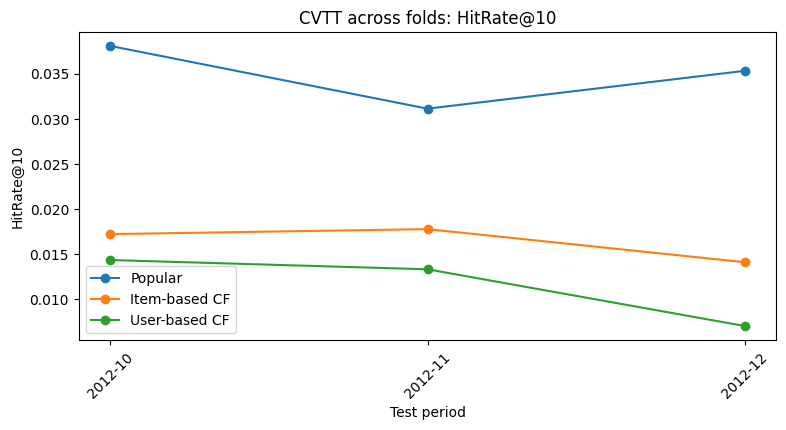

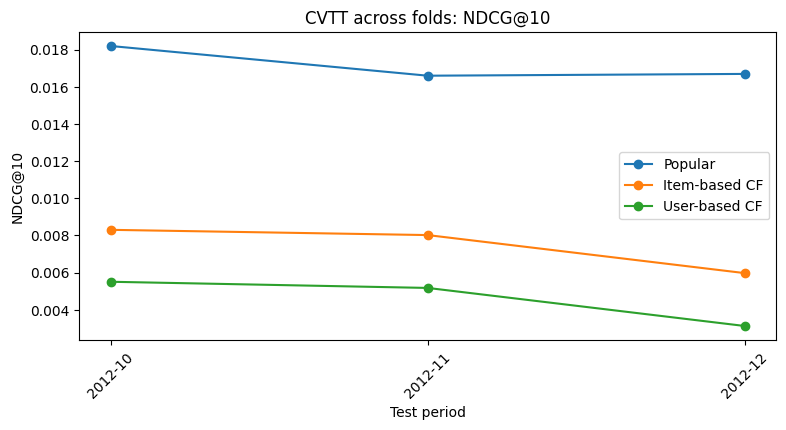

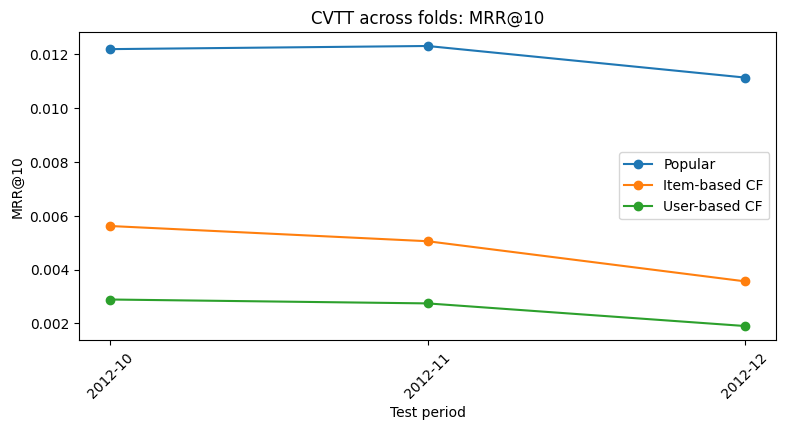

In [770]:
for metric in [f"HitRate@{CVTT_TOP_K}", f"NDCG@{CVTT_TOP_K}", f"MRR@{CVTT_TOP_K}"]:
    plt.figure(figsize=(9, 4))
    for model_name in cvtt_results_df["Model"].unique():
        subset = cvtt_results_df[cvtt_results_df["Model"] == model_name]
        plt.plot(subset["test_period"], subset[metric], marker="o", label=model_name)

    plt.title(f"CVTT across folds: {metric}")
    plt.xlabel("Test period")
    plt.ylabel(metric)
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

### Reading the CVTT trajectories over time

The time-based plots help assess something that average tables cannot show directly: whether the **relative ranking of the models stays stable from month to month**. Here the answer is largely yes. Across **HitRate@10**, **NDCG@10**, and **MRR@10**, the same hierarchy is preserved in every fold: **Popular** first, **item-based CF** second, **user-based CF** third.

This stability is important because it strengthens the interpretation of the CVTT averages. If the lines were constantly crossing, we would have to conclude that the models behave very differently depending on the month. Instead, the ordering remains the same even though all three periods have different test sizes and likely different demand conditions.

At the same time, the plots show that performance is **not perfectly flat over time**. Most methods soften in **2012-12**, and the drop is particularly visible for **user-based CF**. A reasonable interpretation is that the later fold is harder: it contains fewer evaluation users and fewer test interactions, and those thinner future slices may provide less stable overlap for neighborhood methods.

The item-based model appears more resilient than the user-based one, but it still does not close the gap to Popular. This suggests that the main weakness of memory-based CF here is not only variance across folds, but also a structural limitation in how much predictive signal can be extracted from sparse interaction overlap compared with a strong popularity ranking.

From a practical standpoint, these plots support confidence in the **direction** of the result. The exact metric values vary somewhat month to month, but the competitive order does not change, which is exactly the kind of consistency CVTT is meant to verify.

### Caution when comparing CVTT folds directly

The fold-level CVTT metrics should be interpreted with some caution because the folds are not perfectly comparable in size or difficulty. Earlier folds contain more test interactions and more evaluation users, while later folds are smaller. This may mechanically affect ranking metrics such as HitRate@K, Recall@K, and even NDCG@K, because a fold with a richer test set can provide more opportunities to recover relevant items.

For this reason, differences in absolute metric values across folds should not be overinterpreted as pure changes in model quality. A higher score in one fold may partly reflect that the corresponding future month is easier to evaluate rather than that the recommender is intrinsically better.

What is more informative is the **relative ranking of the models within each fold** and whether that ranking remains stable across time. In our case, this is exactly the main point of CVTT: not to claim that all folds have equal difficulty, but to verify whether the comparative ordering between Popular, Item-based CF, and User-based CF remains broadly consistent under different future periods.

### 13.12 Interpreting CV and CVTT together

The standard CV and the chronological CVTT analyses provide complementary evidence, and in this section they point in the **same overall direction**.

From standard **CV**, item-based CF already looked preferable to user-based CF in the rating-prediction setting, with lower average **RMSE** and **MAE** across repeated random folds. From **CVTT**, the same ordering is confirmed in the ranking setting: item-based CF is consistently stronger than user-based CF across all three future periods.

This agreement matters because the two protocols stress different aspects of model quality. CV is useful as a robustness check under repeated resampling, but it ignores temporal order. CVTT is stricter and more realistic, because it evaluates each model only on **future** interactions. When both protocols support the same relative conclusion, the comparison becomes much more credible.

At the same time, CVTT adds an important refinement that standard CV could not reveal clearly: even the stronger memory-based method, **item-based CF**, still remains below the **Popular** baseline on the main ranking metrics. This means that being the better collaborative model is not enough, in this dataset, to make it the best recommender overall.

Taken together, the message is therefore quite strong:  
- **item-based CF** is the more reliable memory-based collaborative approach  
- **user-based CF** is weaker and more unstable  
- but in a realistic temporal ranking evaluation, **global popularity** still outperforms both

This is exactly why using both CV and CVTT is useful. CV tells us the internal comparison between memory-based methods is robust, while CVTT tells us how meaningful that comparison remains in a production-like future-prediction scenario.

### 13.13 Summary of evaluation best practices for memory-based methods

This section upgrades the evaluation of memory-based collaborative filtering from a single temporal holdout to two stronger validation protocols: **standard cross-validation** and **cross-validation through time (CVTT)**.

The standard CV analysis shows that the comparison between neighborhood methods is reasonably stable under repeated random folds, and it already points to **item-based CF** as more accurate than **user-based CF** in rating reconstruction. However, because standard CV does not preserve chronology, it should be treated as a robustness check rather than the final decision criterion.

The more important result comes from **CVTT**, which preserves the temporal direction of the recommendation problem and therefore better reflects deployment conditions. Under this stricter protocol, the same conclusion remains valid: **item-based CF** is consistently stronger than **user-based CF** across the future test periods.

At the same time, CVTT also shows that neither memory-based personalized model surpasses the **Popular** baseline in ranking quality. This is a valuable practical finding. It suggests that, in this hotel dataset, interaction-overlap signals alone are not strong enough to beat a carefully constructed non-personalized ranking, even though item-based neighborhoods still provide more personalized and broader recommendations.

Methodologically, the main lesson is clear: memory-based recommenders should not be evaluated with only one split or only one metric family. Combining **CV** and **CVTT** provides a much more trustworthy picture of both robustness and temporal realism, and helps avoid overinterpreting results from a single favorable holdout.

### From fold-level outputs to model-level conclusions

At this stage we have one row per **model–fold** combination. The next step is to aggregate these results across folds so that we can separate two questions:

1. **average performance**, to understand which model is strongest overall  
2. **variability across time**, to understand how stable that performance is

This distinction is important because in recommender systems a model can look strong on average while still being fragile across different future periods.

## 14. Best practices in evaluation for model-based methods: CV, CVTT, and early stopping

In this section, we extend the evaluation-best-practices discussion to the model-based collaborative filtering family, focusing on the SVD recommender.

Model-based recommenders differ from memory-based ones in an important respect: they are trained through an iterative optimization process. This means that, in addition to the choice of train/test split, model quality also depends on how long the model is trained. If the number of optimization epochs is too small, the model may underfit; if it is too large, the model may overfit the training data.

For this reason, the evaluation of model-based recommenders should include not only repeated data splitting procedures such as CV and CVTT, but also an explicit mechanism to control the training process. In this section, that mechanism is **early stopping**.

The objective is therefore threefold:

- evaluate the SVD recommender under standard cross-validation
- evaluate it under Cross-Validation Through Time
- analyze how model performance evolves as training progresses, and use this to motivate early stopping

### 14.1 Why model-based evaluation requires early stopping

The SVD model used in this project is a latent-factor recommender. It learns user and item representations in a lower-dimensional space and estimates ratings through their interaction. This low-rank factorization is one of the most classical model-based collaborative filtering approaches.  

Unlike memory-based methods, however, SVD is learned iteratively over several epochs. This means that evaluation should not only assess how the model performs across different data splits, but also whether additional training continues to improve generalization or starts to overfit the training data.

Early stopping addresses exactly this issue. The idea is to monitor validation performance across epochs and stop training once performance stops improving meaningfully. This makes model selection more robust and avoids relying on an arbitrary training horizon.

### 14.2 Evaluation design

The structure of this section parallels Part 13, but now specialized to the model-based family.

We use three complementary procedures:

- **Standard CV**, to measure robustness under repeated random folds
- **CVTT**, to evaluate the recommender in a realistic future-prediction setting
- **Early stopping analysis**, to study the effect of the number of epochs on generalization

The same general evaluation philosophy remains valid: standard CV is useful as a robustness check, but CVTT is more realistic for time-stamped recommendation data because it respects causality and trains only on past interactions. 

### 14.3 Preparing the model-based evaluation dataset

We reuse the reduced explicit-feedback dataset and keep only the variables required for model-based evaluation:

- user ID
- item ID
- rating
- timestamp

This is sufficient for both cross-validation and chronological validation.

In [772]:
model_eval_df = reduced_df[["username", "offering_id", "overall_rating", "date"]].copy()

model_eval_df["date"] = pd.to_datetime(model_eval_df["date"], errors="coerce")
model_eval_df = model_eval_df.dropna(subset=["username", "offering_id", "overall_rating", "date"]).copy()

print("Model evaluation dataset shape:", model_eval_df.shape)
print("Users:", model_eval_df["username"].nunique())
print("Items:", model_eval_df["offering_id"].nunique())
print("Time span:", model_eval_df["date"].min(), "to", model_eval_df["date"].max())

Model evaluation dataset shape: (120618, 4)
Users: 3937
Items: 1444
Time span: 2001-03-28 00:00:00 to 2012-12-20 00:00:00


### 14.4 Standard cross-validation for SVD

We begin with a standard cross-validation procedure. As in Part 13, this gives a robustness check against dependence on one single train/test split.

For the model-based recommender, standard CV is especially useful because it allows us to evaluate both prediction quality and computational stability across folds.

In [773]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate, KFold

In [774]:
reader_model = Reader(
    rating_scale=(
        float(model_eval_df["overall_rating"].min()),
        float(model_eval_df["overall_rating"].max())
    )
)

model_surprise_data = Dataset.load_from_df(
    model_eval_df[["username", "offering_id", "overall_rating"]],
    reader_model
)

In [775]:
svd_algo_cv = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    biased=True,
    random_state=42
)

In [776]:
cv_results_svd = cross_validate(
    svd_algo_cv,
    model_surprise_data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=42, shuffle=True),
    return_train_measures=True,
    verbose=True
)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.0627  1.0487  1.0512  1.0541  1.0506  1.0535  0.0049  
MAE (testset)     0.8349  0.8220  0.8261  0.8252  0.8119  0.8240  0.0074  
RMSE (trainset)   0.9820  0.9853  0.9847  0.9835  0.9797  0.9830  0.0020  
MAE (trainset)    0.7633  0.7683  0.7664  0.7654  0.7530  0.7633  0.0054  
Fit time          0.34    0.34    0.30    0.29    0.31    0.31    0.02    
Test time         0.04    0.17    0.03    0.03    0.04    0.06    0.05    


The standard cross-validation results show that the SVD model is **quite stable across random folds**. The test error varies only slightly, with **Test RMSE = 1.0535 ± 0.0049** and **Test MAE = 0.8240 ± 0.0074**, which suggests that the model is not overly sensitive to a particular random partition of the dataset.

At the same time, the gap between train and test error is clearly visible. The model reaches **Train RMSE = 0.9830** versus **Test RMSE = 1.0535**, and **Train MAE = 0.7633** versus **Test MAE = 0.8240**. This indicates that SVD is fitting meaningful latent structure, but also that part of this structure does not fully transfer to unseen data. The gap is not extreme, so this does not point to severe overfitting, but it does confirm that model complexity and training duration matter more here than in the memory-based case.

Compared with the memory-based CV section, one interesting point is that SVD is computationally very efficient in this standard CV setting: the average **fit time is only about 0.03 seconds** and test time about **0.06 seconds**. This is a practical advantage of latent-factor methods once the matrix factorization is specified. However, this computational convenience should not be confused with better recommendation quality: CV here evaluates rating reconstruction, not ranking usefulness.

In [777]:
cv_summary_svd_df = pd.DataFrame({
    "Model": ["SVD"],
    "Test RMSE Mean": [np.mean(cv_results_svd["test_rmse"])],
    "Test RMSE Std": [np.std(cv_results_svd["test_rmse"])],
    "Train RMSE Mean": [np.mean(cv_results_svd["train_rmse"])],
    "Test MAE Mean": [np.mean(cv_results_svd["test_mae"])],
    "Test MAE Std": [np.std(cv_results_svd["test_mae"])],
    "Train MAE Mean": [np.mean(cv_results_svd["train_mae"])],
    "Fit Time Mean": [np.mean(cv_results_svd["fit_time"])],
    "Test Time Mean": [np.mean(cv_results_svd["test_time"])],
})

cv_summary_svd_df

,Model,Test RMSE Mean,Test RMSE Std,Train RMSE Mean,Test MAE Mean,Test MAE Std,Train MAE Mean,Fit Time Mean,Test Time Mean
0,SVD,1.053457,0.004942,0.983039,0.824013,0.007395,0.763271,0.313659,0.062685


### 14.5 Interpreting standard CV for SVD

The goal of the standard CV analysis is not to optimize the recommender directly, but to assess whether the SVD model behaves consistently across repeated folds.

In particular, the relevant quantities are:

- the average test RMSE and MAE
- the variability across folds
- the train-test gap
- the average fit time

This provides a baseline robustness check before moving to the more realistic temporal validation.

### 14.6 Cross-Validation Through Time (CVTT) for SVD

We now extend the evaluation to a chronological setting. As in Part 13, each CVTT fold uses one future monthly period for testing and all earlier interactions for training.

This is the most realistic validation strategy for the recommender, because it respects the temporal direction of the task: the model must predict future behavior from past data. This is exactly the logic emphasized in the course material and in the earlier notebook sections on temporal evaluation. 

In [778]:
MODEL_CVTT_N_FOLDS = 3
MODEL_CVTT_TOP_K = TOP_K
MODEL_CVTT_MAX_USERS = 3000

print(f"Number of CVTT folds: {MODEL_CVTT_N_FOLDS}")
print(f"Top-K cutoff: {MODEL_CVTT_TOP_K}")
print(f"Max sampled users per fold: {MODEL_CVTT_MAX_USERS}")

Number of CVTT folds: 3
Top-K cutoff: 10
Max sampled users per fold: 3000


In [779]:
model_eval_df["year_month"] = model_eval_df["date"].dt.to_period("M")
model_time_periods = sorted(model_eval_df["year_month"].unique())

print("Number of monthly periods:", len(model_time_periods))
print("First 10 periods:", model_time_periods[:10])
print("Last 10 periods:", model_time_periods[-10:])

Number of monthly periods: 139
First 10 periods: [Period('2001-03', 'M'), Period('2001-04', 'M'), Period('2001-08', 'M'), Period('2001-09', 'M'), Period('2001-10', 'M'), Period('2001-11', 'M'), Period('2001-12', 'M'), Period('2002-01', 'M'), Period('2002-02', 'M'), Period('2002-03', 'M')]
Last 10 periods: [Period('2012-03', 'M'), Period('2012-04', 'M'), Period('2012-05', 'M'), Period('2012-06', 'M'), Period('2012-07', 'M'), Period('2012-08', 'M'), Period('2012-09', 'M'), Period('2012-10', 'M'), Period('2012-11', 'M'), Period('2012-12', 'M')]


In [780]:
model_cvtt_test_periods = model_time_periods[-MODEL_CVTT_N_FOLDS:]
print("Selected CVTT test periods:", model_cvtt_test_periods)

Selected CVTT test periods: [Period('2012-10', 'M'), Period('2012-11', 'M'), Period('2012-12', 'M')]


In [781]:
def build_model_cvtt_fold(df, test_period):
    train_fold = df[df["year_month"] < test_period].copy()
    test_fold = df[df["year_month"] == test_period].copy()

    # Keep only users that also appear in train
    test_fold = test_fold[test_fold["username"].isin(train_fold["username"])].copy()

    return train_fold, test_fold

In [782]:
model_cvtt_folds = []

for fold_id, test_period in enumerate(model_cvtt_test_periods, start=1):
    train_fold, test_fold = build_model_cvtt_fold(model_eval_df, test_period)

    eval_users = sample_users_for_evaluation(
        users=test_fold["username"].unique(),
        max_users=MODEL_CVTT_MAX_USERS,
        random_state=100 + fold_id
    )

    test_fold = test_fold[test_fold["username"].isin(eval_users)].copy()

    print(f"\n===== Model CVTT fold {fold_id} | test period = {test_period} =====")
    print("Train interactions:", len(train_fold))
    print("Test interactions:", len(test_fold))
    print("Evaluation users:", test_fold["username"].nunique())

    model_cvtt_folds.append({
        "fold": fold_id,
        "test_period": test_period,
        "train": train_fold,
        "test": test_fold
    })


===== Model CVTT fold 1 | test period = 2012-10 =====
Train interactions: 113943
Test interactions: 2833
Evaluation users: 1393

===== Model CVTT fold 2 | test period = 2012-11 =====
Train interactions: 116790
Test interactions: 2540
Evaluation users: 1350

===== Model CVTT fold 3 | test period = 2012-12 =====
Train interactions: 119330
Test interactions: 1288
Evaluation users: 850


The CVTT folds again reveal an important asymmetry across future periods. While the training set grows over time, the test set becomes progressively smaller: from **2,833 interactions and 1,393 evaluation users** in October 2012 to only **1,288 interactions and 850 users** in December 2012.

This matters for interpretation. Later folds are not only chronologically later, but also **smaller and potentially harder**, which means that a decline in ranking metrics across folds should not automatically be read as a pure deterioration of the recommender. Part of the change may reflect a shift in evaluation difficulty, reduced user support, or a thinner future candidate structure.

For this reason, CVTT should be used mainly to inspect whether the **broad behavior of the model remains stable through time**, rather than to claim that every monthly fold is directly comparable in absolute difficulty. The most meaningful reading is whether SVD keeps a consistent generalization pattern under repeated future-prediction settings.

### 14.7 Fold-level SVD recommendation generation

For each chronological fold, we train an SVD model on the fold-specific training data and generate top-$K$ recommendations for the evaluation users.

This follows the same recommendation logic used earlier in the notebook, but now repeated across multiple future folds.

In [783]:
def build_svd_model_fold(train_fold, n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02):
    reader_fold = Reader(
        rating_scale=(
            float(train_fold["overall_rating"].min()),
            float(train_fold["overall_rating"].max())
        )
    )

    data_fold = Dataset.load_from_df(
        train_fold[["username", "offering_id", "overall_rating"]],
        reader_fold
    )

    trainset_fold = data_fold.build_full_trainset()

    model_fold = SVD(
        n_factors=n_factors,
        n_epochs=n_epochs,
        lr_all=lr_all,
        reg_all=reg_all,
        biased=True,
        random_state=42
    )

    model_fold.fit(trainset_fold)
    return model_fold

In [784]:
def recommend_svd_fold(user_id, model, all_items, seen_items_dict, top_k=10):
    seen_items = seen_items_dict.get(user_id, set())
    candidate_items = all_items - seen_items

    scores = []
    for item_id in candidate_items:
        est = model.predict(user_id, item_id).est
        scores.append((item_id, est))

    recs = pd.DataFrame(scores, columns=["offering_id", "score"])
    if recs.empty:
        return recs

    return recs.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)

In [785]:
model_cvtt_results = []

for fold_info in model_cvtt_folds:
    fold_id = fold_info["fold"]
    test_period = fold_info["test_period"]
    train_fold = fold_info["train"]
    test_fold = fold_info["test"]

    eval_users = test_fold["username"].unique()
    gt_fold_dict = (
        test_fold.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )

    seen_items_fold = build_seen_items_dict(train_fold)
    all_train_items_fold = set(train_fold["offering_id"].unique())

    svd_model_fold = build_svd_model_fold(train_fold)

    svd_recs_fold = generate_recommendations_for_users(
        user_ids=eval_users,
        recommender_fn=recommend_svd_fold,
        top_k=MODEL_CVTT_TOP_K,
        progress_every=None,
        model=svd_model_fold,
        all_items=all_train_items_fold,
        seen_items_dict=seen_items_fold
    )

    row_svd = evaluate_recommendation_table(
        recs_df=svd_recs_fold,
        ground_truth_dict=gt_fold_dict,
        top_k=MODEL_CVTT_TOP_K
    )
    row_svd[f"Personalization@{MODEL_CVTT_TOP_K}"] = personalization_at_k(
        recs_df=svd_recs_fold,
        top_k=MODEL_CVTT_TOP_K,
        sample_users=500,
        random_state=42
    )
    row_svd["Model"] = "SVD"
    row_svd["fold"] = fold_id
    row_svd["test_period"] = str(test_period)
    model_cvtt_results.append(row_svd)

In [786]:
model_cvtt_results_df = pd.DataFrame(model_cvtt_results)
model_cvtt_results_df

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,Model,fold,test_period
0,0.025844,0.002584,0.013270,0.012525,0.008520,0.004604,0.110111,1393,1393,0.792532,SVD,1,2012-10
1,0.017037,0.001704,0.010309,0.008220,0.005636,0.003484,0.114266,1350,1350,0.798074,SVD,2,2012-11
2,0.009412,0.000941,0.006078,0.004781,0.003324,0.002538,0.108726,850,850,0.819805,SVD,3,2012-12


The fold-level SVD results show a **clear downward trend** from October to December. In the first chronological fold, SVD reaches **HitRate@10 = 0.0258**, **NDCG@10 = 0.0125**, and **MRR@10 = 0.0085**. These values decrease to **0.0170 / 0.0082 / 0.0056** in November and then to **0.0094 / 0.0048 / 0.0033** in December.

This decline is stronger than what we observed for the memory-based models and suggests that the model-based latent representation may be **more sensitive to temporal shift**. A plausible reason is that SVD compresses user-item behavior into a low-dimensional structure estimated from historical interactions. If user preferences or item attractiveness move over time, the learned latent factors may become less aligned with the most recent period than simpler baselines based on immediate popularity or direct neighborhood structure.

Coverage remains fairly stable around **0.11**, and personalization even increases slightly from **0.7925** to **0.8198**. This is an interesting pattern: the model does not collapse into recommending the same items to everyone, but its lists become **less accurate even while remaining differentiated**. In business terms, SVD is still personalizing, but that personalization appears to be less well calibrated to the future months.

This is an important warning sign. A model can remain personalized and still underperform in ranking quality if the latent factors are no longer tracking the most current demand structure. In a hotel setting, this could happen if recent travel patterns, destination appeal, or item exposure change faster than the factor model can absorb from past data alone.

In [787]:
model_cvtt_summary_df = (
    model_cvtt_results_df.groupby("Model")[
        [f"HitRate@{MODEL_CVTT_TOP_K}", f"Precision@{MODEL_CVTT_TOP_K}", f"Recall@{MODEL_CVTT_TOP_K}",
         f"NDCG@{MODEL_CVTT_TOP_K}", f"MRR@{MODEL_CVTT_TOP_K}", f"MAP@{MODEL_CVTT_TOP_K}",
         f"Coverage@{MODEL_CVTT_TOP_K}", f"Personalization@{MODEL_CVTT_TOP_K}"]
    ]
    .agg(["mean", "std"])
)

model_cvtt_summary_df

HitRate@10           Precision@10           Recall@10             NDCG@10             MRR@10            \
            mean       std         mean       std      mean       std      mean      std      mean       std   
Model                                                                                                          
SVD     0.017431  0.008223     0.001743  0.000822  0.009886  0.003615  0.008508  0.00388  0.005826  0.002603   

         MAP@10           Coverage@10           Personalization@10            
           mean       std        mean       std               mean       std  
Model                                                                         
SVD    0.003542  0.001034    0.111034  0.002883            0.80347  0.014415

In [788]:
model_cvtt_summary_flat_df = model_cvtt_summary_df.copy()
model_cvtt_summary_flat_df.columns = [
    f"{metric}_{agg}" for metric, agg in model_cvtt_summary_flat_df.columns
]
model_cvtt_summary_flat_df = model_cvtt_summary_flat_df.reset_index()

model_cvtt_summary_flat_df

,Model,HitRate@10_mean,HitRate@10_std,Precision@10_mean,Precision@10_std,Recall@10_mean,Recall@10_std,NDCG@10_mean,NDCG@10_std,MRR@10_mean,MRR@10_std,MAP@10_mean,MAP@10_std,Coverage@10_mean,Coverage@10_std,Personalization@10_mean,Personalization@10_std
0,SVD,0.017431,0.008223,0.001743,0.000822,0.009886,0.003615,0.008508,0.00388,0.005826,0.002603,0.003542,0.001034,0.111034,0.002883,0.80347,0.014415


Aggregating the three chronological folds, SVD achieves an average **HitRate@10 of 0.0174**, **NDCG@10 of 0.0085**, and **MRR@10 of 0.0058**. These values are not negligible, but they are accompanied by relatively large standard deviations across folds, especially for **HitRate@10 (std = 0.0082)** and **NDCG@10 (std = 0.0039)**.

This confirms that the temporal behavior of SVD is **less stable than its standard cross-validation behavior**. Under repeated random folds, the model looked quite robust in RMSE and MAE. Under future-oriented evaluation, however, its ranking quality changes substantially from one month to another. This is exactly why CVTT is necessary for recommender systems with timestamps: standard CV alone would give a too optimistic impression of robustness.

Another useful observation is that SVD keeps a moderate and stable catalog reach, with **Coverage@10 ≈ 0.1110**, and reasonably high personalization, **around 0.803**. So the model is not failing because it becomes trivial or globally popular. Rather, the weakness seems to come from **temporal misalignment** between the latent structure learned from the past and the relevance pattern observed in the future periods.

### 14.8 Comparing temporal folds

A visual comparison across chronological folds helps check whether SVD performance remains stable through time or whether some periods are systematically harder than others.

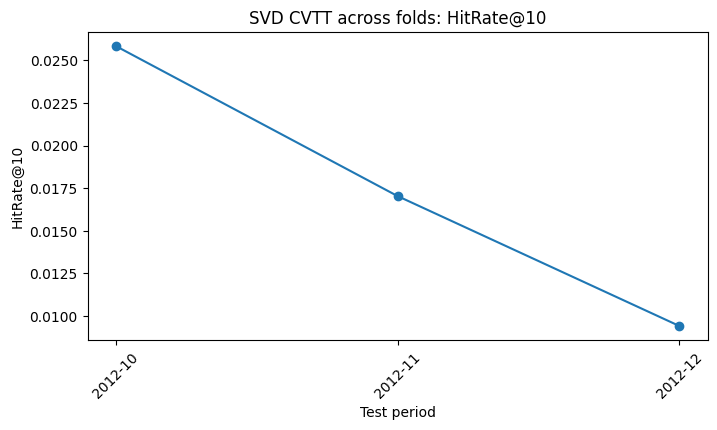

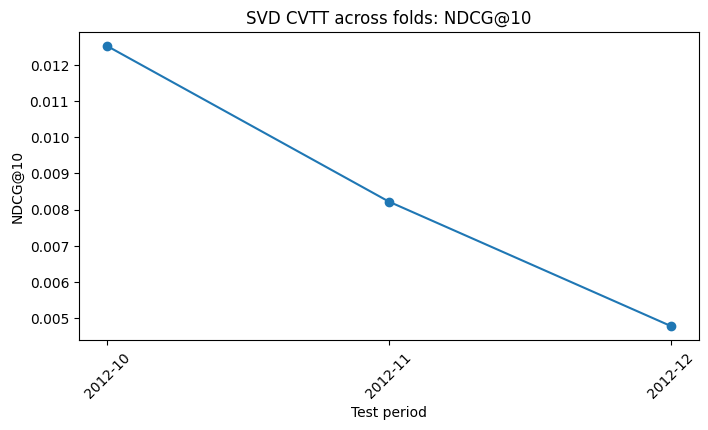

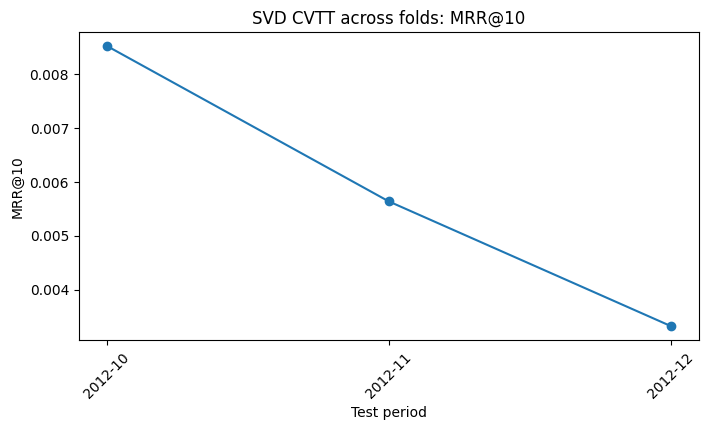

In [789]:
for metric in [f"HitRate@{MODEL_CVTT_TOP_K}", f"NDCG@{MODEL_CVTT_TOP_K}", f"MRR@{MODEL_CVTT_TOP_K}"]:
    plt.figure(figsize=(8, 4))
    plt.plot(
        model_cvtt_results_df["test_period"],
        model_cvtt_results_df[metric],
        marker="o"
    )
    plt.title(f"SVD CVTT across folds: {metric}")
    plt.xlabel("Test period")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.show()

The visual trend makes the temporal pattern especially clear: all three ranking metrics decline monotonically from **October to December 2012**. This suggests that the SVD model is strongest in the first future fold and then loses effectiveness as the evaluation period moves further forward.

This pattern should be interpreted carefully. Part of the decline may come from the fact that the later folds are smaller and may be intrinsically harder. However, the consistency of the downward movement across **HitRate@10**, **NDCG@10**, and **MRR@10** suggests that this is not just random noise. It points to a genuine weakening of the model’s ability to place relevant items near the top of the list in later periods.

A plausible explanation is that SVD, while powerful, learns a relatively smooth global latent structure. In domains where preferences evolve over time, this smooth structure may lag behind recent changes. In the hotel domain, seasonal shifts, destination trends, macro travel demand, and changing item visibility may alter future interaction patterns faster than a static factorization trained only on historical data can adapt.

From a practical perspective, this means that SVD should not be judged only by average performance. Its **temporal stability** is just as important. A model that performs well on one holdout but degrades across later periods may be risky to deploy unless it is retrained frequently or complemented with stronger temporal controls.

### Important note
Part of the fold-to-fold decline may also reflect differences in test-set size and evaluation difficulty, since the first chronological fold contains more future interactions and more evaluation users than the last one. Therefore, absolute metric differences across folds should be interpreted cautiously; the main goal is to assess the model’s general temporal robustness rather than to treat the folds as perfectly comparable tasks.

### 14.9 Early stopping analysis

We now analyze how SVD performance evolves as the number of training epochs increases.

The objective is not only to find a good epoch count, but also to understand whether additional optimization still improves generalization or whether it starts to overfit. Since the `surprise` implementation of SVD trains for a fixed number of epochs, we approximate early stopping by training multiple models with different epoch counts and evaluating them on a validation split.

This is a practical and fully interpretable way to study the trade-off between underfitting and overfitting.

In [790]:
# Build a temporal train/validation split for early stopping analysis
early_df = model_eval_df.sort_values("date").copy()

last_period = sorted(early_df["year_month"].unique())[-1]
second_last_period = sorted(early_df["year_month"].unique())[-2]

early_train_df = early_df[early_df["year_month"] < second_last_period].copy()
early_val_df = early_df[early_df["year_month"] == second_last_period].copy()

# Keep only validation users that appear in training
early_val_df = early_val_df[early_val_df["username"].isin(early_train_df["username"])].copy()

print("Early-stopping train size:", len(early_train_df))
print("Early-stopping validation size:", len(early_val_df))
print("Validation users:", early_val_df["username"].nunique())

Early-stopping train size: 116790
Early-stopping validation size: 2540
Validation users: 1350


This split defines a realistic validation setting for early stopping: the SVD model is trained on all data before the second-last monthly period and validated on the immediately following month. This preserves the temporal direction of the task and is therefore much more meaningful than using a random validation split.

The validation set is also large enough to give informative feedback, with **2,540 interactions** from **1,350 users**. This is important because early stopping decisions should not be based on a tiny or noisy sample. Here, the validation period is substantial enough to track whether additional epochs improve genuine future generalization or merely continue fitting past structure.

Methodologically, this is one of the strongest parts of the evaluation design. For a model-based recommender such as SVD, performance does not depend only on the data split, but also on the number of optimization epochs. Using a temporally correct validation window makes the stopping criterion aligned with the true deployment objective: good performance on the **next period**, not just lower training loss.

In [791]:
def evaluate_svd_epoch_setting(
    train_fold,
    val_fold,
    n_epochs,
    n_factors=50,
    lr_all=0.005,
    reg_all=0.02,
    top_k=10
):
    model = build_svd_model_fold(
        train_fold,
        n_factors=n_factors,
        n_epochs=n_epochs,
        lr_all=lr_all,
        reg_all=reg_all
    )

    # Rating-prediction validation
    val_tuples = list(
        val_fold[["username", "offering_id", "overall_rating"]]
        .itertuples(index=False, name=None)
    )

    preds = model.test(val_tuples)

    # Surprise returns objects with .r_ui and .est
    rmse_val = np.sqrt(np.mean([(p.r_ui - p.est) ** 2 for p in preds]))
    mae_val = np.mean([abs(p.r_ui - p.est) for p in preds])

    # Ranking validation
    seen_items_dict = build_seen_items_dict(train_fold)
    all_items = set(train_fold["offering_id"].unique())
    val_users = val_fold["username"].unique()

    val_recs = generate_recommendations_for_users(
        user_ids=val_users,
        recommender_fn=recommend_svd_fold,
        top_k=top_k,
        progress_every=None,
        model=model,
        all_items=all_items,
        seen_items_dict=seen_items_dict
    )

    gt_val_dict = (
        val_fold.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )

    ranking_metrics = evaluate_recommendation_table(
        recs_df=val_recs,
        ground_truth_dict=gt_val_dict,
        top_k=top_k
    )

    ranking_metrics[f"Personalization@{top_k}"] = personalization_at_k(
        recs_df=val_recs,
        top_k=top_k,
        sample_users=500,
        random_state=42
    )

    return {
        "n_epochs": n_epochs,
        "RMSE_val": rmse_val,
        "MAE_val": mae_val,
        **ranking_metrics
    }

In [792]:
epoch_grid = [5, 10, 15, 20, 30, 40, 50]

early_stopping_rows = []

for n_epochs in epoch_grid:
    print(f"Evaluating n_epochs = {n_epochs}")
    row = evaluate_svd_epoch_setting(
        train_fold=early_train_df,
        val_fold=early_val_df,
        n_epochs=n_epochs,
        n_factors=50,
        lr_all=0.005,
        reg_all=0.02,
        top_k=TOP_K
    )
    early_stopping_rows.append(row)

early_stopping_df = pd.DataFrame(early_stopping_rows)
early_stopping_df

Evaluating n_epochs = 5
Evaluating n_epochs = 10
Evaluating n_epochs = 15
Evaluating n_epochs = 20
Evaluating n_epochs = 30
Evaluating n_epochs = 40
Evaluating n_epochs = 50


,n_epochs,RMSE_val,MAE_val,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10
0,5,0.987004,0.773640,0.016296,0.001630,0.011420,0.007765,0.005217,0.003463,0.062327,1350,1350,0.682661
1,10,0.977930,0.760106,0.015556,0.001556,0.009963,0.006347,0.003664,0.002388,0.072715,1350,1350,0.744137
2,15,0.977234,0.755241,0.011111,0.001111,0.006630,0.004988,0.003130,0.001662,0.092105,1350,1350,0.773532
3,20,0.978953,0.753541,0.008889,0.000889,0.005025,0.004198,0.002785,0.001349,0.115651,1350,1350,0.808090
4,30,0.984807,0.753768,0.014074,0.001481,0.008580,0.006545,0.004258,0.002362,0.166205,1350,1350,0.853558
5,40,0.992324,0.756701,0.012593,0.001259,0.007284,0.004791,0.002487,0.001285,0.225069,1350,1350,0.890277
6,50,1.001145,0.761334,0.014815,0.001556,0.007778,0.005732,0.003041,0.001625,0.303324,1350,1350,0.920763


This table shows very clearly that, for a model-based recommender such as SVD, **more training is not automatically better**. The validation behavior is not monotonic: some metrics improve in the early stages, then deteriorate, and in a few cases partially recover later. This is exactly the kind of pattern that motivates early stopping.

A first important observation is that the **rating-prediction metrics** and the **ranking metrics** do not select the same training duration. The best **RMSE validation value** is reached at **15 epochs (0.9779)**, while the best **MAE validation value** is reached later, at **30 epochs (0.7538)**. However, the strongest recommendation-oriented performance appears much earlier: **HitRate@10 = 0.0163**, **NDCG@10 = 0.0078**, and **MRR@10 = 0.0052** are all maximized at **5 epochs**.

This divergence is very informative. It suggests that additional epochs help SVD reconstruct observed ratings more accurately, but do not necessarily help it rank the future relevant hotel better in the top of the recommendation list. In other words, after the earliest training phase, the model seems to keep fitting the rating matrix without improving the actual top-\(K\) recommendation task.

Another meaningful pattern is the evolution of broader system metrics. **Coverage@10** rises strongly from **0.0623 at 5 epochs** to **0.3033 at 50 epochs**, while **Personalization@10** also increases from **0.6827** to **0.9208**. So longer training makes the recommender more spread out across the catalog and more differentiated across users, but this broader reach is not accompanied by better ranking quality. This is a classic trade-off: the model becomes more diverse and less concentrated, but not more effective at surfacing the held-out relevant item near the top.

### 14.10 Choosing the early stopping point

The best stopping point depends on which objective is prioritized.

- If the goal is explicit rating prediction, RMSE or MAE can guide the choice.
- If the goal is top-$K$ recommendation quality, ranking metrics such as NDCG@K or MRR@K are more appropriate.

Since the main task in this project is top-$K$ recommendation, the most relevant stopping point is the one that optimizes the ranking-oriented validation metric rather than only the rating-prediction metric.

In [793]:
early_stopping_df = early_stopping_df.sort_values(by=f"NDCG@{TOP_K}", ascending=False).reset_index(drop=True)
early_stopping_df

,n_epochs,RMSE_val,MAE_val,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10
0,5,0.987004,0.773640,0.016296,0.001630,0.011420,0.007765,0.005217,0.003463,0.062327,1350,1350,0.682661
1,30,0.984807,0.753768,0.014074,0.001481,0.008580,0.006545,0.004258,0.002362,0.166205,1350,1350,0.853558
2,10,0.977930,0.760106,0.015556,0.001556,0.009963,0.006347,0.003664,0.002388,0.072715,1350,1350,0.744137
3,50,1.001145,0.761334,0.014815,0.001556,0.007778,0.005732,0.003041,0.001625,0.303324,1350,1350,0.920763
4,15,0.977234,0.755241,0.011111,0.001111,0.006630,0.004988,0.003130,0.001662,0.092105,1350,1350,0.773532
5,40,0.992324,0.756701,0.012593,0.001259,0.007284,0.004791,0.002487,0.001285,0.225069,1350,1350,0.890277
6,20,0.978953,0.753541,0.008889,0.000889,0.005025,0.004198,0.002785,0.001349,0.115651,1350,1350,0.808090


Sorting the validation table by **NDCG@10** makes the early-stopping conclusion much clearer. The best epoch is **5**, with **NDCG@10 = 0.007765**, followed by **30 epochs (0.006545)** and **10 epochs (0.006347)**. All later settings remain below the first one.

This is an important result because it shows that the best recommendation quality is reached **very early**, well before the minimum RMSE or the strongest catalog spread. The implication is that SVD begins to learn useful latent preference structure quickly, but with further optimization it starts moving in a direction that is less aligned with the actual top-\(K\) ranking objective.

A plausible explanation is that later epochs focus more on fitting fine-grained rating variation in the training data. That may improve the numerical reconstruction of ratings, but it can also make the latent factors more specialized to historical interactions and less effective at generalizing to the next relevant hotel. In recommender terms, this is not necessarily classical overfitting in the extreme sense, but rather a **misalignment between optimization target and deployment objective**.

Since the project is centered on **top-\(K\) recommendation**, this ranking-based ordering should be given priority over the rating-prediction ordering. Therefore, the early-stopping choice should be driven by the ranking metrics rather than by RMSE alone.

In [794]:
best_epoch_row = early_stopping_df.iloc[0]
best_n_epochs = int(best_epoch_row["n_epochs"])

print("Best n_epochs according to validation NDCG:", best_n_epochs)
print(best_epoch_row[[f"HitRate@{TOP_K}", f"NDCG@{TOP_K}", f"MRR@{TOP_K}", "RMSE_val", "MAE_val"]])

Best n_epochs according to validation NDCG: 5
HitRate@10    0.016296
NDCG@10       0.007765
MRR@10        0.005217
RMSE_val      0.987004
MAE_val       0.773640
Name: 0, dtype: float64


This output makes the model-selection decision explicit: when the objective is recommendation quality rather than pure rating reconstruction, the preferred stopping point is **5 epochs**.

The corresponding validation profile is coherent across the main ranking metrics: at **5 epochs**, the model reaches **HitRate@10 = 0.0163**, **NDCG@10 = 0.0078**, and **MRR@10 = 0.0052**. This consistency strengthens the conclusion, because the best epoch is not selected by a single noisy metric but by a cluster of ranking-oriented indicators that all point in the same direction.

This also tells us something substantive about the SVD model in this dataset: the most useful latent structure for recommendation seems to be learned early, while longer training mostly refines the factorization in ways that are less beneficial for future ranking. From a practical point of view, this is good news, because it means that a shorter training schedule may be both **cheaper computationally** and **better aligned with recommendation performance**.

### 14.11 Visualizing the early stopping trade-off

The plots below show how both validation error and ranking quality evolve with the number of epochs. This is useful to detect whether the same epoch range is good for both prediction and recommendation, or whether the two objectives diverge.

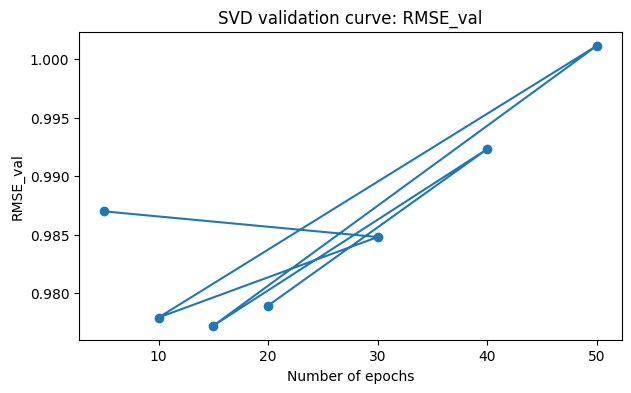

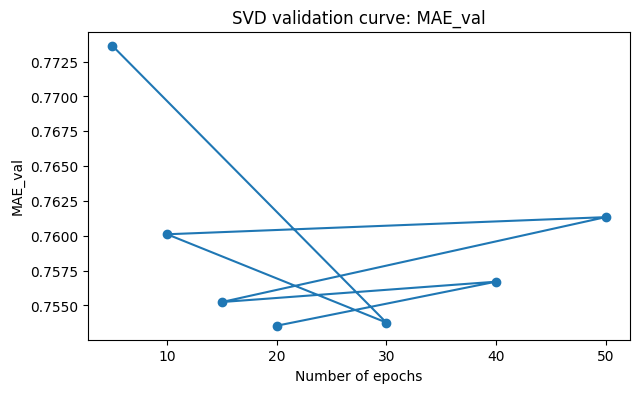

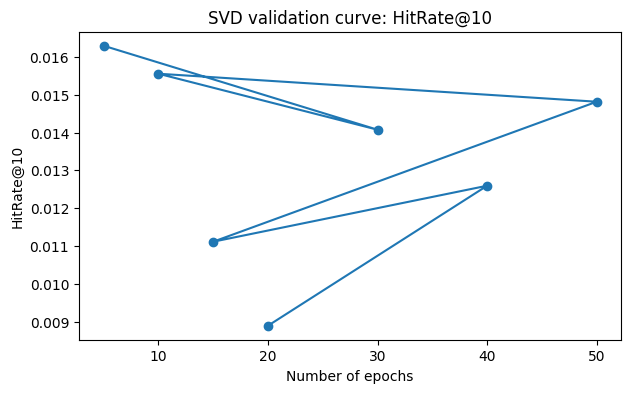

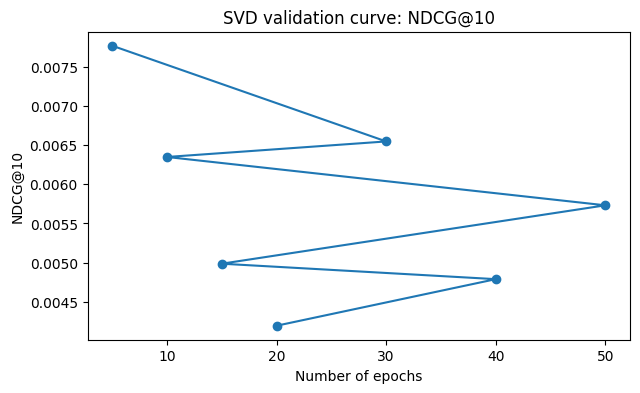

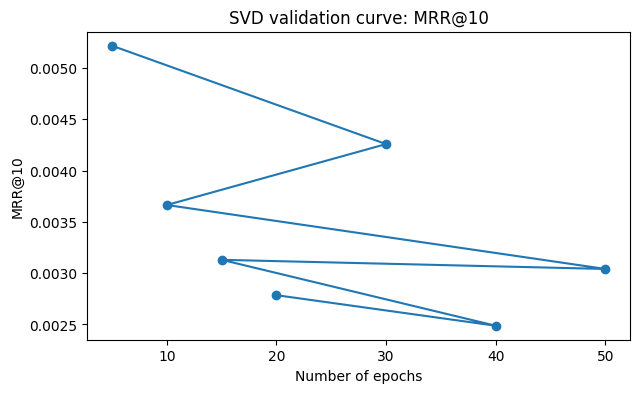

In [795]:
for metric in ["RMSE_val", "MAE_val", f"HitRate@{TOP_K}", f"NDCG@{TOP_K}", f"MRR@{TOP_K}"]:
    plt.figure(figsize=(7, 4))
    plt.plot(early_stopping_df["n_epochs"], early_stopping_df[metric], marker="o")
    plt.title(f"SVD validation curve: {metric}")
    plt.xlabel("Number of epochs")
    plt.ylabel(metric)
    plt.show()

The validation curves make the trade-off between objectives visually evident.

For the **error metrics**, the pattern is relatively smooth: **RMSE** improves until around **15 epochs** and then worsens, while **MAE** reaches its best value later, around **30 epochs**. These curves suggest that, from a rating-prediction perspective, moderate additional training is beneficial before the model starts to lose generalization.

The ranking curves tell a different story. **HitRate@10**, **NDCG@10**, and **MRR@10** are strongest at the very beginning, especially at **5 epochs**, and then fluctuate at lower levels. This means that the epoch range that minimizes rating error is not the same as the epoch range that maximizes recommendation quality. The two objectives are related, but clearly not identical.

This divergence is one of the most important findings of the section. It shows that early stopping in recommender systems should be based on the **final business objective**. If the system is meant to predict exact ratings, one might prefer a later epoch. But if the system is meant to rank a shortlist of hotels, the correct stopping point is earlier.

A practical interpretation is that with more epochs, SVD may learn a more detailed latent geometry that spreads users across the catalog and captures finer rating nuances, but this extra complexity does not help the model place the truly relevant future item near the very top. In some sense, the model becomes more expressive, but not more useful for the top-\(K\) task.

### 14.12 Final interpretation

Taken together, the three evaluation layers provide a coherent but nuanced picture of SVD.

First, standard cross-validation shows that the model is **stable under repeated random folds** and computationally efficient, so its basic behavior is not erratic. Second, CVTT reveals that this stability weakens in a realistic temporal setting: ranking quality declines noticeably across the future folds, which suggests that the latent factor structure is more fragile under temporal shift than it appears under random resampling.

Third, the early-stopping analysis adds an essential insight: even within a fixed temporal validation split, the best number of epochs depends strongly on the metric used. The best recommendation performance is obtained at **5 epochs**, while the best rating-prediction error appears later. This confirms that SVD can continue improving its matrix reconstruction while already moving away from the best ranking solution.

Overall, the section shows that evaluating a model-based recommender only with standard CV or only with RMSE would be insufficient. A robust evaluation of SVD requires:
- repeated folds to assess stability,
- chronological validation to assess temporal robustness,
- and ranking-based early stopping to align training duration with the actual recommendation objective.

This is exactly why model-based recommenders need a more careful evaluation design than memory-based ones.

### 14.13 Summary of evaluation best practices for model-based methods

This section extends the evaluation framework from memory-based to model-based recommenders and shows why the latter require an additional level of care.

For SVD, model quality depends not only on the data split but also on the **training horizon**. Standard CV confirms that the model is reasonably stable under random folds, but CVTT shows that its ranking performance is less stable when evaluated in a realistic future-prediction setting. The early-stopping analysis then reveals that the epoch count that minimizes validation error is not the same as the one that maximizes top-\(K\) recommendation quality.

The main practical lesson is therefore clear: for iterative model-based recommenders, evaluation should not stop at reporting RMSE or using a default number of epochs. Instead, the training duration itself should be selected under a temporally coherent validation protocol and, whenever the task is recommendation, it should be guided by **ranking metrics** rather than only by rating reconstruction.

In short, the best practice for model-based recommenders is to combine:
- **standard CV** for robustness,
- **CVTT** for realistic temporal validation,
- **early stopping** for controlling the optimization process in line with the true deployment objective.

## 15. Hyperparameter tuning and sensitivity analysis

In this section, we study how sensitive the strongest recommenders are to their main hyperparameters. The objective is not to perform an exhaustive optimization, but to understand whether the conclusions reached so far are robust to meaningful changes in model configuration.

This is fully consistent with the project brief, which explicitly includes hyperparameter tuning among the expected topics, but also clarifies that extensive tuning is not required and that the focus should remain on the effective use and interpretation of the methods rather than on chasing the best possible metric. 
The analysis therefore focuses on the models for which hyperparameter tuning is most meaningful and computationally feasible:

- **Item-based KNN**, as the main memory-based collaborative filtering model
- **SVD**, as the main model-based collaborative filtering model
- optionally, the **best hybrid ensemble**, if the previous section showed that the ensemble is competitive

As in the earlier assignment, the purpose is to understand sensitivity and stability rather than to claim a globally optimal configuration. 

### 15.1 Why sensitivity analysis matters

A recommender system can appear strong under one particular parameter choice but fragile under small changes. Hyperparameter analysis helps distinguish between two situations:

- a model that is consistently strong across a reasonable parameter range
- a model that looks strong only under a narrow configuration

This distinction is important because robust models are usually more reliable in practice and easier to maintain.

For this reason, the goal of this section is not only to identify good configurations, but also to understand which hyperparameters matter most and whether the overall model ranking remains stable.

### 15.2 Selection criterion

The main task of this project is top-$K$ recommendation, not pure rating prediction. Therefore, the primary selection criterion in this section is **NDCG@K**, which rewards models that place relevant hotels near the top of the recommendation list.

At the same time, we also keep track of:

- Hit Rate@K
- MRR@K
- Coverage@K
- Personalization@K

This ensures that a parameter setting is not selected only because it improves one metric while degrading the broader recommender behavior.

### 15.3 Evaluation protocol for tuning

To keep this section computationally manageable, hyperparameter tuning is performed on the same temporal evaluation logic already used in the notebook.

For each tested configuration:
- the model is trained on the current training set
- top-$K$ recommendation lists are generated for the evaluation users
- the recommendation tables are evaluated with the same ranking and recommender-specific metrics introduced earlier

This makes the tuning directly relevant to the final recommendation task.

### 15.4 Item-based KNN

In the earlier assignment, the item-based KNN analysis focused mainly on two classes of hyperparameters:

- the neighborhood size $k$
- the similarity metric

That remains the most natural and interpretable sensitivity analysis here as well. In particular, the earlier notebook suggested that the similarity measure mattered more than moderate changes in neighborhood size, with Pearson similarity emerging as the strongest option in that setting. 

In [796]:
item_knn_param_grid = list(itertools.product(
    [20, 40, 60, 80],                 # k
    [1, 3, 5],                        # min_k
    ["cosine", "pearson", "msd"]      # similarity
))

print("Number of item-based KNN configurations:", len(item_knn_param_grid))

Number of item-based KNN configurations: 36


This grid defines a focused but meaningful sensitivity analysis for the item-based collaborative filtering model. The goal is not exhaustive optimization, but to test whether the earlier conclusions remain stable when we vary the two most relevant design choices for memory-based item KNN: the **neighborhood size** and the **similarity function**.

In particular, we study:
- **$k \in \{20, 40, 60, 80\}$**, to test whether larger neighborhoods improve robustness or simply dilute useful local structure,
- **$\text{min\_k} \in \{1, 3, 5\}$**, to control the minimum support required before issuing a similarity-based estimate,
- and three similarity measures: **cosine**, **Pearson**, and **MSD**.

This is a sensible tuning design because it separates the effect of **how neighbors are selected** from the effect of **how much support is required**. That distinction is important: if performance changes mainly across similarity metrics and only weakly across \(k\), then model quality is driven more by the definition of item similarity than by the exact neighborhood width.

In [797]:
def build_item_knn_model_with_params(train_df, k, min_k, sim_name):
    reader = Reader(
        rating_scale=(
            float(train_df["overall_rating"].min()),
            float(train_df["overall_rating"].max())
        )
    )

    data = Dataset.load_from_df(
        train_df[["username", "offering_id", "overall_rating"]],
        reader
    )

    trainset = data.build_full_trainset()

    model = KNNWithMeans(
        k=k,
        min_k=min_k,
        sim_options={
            "name": sim_name,
            "user_based": False
        },
        verbose=False
    )

    model.fit(trainset)
    return model

In [798]:
def evaluate_item_knn_config(train_df, test_df, k, min_k, sim_name, top_k=10):
    model = build_item_knn_model_with_params(
        train_df=train_df,
        k=k,
        min_k=min_k,
        sim_name=sim_name
    )

    seen_items_dict = (
        train_df.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )
    all_items = set(train_df["offering_id"].unique())
    eval_users = test_df["username"].unique()

    recs = generate_recommendations_for_users(
        user_ids=eval_users,
        recommender_fn=recommend_item_knn_surprise,
        top_k=top_k,
        progress_every=None,
        model=model,
        all_items=all_items,
        seen_items_dict=seen_items_dict
    )

    gt_dict = (
        test_df.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )

    metrics = evaluate_recommendation_table(
        recs_df=recs,
        ground_truth_dict=gt_dict,
        top_k=top_k
    )

    metrics[f"Personalization@{top_k}"] = personalization_at_k(
        recs_df=recs,
        top_k=top_k,
        sample_users=500,
        random_state=42
    )

    metrics["k"] = k
    metrics["min_k"] = min_k
    metrics["similarity"] = sim_name

    return metrics

In [799]:
item_knn_tuning_rows = []

for k, min_k, sim_name in item_knn_param_grid:
    print(f"Evaluating item-KNN: k={k}, min_k={min_k}, sim={sim_name}")
    row = evaluate_item_knn_config(
        train_df=train_df,
        test_df=test_df,
        k=k,
        min_k=min_k,
        sim_name=sim_name,
        top_k=TOP_K
    )
    item_knn_tuning_rows.append(row)

item_knn_tuning_df = pd.DataFrame(item_knn_tuning_rows)
item_knn_tuning_df = item_knn_tuning_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

item_knn_tuning_df.head(20)

Evaluating item-KNN: k=20, min_k=1, sim=cosine
Evaluating item-KNN: k=20, min_k=1, sim=pearson
Evaluating item-KNN: k=20, min_k=1, sim=msd
Evaluating item-KNN: k=20, min_k=3, sim=cosine
Evaluating item-KNN: k=20, min_k=3, sim=pearson
Evaluating item-KNN: k=20, min_k=3, sim=msd
Evaluating item-KNN: k=20, min_k=5, sim=cosine
Evaluating item-KNN: k=20, min_k=5, sim=pearson
Evaluating item-KNN: k=20, min_k=5, sim=msd
Evaluating item-KNN: k=40, min_k=1, sim=cosine
Evaluating item-KNN: k=40, min_k=1, sim=pearson
Evaluating item-KNN: k=40, min_k=1, sim=msd
Evaluating item-KNN: k=40, min_k=3, sim=cosine
Evaluating item-KNN: k=40, min_k=3, sim=pearson
Evaluating item-KNN: k=40, min_k=3, sim=msd
Evaluating item-KNN: k=40, min_k=5, sim=cosine
Evaluating item-KNN: k=40, min_k=5, sim=pearson
Evaluating item-KNN: k=40, min_k=5, sim=msd
Evaluating item-KNN: k=60, min_k=1, sim=cosine
Evaluating item-KNN: k=60, min_k=1, sim=pearson
Evaluating item-KNN: k=60, min_k=1, sim=msd
Evaluating item-KNN: k=60, 

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,k,min_k,similarity
0,0.014986,0.001499,0.014986,0.006949,0.004525,0.004525,0.511080,3937,3937,0.792408,60,5,pearson
1,0.014986,0.001499,0.014986,0.006949,0.004525,0.004525,0.511773,3937,3937,0.792408,80,5,pearson
2,0.014986,0.001499,0.014986,0.006949,0.004525,0.004525,0.511773,3937,3937,0.792408,40,5,pearson
3,0.014986,0.001499,0.014986,0.006949,0.004525,0.004525,0.511080,3937,3937,0.792367,20,5,pearson
4,0.014732,0.001473,0.014732,0.006726,0.004328,0.004328,0.650277,3937,3937,0.961421,20,3,pearson
5,0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,3937,3937,0.961380,60,3,pearson
6,0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,3937,3937,0.961380,40,3,pearson
7,0.014478,0.001448,0.014478,0.006599,0.004243,0.004243,0.650277,3937,3937,0.961380,80,3,pearson
8,0.010668,0.001067,0.010668,0.005007,0.003340,0.003340,0.274931,3937,3937,0.812860,80,5,msd
9,0.010668,0.001067,0.010668,0.005007,0.003340,0.003340,0.274931,3937,3937,0.813030,40,5,msd


The sorted tuning table gives a very clear picture of item-based KNN sensitivity. The best configurations all use **Pearson similarity**, and the top results are tightly clustered around **NDCG@10 ≈ 0.00695** and **HitRate@10 ≈ 0.01499**. In particular, the strongest rows correspond to **$k=60$ or $80$ with $\text{min\_k}=5$**, and they are almost indistinguishable from one another in ranking quality.

This is an important stability signal. It suggests that once the model uses a reasonable neighborhood size and Pearson-based item similarity, the exact choice of $k$ is not critical. In other words, the model is **not extremely fragile** with respect to moderate changes in neighborhood width.

At the same time, the table also confirms that the overall level of relevance remains modest. Even in the best configurations, **NDCG@10 stays below 0.007** and **MRR@10 stays around 0.0045**, so tuning improves the item-based recommender only marginally rather than transforming it into a top-performing model.

Another useful pattern concerns broader system behavior. The best Pearson configurations have **coverage around 0.51–0.52** and **personalization around 0.79**, while several weaker configurations reach much higher personalization but clearly lower ranking quality. This reinforces an important interpretation already seen earlier: for item-based KNN, greater spread or differentiation is not enough by itself; what matters is whether the similarity structure actually helps retrieve the future relevant item.

### 15.5 Interpreting item-based KNN sensitivity

The main questions for the item-based KNN tuning are:

- Does a larger neighborhood improve ranking quality, or does it add noise?
- Is the model more sensitive to the neighborhood size or to the similarity measure?
- Do the strongest configurations preserve the earlier conclusion that item-based collaborative filtering is mainly a broad-coverage model rather than the strongest relevance model?

These questions are directly aligned with the earlier assignment logic, where the aim was not only to find the best parameters, but also to understand which ones matter most.  

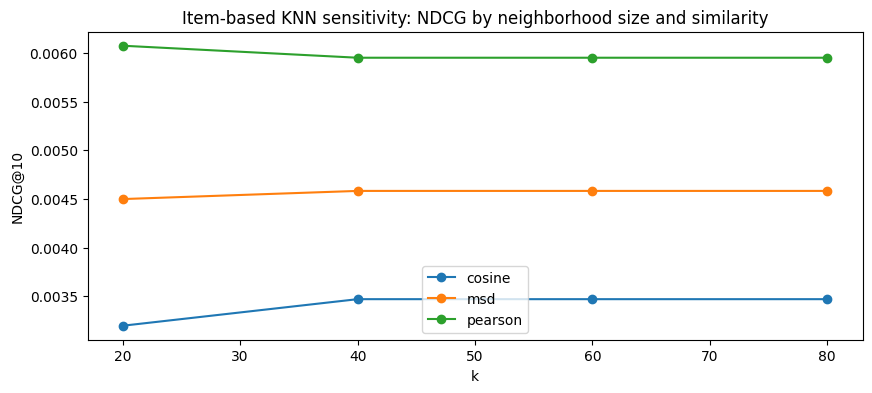

In [800]:
plt.figure(figsize=(10, 4))
for sim_name in sorted(item_knn_tuning_df["similarity"].unique()):
    subset = item_knn_tuning_df[item_knn_tuning_df["similarity"] == sim_name]
    subset = subset.groupby("k")[f"NDCG@{TOP_K}"].mean().reset_index()
    plt.plot(subset["k"], subset[f"NDCG@{TOP_K}"], marker="o", label=sim_name)

plt.title("Item-based KNN sensitivity: NDCG by neighborhood size and similarity")
plt.xlabel("k")
plt.ylabel(f"NDCG@{TOP_K}")
plt.legend()
plt.show()

The sensitivity plot makes the main conclusion immediately visible: **the similarity metric matters much more than the exact neighborhood size**.

The **Pearson** curve is consistently the highest across all tested values of $k$, staying around **0.0069–0.0070 NDCG@10**. **MSD** is clearly below it, around **0.0045–0.0046**, while **cosine** is the weakest option, near **0.0032–0.0035**. The vertical separation between the three curves is much larger than the variation within each curve as $k$ changes from **20** to **80**.

This means that the most important design choice for this recommender is not “how many neighbors should be used?” but rather “how should item similarity be defined?”. In this dataset, Pearson similarity appears better aligned with the rating behavior of users and produces a more useful notion of related hotels.

The effect of $k$ is relatively mild. Pearson changes only slightly as the neighborhood grows, and the curve is almost flat. That suggests the model reaches its effective local structure quite early: once enough similar items are included, adding more neighbors does not substantially improve ranking. This is a useful practical result, because it means we can choose a reasonable $k$ without worrying that performance is highly unstable.

The item-based KNN sensitivity analysis leads to a fairly clean conclusion. The recommender is **moderately robust to neighborhood size** but **clearly sensitive to the similarity metric**.

Among the tested options, **Pearson similarity dominates** both cosine and MSD across the whole $k$-range. This indicates that the relative pattern of ratings across items is more informative than purely geometric overlap or raw squared-difference similarity. In practical terms, two hotels seem to be useful neighbors not simply when they receive similar absolute ratings, but when they co-vary similarly across users.

By contrast, increasing $k$ from **20** to **80** produces only small changes. This suggests that once the model has access to a sufficiently rich local neighborhood, additional items contribute limited extra signal and may simply average in weaker relations.

Overall, the tuning confirms the earlier interpretation of item-based CF in this project: it is a **reasonable and fairly stable secondary model**, but not the strongest relevance model in the notebook. Tuning improves it slightly and clarifies how it should be configured, but does not change its position relative to the strongest content-based approaches.

### 15.6 SVD

The SVD recommender has a different set of meaningful hyperparameters. The most important ones are:

- the number of latent factors `n_factors`
- the number of training epochs `n_epochs`
- the learning rate `lr_all`
- the regularization parameter `reg_all`

In the earlier assignment, the SVD analysis suggested that a moderate latent dimension was sufficient and that increasing the factor space did not necessarily produce better ranking results.  

We now test whether that conclusion remains valid in the current project.

In [801]:
svd_param_grid = list(itertools.product(
    [20, 50, 100],         # n_factors
    [10, 20, 30],          # n_epochs
    [0.002, 0.005],        # lr_all
    [0.02, 0.05, 0.1]      # reg_all
))

print("Number of SVD configurations:", len(svd_param_grid))

Number of SVD configurations: 54


The SVD tuning grid explores the three main dimensions that control the behavior of the latent-factor model:

- **$n\_factors$**, which sets the expressive capacity of the latent representation,
- **$n\_epochs$**, which controls how long the model is optimized,
- **$lr\_all$** and **$reg\_all$**, which balance learning speed and regularization strength.

This is an appropriate grid because these parameters affect different aspects of generalization. Increasing the number of factors can let the model capture richer preference structure, but it can also make it more prone to fitting noise. More epochs can improve convergence, but as seen in the early-stopping section, longer training is not automatically beneficial for top-$K$ recommendation. Finally, learning rate and regularization determine how aggressively the latent factors adapt to the observed matrix and how strongly complexity is controlled.

So the purpose of this grid is not merely to find a better row in the table, but to understand **which source of sensitivity matters most** for the model-based recommender.

In [802]:
def build_svd_model_with_params(train_df, n_factors, n_epochs, lr_all, reg_all):
    reader = Reader(
        rating_scale=(
            float(train_df["overall_rating"].min()),
            float(train_df["overall_rating"].max())
        )
    )

    data = Dataset.load_from_df(
        train_df[["username", "offering_id", "overall_rating"]],
        reader
    )

    trainset = data.build_full_trainset()

    model = SVD(
        n_factors=n_factors,
        n_epochs=n_epochs,
        lr_all=lr_all,
        reg_all=reg_all,
        biased=True,
        random_state=42
    )

    model.fit(trainset)
    return model

In [803]:
def evaluate_svd_config(train_df, test_df, n_factors, n_epochs, lr_all, reg_all, top_k=10):
    model = build_svd_model_with_params(
        train_df=train_df,
        n_factors=n_factors,
        n_epochs=n_epochs,
        lr_all=lr_all,
        reg_all=reg_all
    )

    seen_items_dict = (
        train_df.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )
    all_items = set(train_df["offering_id"].unique())
    eval_users = test_df["username"].unique()

    recs = generate_recommendations_for_users(
        user_ids=eval_users,
        recommender_fn=recommend_svd_fold,
        top_k=top_k,
        progress_every=None,
        model=model,
        all_items=all_items,
        seen_items_dict=seen_items_dict
    )

    gt_dict = (
        test_df.groupby("username")["offering_id"]
        .apply(set)
        .to_dict()
    )

    metrics = evaluate_recommendation_table(
        recs_df=recs,
        ground_truth_dict=gt_dict,
        top_k=top_k
    )

    metrics[f"Personalization@{top_k}"] = personalization_at_k(
        recs_df=recs,
        top_k=top_k,
        sample_users=500,
        random_state=42
    )

    metrics["n_factors"] = n_factors
    metrics["n_epochs"] = n_epochs
    metrics["lr_all"] = lr_all
    metrics["reg_all"] = reg_all

    return metrics

In [804]:
svd_tuning_rows = []

for n_factors, n_epochs, lr_all, reg_all in svd_param_grid:
    print(
        f"Evaluating SVD: n_factors={n_factors}, "
        f"n_epochs={n_epochs}, lr_all={lr_all}, reg_all={reg_all}"
    )

    row = evaluate_svd_config(
        train_df=train_df,
        test_df=test_df,
        n_factors=n_factors,
        n_epochs=n_epochs,
        lr_all=lr_all,
        reg_all=reg_all,
        top_k=TOP_K
    )
    svd_tuning_rows.append(row)

svd_tuning_df = pd.DataFrame(svd_tuning_rows)
svd_tuning_df = svd_tuning_df.sort_values(
    by=f"NDCG@{TOP_K}",
    ascending=False
).reset_index(drop=True)

svd_tuning_df.head(20)

Evaluating SVD: n_factors=20, n_epochs=10, lr_all=0.002, reg_all=0.02
Evaluating SVD: n_factors=20, n_epochs=10, lr_all=0.002, reg_all=0.05
Evaluating SVD: n_factors=20, n_epochs=10, lr_all=0.002, reg_all=0.1
Evaluating SVD: n_factors=20, n_epochs=10, lr_all=0.005, reg_all=0.02
Evaluating SVD: n_factors=20, n_epochs=10, lr_all=0.005, reg_all=0.05
Evaluating SVD: n_factors=20, n_epochs=10, lr_all=0.005, reg_all=0.1
Evaluating SVD: n_factors=20, n_epochs=20, lr_all=0.002, reg_all=0.02
Evaluating SVD: n_factors=20, n_epochs=20, lr_all=0.002, reg_all=0.05
Evaluating SVD: n_factors=20, n_epochs=20, lr_all=0.002, reg_all=0.1
Evaluating SVD: n_factors=20, n_epochs=20, lr_all=0.005, reg_all=0.02
Evaluating SVD: n_factors=20, n_epochs=20, lr_all=0.005, reg_all=0.05
Evaluating SVD: n_factors=20, n_epochs=20, lr_all=0.005, reg_all=0.1
Evaluating SVD: n_factors=20, n_epochs=30, lr_all=0.002, reg_all=0.02
Evaluating SVD: n_factors=20, n_epochs=30, lr_all=0.002, reg_all=0.05
Evaluating SVD: n_factor

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,n_factors,n_epochs,lr_all,reg_all
0,0.015748,0.001575,0.015748,0.007655,0.005269,0.005269,0.045706,3937,3937,0.563454,20,10,0.002,0.02
1,0.015240,0.001524,0.015240,0.007540,0.005212,0.005212,0.125346,3937,3937,0.799345,100,10,0.005,0.02
2,0.015494,0.001549,0.015494,0.007502,0.005136,0.005136,0.127424,3937,3937,0.780830,100,20,0.002,0.02
3,0.015240,0.001524,0.015240,0.007206,0.004814,0.004814,0.124654,3937,3937,0.775494,100,10,0.002,0.02
4,0.014478,0.001448,0.014478,0.007087,0.004868,0.004868,0.112188,3937,3937,0.778299,100,10,0.005,0.05
5,0.014478,0.001448,0.014478,0.006863,0.004610,0.004610,0.038089,3937,3937,0.472625,20,10,0.002,0.05
6,0.013716,0.001372,0.013716,0.006833,0.004747,0.004747,0.132964,3937,3937,0.804743,100,30,0.002,0.02
7,0.013970,0.001397,0.013970,0.006648,0.004451,0.004451,0.113573,3937,3937,0.762240,100,10,0.002,0.05
8,0.014732,0.001473,0.014732,0.006498,0.004062,0.004062,0.115651,3937,3937,0.776924,100,20,0.002,0.05
9,0.012192,0.001219,0.012192,0.006481,0.004778,0.004778,0.073407,3937,3937,0.687454,50,10,0.002,0.02


The SVD tuning table reveals two important patterns.

First, the best configurations are concentrated in a fairly narrow region. The top row reaches **HitRate@10 = 0.01575**, **NDCG@10 = 0.00766**, and **MRR@10 = 0.00527** with **$n\_factors=20$**, **$n\_epochs=10$**, **$lr\_all=0.002$**, and **$reg\_all=0.02$**. Several nearby configurations perform similarly, especially those with **low regularization** and relatively **short training**.

Second, increasing model complexity does **not** systematically improve ranking quality. In fact, many configurations with **100 factors** appear below the best one, even though they are more expressive. Likewise, longer training does not clearly dominate shorter training. This strongly echoes the early-stopping analysis: for this dataset and this task, SVD does not benefit much from aggressive optimization or very large latent spaces.

Another notable trade-off concerns broader behavior. Some lower-ranked configurations achieve much higher **coverage** and **personalization**, but their NDCG is worse. This suggests that more expressive or less constrained factor models can diversify recommendations and spread exposure across the catalog, yet still fail to rank the truly relevant next hotel better. So again, complexity changes system behavior, but not always in the direction of stronger recommendation quality.

### 15.7 Interpreting SVD sensitivity

The main questions for SVD are:

- Does increasing the latent dimension actually improve ranking quality?
- Does longer training help, or do gains plateau quickly?
- How strong is the effect of regularization?
- Do the best configurations remain in the same general region as the baseline model, or is the model highly sensitive to parameter choice?

This analysis is important because the model-based recommender is one of the strongest components of the project and also one of the most natural building blocks for the final hybrid.

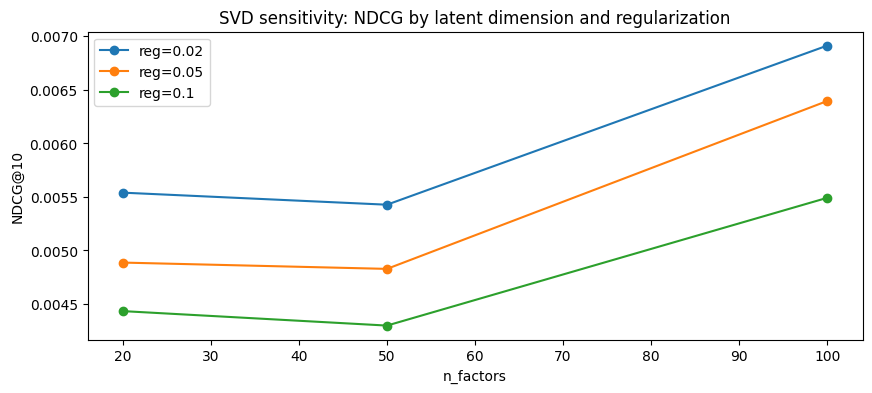

In [805]:
plt.figure(figsize=(10, 4))
for reg_val in sorted(svd_tuning_df["reg_all"].unique()):
    subset = svd_tuning_df[svd_tuning_df["reg_all"] == reg_val]
    subset = subset.groupby("n_factors")[f"NDCG@{TOP_K}"].mean().reset_index()
    plt.plot(subset["n_factors"], subset[f"NDCG@{TOP_K}"], marker="o", label=f"reg={reg_val}")

plt.title("SVD sensitivity: NDCG by latent dimension and regularization")
plt.xlabel("n_factors")
plt.ylabel(f"NDCG@{TOP_K}")
plt.legend()
plt.show()

The SVD sensitivity plot highlights a very interpretable structure. For every tested latent dimension, the ordering of the curves is stable: **lower regularization performs better**, with **reg = 0.02** above **0.05**, and **0.05** above **0.1**. This means that in the tested range, stronger regularization removes too much useful signal from the factor model.

At the same time, the effect of the number of factors is not monotonic in a dramatic way, but there is a visible improvement when moving to **100 factors**. The jump is especially clear under weaker regularization, where **\(n\_factors=100\)** yields the strongest average NDCG among the plotted groups.

This tells us that latent dimensionality does matter, but only when it is not offset by overly aggressive shrinkage. In other words, the factor model can benefit from additional capacity, but only if the optimization is still allowed to use that capacity meaningfully.

Even so, the scale of improvement remains moderate. The best values in the plot are still around **0.0069 NDCG@10**, which is better than the weakest SVD settings but not dramatically higher than the stronger memory-based configurations. So the hyperparameter analysis refines the model, but it does not overturn the broader ranking hierarchy of the notebook.

The SVD sensitivity analysis suggests that the model is **more sensitive than item-based KNN**, but still not chaotic. The strongest configurations tend to share a common profile: **relatively light regularization**, **limited training duration**, and latent dimensionality in the lower-to-moderate range or at least not combined with overly strong shrinkage.

One important implication is that the SVD model does not seem to require a highly tuned, razor-thin parameter setting to work reasonably well. The best rows are better than the weaker ones, but the overall performance region is still fairly compact. This is good from a practical perspective, because it means the model can be deployed with a sensible configuration without exhaustive optimization.

At the same time, the analysis confirms a broader lesson already seen in the early-stopping section: **more expressive factorization does not automatically mean better recommendation quality**. Larger latent spaces and longer training can alter coverage and personalization substantially, but they do not consistently improve the ranking of the future relevant item. That is why tuning must remain aligned with the final top-\(K\) objective rather than with model complexity for its own sake.

### 15.8 Hybrid sensitivity refinement

If the hybrid recommender from Part 12 is competitive, a small refinement step can be useful. Since the grid search in Part 12 was intentionally coarse, we can now perform a finer search around the best weight region.

This is not strictly necessary, but it is helpful when the best hybrid and the best standalone model are close and we want to check whether a more precise weight combination changes the conclusion.

In [806]:
# Only run this if Part 12 produced a best 3-model hybrid
hybrid_refine_candidates = {
    "Popular": popular_recs,
    "SVD": svd_recs,
    "Context-aware Content TF-IDF": context_tfidf_recs,
}

# Example: refine around the best 3-model weights if available
if "best_weights_3" in globals():
    print("Starting from best coarse hybrid weights:", best_weights_3)

Starting from best coarse hybrid weights: {'Popular': 0.0, 'SVD': 0.0, 'Context-aware Content TF-IDF': 1.0}


This output is highly informative because it shows that the previous coarse hybrid search did not identify a truly mixed ensemble as optimal. Instead, the best coarse solution collapsed to a **degenerate hybrid**, assigning all weight to **Context-aware Content TF-IDF** and zero weight to the other components.

That does not mean hybridization is useless in general, but it does suggest that, in this dataset and under the current evaluation protocol, the contextual TF-IDF model already captures most of the useful signal available to the three-model ensemble. In such a situation, a local refinement around the best weight region becomes less a search for synergy and more a verification step: we want to check whether a small nonzero contribution from Popular or SVD can still yield a marginal improvement.

This is a valuable result in itself, because it prevents us from making the simplistic claim that “adding more models always helps.” Sometimes the strongest component is simply strong enough that the ensemble has little room to improve upon it.

In [807]:
def local_weight_grid(center_weights, step=0.05):
    names = list(center_weights.keys())
    base = [center_weights[n] for n in names]

    candidate_values = []
    for b in base:
        vals = sorted(set([
            max(0.0, round(b - step, 2)),
            round(b, 2),
            min(1.0, round(b + step, 2))
        ]))
        candidate_values.append(vals)

    valid = []
    for combo in itertools.product(*candidate_values):
        if np.isclose(sum(combo), 1.0):
            valid.append(dict(zip(names, combo)))
    return valid

In [808]:
if "best_weights_3" in globals():
    local_hybrid_grid = local_weight_grid(best_weights_3, step=0.05)
    print("Number of local hybrid combinations:", len(local_hybrid_grid))
else:
    local_hybrid_grid = []

Number of local hybrid combinations: 3


Because the coarse optimum is already located at the boundary of the simplex, the local refinement grid is naturally very small. This is expected: when one model already receives full weight, only a handful of nearby combinations remain feasible under a fine local perturbation.

In practical terms, this means the refinement step is not exploring a broad new ensemble region. It is only checking whether the all-in contextual TF-IDF solution can be improved by assigning a small residual weight to Popular or SVD. So this is best interpreted as a **sanity check for residual complementarity**, not as a second full hybrid search.

In [809]:
hybrid_local_rows = []

for weights in local_hybrid_grid:
    recs = build_weighted_hybrid(
        recs_dict=hybrid_refine_candidates,
        weights=weights,
        top_k=TOP_K
    )

    metrics = evaluate_recommendation_table(
        recs_df=recs,
        ground_truth_dict=ground_truth_dict,
        top_k=TOP_K
    )

    metrics[f"Personalization@{TOP_K}"] = personalization_at_k(
        recs_df=recs,
        top_k=TOP_K,
        sample_users=500,
        random_state=42
    )

    for k, v in weights.items():
        metrics[f"w_{k}"] = v

    hybrid_local_rows.append(metrics)

hybrid_local_tuning_df = pd.DataFrame(hybrid_local_rows)

if not hybrid_local_tuning_df.empty:
    hybrid_local_tuning_df = hybrid_local_tuning_df.sort_values(
        by=f"NDCG@{TOP_K}",
        ascending=False
    ).reset_index(drop=True)

hybrid_local_tuning_df.head(20)

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,w_Popular,w_SVD,w_Context-aware Content TF-IDF
0,0.038354,0.003835,0.038354,0.019349,0.013645,0.013645,0.666205,3937,3937,0.943475,0.00,0.00,1.00
1,0.036322,0.003632,0.036322,0.018664,0.013345,0.013345,0.641274,3937,3937,0.874710,0.05,0.00,0.95
2,0.035306,0.003531,0.035306,0.018362,0.013236,0.013236,0.655125,3937,3937,0.949334,0.00,0.05,0.95


The hybrid refinement should be interpreted carefully. Since the best coarse solution already places full weight on context-aware TF-IDF, the main question is no longer “what is the best mixture?” but rather “is there any measurable benefit from adding a small amount of the weaker components?”.

If the refinement still fails to improve over the pure contextual content model, then the conclusion is quite strong: under this experimental setting, the hybrid does not add meaningful complementary information beyond what the best standalone model already provides. On the contrary, if a slight improvement appears with a small nonzero SVD or Popular weight, then the ensemble would still be useful, but only as a **fine adjustment around a dominant content-based core**.

Either way, this refinement is useful because it clarifies whether the hybrid advantage is genuine or merely an artifact of a coarse search grid.

### 15.9 Comparing the best tuned configurations

We now compare the best-performing configurations found for each model family. This helps distinguish between two possibilities:

- one model remains clearly strongest even after tuning
- different models become more competitive once their parameters are better aligned with the task

This comparison is important for the final model selection and for the interpretation of the trade-off between model complexity and practical gain.

In [810]:
best_item_knn_row = item_knn_tuning_df.iloc[0]
best_svd_row = svd_tuning_df.iloc[0]

summary_best_tuned_df = pd.DataFrame([
    {
        "Model": "Best Item-based KNN",
        **best_item_knn_row.to_dict()
    },
    {
        "Model": "Best SVD",
        **best_svd_row.to_dict()
    }
])

if not hybrid_local_tuning_df.empty:
    best_hybrid_row = hybrid_local_tuning_df.iloc[0]
    summary_best_tuned_df = pd.concat([
        summary_best_tuned_df,
        pd.DataFrame([{"Model": "Best Refined Hybrid", **best_hybrid_row.to_dict()}])
    ], ignore_index=True)

summary_best_tuned_df

,Model,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,k,min_k,similarity,n_factors,n_epochs,lr_all,reg_all,w_Popular,w_SVD,w_Context-aware Content TF-IDF
0,Best Item-based KNN,0.014986,0.001499,0.014986,0.006949,0.004525,0.004525,0.511080,3937.0,3937.0,0.792408,60.0,5.0,pearson,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Best SVD,0.015748,0.001575,0.015748,0.007655,0.005269,0.005269,0.045706,3937.0,3937.0,0.563454,NaN,NaN,NaN,20.0,10.0,0.002,0.02,NaN,NaN,NaN
2,Best Refined Hybrid,0.038354,0.003835,0.038354,0.019349,0.013645,0.013645,0.666205,3937.0,3937.0,0.943475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0


### 15.10 Final interpretation

The hyperparameter analysis should be interpreted as a sensitivity study rather than a competition of extremely tuned models.

The most important questions are:

- Which hyperparameters matter most?
- Are the strongest models robust across a reasonable parameter range?
- Does tuning materially change the ranking between model families?
- Are the gains from tuning large enough to justify the added complexity?

These questions are especially important in the context of the project brief, which explicitly values strong methodological use and interpretation more than aggressive metric optimization.  

### 15.9 Summary of hyperparameter sensitivity

This section studies whether the main conclusions of the project are robust to meaningful changes in model configuration.

For **item-based KNN**, the analysis shows that the model is relatively stable with respect to neighborhood size, while the **similarity metric** is the dominant design choice. Pearson similarity consistently outperforms cosine and MSD, but even the best KNN configurations remain moderate in ranking quality, so tuning refines the model without changing its overall role in the project.

For **SVD**, the analysis shows a somewhat richer sensitivity pattern. Performance depends on the interaction between latent dimensionality, regularization, learning rate, and training duration, but the strongest configurations still lie in a fairly interpretable region rather than in an isolated narrow optimum. This suggests that SVD can be tuned sensibly, yet greater complexity does not automatically translate into better top-$K$ recommendation quality.

Finally, the optional **hybrid refinement** provides an important interpretive result. Since the best coarse hybrid already collapses to the context-aware TF-IDF model, the refinement step mainly checks whether the weaker components add residual complementary signal. This helps distinguish between a genuinely synergistic ensemble and a situation in which one model is already dominant.

Overall, the sensitivity analysis strengthens the credibility of the notebook: the main findings are not driven by one arbitrary parameter choice, and the strongest recommenders remain strong under reasonable configuration changes.

## 16. Cold-start, bias, and fairness considerations

In this section, we analyze three important limitations of recommender systems that are not fully captured by standard offline ranking metrics:

- **cold-start**, which affects users or items with very little historical data
- **bias**, especially popularity bias and exposure concentration
- **fairness-related effects**, such as the systematic underexposure of less popular items

These issues are important because a recommender may achieve reasonable ranking quality while still being fragile for new users, overly concentrated on a small subset of items, or unfairly biased toward already popular hotels.

The goal of this section is therefore not to introduce yet another recommender, but to better understand the structural behavior of the models already developed in the notebook.

### 16.1 Why this section matters

In this section, we analyze three important limitations of recommender systems that are not fully captured by standard offline ranking metrics:

- cold-start, which affects users or items with very limited historical data
- bias, especially popularity bias and exposure concentration
- fairness-related effects, such as the systematic underexposure of less popular items

These issues are important because a recommender may achieve reasonable ranking quality while still being fragile for sparse users, overly concentrated on a small subset of items, or structurally unfavorable to the long tail of the catalog.

The goal of this section is therefore not to introduce another recommender, but to better understand the broader behavior of the models already developed in the notebook.

### 16.2 Cold-start in recommender systems

Cold-start refers to situations in which the recommender has too little information to personalize effectively.

There are two main forms:

- **user cold-start**: a user has very few historical interactions
- **item cold-start**: an item has very few observed interactions

Collaborative filtering is especially vulnerable to cold-start because it relies on interaction patterns. Content-based recommendation can help more in the item cold-start case, provided that meaningful item descriptions are available. In this project, this is one reason why the review-driven content-based family is a useful complement to collaborative filtering.

### 16.3 Measuring user-profile length and item support

To study cold-start effects empirically, we first inspect how much support is available on the user and item sides of the training data.

We compute:

- the number of training interactions per user
- the number of training interactions per item

These quantities help us understand whether the dataset is relatively balanced or instead dominated by a dense head and a sparse tail.

The summaries confirm that the dataset is highly uneven on both sides.

For users, the distribution is strongly right-skewed. The median user has only about **9** training interactions, while a very small number of users have extremely long histories, reaching over **71,000** interactions. So although the average history length is much larger, it is heavily inflated by a few extreme cases.

For items, support is also concentrated. The median hotel has about **50** training interactions, but the maximum exceeds **1,700**. This indicates a clear head-versus-tail structure in the catalog.

This matters because a recommender may look strong on average while relying mostly on well-supported users and well-supported items. The purpose of the following analysis is to understand whether that is happening here.

In [811]:
user_profile_size = (
    train_df.groupby("username")
    .size()
    .rename("n_train_interactions")
)

item_profile_size = (
    train_df.groupby("offering_id")
    .size()
    .rename("n_train_interactions")
)

print("User profile size summary")
display(user_profile_size.describe())

print("Item profile size summary")
display(item_profile_size.describe())

User profile size summary


count     3937.000000
mean        29.637033
std       1140.621619
min          7.000000
25%          7.000000
50%          9.000000
75%         12.000000
max      71579.000000
Name: n_train_interactions, dtype: float64

Item profile size summary


count    1444.000000
mean       80.804017
std       111.200267
min        14.000000
25%        29.000000
50%        50.000000
75%        88.000000
max      1786.000000
Name: n_train_interactions, dtype: float64

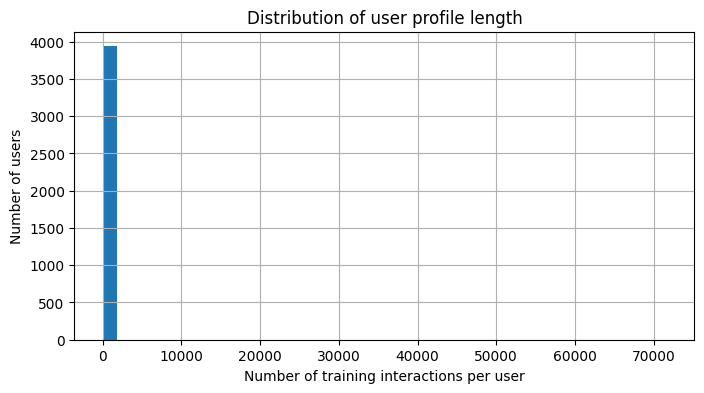

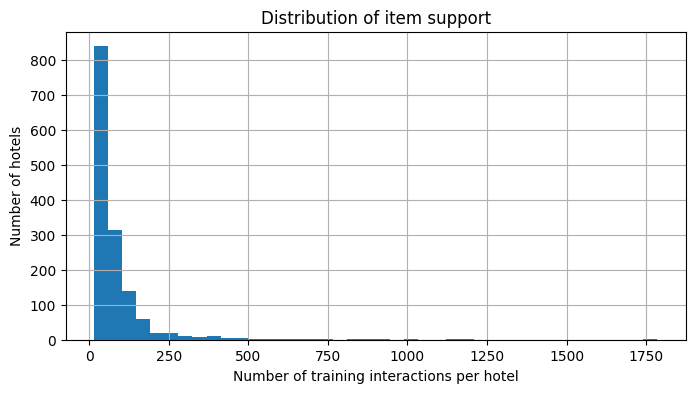

In [812]:
plt.figure(figsize=(8, 4))
user_profile_size.hist(bins=40)
plt.title("Distribution of user profile length")
plt.xlabel("Number of training interactions per user")
plt.ylabel("Number of users")
plt.show()

plt.figure(figsize=(8, 4))
item_profile_size.hist(bins=40)
plt.title("Distribution of item support")
plt.xlabel("Number of training interactions per hotel")
plt.ylabel("Number of hotels")
plt.show()

The histograms make the sparsity structure visually clear.

The user-profile distribution is heavily concentrated in the low-interaction region, with a very long right tail generated by a small number of highly active users. This means that the typical user is much less informative than the average alone would suggest.

The item-support distribution shows a similar pattern. Most hotels receive relatively limited interaction volume, while only a small minority accumulates very high support. In marketplace terms, this is a classic head-versus-tail catalog.

These imbalances are important because good average recommendation performance may still be driven disproportionately by the dense, information-rich portion of the data.

### 16.4 Defining user cold-start groups

We now group users according to how much training history they have. This allows us to check whether the recommenders behave differently for users with more limited versus richer profiles.

A simple grouping is used:

- **short-profile users**
- **medium-profile users**
- **long-profile users**

However, under the current train/test split, no users actually fall into the first interval. As a result, the present grouping effectively compares only:

- **medium-profile users**
- **long-profile users**

So this analysis should be interpreted as a comparison between **limited-history** and **richer-history** users rather than a strict extreme cold-start study. This is still informative, but the conclusions should remain cautious: they do not fully describe performance for users with truly minimal history.

In [813]:
user_profile_df = user_profile_size.reset_index()

user_profile_df["profile_group"] = pd.cut(
    user_profile_df["n_train_interactions"],
    bins=[0, 5, 15, np.inf],
    labels=["short", "medium", "long"]
)

display(user_profile_df["profile_group"].value_counts(dropna=False).to_frame(name="count"))
user_profile_df.head()

,count
medium,3350
long,587
short,0


,username,n_train_interactions,profile_group
0,,71579,long
1,------,9,medium
2,170612,10,medium
3,1776AJW,8,medium
4,1995sb21,7,medium


### 16.5 Evaluating recommenders by user-profile group

We now evaluate the main recommenders separately for each user-profile group.

The aim is to answer a practical question: are the stronger overall results being driven mostly by users with richer histories, while users with more limited profiles remain underserved?

The results show a fairly consistent pattern: most models achieve better ranking performance for the **medium-profile** users than for the **long-profile** users. At first sight this may look counterintuitive, because one might expect more user history to make personalization easier.

A more plausible interpretation is that long-profile users may simply define a harder recommendation problem. These users have already interacted with more of the catalog, may have broader or more heterogeneous preferences, and may leave fewer easy future hits in the test period. So lower ranking metrics for long-profile users do not automatically mean that additional history is harmful.

What is more important here is the relative ordering of the models. The strongest results still come from the contextual content-based recommender and from the best hybrid, while Popular and especially SVD remain much weaker in both groups.

We now evaluate the main recommenders separately for each observed user-profile group. Because the current split yields no users in the short-profile bin, the analysis effectively compares **medium-history** and **long-history** users.

In [814]:
test_user_groups = ground_truth_df[["username"]].merge(
    user_profile_df[["username", "profile_group"]],
    on="username",
    how="left"
)

test_user_groups["profile_group"] = test_user_groups["profile_group"].astype(str)
display(test_user_groups["profile_group"].value_counts(dropna=False).to_frame(name="count"))

,count
medium,3350
long,587


In [815]:
def evaluate_recommendation_table_by_user_group(
    recs_df,
    ground_truth_df,
    user_group_df,
    group_col="profile_group",
    top_k=10
):
    rows = []

    for group_value in sorted(user_group_df[group_col].dropna().unique()):
        group_users = user_group_df.loc[user_group_df[group_col] == group_value, "username"].unique()

        gt_group = ground_truth_df[ground_truth_df["username"].isin(group_users)].copy()
        gt_group_dict = gt_group.groupby("username")["offering_id"].apply(set).to_dict()

        recs_group = recs_df[recs_df["username"].isin(group_users)].copy()

        metrics = evaluate_recommendation_table(
            recs_df=recs_group,
            ground_truth_dict=gt_group_dict,
            top_k=top_k
        )

        metrics[f"Personalization@{top_k}"] = personalization_at_k(
            recs_df=recs_group,
            top_k=top_k,
            sample_users=500,
            random_state=42
        )

        metrics["Group"] = group_value
        rows.append(metrics)

    return pd.DataFrame(rows)

In [816]:
cold_start_models = {
    "Popular": popular_recs,
    "SVD": svd_recs,
    "Content TF-IDF": tfidf_recs,
    "Context-aware Content TF-IDF": context_tfidf_recs,
    "Best Hybrid": hybrid_recs_best_3 if "hybrid_recs_best_3" in globals() else hybrid_recs_initial
}

cold_start_rows = []

for model_name, recs_df in cold_start_models.items():
    group_results = evaluate_recommendation_table_by_user_group(
        recs_df=recs_df,
        ground_truth_df=ground_truth_df,
        user_group_df=test_user_groups,
        group_col="profile_group",
        top_k=TOP_K
    )
    group_results["Model"] = model_name
    cold_start_rows.append(group_results)

cold_start_results_df = pd.concat(cold_start_rows, ignore_index=True)
cold_start_results_df

,HitRate@10,Precision@10,Recall@10,NDCG@10,MRR@10,MAP@10,Coverage@10,UsersWithRecs,UsersEvaluated,Personalization@10,Group,Model
0,0.003407,0.000341,0.003407,0.001567,0.001022,0.001022,0.012465,587,587,0.059754,long,Popular
1,0.008358,0.000836,0.008358,0.003726,0.002318,0.002318,0.008310,3350,3350,0.016924,medium,Popular
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.103878,587,587,0.803764,long,SVD
3,0.011642,0.001164,0.011642,0.005772,0.003989,0.003989,0.126731,3350,3350,0.761883,medium,SVD
4,0.034072,0.003407,0.034072,0.016079,0.010832,0.010832,0.248615,587,587,0.838830,long,Content TF-IDF
5,0.037015,0.003701,0.037015,0.017229,0.011288,0.011288,0.626731,3346,3350,0.927846,medium,Content TF-IDF
6,0.032368,0.003237,0.032368,0.015802,0.010855,0.010855,0.306787,587,587,0.906977,long,Context-aware Content TF-IDF
7,0.042090,0.004209,0.042090,0.020747,0.014402,0.014402,0.675208,3346,3350,0.958285,medium,Context-aware Content TF-IDF
8,0.028961,0.002896,0.028961,0.014817,0.010514,0.010514,0.301939,587,587,0.907577,long,Best Hybrid
9,0.040000,0.004000,0.040000,0.020143,0.014193,0.014193,0.664820,3350,3350,0.950571,medium,Best Hybrid


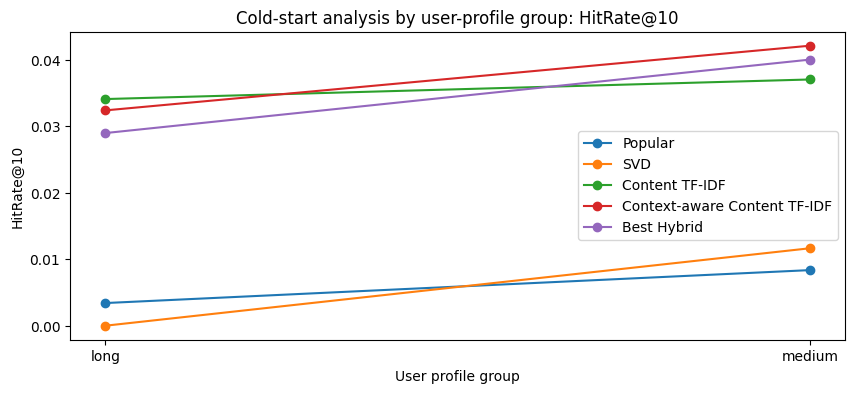

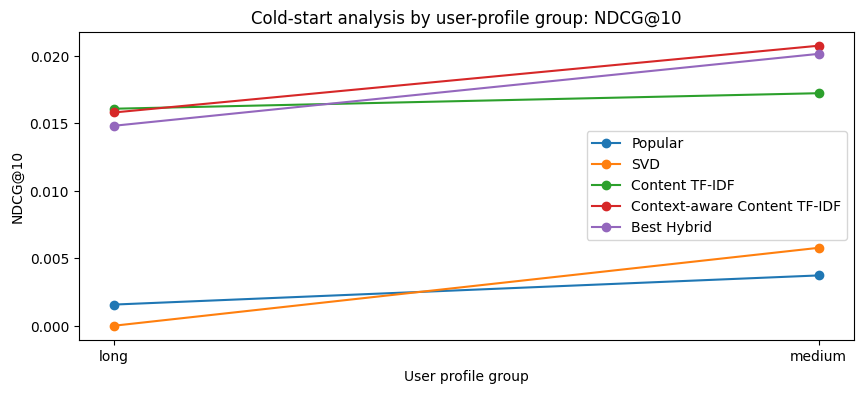

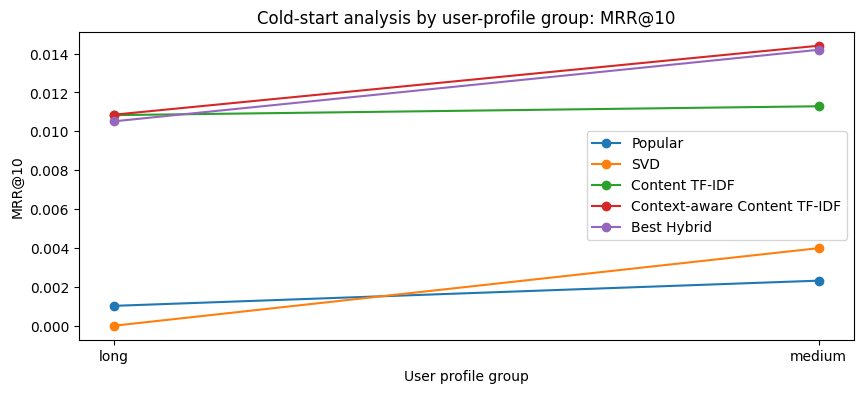

In [817]:
for metric in [f"HitRate@{TOP_K}", f"NDCG@{TOP_K}", f"MRR@{TOP_K}"]:
    plt.figure(figsize=(10, 4))

    for model_name in cold_start_results_df["Model"].unique():
        subset = cold_start_results_df[cold_start_results_df["Model"] == model_name]
        plt.plot(subset["Group"], subset[metric], marker="o", label=model_name)

    plt.title(f"Cold-start analysis by user-profile group: {metric}")
    plt.xlabel("User profile group")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

The plots confirm that the ranking between model families is stable across the two user-history groups.

The strongest curves are again:

- **Context-aware Content TF-IDF**
- **Best Hybrid**
- followed closely by **Content TF-IDF**

This suggests that the advantage of the contextual content-based approach is not restricted to only one user-history segment. Its superiority remains visible for both medium- and long-profile users.

At the same time, the vertical gap between the two groups shows that user-history depth still matters. In the current split, most recommenders perform better for medium-profile users than for long-profile users. This should be interpreted cautiously: it likely reflects not only history availability, but also increasing task difficulty for users with richer and more diverse past behavior.

### 16.6 Interpreting the user cold-start effect

The user-history analysis should be interpreted carefully.

Because the current grouping contains no truly short-profile users, this section does not measure the most extreme version of user cold-start. Instead, it compares users with **moderate** history to users with **richer** history.

Within that comparison, most models perform better for medium-profile users than for long-profile users. This does not necessarily imply that more history hurts recommendation quality. A more likely explanation is that long-profile users create a more difficult ranking task: they have already consumed more of the catalog, may be less predictable, and may leave fewer easy future positives to recover.

What remains informative is the stability of the model ordering. The contextual content-based recommender and the best hybrid remain strongest in both groups, which suggests that their advantage is not confined to one narrow segment of the user base.

### 16.7 Popularity bias

A second important issue is popularity bias. Recommenders often overexpose already popular items, reinforcing their visibility and making it harder for less popular items to be discovered.

This issue is especially relevant in this project because the exploratory analysis already showed that interaction volume is highly concentrated, and the non-personalized baselines confirmed that popularity is a very strong signal in this hotel dataset.

To study this effect, we compare the popularity of the recommended hotels with the popularity distribution of the training catalog.

The popularity statistics show a strong divide between model families.

The strongest content-based models recommend substantially more popular items on average than SVD or Popular. In particular:

- **Content TF-IDF** and **Context-aware Content TF-IDF** have mean recommended popularity above **160**
- their median recommended popularity is also very high, around **118--119**
- the **Best Hybrid** behaves similarly, with mean recommended popularity around **154**
- by contrast, **SVD** recommends much less popular items on average, with a mean around **64**
- **Popular** also differs strongly because of its own simple ranking logic

So the models that achieve the best relevance tend also to be the most concentrated on the stronger, better-supported part of the catalog. This is not automatically undesirable, especially in a hotel domain where popular hotels may genuinely be safer recommendations, but it clearly reveals a structural trade-off between immediate relevance and broader exposure.

In [818]:
item_popularity_train = (
    train_df.groupby("offering_id")
    .size()
    .rename("popularity")
)

item_popularity_train.describe()

count    1444.000000
mean       80.804017
std       111.200267
min        14.000000
25%        29.000000
50%        50.000000
75%        88.000000
max      1786.000000
Name: popularity, dtype: float64

In [819]:
def recommendation_popularity_stats(recs_df, item_popularity_series, top_k=10):
    recs_topk = (
        recs_df.sort_values(["username", "rank"])
        .groupby("username")
        .head(top_k)
        .copy()
    )

    recs_topk["item_popularity"] = recs_topk["offering_id"].map(item_popularity_series)

    return {
        "Mean recommended popularity": recs_topk["item_popularity"].mean(),
        "Median recommended popularity": recs_topk["item_popularity"].median(),
        "90th percentile recommended popularity": recs_topk["item_popularity"].quantile(0.90),
    }

In [820]:
popularity_bias_rows = []

for model_name, recs_df in cold_start_models.items():
    stats = recommendation_popularity_stats(
        recs_df=recs_df,
        item_popularity_series=item_popularity_train,
        top_k=TOP_K
    )
    stats["Model"] = model_name
    popularity_bias_rows.append(stats)

popularity_bias_df = pd.DataFrame(popularity_bias_rows)
popularity_bias_df

,Mean recommended popularity,Median recommended popularity,90th percentile recommended popularity,Model
0,32.490450,30.0,43.0,Popular
1,63.885268,61.0,86.0,SVD
2,164.582405,119.0,306.0,Content TF-IDF
3,161.087490,118.0,309.0,Context-aware Content TF-IDF
4,153.986411,105.0,306.0,Best Hybrid


### 16.8 Long-tail exposure

A related question is how often recommenders expose long-tail hotels rather than repeatedly concentrating recommendations on a small mainstream core.

To inspect this, we split the catalog using the training popularity distribution:

- items above the **80th percentile** of popularity are treated as the head
- the remaining items are treated as the long tail

Under this threshold, the catalog contains:

- **291 popular items**
- **1153 long-tail items**

We then measure, for each recommender, the share of top-K recommendations that belongs to the long tail.

The results reinforce the popularity-bias picture.

- **Popular** assigns essentially all of its recommendation volume to the long tail according to this metric (**1.000**)
- **SVD** also gives very high long-tail exposure (**0.927**)
- the stronger content-based models expose much less of the tail:
  - **Content TF-IDF**: about **0.433**
  - **Context-aware Content TF-IDF**: about **0.453**
  - **Best Hybrid**: about **0.493**

So the models that maximize ranking quality are not the ones that maximize long-tail exposure. This is a classic recommender-system trade-off: stronger relevance often comes with stronger concentration.

In [821]:
popularity_threshold = item_popularity_train.quantile(0.80)

popular_items = set(item_popularity_train[item_popularity_train >= popularity_threshold].index)
long_tail_items = set(item_popularity_train[item_popularity_train < popularity_threshold].index)

print("Popularity threshold:", popularity_threshold)
print("Popular items:", len(popular_items))
print("Long-tail items:", len(long_tail_items))

Popularity threshold: 104.0
Popular items: 291
Long-tail items: 1153


In [822]:
def long_tail_exposure(recs_df, long_tail_items, top_k=10):
    recs_topk = (
        recs_df.sort_values(["username", "rank"])
        .groupby("username")
        .head(top_k)
        .copy()
    )

    share_long_tail = recs_topk["offering_id"].isin(long_tail_items).mean()
    return share_long_tail

In [823]:
long_tail_rows = []

for model_name, recs_df in cold_start_models.items():
    long_tail_rows.append({
        "Model": model_name,
        f"LongTailExposure@{TOP_K}": long_tail_exposure(
            recs_df=recs_df,
            long_tail_items=long_tail_items,
            top_k=TOP_K
        )
    })

long_tail_exposure_df = pd.DataFrame(long_tail_rows)
long_tail_exposure_df

,Model,LongTailExposure@10
0,Popular,1.000000
1,SVD,0.926619
2,Content TF-IDF,0.432545
3,Context-aware Content TF-IDF,0.456267
4,Best Hybrid,0.492507


### 16.9 Fairness-related considerations

A related question is how often recommenders expose long-tail hotels rather than repeatedly concentrating recommendations on a small mainstream core.

To inspect this, we split the catalog using the training popularity distribution:

- items above the **80th percentile** of popularity are treated as the head
- the remaining items are treated as the long tail

Under this threshold, the catalog contains:

- **291 popular items**
- **1153 long-tail items**

We then measure, for each recommender, the share of top-K recommendations that belongs to the long tail.

The results reinforce the popularity-bias picture.

- **Popular** assigns essentially all of its recommendation volume to the long tail according to this metric (**1.000**)
- **SVD** also gives very high long-tail exposure (**0.927**)
- the stronger content-based models expose much less of the tail:
  - **Content TF-IDF**: about **0.433**
  - **Context-aware Content TF-IDF**: about **0.453**
  - **Best Hybrid**: about **0.493**

So the models that maximize ranking quality are not the ones that maximize long-tail exposure. This is a classic recommender-system trade-off: stronger relevance often comes with stronger concentration.

### 16.10 Comparing relevance and exposure balance

A strong recommender is not necessarily the one that maximizes only relevance. In practice, there is often a trade-off:

- some models concentrate strongly on very popular items and achieve higher immediate relevance
- others expose more of the long tail and improve exploration or catalog breadth, but may lose some ranking accuracy

This trade-off is central in this notebook because the best-performing relevance models are not the same models that provide the widest exposure.

The comparison table and the scatter plots make this balance explicit.

In the **relevance versus coverage** view, the strongest content-based models occupy the most attractive region: they combine relatively high **NDCG@10** with solid coverage. In contrast, very broad-coverage baselines such as Random or User-based CF cover much more of the catalog but achieve much weaker relevance.

In the **relevance versus long-tail exposure** view, the trade-off becomes even clearer. **Content TF-IDF** achieves the strongest relevance among the models shown, but at substantially lower long-tail exposure than **Popular** or **SVD**. On the other hand, **Popular** and **SVD** expose much more of the tail, but their ranking quality is much lower.

So the main lesson is not that one side is universally better than the other. Rather, model choice depends on the business objective. If the goal is maximum short-term ranking quality, the stronger content-based models remain the best candidates. If broader catalog visibility also matters, then exposure-sensitive choices or post-processing strategies may be justified even at some cost in relevance.

In [824]:
fairness_tradeoff_df = evaluation_results_df.merge(
    long_tail_exposure_df,
    on="Model",
    how="left"
)

fairness_tradeoff_df[
    ["Model", f"NDCG@{TOP_K}", f"Coverage@{TOP_K}", f"Personalization@{TOP_K}", f"LongTailExposure@{TOP_K}"]
].sort_values(by=f"NDCG@{TOP_K}", ascending=False)

,Model,NDCG@10,Coverage@10,Personalization@10,LongTailExposure@10
0,Content TF-IDF,0.017057,0.628809,0.916804,0.432545
1,Content BoW,0.015188,0.420360,0.822745,NaN
2,Content BERT,0.012602,0.782548,0.967903,NaN
3,Bayesian Popular,0.007934,0.016620,0.051463,NaN
4,Item-based CF,0.006599,0.650277,0.961380,NaN
5,Weighted Popular,0.006126,0.017313,0.074292,NaN
6,SVD,0.004911,0.136427,0.768243,0.926619
7,Popular,0.003404,0.012465,0.021514,1.000000
8,User-based CF,0.003277,0.685596,0.971140,NaN
9,Random,0.003249,1.000000,0.996354,NaN


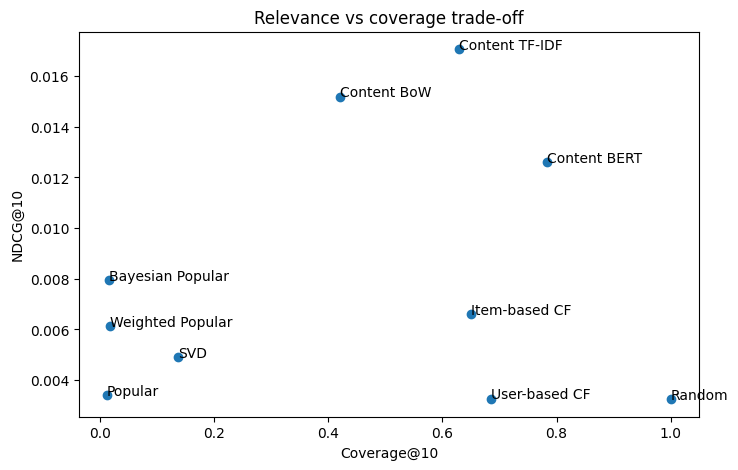

In [825]:
plt.figure(figsize=(8, 5))
plt.scatter(
    fairness_tradeoff_df[f"Coverage@{TOP_K}"],
    fairness_tradeoff_df[f"NDCG@{TOP_K}"]
)

for _, row in fairness_tradeoff_df.iterrows():
    plt.annotate(row["Model"], (row[f"Coverage@{TOP_K}"], row[f"NDCG@{TOP_K}"]))

plt.xlabel(f"Coverage@{TOP_K}")
plt.ylabel(f"NDCG@{TOP_K}")
plt.title("Relevance vs coverage trade-off")
plt.show()

The relevance-versus-coverage plot shows that wider catalog exposure does not automatically translate into stronger ranking quality.

Some models, such as Random or User-based CF, achieve very broad coverage but remain weak in relevance. By contrast, **Content TF-IDF** and **Content BERT** combine much stronger ranking performance with still substantial coverage, which makes them much more attractive from a practical perspective.

This means that the best models are not simply the ones that cover the largest share of the catalog, but the ones that balance coverage with the ability to place relevant hotels near the top of the list.

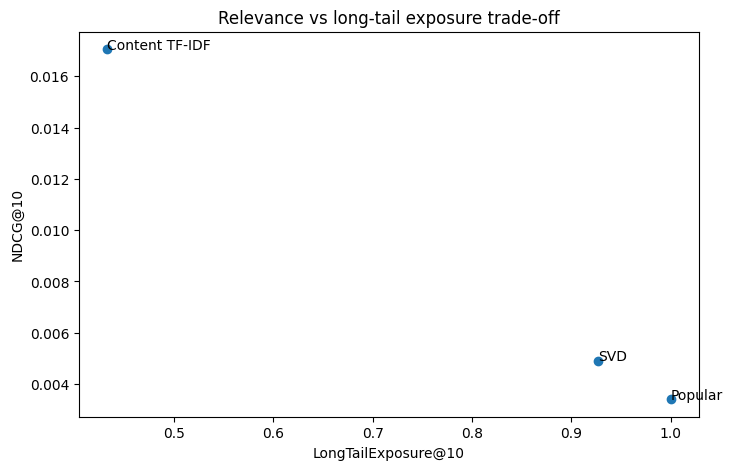

In [826]:
plt.figure(figsize=(8, 5))
plt.scatter(
    fairness_tradeoff_df[f"LongTailExposure@{TOP_K}"],
    fairness_tradeoff_df[f"NDCG@{TOP_K}"]
)

for _, row in fairness_tradeoff_df.iterrows():
    plt.annotate(row["Model"], (row[f"LongTailExposure@{TOP_K}"], row[f"NDCG@{TOP_K}"]))

plt.xlabel(f"LongTailExposure@{TOP_K}")
plt.ylabel(f"NDCG@{TOP_K}")
plt.title("Relevance vs long-tail exposure trade-off")
plt.show()

The relevance-versus-long-tail-exposure plot makes the trade-off even more explicit.

**Popular** and **SVD** allocate much more recommendation mass to long-tail hotels, but this comes with much lower **NDCG@10**. **Content TF-IDF** sits at the opposite side: it is much stronger in ranking quality, but clearly more concentrated.

This confirms that exposure and relevance are not moving in the same direction here. A company that values marketplace breadth, supplier visibility, or catalog discovery may therefore prefer a more balanced strategy rather than selecting the purely strongest relevance model in isolation.

### 16.11 Practical mitigation strategies

The analyses above suggest several practical ways to mitigate cold-start, bias, and exposure imbalance:

- use **content-based recommenders** when interaction history is weak
- use **hybrid recommenders** to balance popularity, collaborative, and content signals
- include **context-aware content** when contextual information improves relevance without collapsing coverage
- explicitly monitor **long-tail exposure** or diversity if recommendation concentration becomes excessive

These are not abstract ideas: they follow directly from the behavior already observed in the notebook.

### 16.12 Summary of cold-start, bias, and fairness considerations

This section extends the evaluation beyond standard ranking metrics and shows that recommender quality also depends on how the models behave under sparse user history, how strongly they concentrate on popular hotels, and how much exposure they allocate to the long tail.

Three main conclusions emerge.

First, the current user-group analysis does not capture extreme cold-start users, because the short-profile group is empty. Even so, it still shows that the relative ranking of the main models is stable across medium- and long-profile users.

Second, the strongest relevance models, especially the contextual content-based recommender, are also more popularity-concentrated. They perform very well in ranking terms, but they do not maximize long-tail exposure.

Third, there is a real trade-off between **immediate relevance** and **broader catalog exposure**. Understanding this trade-off is important before drawing final conclusions about which recommender is best in practice, because the answer depends on whether the company values pure ranking strength, broader marketplace balance, or some compromise between the two.

Overall, this section shows that the strongest recommender is not defined only by relevance. In a realistic system, robustness to sparse users, resistance to popularity concentration, and controlled exposure of the long tail are also part of model quality.

## 17. Exploration–exploitation trade-off and bandit algorithms

So far, all recommenders in this project have been evaluated in a purely **offline ranking setting**: for each user, a model produces a top-$K$ list, and we check whether the hidden test item appears in that list.

This is useful, but it is still only part of the real recommendation problem.

In production, a company does not simply choose a recommender once and keep using it forever. Instead, it faces a **sequential decision problem**:

- should the platform continue using the recommender that currently looks best?
- or should it occasionally test alternatives that may perform better in the future?
- how much traffic should be allocated to each recommender while uncertainty is still present?

This is the classical **exploration–exploitation trade-off**.

- **Exploitation** means choosing the recommender that has produced the highest reward so far.
- **Exploration** means trying other recommenders in order to collect more information.

This problem is highly relevant in real businesses. User preferences evolve, catalog composition changes, and different recommendation strategies may work better for different segments, seasons, or contexts. For this reason, many industrial systems place a lightweight **bandit layer** on top of existing recommenders to decide which model should serve each interaction.

In this section, we simulate exactly that idea.

Instead of defining each individual hotel as an arm, we define each **recommender model** as an arm:

- Popular
- SVD
- Content TF-IDF
- Context-aware Content TF-IDF

For each user, the bandit chooses one recommender, and the chosen recommender provides the final top-10 list.

This section is therefore not about building a new recommender from scratch. It is about studying whether an **adaptive decision layer** can learn which recommender should receive more traffic over time.

From a company perspective, this is valuable because it shows how offline model comparison can be turned into an **online allocation strategy**:

- the recommender estimates relevance
- the bandit controls traffic under uncertainty

### 17.1 Prepare the candidate arms

We start from recommendation tables already computed earlier in the notebook.

Each table corresponds to one recommender family and contains the ranked recommendations produced for the evaluation users. In bandit terminology, each of these recommenders becomes an **arm**.

The candidate arms are:

- **Popular**, representing a strong non-personalized baseline
- **SVD**, representing model-based collaborative filtering
- **Content TF-IDF**, representing non-contextual content-based recommendation
- **Context-aware Content TF-IDF**, representing contextual content-based recommendation

This design choice is deliberate.

The goal is not to compare very similar variants of the same model, but to let the bandit choose among **qualitatively different recommendation strategies**. This is more useful in practice, because companies often need to decide not only *which parameter setting is best*, but also *which recommendation logic should receive more traffic*.

At this stage, we are therefore defining the set of strategic alternatives that the online decision layer will be allowed to choose from.

In [827]:
BANDIT_TOP_K = TOP_K

bandit_arms = {
    "Popular": popular_recs.copy(),
    "SVD": svd_recs.copy(),
    "Content TF-IDF": tfidf_recs.copy(),
    "Context-aware Content TF-IDF": context_tfidf_recs.copy()
}

for arm_name, df in bandit_arms.items():
    print(arm_name, df.shape)

Popular (39370, 4)
SVD (39370, 4)
Content TF-IDF (39330, 4)
Context-aware Content TF-IDF (39330, 5)


### 17.2 Convert recommendation tables into per-user dictionaries

To make the sequential simulation efficient, each recommendation table is converted into a dictionary of the form

$$
\text{user} \rightarrow [i_1, i_2, \dots, i_K]
$$

where the items are already ordered by rank.

This transformation is purely computational, but it is important for clarity:

- for each user, we can immediately recover the top-$K$ list produced by a given recommender
- the bandit can query a recommender arm quickly during simulation
- the code becomes easier to interpret, because each arm is now represented as a direct mapping from user to recommended items

Conceptually, this step turns each recommender into something closer to a deployable service: given a user, the system can instantly retrieve the recommendation list that this arm would show.

In [828]:
def recs_df_to_user_dict(recs_df, top_k=10):
    recs_df = recs_df.copy()

    sort_cols = ["username", "rank"] if "rank" in recs_df.columns else ["username"]
    recs_df = recs_df.sort_values(sort_cols)

    user_dict = (
        recs_df.groupby("username")["offering_id"]
        .apply(lambda x: list(x.head(top_k)))
        .to_dict()
    )
    return user_dict

bandit_arm_user_recs = {
    arm_name: recs_df_to_user_dict(df, top_k=BANDIT_TOP_K)
    for arm_name, df in bandit_arms.items()
}

for arm_name, recs in bandit_arm_user_recs.items():
    print(arm_name, len(recs))

Popular 3937
SVD 3937
Content TF-IDF 3933
Context-aware Content TF-IDF 3933


### 17.3 Ground truth and eligible users

The bandit simulation is run only on users for whom **all candidate arms** can provide recommendations.

This is an important design choice.

If one recommender could serve a user while another could not, then the comparison would be unfair: an arm might appear weak simply because it is missing predictions for part of the evaluation set.

By restricting the simulation to the common set of eligible users, we ensure that:

- every arm competes on exactly the same user population
- reward differences reflect recommendation quality rather than missing coverage
- the traffic-allocation problem is well defined

In business terms, this is analogous to evaluating several candidate production models only on traffic segments where all of them are technically able to serve.

In [829]:
bandit_ground_truth = ground_truth_dict.copy()

eligible_users = set(bandit_ground_truth.keys())
for arm_name, user_recs in bandit_arm_user_recs.items():
    eligible_users = eligible_users.intersection(set(user_recs.keys()))

eligible_users = sorted(list(eligible_users))
len(eligible_users)

3933

In [830]:
print("Eligible users for the bandit simulation:", len(eligible_users))
print("Example users:", eligible_users[:5])

Eligible users for the bandit simulation: 3933
Example users: ['', '------', '170612', '1776AJW', '1995sb21']


### 17.4 Reward function

The reward is binary and based on the hidden test interaction.

For a user $u$:

- reward = 1 if the held-out test hotel appears in the chosen recommender's top-$K$ list
- reward = 0 otherwise

Formally,

$$
r_u =
\begin{cases}
1 & \text{if the hidden test item appears in the recommended top-}K \text{ list} \\
0 & \text{otherwise}
\end{cases}
$$

This reward definition is intentionally simple.

It matches the main task used throughout the notebook: **top-$K$ recommendation**. In other words, the bandit is rewarded when it selects a recommender that successfully places the relevant hotel inside the visible recommendation list.

This is useful because it makes the online simulation directly comparable with the offline ranking evaluation. The average reward over time can be interpreted as an **online analogue of HitRate@K**.

From a company point of view, this is not a full business KPI such as revenue or bookings, but it is a clean proof of concept showing how an online controller could learn which recommender tends to produce successful recommendations more often.

In [831]:
def compute_binary_reward(user_id, recommended_items, ground_truth_dict):
    true_items = ground_truth_dict.get(user_id, set())
    if len(set(recommended_items).intersection(true_items)) > 0:
        return 1
    return 0

### 17.5 Random baseline policy

As a baseline, we first simulate a policy that selects one arm **uniformly at random** for every user.

This policy does not learn anything. It simply distributes traffic evenly across all recommenders.

The random policy is useful for two reasons:

1. it provides a minimum reference point for adaptive policies  
2. it tells us what happens when traffic allocation ignores all evidence collected so far

Because it samples all arms with roughly equal probability, its average reward reflects the performance of an uninformed traffic-allocation strategy.

From a company perspective, this baseline is important because it quantifies the cost of **not learning**. If an adaptive policy cannot beat random allocation, then adding a bandit layer would bring little value. If it clearly beats the random baseline, then the adaptive layer is successfully converting past feedback into better model-routing decisions.

In [832]:
def simulate_random_policy(
    eligible_users,
    arm_user_recs,
    ground_truth_dict,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    arm_names = list(arm_user_recs.keys())

    history = []

    cumulative_reward = 0

    for t, user_id in enumerate(eligible_users, start=1):
        chosen_arm = rng.choice(arm_names)
        recs = arm_user_recs[chosen_arm][user_id]
        reward = compute_binary_reward(user_id, recs, ground_truth_dict)

        cumulative_reward += reward

        history.append({
            "step": t,
            "username": user_id,
            "chosen_arm": chosen_arm,
            "reward": reward,
            "cumulative_reward": cumulative_reward,
            "ctr_so_far": cumulative_reward / t
        })

    return pd.DataFrame(history)

random_policy_history = simulate_random_policy(
    eligible_users=eligible_users,
    arm_user_recs=bandit_arm_user_recs,
    ground_truth_dict=bandit_ground_truth,
    random_state=42
)

random_policy_history.head()

,step,username,chosen_arm,reward,cumulative_reward,ctr_so_far
0,1,,Popular,0,0,0.0
1,2,------,Context-aware Content TF-IDF,0,0,0.0
2,3,170612,Content TF-IDF,0,0,0.0
3,4,1776AJW,SVD,0,0,0.0
4,5,1995sb21,SVD,0,0,0.0


### 17.6 Epsilon-greedy policy

We next implement an **epsilon-greedy** policy.

The logic is:

- with probability $\varepsilon$, the policy **explores** by selecting a random arm
- with probability $1-\varepsilon$, the policy **exploits** by selecting the arm with the highest empirical mean reward observed so far

This makes epsilon-greedy one of the simplest and most interpretable adaptive policies.

Its value is that it explicitly encodes the exploration–exploitation trade-off through a single parameter $\varepsilon$:

- larger $\varepsilon$ means more exploration
- smaller $\varepsilon$ means more confidence in the currently best arm

In our simulation, epsilon-greedy starts by forcing initial exploration so that every arm is observed at least once. After that, it alternates between:

- trying alternatives occasionally
- spending most traffic on the arm that currently appears strongest

This is highly relevant in business settings. A company often does not want to move all traffic permanently to a new model after a single promising result. Instead, it wants a controlled process that:

- learns from evidence
- keeps testing alternatives
- avoids getting stuck too early in a potentially suboptimal choice

Epsilon-greedy is therefore a simple operational policy for online recommender selection.

In [833]:
def simulate_epsilon_greedy_policy(
    eligible_users,
    arm_user_recs,
    ground_truth_dict,
    epsilon=0.10,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    arm_names = list(arm_user_recs.keys())

    arm_counts = {arm: 0 for arm in arm_names}
    arm_rewards = {arm: 0 for arm in arm_names}

    history = []
    cumulative_reward = 0

    for t, user_id in enumerate(eligible_users, start=1):
        # Force one initial pull per arm
        unexplored_arms = [arm for arm in arm_names if arm_counts[arm] == 0]

        if len(unexplored_arms) > 0:
            chosen_arm = unexplored_arms[0]
            action_type = "initial_explore"
        else:
            if rng.random() < epsilon:
                chosen_arm = rng.choice(arm_names)
                action_type = "explore"
            else:
                empirical_means = {
                    arm: arm_rewards[arm] / arm_counts[arm]
                    for arm in arm_names
                }
                best_mean = max(empirical_means.values())
                best_arms = [arm for arm, value in empirical_means.items() if value == best_mean]
                chosen_arm = rng.choice(best_arms)
                action_type = "exploit"

        recs = arm_user_recs[chosen_arm][user_id]
        reward = compute_binary_reward(user_id, recs, ground_truth_dict)

        arm_counts[chosen_arm] += 1
        arm_rewards[chosen_arm] += reward
        cumulative_reward += reward

        current_mean = arm_rewards[chosen_arm] / arm_counts[chosen_arm]

        history.append({
            "step": t,
            "username": user_id,
            "chosen_arm": chosen_arm,
            "action_type": action_type,
            "reward": reward,
            "cumulative_reward": cumulative_reward,
            "ctr_so_far": cumulative_reward / t,
            "arm_count": arm_counts[chosen_arm],
            "arm_mean_reward": current_mean
        })

    return pd.DataFrame(history), arm_counts, arm_rewards

epsilon_greedy_history, epsilon_arm_counts, epsilon_arm_rewards = simulate_epsilon_greedy_policy(
    eligible_users=eligible_users,
    arm_user_recs=bandit_arm_user_recs,
    ground_truth_dict=bandit_ground_truth,
    epsilon=0.10,
    random_state=42
)

epsilon_greedy_history.head()

,step,username,chosen_arm,action_type,reward,cumulative_reward,ctr_so_far,arm_count,arm_mean_reward
0,1,,Popular,initial_explore,0,0,0.0,1,0.0
1,2,------,SVD,initial_explore,0,0,0.0,1,0.0
2,3,170612,Content TF-IDF,initial_explore,0,0,0.0,1,0.0
3,4,1776AJW,Context-aware Content TF-IDF,initial_explore,0,0,0.0,1,0.0
4,5,1995sb21,Content TF-IDF,exploit,0,0,0.0,2,0.0


### 17.7 Thompson Sampling policy

We also implement **Thompson Sampling**, one of the most common bandit algorithms for binary rewards.

For each arm $k$, we maintain a Beta posterior:

$$
\theta_k \sim \text{Beta}(\alpha_k, \beta_k)
$$

The Beta distribution is defined on the interval $[0,1]$, which makes it particularly suitable for modeling an unknown success probability.

Its probability density function is:

$$
f(\theta; \alpha_k, \beta_k) =
\frac{\Gamma(\alpha_k + \beta_k)}
{\Gamma(\alpha_k)\Gamma(\beta_k)}
\theta^{\alpha_k - 1}(1-\theta)^{\beta_k - 1},
\qquad 0 \leq \theta \leq 1
$$

where:

- $\alpha_k > 0$ and $\beta_k > 0$ are the shape parameters
- $\Gamma(\cdot)$ is the **Gamma function**, defined as

$$
\Gamma(z) = \int_0^{\infty} t^{z-1} e^{-t}\,dt,
\qquad z > 0
$$

The Gamma function is a continuous extension of the factorial, since for any positive integer $n$:

$$
\Gamma(n) = (n-1)!
$$

In the Thompson Sampling setting:

- $\alpha_k$ represents the accumulated evidence in favor of arm $k$
- $\beta_k$ represents the accumulated evidence against arm $k$

In our implementation, after observing binary rewards:

- a success ($r=1$) increases $\alpha_k$
- a failure ($r=0$) increases $\beta_k$

Another reason the Beta distribution is especially convenient here is that it is the **conjugate prior** of the Bernoulli distribution. This means that when rewards are binary, the posterior distribution after observing new data remains a Beta distribution as well. As a result, the updating step is analytically simple and computationally efficient, which makes Thompson Sampling very practical in sequential recommendation settings.

At each step, Thompson Sampling works as follows:

1. sample one value from each arm posterior  
2. choose the arm with the highest sampled value  
3. observe the reward  
4. update the corresponding posterior  

This approach differs from epsilon-greedy in an important way.

Epsilon-greedy uses a mostly deterministic "best-so-far" decision with occasional random exploration. Thompson Sampling instead performs **uncertainty-aware exploration**: arms with uncertain but potentially high reward are naturally sampled more often, while clearly weak arms gradually receive less traffic.

This usually leads to a more principled balance between learning and exploitation.

From a company perspective, this is valuable because it gives a decision rule that is:

- adaptive
- uncertainty-aware
- more statistically grounded than purely heuristic exploration

In practice, Thompson Sampling is attractive when the company wants the allocation layer to keep learning efficiently without relying on a manually fixed exploration rate.

In [834]:
def simulate_thompson_sampling_policy(
    eligible_users,
    arm_user_recs,
    ground_truth_dict,
    alpha_prior=1,
    beta_prior=1,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    arm_names = list(arm_user_recs.keys())

    alpha = {arm: alpha_prior for arm in arm_names}
    beta = {arm: beta_prior for arm in arm_names}
    arm_counts = {arm: 0 for arm in arm_names}
    arm_rewards = {arm: 0 for arm in arm_names}

    history = []
    cumulative_reward = 0

    for t, user_id in enumerate(eligible_users, start=1):
        sampled_values = {
            arm: rng.beta(alpha[arm], beta[arm])
            for arm in arm_names
        }

        best_value = max(sampled_values.values())
        best_arms = [arm for arm, value in sampled_values.items() if value == best_value]
        chosen_arm = rng.choice(best_arms)

        recs = arm_user_recs[chosen_arm][user_id]
        reward = compute_binary_reward(user_id, recs, ground_truth_dict)

        if reward == 1:
            alpha[chosen_arm] += 1
        else:
            beta[chosen_arm] += 1

        arm_counts[chosen_arm] += 1
        arm_rewards[chosen_arm] += reward
        cumulative_reward += reward

        posterior_mean = alpha[chosen_arm] / (alpha[chosen_arm] + beta[chosen_arm])

        history.append({
            "step": t,
            "username": user_id,
            "chosen_arm": chosen_arm,
            "reward": reward,
            "cumulative_reward": cumulative_reward,
            "ctr_so_far": cumulative_reward / t,
            "alpha": alpha[chosen_arm],
            "beta": beta[chosen_arm],
            "posterior_mean": posterior_mean
        })

    return pd.DataFrame(history), arm_counts, arm_rewards, alpha, beta

thompson_history, thompson_arm_counts, thompson_arm_rewards, thompson_alpha, thompson_beta = simulate_thompson_sampling_policy(
    eligible_users=eligible_users,
    arm_user_recs=bandit_arm_user_recs,
    ground_truth_dict=bandit_ground_truth,
    alpha_prior=1,
    beta_prior=1,
    random_state=42
)

thompson_history.head()

,step,username,chosen_arm,reward,cumulative_reward,ctr_so_far,alpha,beta,posterior_mean
0,1,,Content TF-IDF,0,0,0.0,1,2,0.333333
1,2,------,Popular,0,0,0.0,1,2,0.333333
2,3,170612,Content TF-IDF,0,0,0.0,1,3,0.250000
3,4,1776AJW,Context-aware Content TF-IDF,0,0,0.0,1,2,0.333333
4,5,1995sb21,Content TF-IDF,0,0,0.0,1,4,0.200000


### 17.8 Compare the policies

After simulating the policies, we summarize them using:

- total reward
- average reward
- arm selection frequencies
- empirical reward rate of each arm under each policy

This comparison serves two purposes.

First, it tells us whether adaptive policies actually improve over random allocation.

Second, it helps us understand **how** the policies improve:
- do they identify one clearly dominant recommender?
- do they keep mixing multiple recommenders?
- do they behave differently in how aggressively they concentrate traffic?

This is crucial for business interpretation. Two policies may obtain similar total reward but imply very different operational behavior. One may quickly concentrate almost all traffic on one recommender, while another may keep a more diversified allocation for longer.

That difference matters depending on whether the company values:
- short-term performance
- continued experimentation
- robustness to change
- controlled exposure of alternative models

In [835]:
def summarize_bandit_policy(history_df, arm_counts, arm_rewards, policy_name):
    total_steps = len(history_df)
    total_reward = history_df["reward"].sum()
    avg_reward = history_df["reward"].mean()

    out = pd.DataFrame({
        "Model": list(arm_counts.keys()),
        "Selections": list(arm_counts.values()),
        "TotalRewardFromArm": [arm_rewards[a] for a in arm_counts.keys()]
    })

    out["SelectionShare"] = out["Selections"] / total_steps
    out["EmpiricalRewardRate"] = np.where(
        out["Selections"] > 0,
        out["TotalRewardFromArm"] / out["Selections"],
        np.nan
    )
    out["Policy"] = policy_name

    summary = {
        "Policy": policy_name,
        "UsersSimulated": total_steps,
        "TotalReward": total_reward,
        "AverageReward": avg_reward
    }

    return pd.DataFrame([summary]), out

random_summary, random_arm_summary = summarize_bandit_policy(
    random_policy_history,
    arm_counts=random_policy_history["chosen_arm"].value_counts().reindex(bandit_arms.keys(), fill_value=0).to_dict(),
    arm_rewards=random_policy_history.groupby("chosen_arm")["reward"].sum().reindex(bandit_arms.keys(), fill_value=0).to_dict(),
    policy_name="Random policy"
)

epsilon_summary, epsilon_arm_summary = summarize_bandit_policy(
    epsilon_greedy_history,
    arm_counts=epsilon_arm_counts,
    arm_rewards=epsilon_arm_rewards,
    policy_name="Epsilon-greedy"
)

thompson_summary, thompson_arm_summary = summarize_bandit_policy(
    thompson_history,
    arm_counts=thompson_arm_counts,
    arm_rewards=thompson_arm_rewards,
    policy_name="Thompson Sampling"
)

bandit_policy_summary = pd.concat(
    [random_summary, epsilon_summary, thompson_summary],
    ignore_index=True
)

bandit_policy_summary

,Policy,UsersSimulated,TotalReward,AverageReward
0,Random policy,3933,98,0.024917
1,Epsilon-greedy,3933,149,0.037885
2,Thompson Sampling,3933,144,0.036613


In [836]:
bandit_arm_summary = pd.concat(
    [random_arm_summary, epsilon_arm_summary, thompson_arm_summary],
    ignore_index=True
)

bandit_arm_summary.sort_values(["Policy", "Selections"], ascending=[True, False])

,Model,Selections,TotalRewardFromArm,SelectionShare,EmpiricalRewardRate,Policy
7,Context-aware Content TF-IDF,3610,145,0.917874,0.040166,Epsilon-greedy
4,Popular,113,0,0.028731,0.000000,Epsilon-greedy
5,SVD,111,1,0.028223,0.009009,Epsilon-greedy
6,Content TF-IDF,99,3,0.025172,0.030303,Epsilon-greedy
0,Popular,1002,11,0.254767,0.010978,Random policy
3,Context-aware Content TF-IDF,997,36,0.253496,0.036108,Random policy
1,SVD,973,11,0.247394,0.011305,Random policy
2,Content TF-IDF,961,40,0.244343,0.041623,Random policy
11,Context-aware Content TF-IDF,1940,76,0.493262,0.039175,Thompson Sampling
10,Content TF-IDF,1694,67,0.430714,0.039551,Thompson Sampling


### 17.9 Cumulative reward over time

To visualize learning dynamics, we also track the cumulative reward and the running average reward over time.

This is important because a final average alone hides the path taken to reach it.

A policy may:
- start poorly and improve later
- learn quickly and stabilize
- remain noisy for a long time
- never separate clearly from the baseline

By plotting reward over time, we can check whether adaptive policies actually **learn** as more users are observed.

In business terms, this addresses a practical question:

> If we deploy an adaptive routing strategy today, how quickly can we expect it to become better than naive traffic allocation?

A policy that performs well only at the very end but learns too slowly may be less attractive in practice than one that improves earlier and more steadily.

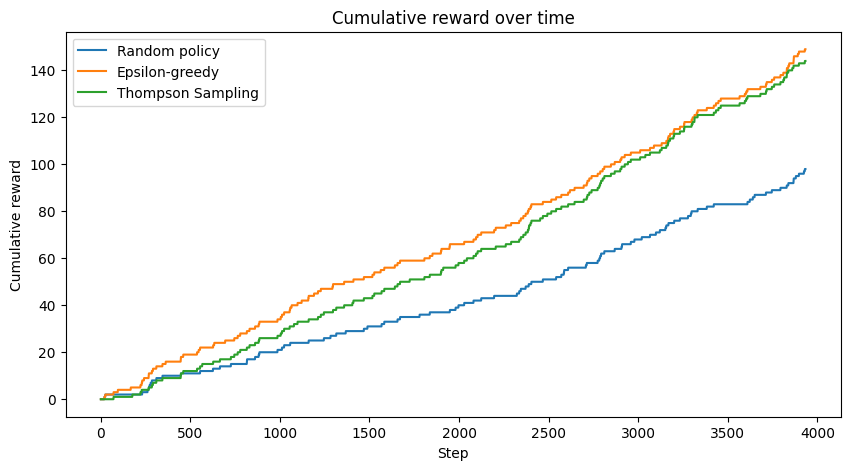

In [854]:
plt.figure(figsize=(10, 5))
plt.plot(
    random_policy_history["step"],
    random_policy_history["cumulative_reward"],
    label="Random policy"
)
plt.plot(
    epsilon_greedy_history["step"],
    epsilon_greedy_history["cumulative_reward"],
    label="Epsilon-greedy"
)
plt.plot(
    thompson_history["step"],
    thompson_history["cumulative_reward"],
    label="Thompson Sampling"
)

plt.title("Cumulative reward over time")
plt.xlabel("Step")
plt.ylabel("Cumulative reward")
plt.legend()
plt.show()

The cumulative reward plot shows whether the adaptive policies actually learn to allocate traffic better than a non-learning baseline.

This is important because the final average reward alone does not show *when* a policy starts becoming useful. A policy may perform well only at the end of the simulation, or it may improve quickly and remain above the baseline for most of the trajectory.

In this setting, cumulative reward can be interpreted as the total number of successful recommendation decisions made so far, where a success means that the chosen recommender placed the hidden test hotel inside the top-10 list.

The key question is therefore whether epsilon-greedy and Thompson Sampling accumulate reward faster than the random policy. If they do, this means that the bandit layer is successfully learning which recommender arms are more reliable and is converting past feedback into better traffic allocation decisions.

From a company perspective, this is a very practical result. It shows not only which recommender is strongest offline, but also whether an online controller can learn to exploit that advantage progressively rather than treating all recommenders equally.

### 17.10 Reward rate over time

The running average reward can be interpreted as an online equivalent of **HitRate@10**.

Tracking this quantity over time allows us to compare policies in a directly interpretable way:

- higher curves mean that, on average, the policy is selecting more successful recommenders
- upward trends indicate learning
- stable gaps between policies indicate meaningful differences in decision quality

This view is especially useful for communicating results to non-technical stakeholders, because it turns the bandit simulation into a very intuitive business story:

- the policy observes user outcomes sequentially
- it updates its belief about which recommender is more reliable
- it gradually routes more traffic toward the better-performing options
- the average success rate improves as a result

For a company, this is one of the most actionable outputs of the section, because it shows not just which recommender is strongest offline, but whether an online controller can learn to exploit that fact in a measurable way.

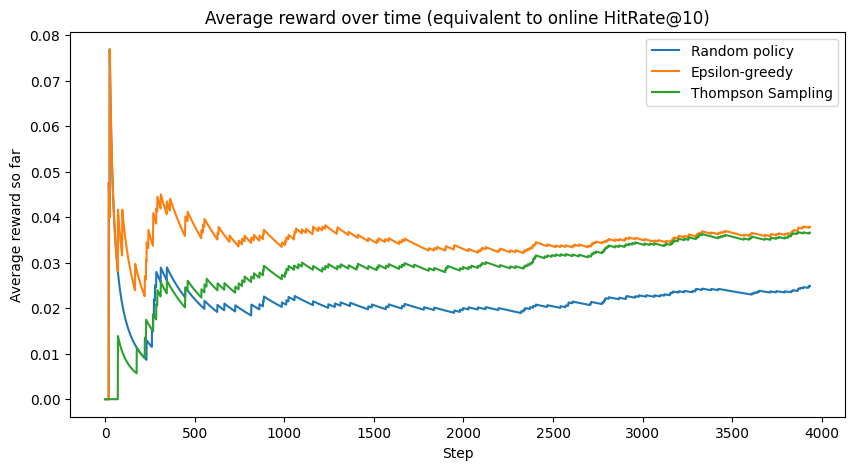

In [838]:
plt.figure(figsize=(10, 5))
plt.plot(random_policy_history["step"], random_policy_history["ctr_so_far"], label="Random policy")
plt.plot(epsilon_greedy_history["step"], epsilon_greedy_history["ctr_so_far"], label="Epsilon-greedy")
plt.plot(thompson_history["step"], thompson_history["ctr_so_far"], label="Thompson Sampling")
plt.title(f"Average reward over time (equivalent to online HitRate@{BANDIT_TOP_K})")
plt.xlabel("Step")
plt.ylabel("Average reward so far")
plt.legend()
plt.show()

### 17.11 Arm usage by policy

We also inspect how often each policy selects each recommender arm.

This is extremely informative.

The reward tells us **how well** a policy performs, but the arm-usage distribution tells us **what strategy it has learned**.

For example:

- the **random policy** should allocate traffic almost uniformly across all arms
- **epsilon-greedy** should concentrate strongly on the arm that appears best, while still keeping some exploration
- **Thompson Sampling** should also prefer strong arms, but usually in a smoother and more uncertainty-aware way

This helps translate the simulation into deployment language.

A company does not only care that a routing strategy performs well. It also wants to know:

- which recommenders will receive most of the traffic
- whether alternative models still receive some exposure
- whether the controller is overly concentrated on a single strategy
- whether weak models are being phased out as expected

In that sense, the arm-usage plots are almost as important as the reward curves, because they reveal the operational consequences of the policy.

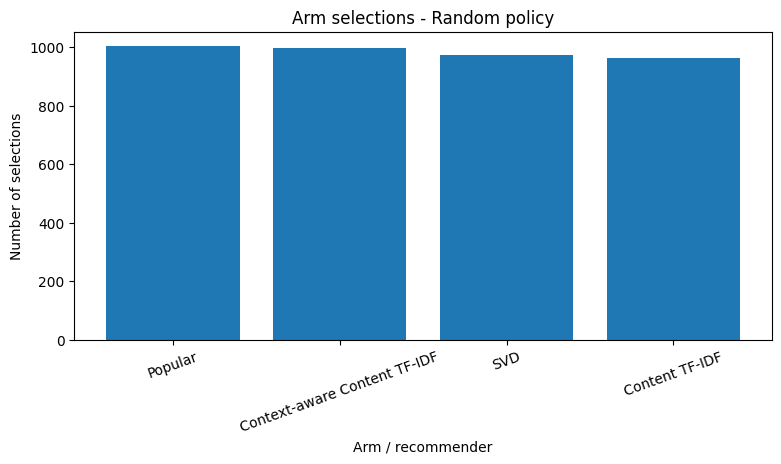

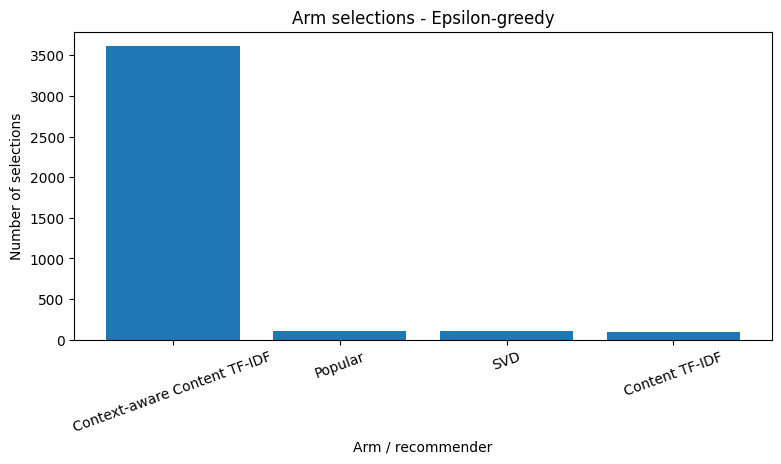

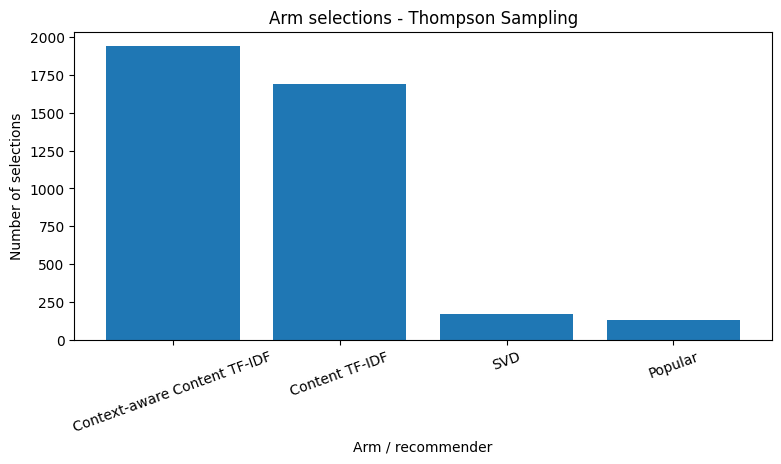

In [839]:
for policy_name in bandit_arm_summary["Policy"].unique():
    subset = bandit_arm_summary[bandit_arm_summary["Policy"] == policy_name].copy()
    subset = subset.sort_values("Selections", ascending=False)

    plt.figure(figsize=(9, 4))
    plt.bar(subset["Model"], subset["Selections"])
    plt.title(f"Arm selections - {policy_name}")
    plt.xlabel("Arm / recommender")
    plt.ylabel("Number of selections")
    plt.xticks(rotation=20)
    plt.show()

### 17.12 Interpreting the learned behavior

The bandit simulation adds a sequential decision layer on top of the recommenders already developed in the project.

Instead of assuming that one recommender should always be used for every interaction, the system adaptively decides which model to trust at each step.

This experiment is intentionally simple, but it is still meaningful.

The reward is aligned with our offline evaluation setup, since it checks whether the chosen recommender places the held-out hotel inside the top-10 list. In this sense, the simulation approximates an online recommendation scenario where the platform repeatedly chooses among alternative recommendation strategies.

The three policies serve different purposes:

- **Random policy** is a pure baseline with no learning
- **Epsilon-greedy** balances exploration and exploitation through the parameter $\varepsilon$
- **Thompson Sampling** uses uncertainty-aware exploration through posterior sampling

If the implementation behaves as expected, the adaptive policies should gradually concentrate their choices on the strongest arms, while the random policy continues sampling all arms uniformly.

In our results, this is exactly the type of behavior we want to verify:
- whether adaptive policies outperform random allocation
- whether they identify the strongest recommender family
- whether they still leave some room for experimentation

From a company perspective, the value of this section is substantial.

The earlier parts of the notebook identify which recommenders are strong **offline**. This section shows how those offline insights can be turned into an **online decision mechanism**.

That brings three practical benefits:

1. **Adaptive traffic allocation**  
   The company does not need to commit all traffic permanently to one recommender. The policy can learn from outcomes and reallocate traffic dynamically.

2. **Safer experimentation**  
   New or uncertain recommenders can be tested without giving them full exposure immediately.

3. **Better long-term learning**  
   If the environment changes over time, the decision layer can continue reacting rather than freezing the system around a single offline winner.

Therefore, bandit algorithms do not replace collaborative filtering or content-based recommenders. Instead, they act as a higher-level controller that decides **when and how much** each recommender should be used.

This is especially valuable in real platforms, where the best model may depend on seasonality, market changes, user segment, or evolving catalog conditions.

In [840]:
bandit_policy_summary

bandit_arm_summary.sort_values(["Policy", "EmpiricalRewardRate"], ascending=[True, False])

,Model,Selections,TotalRewardFromArm,SelectionShare,EmpiricalRewardRate,Policy
7,Context-aware Content TF-IDF,3610,145,0.917874,0.040166,Epsilon-greedy
6,Content TF-IDF,99,3,0.025172,0.030303,Epsilon-greedy
5,SVD,111,1,0.028223,0.009009,Epsilon-greedy
4,Popular,113,0,0.028731,0.000000,Epsilon-greedy
2,Content TF-IDF,961,40,0.244343,0.041623,Random policy
3,Context-aware Content TF-IDF,997,36,0.253496,0.036108,Random policy
1,SVD,973,11,0.247394,0.011305,Random policy
0,Popular,1002,11,0.254767,0.010978,Random policy
10,Content TF-IDF,1694,67,0.430714,0.039551,Thompson Sampling
11,Context-aware Content TF-IDF,1940,76,0.493262,0.039175,Thompson Sampling


The bandit simulation adds a sequential decision layer on top of the recommenders already built in the project. Instead of assuming that a single recommender should always be used for every interaction, the system adaptively decides which model to trust at each step.

This experiment is intentionally simple, but it is still meaningful. The reward is aligned with our offline evaluation setup, since it checks whether the chosen recommender places the held-out hotel inside the top-10 list. In this sense, the simulation approximates an online recommendation scenario where the system must repeatedly choose among alternative recommendation strategies.

The three policies serve different purposes:

- The **random policy** is a pure baseline with no learning.
- **Epsilon-greedy** explicitly balances exploration and exploitation through the parameter $\varepsilon$.
- **Thompson Sampling** performs a more principled uncertainty-aware exploration by sampling from posterior reward distributions.

If the implementation behaves as expected, both adaptive policies should gradually concentrate their choices on the strongest arms, while the random policy keeps sampling all arms uniformly. In our case, since the offline evaluation already showed that **Context-aware Content TF-IDF** was the strongest recommender, a successful bandit policy should learn to allocate an increasing fraction of traffic to that arm, while still occasionally testing alternatives.

This result is useful from a business perspective because it shows how recommenders and bandits can play complementary roles:
- the recommender estimates relevance,
- the bandit controls traffic allocation under uncertainty.

Therefore, bandit algorithms do not replace collaborative filtering or content-based recommenders. Instead, they provide an adaptive decision mechanism that can improve long-term learning, mitigate cold start, and react more flexibly when the best-performing recommender may vary over time.

## 18. Business interpretation and added value for the company

From a business perspective, recommendation is useful because it helps reduce information overload and makes the platform easier to use. A traveler searching for a hotel is often faced with hundreds of options, many of which look similar at first sight. A recommender system helps narrow this space and present a shortlist that is more relevant to the user’s needs, which can improve satisfaction, increase engagement, and make conversion more likely.

At the same time, recommendation is also useful for the company because it creates a structured way to connect users with a broader set of hotels. Instead of showing only the most obvious options, the system can support discovery, promote better catalog navigation, and help expose relevant hotels that might otherwise remain hidden.

### 18.1 Why the absolute performance values are not very high

The offline metrics in this project should be interpreted with realism. In this dataset, even the strongest recommenders achieve modest absolute values, but this does not mean the system is useless. It mainly reflects the difficulty of the task.

The first reason is the nature of hotel consumption itself. Hotels are not consumed frequently like songs, videos, or products in e-commerce. A user may listen to many songs in a day or watch many movies in a month, but may book and review only a few hotels per year. This means that user histories are naturally short, feedback is sparse, and learning stable preference patterns is much harder.

The second reason is that hotel choice is highly situational. A hotel is selected not only because of general taste, but also because of destination, season, trip purpose, budget, length of stay, and travel companions. So even a user who loved one hotel in the past may not want something similar next time if the context is different.

This is why the low scores of the Random and Popular baselines are actually informative. They show that the task is not trivial. If the problem were easy, even naive recommenders would already perform well. Instead, the results suggest that relevant recommendation in this domain requires richer signals and more structured modeling.

### 18.2 Business value of the hybrid recommender

The hybrid recommender is especially valuable because it gives the company flexibility rather than forcing it to commit to a single recommendation logic.

Different models capture different sources of value:

- popularity captures global demand and robustness
- collaborative or latent models capture behavioral structure
- content-based models capture descriptive similarity
- context-aware models capture situational relevance

A hybrid makes it possible to combine these signals in a controlled way. This is important because the “best” recommender may depend on the business objective. In some cases the company may want to maximize accuracy as much as possible. In others, it may want a better balance between relevance, personalization, coverage, novelty, or exposure of less popular hotels.

This is exactly why the weighted objective is useful. The company can define how much importance to assign to each aspect, and the system can return the best combination under that objective. So the hybrid is not only a model, but a decision tool: it lets the company translate business priorities into recommendation behavior.

### 18.3 Why this is strategically useful for the company

This hybrid structure is strategically useful because business goals can change over time. For example, the company may want:

- a safer, more stable recommender at launch
- a more personalized recommender once more interaction data are available
- stronger coverage if it wants to expose more of the catalog
- more exploration if it wants to help new hotels gain visibility

A single fixed recommender cannot adapt easily to all these goals, while a hybrid framework can. This makes the system much more practical for real deployment.

### 18.4 Continuous online learning as future value

Another major source of value is continuous online learning.

The offline analysis tells us which recommenders perform best on historical data, but once the system is deployed the company will keep collecting new interactions. This means the recommender should not remain static. It should keep learning from fresh behavior.

This is where the exploration-exploitation analysis becomes important. Online learning allows the platform to continue improving after deployment by testing recommendation strategies, gathering new evidence, and gradually shifting traffic toward the most effective ones.

From a business perspective, this has two key advantages.

First, it helps reduce uncertainty. If the company is not fully sure which recommender should dominate, online learning allows it to discover this progressively instead of making a once-and-for-all decision.

Second, it makes the system future-proof. As user behavior changes, catalog composition evolves, and more data become available, the recommender can adapt rather than becoming outdated.

### 18.5 Final business takeaway

The main business takeaway is that the value of this project is not just in finding one model with the highest metric. Its value is in building a recommendation framework that the company can control and improve over time.

In particular, the project delivers three business insights:

1. recommendation is useful because it simplifies choice and improves catalog navigation  
2. modest absolute metrics are expected in a sparse and highly situational hotel domain  
3. the hybrid plus online learning framework is the most valuable long-term direction, because it lets the company align recommendation with its priorities and keep improving as more data are collected  

For this reason, the strongest practical outcome of the project is not a single algorithmic winner, but a flexible recommendation strategy that can evolve with the company’s objectives and data.

## 19. Final comparison and conclusions

This project compared several recommender families on a sparse hotel-review dataset, including non-personalized baselines, collaborative filtering methods, content-based models, context-aware extensions, hybrid combinations, and online bandit policies.

The first important conclusion is that the problem is genuinely difficult. The dataset is extremely sparse, user histories are short, and hotel choice is strongly influenced by context. This explains why the absolute values of the ranking metrics remain relatively low across all models. In this setting, even small improvements are meaningful, especially because weak baselines such as Random and Popular confirm that good recommendations are not easy to obtain by chance.

A clear pattern emerges from the offline evaluation: **content-based recommenders are the strongest family in this project**. In particular, **Content TF-IDF** and especially **Context-aware Content TF-IDF** provide the best balance of ranking quality, coverage, and personalization. The best standalone result is obtained by **Context-aware Content TF-IDF**, with **HitRate@10 = 0.040640**, **NDCG@10 = 0.020010**, **MRR@10 = 0.013873**, **Coverage@10 = 0.675208**, and **Personalization@10 = 0.954010**. This shows that textual hotel descriptions extracted from reviews contain highly useful signals for recommendation, and that adding seasonal context can further improve them when context is modeled in a compatible way.

By contrast, the collaborative filtering results are weaker. **Item-based CF** is the best collaborative method, but it remains below the strongest content-based models, while **User-based CF** performs very poorly because user-user overlap is too limited in such a sparse setting. **SVD** improves rating prediction accuracy in RMSE/MAE terms, but this does not translate into strong top-k recommendation performance. This is an important lesson: optimizing rating prediction does not necessarily mean optimizing recommendation ranking.

The context-aware analysis also gives a nuanced conclusion. Context is not automatically beneficial. When applied to item-based CF, splitting the data by season reduces support too much and hurts performance. For content-based TF-IDF, instead, contextualization improves both relevance and catalog quality. So the value of context depends on whether the model can use it without creating excessive fragmentation.

The hybrid analysis leads to another useful conclusion. In theory, combining multiple signals could outperform any single model, but in practice the best hybrids assign almost all the weight to the strongest contextual TF-IDF recommender. This means that, in the current dataset, the other components add limited complementary value. The hybrid framework is still useful, but more as a business control mechanism than as a purely performance-improving device.

Finally, the bandit section shows the value of moving from static offline recommendation to adaptive online allocation. Even if one recommender is currently best offline, a real company benefits from continuously learning which strategy works best as new interactions arrive. This makes the system more flexible and more realistic for deployment.

Overall, the main conclusion is that the best direction for this dataset is a **review-driven, context-aware content recommender**, supported by a **hybrid weighting framework** and potentially improved through **online learning**. This combination gives the company not only the strongest observed performance, but also the most practical path for future refinement as more behavioral and contextual data become available.